# 信用卡欺诈检测 — 最终版整合 Notebook

## 阅读方式
- **§0**：唯一集中 `import` 第三方库（不含自定义函数）
- **§1–§13**：每节 **markdown** → **prep**（本节函数）→ **exec**（运行 + 打印/display + 写 `src/output/final_report/`）  

注意：文中 FE1-FE8 指 feature-engineering 文件夹中的 8 个 notebook。

## 全局协议
| 项 | 设定 |
|----|------|
| 交叉验证 | Purged Walk-forward，Embargo 2h |
| 模型 | LightGBM + XGBoost |

## F1 与分类阈值：各节为何不同

全 notebook 的 F1 / FP / FN 均：OOF（折外预测结果） 按时间切 **cal**（校准段，约前 25%）调 F1 的阈值，**eval**（评估段，约后 75%）报指标得分。

各章节中「有的节各自定阈值、有的节共用 BASE 特征组的 F1 阈值、§13 另有一套 nested 方案」—— 是因为**用途不同**。  

下文中 **t\*（threshold）** 指在cal（校准段）搜到的使 F1 最优的阈值；**BASE** 指基础特征组（由数据集本身给出，Amount/Time/V1-V28）；**combo** 指特征消融实验中的各候选特征组合。  
**Nested (w, t*)** = 两层 holdout（cal / eval），即两层都使用一部分样本搜索最优的参数值，并保留一些样本用来验证搜索得到参数的实际效果。

## F1 列说明：何时看哪一列

自 §7 起，凡 **多 combo 并排对比** 的表格（§7/§8 特征消融、§9/§10 基于贡献度的新特征组消融实验）**同时输出**：

| 列名 | 阈值来源 | 用途 |
|------|----------|------|
| **`F1@BASE_t*`** | 同 model×seed：BASE 在 OOF 的 **cal** 段定 BASE_t*，所有 combo 均在 **eval** 段沿用此阈值评分 | 看业务阈值不变时 F1 会不会掉；F1@combo_t* 指标抖动大时，可以观察这个指标作为补充 |
| **`F1@combo_t*`** | 该 combo 在 **自己的 cal** 段自定 combo_t*，**eval** 段据此报 F1 | 加特征后的 **F1 潜力**；可能因 cal/eval 切分，与欺诈样本数量不均衡而剧烈抖动 |

### 不使用 cal、eval 评价 F1 的代价

不用 cal/eval，在同一份 OOF 上「先搜 t*、再算 F1」，F1 会偏乐观——本质是 **同集选阈 + 同集打分，阈值对当前这份数据过拟合**，不是模型在未知数据上真的有那么好。

## 可选实验开关
可选实验开关在 **首次使用它的 prep**（如 §5 `RUN_FOCAL_LOSS`；§6 `RUN_AE_ANOMALY`）默认 **False**。不选用原因在各节 markdown **显著标出**；改为 True 可复现对比。部分单元要重跑需清除 output 中的 checkpoint 文件。

---

In [2]:
# §0 导入全部依赖包
%matplotlib inline
from io import BytesIO
from pathlib import Path
import json
import re
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product, combinations
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, log_loss, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb
import xgboost as xgb
import shap
from scipy import stats
from purgedcv import WalkForwardSplit
from purgedcv.diagnostics import assert_no_temporal_leakage
from IPython.display import Image, display
import optuna


try:
    import tensorflow as tf
    from tensorflow import keras
except ImportError:
    tf = None
    keras = None
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


## 1. 探索性数据分析

参考：[`eda/credit-fraud-eda.ipynb`](eda/credit-fraud-eda.ipynb)、[`credit-fraud-feature-engineering-summary-report.ipynb`](feature-engineering-report/credit-fraud-feature-engineering-summary-report.ipynb)。

本节图表与表格写入 `01_eda/`。

阅读顺序：
1. **§1.1** 用原始特征做假设验证
2. **§1.2** 定稿 4 列 EDA 特征
3. **§3.1 / §4.1** 难样本 / 欺诈画像分析

In [3]:
# §1 prep：路径 + 数据读取 + 展示工具
def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'input' / 'creditcard.csv').exists():
            return candidate
    raise FileNotFoundError('无法找到 input/creditcard.csv，请确认 notebook 在项目内运行')


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
DATA_PATH = PROJECT_ROOT / 'input' / 'creditcard.csv'
OUTPUT_DIR = SRC_DIR / 'output' / 'final_report'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_EDA = OUTPUT_DIR / '01_eda'
OUT_EDA.mkdir(parents=True, exist_ok=True)


def read_creditcard_csv(path: Path | None = None) -> pd.DataFrame:
    path = path or DATA_PATH
    for kwargs in (
        {'encoding': 'utf-8'},
        {'encoding': 'utf-8', 'encoding_errors': 'replace'},
        {'encoding': 'latin-1'},
    ):
        try:
            return pd.read_csv(path, **kwargs)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, 'failed to decode creditcard.csv')


def setup_chinese_font():
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC', 'SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False


def save_show_fig(fig, out_path=None, dpi=150, bbox_inches='tight'):
    """注3/注4：保存 PNG 到 output，并以嵌入方式在 notebook 展示。"""
    setup_chinese_font()
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches=bbox_inches)
    png_bytes = buf.getvalue()
    if out_path is not None:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        out_path.write_bytes(png_bytes)
    plt.close(fig)
    display(Image(data=png_bytes))


### 1.1 从业务假设到特征

按行业背景提出假设，再用数据和图表验证强弱，最后决定是否产出候选特征。

#### 1.1.1 欺诈金额分布不同——Amount 分布
假设：欺诈样本的金额分布不同于正常样本。

欺诈与正常交易的 Amount 分布不同，图中观察到长尾效应显著，尝试 `log1p_amount` （对Amount列取对数）特征对抗数据的偏态分布。

In [29]:
# §1.1 exec：加载原始数据（探索验证用，尚未构造衍生特征）
setup_chinese_font()
df_raw = read_creditcard_csv(DATA_PATH)
V_COLS = [c for c in df_raw.columns if c.startswith('V')]
BASE_FEATURES = V_COLS + ['Amount', 'Time']
df = df_raw.copy()
FRAUD_RATE = float(df['Class'].mean())
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print(f'样本数: {len(df):,} | 欺诈: {int(df["Class"].sum())} | 欺诈率: {FRAUD_RATE:.4f}')


样本数: 284,807 | 欺诈: 492 | 欺诈率: 0.0017


,正常,欺诈
样本数,284315.00,492.00
均值,88.29,122.21
标准差,250.11,256.68
最小值,0.00,0.00
25%分位,5.65,1.00
中位数,22.00,9.25
75%分位,77.05,105.89
最大值,25691.16,2125.87


KS 检验: 统计量=0.2712, p=2.17e-32


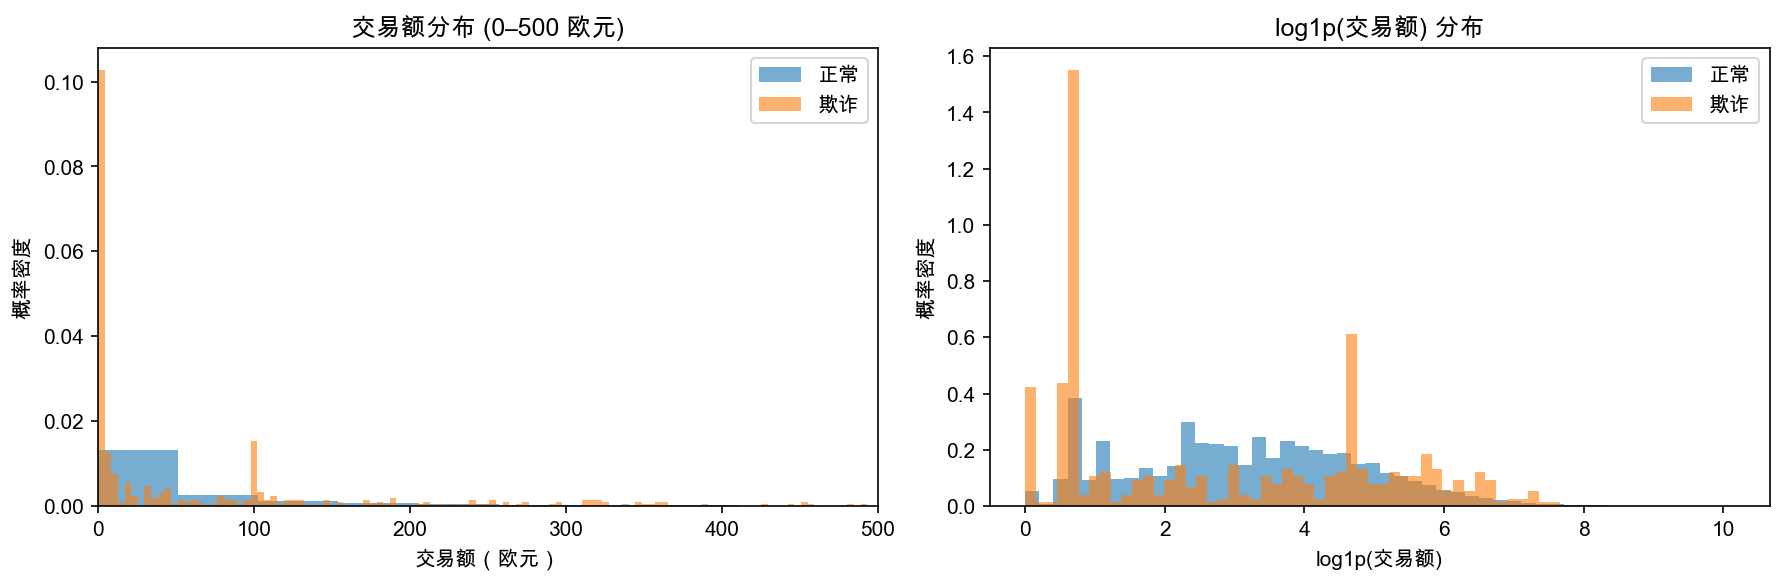

In [30]:
# §1.1.1 Amount 分布验证（report: amount_dist.png）
DESCRIBE_CN = {
    'count': '样本数', 'mean': '均值', 'std': '标准差', 'min': '最小值',
    '25%': '25%分位', '50%': '中位数', '75%': '75%分位', 'max': '最大值',
}
stats_table = pd.DataFrame({
    '正常': normal['Amount'].describe(),
    '欺诈': fraud['Amount'].describe(),
}).round(2).rename(index=DESCRIBE_CN)
display(stats_table)

ks_stat, ks_p = stats.ks_2samp(normal['Amount'], fraud['Amount'])
print(f'KS 检验: 统计量={ks_stat:.4f}, p={ks_p:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(normal['Amount'], bins=500, alpha=0.6, label='正常', density=True)
axes[0].hist(fraud['Amount'], bins=500, alpha=0.6, label='欺诈', density=True)
axes[0].set_xlim(0, 500)
axes[0].set_xlabel('交易额（欧元）'); axes[0].set_ylabel('概率密度')
axes[0].set_title('交易额分布 (0–500 欧元)'); axes[0].legend()

axes[1].hist(np.log1p(normal['Amount']), bins=50, alpha=0.6, label='正常', density=True)
axes[1].hist(np.log1p(fraud['Amount']), bins=50, alpha=0.6, label='欺诈', density=True)
axes[1].set_xlabel('log1p(交易额)'); axes[1].set_ylabel('概率密度')
axes[1].set_title('log1p(交易额) 分布'); axes[1].legend()
fig.tight_layout()
save_show_fig(fig, OUT_EDA / 'eda_amount_dist.png', dpi=150)


#### 1.1.2 小额卡测试——小额欺诈发生率高于均值

假设：欺诈更容易集中在小额卡测试常用金额处。


In [31]:
# §1.1.2 小额卡测试验证
n_fraud, n_normal = len(fraud), len(normal)
one_euro_fraud = int((fraud['Amount'] == 1.0).sum())
micro_fraud = int((fraud['Amount'] < 1).sum())
micro_normal = int((normal['Amount'] < 1).sum())
baseline_non_one = df.loc[df['Amount'] != 1.0, 'Class'].mean()
one_euro_rate = df.loc[df['Amount'] == 1.0, 'Class'].mean()

summary_22 = pd.DataFrame([
    {'证据': 'Amount == 1.0 欺诈笔数', '数值': f'{one_euro_fraud} 笔'},
    {'证据': 'Amount == 1.0 占全部欺诈比例', '数值': f'{one_euro_fraud / n_fraud * 100:.1f}%'},
    {'证据': 'Amount == 1.0 处欺诈率提升', '数值': f'{one_euro_rate / baseline_non_one:.2f}'},
    {'证据': 'Amount < 1 欺诈占比', '数值': f'{micro_fraud / n_fraud * 100:.2f}%'},
    {'证据': 'Amount < 1 正常占比', '数值': f'{micro_normal / n_normal * 100:.2f}%'},
    {'证据': 'Amount < 1 欺诈/正常倍数', '数值': f'{(micro_fraud/n_fraud)/(micro_normal/n_normal):.2f}'},
])
display(summary_22)
summary_22.to_csv(OUT_EDA / 'eda_micro_testing_summary.csv', index=False, encoding='utf-8-sig')


,证据,数值
0,Amount == 1.0 欺诈笔数,113 笔
1,Amount == 1.0 占全部欺诈比例,23.0%
2,Amount == 1.0 处欺诈率提升,5.91
3,Amount < 1 欺诈占比,13.82%
4,Amount < 1 正常占比,5.89%
5,Amount < 1 欺诈/正常倍数,2.35


结论：小额卡测试假设成立，考虑后认为不应做类似“危险度分数”这种人为打分指标，可能引入过多噪声；更稳妥的是保留事实特征，让树模型自己学习切分。

产生候选特征：`is_micro_testing`（<1 欧）、`is_small_testing`（>1且<=5 欧）、`is_one_euro`（=1 欧）。  
后续取舍中：`is_one_euro` 更适合作为特征交叉的门控（大量误报产生在1欧处），`is_small_testing` 后来因效果不好被难样本金额带替代（该区间欺诈发生率本就低于均值，这也是上面表格中没展示 >1 欧的中小额数据分析的原因）。

#### 1.1.3 深夜/非活跃时段欺诈率更高——欺诈时间聚集 / 非活跃时段高发

假设：欺诈在时间上存在聚集，低流量时段可能更危险。由于 `Time` 是距首笔交易的秒数，不是自然时钟（从某天0点开始），因此这里用相对小时 `hours_since_start = Time // 3600`。

时间跨度: 0秒 – 172792秒（约 2.0 天）
相对小时桶数量: 48


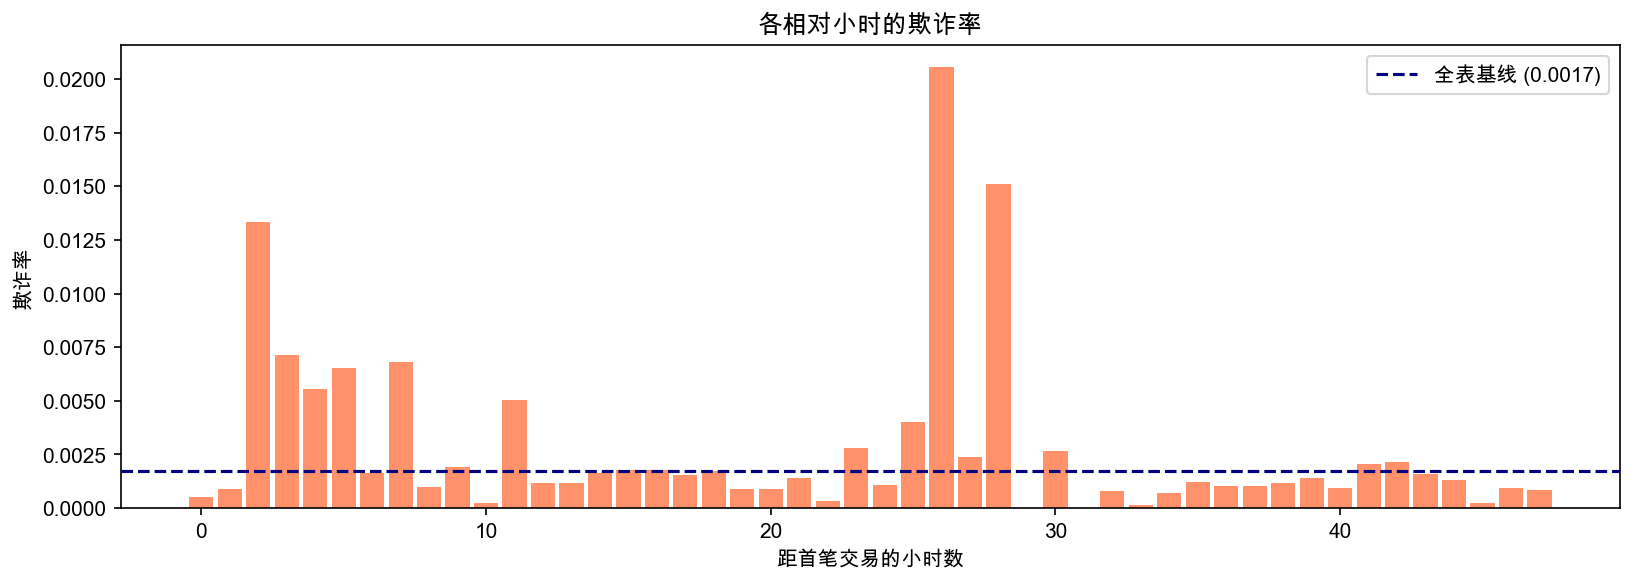

,总笔数,欺诈笔数,欺诈率,相对基线倍数
距起点小时,,,,
26,1752,36,0.0205,11.8947
28,1127,17,0.0151,8.7319
2,1576,21,0.0133,7.7134
3,1821,13,0.0071,4.1326
7,3368,23,0.0068,3.9531
5,1681,11,0.0065,3.7880
4,1082,6,0.0055,3.2100
11,8517,43,0.0050,2.9226



非活跃 vs 活跃（按每小时桶交易量划分）:
  非活跃: 欺诈率=0.0026, 样本数=85,884
  活跃: 欺诈率=0.0014, 样本数=198,923
  提升倍数（非活跃/活跃）: 1.89x


In [32]:
# §1.1.3 相对小时欺诈率（report: time_dist.png）
df_time = df.copy()
df_time['hours_since_start'] = (df_time['Time'] // 3600).astype(int)

hourly_rel = df_time.groupby('hours_since_start').agg(total=('Class', 'count'), fraud=('Class', 'sum'))
hourly_rel['fraud_rate'] = hourly_rel['fraud'] / hourly_rel['total']
hourly_rel['lift_vs_overall'] = hourly_rel['fraud_rate'] / FRAUD_RATE
hourly_rel = hourly_rel.rename(columns={
    'total': '总笔数', 'fraud': '欺诈笔数', 'fraud_rate': '欺诈率', 'lift_vs_overall': '相对基线倍数',
})
hourly_rel.index.name = '距起点小时'

span_days = (df['Time'].max() - df['Time'].min()) / 86400
print(f'时间跨度: {df["Time"].min():.0f}秒 – {df["Time"].max():.0f}秒（约 {span_days:.1f} 天）')
print(f'相对小时桶数量: {hourly_rel.shape[0]}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly_rel.index, hourly_rel['欺诈率'], color='coral', alpha=0.85, width=0.85)
ax.axhline(FRAUD_RATE, color='navy', ls='--', label=f'全表基线 ({FRAUD_RATE:.4f})')
ax.set_xlabel('距首笔交易的小时数'); ax.set_ylabel('欺诈率')
ax.set_title('各相对小时的欺诈率'); ax.legend()
fig.tight_layout()
save_show_fig(fig, OUT_EDA / 'eda_hour_fraud_rate.png', dpi=150)

display(hourly_rel.sort_values('欺诈率', ascending=False).head(8).round(4))
hourly_rel.to_csv(OUT_EDA / 'eda_hourly_fraud_rate.csv', encoding='utf-8-sig')

txn_median = hourly_rel['总笔数'].median()
inactive_hours = hourly_rel.index[hourly_rel['总笔数'] < txn_median]
df_time['is_inactive'] = df_time['hours_since_start'].isin(inactive_hours)
print('\n非活跃 vs 活跃（按每小时桶交易量划分）:')
for label, mask in [('非活跃', df_time['is_inactive']), ('活跃', ~df_time['is_inactive'])]:
    sub = df_time[mask]
    print(f"  {label}: 欺诈率={sub['Class'].mean():.4f}, 样本数={len(sub):,}")
inactive_rate = df_time.loc[df_time['is_inactive'], 'Class'].mean()
active_rate = df_time.loc[~df_time['is_inactive'], 'Class'].mean()
print(f'  提升倍数（非活跃/活跃）: {inactive_rate / active_rate:.2f}x')


验证结果：最高风险小时桶欺诈率约为全局基线的 11.89 倍；按交易量划分的非活跃小时欺诈率为 0.0026，活跃小时为 0.0014，约 1.89 倍。

结论：时间聚集假设部分成立。产生候选特征 `hours_since_start` 和 `is_inactive`；后续保留 `hours_since_start`，`is_inactive` 过粗且在 FE1 中观察到效果不稳定，弃用。

#### 1.1.4 批量盗刷或卡测试——短交易间隔

假设：批量盗刷或卡测试可能表现为短时间内连续交易，因此相邻交易间隔越短，欺诈率可能越高。

验证限制：数据集没有 `card_id` / `account_id`/ `recipient_id`，只能按全局 `Time` 排序计算与上一笔交易的间隔。这个间隔混合了多张卡，因此只能作为弱参考。

In [33]:
# §1.1.4 短交易间隔
df_sorted = df.sort_values('Time').reset_index(drop=True)
df_sorted['time_diff'] = df_sorted['Time'].diff()
td = df_sorted[df_sorted['time_diff'] > 0]

interval_rows = []
for label, g in [('正常', td[td['Class'] == 0]), ('欺诈', td[td['Class'] == 1])]:
    d = g['time_diff']
    interval_rows.append({
        '组别': label, '中位数(秒)': d.median(), '均值(秒)': d.mean(), '75%分位(秒)': d.quantile(0.75),
    })
display(pd.DataFrame(interval_rows).round(2))

window_rows = []
for window in [1, 2, 3, 5, 7.5, 10, 60, 300, 3600]:
    mask = td['time_diff'] <= window
    window_rows.append({'窗口(秒)': window, '样本数': int(mask.sum()), '欺诈率': td.loc[mask, 'Class'].mean()})
win_df = pd.DataFrame(window_rows)
display(win_df.round(4))
win_df.to_csv(OUT_EDA / 'eda_velocity_windows.csv', index=False, encoding='utf-8-sig')


,组别,中位数(秒),均值(秒),75%分位(秒)
0,正常,1.0,1.39,1.0
1,欺诈,1.0,2.22,2.0


,窗口(秒),样本数,欺诈率
0,1.0,100059,0.0014
1,2.0,115679,0.0016
2,3.0,119835,0.0016
3,5.0,122603,0.0018
4,7.5,123602,0.0019
5,10.0,124238,0.0019
6,60.0,124591,0.0019
7,300.0,124591,0.0019
8,3600.0,124591,0.0019


验证结果：

| 指标 | 正常 | 欺诈 |
| --- | --- | --- |
| `time_diff` 中位数 | 1.0 秒 | 1.0 秒 |
| `time_diff` 均值 | 1.4 秒 | 2.2 秒 |
| `time_diff` 75% 分位 | 1.0 秒 | 2.0 秒 |

短间隔窗口欺诈率也没有形成强支持：`≤1s` 欺诈率为 0.0014，低于全局基线约 0.0017；`≤5s` 为 0.0018，`≤10s` 为 0.0019，提升很弱。

结论：短交易间隔假设不成立 / 无法可靠验证，不产出特征。

#### 1.1.5 套现——异常大额交易

假设：异常大额交易可能更容易是欺诈。

验证方法：观察全表 `Amount` 的 z-score，比较高 z-score 子集的欺诈率和全局基线。这里仅用于探索；如果正式建模使用 scaler，需要在训练折内 fit，避免泄露。

In [34]:
# §1.1.5 大额 z-score 粗看
amt_mean, amt_std = df['Amount'].mean(), df['Amount'].std()
df_z = df.assign(amount_z=(df['Amount'] - amt_mean) / amt_std)
z_rows = []
for z in [1, 2, 3]:
    sub = df_z[df_z['amount_z'] > z]
    z_rows.append({'条件': f'amount_z > {z}', '样本数': len(sub), '欺诈率': sub['Class'].mean(), '全局基线': FRAUD_RATE})
z_df = pd.DataFrame(z_rows)
display(z_df.round(4))
z_df.to_csv(OUT_EDA / 'eda_amount_zscore.csv', index=False, encoding='utf-8-sig')


,条件,样本数,欺诈率,全局基线
0,amount_z > 1,15710,0.0033,0.0017
1,amount_z > 2,7319,0.0040,0.0017
2,amount_z > 3,4076,0.0027,0.0017


结论：异常大额套现假说只有弱支持，没有形成清晰分界，也不值得单独造一个 z-score 桶，作为一个特征来分类各种样本。最终用 `log1p_amount` 表达金额长尾尺度，把具体切分交给模型。

### 1.2 探索结论：候选特征与弃用项

#### §1.1 验证通过、本节定稿的候选特征（4 列）
`log1p_amount`, `hours_since_start`, `is_micro_testing`, `is_one_euro`

#### 待 §3–§4 再纳入的基于难样本和欺诈画像的金额带特征
`is_amount_1_30`（§3 难样本分析）、`is_amount_75_110`（§4 欺诈画像 + 难样本人工定界）。

#### 已弃用
`is_inactive`、`is_small_testing` **不进入后续管线**。

In [4]:
# §1.2 prep：runtime state + §1.1 探索验证后定稿 EDA 衍生特征（4 列）
STATE_PATH = OUTPUT_DIR / 'runtime_state.json'


def save_state(**kwargs):
    state = {}
    if STATE_PATH.exists():
        state = json.loads(STATE_PATH.read_text(encoding='utf-8'))
    for k, v in kwargs.items():
        if isinstance(v, (list, dict, str, int, float, bool)) or v is None:
            state[k] = v
        else:
            state[k] = str(v)
    STATE_PATH.parent.mkdir(parents=True, exist_ok=True)
    STATE_PATH.write_text(json.dumps(state, ensure_ascii=False, indent=2), encoding='utf-8')


def load_state():
    if STATE_PATH.exists():
        return json.loads(STATE_PATH.read_text(encoding='utf-8'))
    return {}


def build_initial_eda_features(data: pd.DataFrame) -> pd.DataFrame:
    """§1.1 业务假设验证通过后定稿的 EDA 候选特征。"""
    out = data.copy()
    out['log1p_amount'] = np.log1p(out['Amount'])
    out['hours_since_start'] = (out['Time'] // 3600).astype(int)
    out['is_micro_testing'] = out['Amount'] < 1
    out['is_one_euro'] = out['Amount'] == 1.0
    return out


EDA_FEATURES = [
    'log1p_amount', 'hours_since_start', 'is_micro_testing', 'is_one_euro',
]


In [36]:
# §1.2 exec：特征目录 + state
df = build_initial_eda_features(df_raw)
eda_summary = pd.DataFrame({
    '特征': EDA_FEATURES,
    '说明': [
        'log1p(Amount)，缓解交易额数据偏态分布',
        'Time//3600，距离第一笔交易发生过了多少小时',
        'Amount<1 微额卡测试',
        'Amount==1 一元特征（卡测试大量集中，难样本 FP 集中）',
    ],
})
eda_summary.to_csv(OUT_EDA / 'eda_feature_catalog.csv', index=False, encoding='utf-8-sig')
display(eda_summary)

dropped_eda = pd.DataFrame({
    '特征': ['is_inactive', 'is_small_testing'],
    '处置': ['EDA 阶段弃用', '由难样本金额带替代'],
    '原因': ['不稳定/增益弱', '过粗，见 summary-report §3'],
})
dropped_eda.to_csv(OUT_EDA / 'eda_dropped_features.csv', index=False, encoding='utf-8-sig')
print('\n已弃用 EDA 方向：')
display(dropped_eda)

save_state(BASE_FEATURES=BASE_FEATURES, V_COLS=V_COLS, EDA_FEATURES=EDA_FEATURES)
print('已保存 →', OUT_EDA)


,特征,说明
0,log1p_amount,log1p(Amount)，缓解交易额数据偏态分布
1,hours_since_start,Time//3600，距离第一笔交易发生过了多少小时
2,is_micro_testing,Amount<1 微额卡测试
3,is_one_euro,Amount==1 一元特征（卡测试大量集中，难样本 FP 集中）



已弃用 EDA 方向：


,特征,处置,原因
0,is_inactive,EDA 阶段弃用,不稳定/增益弱
1,is_small_testing,由难样本金额带替代,过粗，见 summary-report §3


已保存 → /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/01_eda


## 2. 双模型 BASE 基线

参考：[`eda/credit-fraud-eda.ipynb`](eda/credit-fraud-eda.ipynb) §2.1、[`credit-fraud-feature-engineering-6.ipynb`](feature-engineering/credit-fraud-feature-engineering-6.ipynb) purgedcv 工具。

### 做什么
在 **仅 BASE 特征**（V1–V28 + Amount + Time，共 30 列）上，对比两种 CV（交叉验证）：
1. **StratifiedKFold**（随机分层）
2. **Purged Walk-Forward**（主协议，遵循时间顺序进行训练和验证；2h Embargo，受限于欺诈样本数量，只能做到这样）

### ⚠️ 为何弃用 SKF
StratifiedKFold 打乱时间顺序，训练折可包含验证折的「未来」交易 → **AUC-PR 往往偏乐观（欺诈行为在时间上具有自相关性，使用未来数据训练，并在过去数据的验证集上验证，本质上是一种数据泄漏）**。  
**自 §3 起所有统一使用 purgedcv；SKF 结果只作反面教材。**

输出：`02_base_cv/skf_vs_purged_base.csv`



In [5]:
OUT_BASE_CV = OUTPUT_DIR / '02_base_cv'
OUT_BASE_CV.mkdir(parents=True, exist_ok=True)

MODELS = ['LightGBM', 'XGBoost']
CV_N_SPLITS = 5
CV_RANDOM_STATE = 42
CV_EMBARGO = pd.Timedelta(hours=2)
CV_PURGE_HORIZON = pd.Timedelta(0)
EARLY_STOPPING_ROUNDS = 50
MAX_BOOST_ROUNDS = 1500
ES_FRAC = 0.20
ES_MIN_FRAUD = 5
ES_MAX_FRAC = 0.35
DEFAULT_CLASSIFICATION_THRESHOLD = 0.5
F1_BASE_COL = 'F1@BASE_t*'
F1_COMBO_COL = 'F1@combo_t*'
THR_BEST_COL = 't*@combo'
PREC_BEST_COL = 'Precision@best'
REC_BEST_COL = 'Recall@best'
WEIGHT_SCHEMES = {
    'balanced': None, 'spw_sqrt': 'sqrt', 'spw_0.5x': 0.5, 'spw_2x': 2.0, 'no_weight': 0.0,
}

# §2 prep：CV + 模型
_CV_BOUND_DATA = None


def sort_by_time(data: pd.DataFrame) -> pd.DataFrame:
    return data.sort_values('Time', kind='mergesort').reset_index(drop=True)


def bind_cv_data(data: pd.DataFrame) -> pd.DataFrame:
    global _CV_BOUND_DATA
    out = sort_by_time(data)
    _CV_BOUND_DATA = out
    return out


def build_cv_timestamps(data: pd.DataFrame):
    t = pd.to_timedelta(data['Time'].astype(float), unit='s')
    return t.copy(), t.copy()


def iter_purged_cv_folds(n_samples=None, n_splits=CV_N_SPLITS, data=None):
    bound = data if data is not None else _CV_BOUND_DATA
    if bound is None:
        raise RuntimeError('请先调用 bind_cv_data()')
    n = n_samples if n_samples is not None else len(bound)
    pred, evalu = build_cv_timestamps(bound)
    test_size = max(1, n // (n_splits + 1))
    cv = WalkForwardSplit(
        n_splits=n_splits, test_size=test_size, window='expanding',
        prediction_times=pred, evaluation_times=evalu,
        purge_horizon=CV_PURGE_HORIZON, embargo=CV_EMBARGO,
    )
    for tr_idx, va_idx in cv.split(np.arange(n)):
        assert_no_temporal_leakage(
            tr_idx, va_idx, prediction_times=pred, evaluation_times=evalu,
            purge_horizon=CV_PURGE_HORIZON,
        )
        yield tr_idx, va_idx


def iter_skf_folds(X, y, n_splits=CV_N_SPLITS, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    yield from skf.split(X, y)

def _temporal_es_mask(y, es_frac=ES_FRAC, min_fraud_es=ES_MIN_FRAUD, max_frac=ES_MAX_FRAC):
    """ES 段：各类按时间序**后** es_frac 进早停验证；欺诈不足则逐步扩大 es 上限 max_frac。"""
    y = np.asarray(y).astype(int)
    n = len(y)
    fraud_idx = np.flatnonzero(y == 1)
    norm_idx = np.flatnonzero(y == 0)
    if len(fraud_idx) < 2:
        n_es = max(1, min(n - 1, int(n * es_frac)))
        mask = np.zeros(n, dtype=bool)
        mask[n - n_es:] = True
        return mask, int(n_es)
    frac = es_frac
    while frac <= max_frac + 1e-9:
        n_fraud_es = max(min_fraud_es, max(1, int(len(fraud_idx) * frac)))
        n_fraud_es = min(n_fraud_es, len(fraud_idx) - 1)
        n_norm_es = max(1, int(len(norm_idx) * frac))
        n_norm_es = min(n_norm_es, len(norm_idx) - 1)
        mask = np.zeros(n, dtype=bool)
        mask[fraud_idx[-n_fraud_es:]] = True
        mask[norm_idx[-n_norm_es:]] = True
        if int(y[mask].sum()) >= min(min_fraud_es, len(fraud_idx) - 1):
            return mask, int(mask.sum())
        frac += 0.05
    n_fraud_es = min(max(min_fraud_es, 1), len(fraud_idx) - 1)
    n_norm_es = max(1, min(len(norm_idx) * es_frac))
    n_norm_es = min(n_norm_es, len(norm_idx) - 1)
    mask = np.zeros(n, dtype=bool)
    mask[fraud_idx[-n_fraud_es:]] = True
    mask[norm_idx[-n_norm_es:]] = True
    return mask, int(mask.sum())


def split_early_stop_set(X_tr, y_tr, es_frac=ES_FRAC, random_state=42, min_fraud_es=ES_MIN_FRAUD):
    """严格按 Time 顺序：训练折末尾作早停验证集（random_state 保留 API 兼容，不参与切分）。"""
    y_arr = np.asarray(y_tr)
    es_mask, _ = _temporal_es_mask(y_arr, es_frac=es_frac, min_fraud_es=min_fraud_es)
    fit_mask = ~es_mask
    if not fit_mask.any() or not es_mask.any():
        raise ValueError('早停切分失败：fit 或 ES 段为空，请检查 es_frac / ES_MIN_FRAUD')
    if hasattr(X_tr, 'iloc'):
        return X_tr.iloc[fit_mask], X_tr.iloc[es_mask], y_tr.iloc[fit_mask], y_tr.iloc[es_mask]
    return X_tr[fit_mask], X_tr[es_mask], y_arr[fit_mask], y_arr[es_mask]


def apply_weight_scheme(defaults, model_name, spw, weight_scheme='balanced'):
    vk = WEIGHT_SCHEMES[weight_scheme]
    defaults.pop('scale_pos_weight', None)
    defaults.pop('class_weight', None)
    if model_name == 'LightGBM':
        if vk is None:
            defaults['class_weight'] = 'balanced'
        elif vk == 0.0:
            pass
        elif vk == 'sqrt':
            defaults['class_weight'] = {0: 1.0, 1: float(np.sqrt(spw))}
        else:
            defaults['class_weight'] = {0: 1.0, 1: spw * vk}
    else:
        if vk is None:
            defaults['scale_pos_weight'] = spw
        elif vk == 0.0:
            defaults['scale_pos_weight'] = 1.0
        elif vk == 'sqrt':
            defaults['scale_pos_weight'] = float(np.sqrt(spw))
        else:
            defaults['scale_pos_weight'] = spw * vk
    return defaults


def make_classifier(model_name, y_train, params=None, random_state=CV_RANDOM_STATE):
    params = dict(params or {})
    spw = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    weight_scheme = params.pop('weight_scheme', 'balanced')
    if model_name == 'LightGBM':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6, num_leaves=31,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=0.1, random_state=random_state, verbose=-1, n_jobs=-1,
        )
        defaults.update(params)
        defaults = apply_weight_scheme(defaults, model_name, spw, weight_scheme)
        return lgb.LGBMClassifier(**defaults)
    defaults = dict(
        n_estimators=MAX_BOOST_ROUNDS, learning_rate=0.05, max_depth=6,
        min_child_weight=1, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=random_state, eval_metric='logloss', verbosity=0, n_jobs=-1,
    )
    defaults.update(params)
    defaults['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
    defaults = apply_weight_scheme(defaults, model_name, spw, weight_scheme)
    return xgb.XGBClassifier(**defaults)


def fit_classifier(clf, model_name, X_tr, y_tr, X_es=None, y_es=None):
    if X_es is None:
        clf.fit(X_tr, y_tr)
        return clf
    if model_name == 'LightGBM':
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], eval_metric='binary_logloss',
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)])
    else:
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
    return clf


def best_f1_threshold(y_true, proba):
    """在传入样本上扫描阈值最大化 F1；仅用于 OOF cal 段，勿对 eval 段或整份 OOF 后直接报 F1。"""
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    mask = np.isfinite(proba)
    y_eval, p_eval = y_true[mask], proba[mask]
    prec, rec, thr = precision_recall_curve(y_eval, p_eval)
    if len(thr) == 0:
        return DEFAULT_CLASSIFICATION_THRESHOLD, 0.0
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
    i = int(np.nanargmax(f1))
    return float(thr[i]), float(f1[i])



def _compute_confusion_metrics(y_eval, pred):
    """共享混淆矩阵指标（labels=[0,1] 保证 2x2，单类别不会崩）。"""
    tn, fp, fn, tp = confusion_matrix(y_eval, pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        'precision': float(precision), 'recall': float(recall), 'f1': float(f1),
        'fp': int(fp), 'fn': int(fn), 'tp': int(tp), 'tn': int(tn),
    }


def metrics_at_threshold(y_true, proba, threshold):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    mask = np.isfinite(proba)
    pred = proba[mask] >= threshold
    y_eval = y_true[mask]
    m = _compute_confusion_metrics(y_eval, pred)
    return {
        F1_COMBO_COL: m['f1'], PREC_BEST_COL: m['precision'], REC_BEST_COL: m['recall'],
        'FP': m['fp'], 'FN': m['fn'], 'n_eval': int(mask.sum()), 'n_excluded': int((~mask).sum()),
    }


# ---------------------------------------------------------------------------
# Honest 阈值（held-out OOF split）
#
# 做法：OOF 按 Time 序、按类分层切 cal / eval（默认 cal≈25%，cal 内欺诈≥OOF_CAL_MIN_FRAUD）；
#       只在 cal 搜 t*，在 eval（held-out）报 F1/FP/FN。
# ---------------------------------------------------------------------------
OOF_CAL_FRAC = 0.25
OOF_CAL_MIN_FRAUD = 50
OOF_CAL_MAX_FRAC = 0.40


def _oof_cal_mask(y, cal_frac=OOF_CAL_FRAC, min_fraud_cal=OOF_CAL_MIN_FRAUD, max_frac=OOF_CAL_MAX_FRAC):
    """分层 cal：各类按时间序前 cal_frac 进 cal；欺诈不足则逐步扩大 cal 上限 max_frac。"""
    y = np.asarray(y).astype(int)
    n = len(y)
    fraud_idx = np.flatnonzero(y == 1)
    norm_idx = np.flatnonzero(y == 0)
    if len(fraud_idx) < 2:
        n_cal = max(1, min(n - 1, int(n * cal_frac)))
        mask = np.zeros(n, dtype=bool)
        mask[:n_cal] = True
        return mask, int(n_cal)
    frac = cal_frac
    while frac <= max_frac + 1e-9:
        n_fraud_cal = max(min_fraud_cal, max(1, int(len(fraud_idx) * frac)))
        n_fraud_cal = min(n_fraud_cal, len(fraud_idx) - 1)
        n_norm_cal = max(1, int(len(norm_idx) * frac))
        n_norm_cal = min(n_norm_cal, len(norm_idx) - 1)
        mask = np.zeros(n, dtype=bool)
        mask[fraud_idx[:n_fraud_cal]] = True
        mask[norm_idx[:n_norm_cal]] = True
        if int(y[mask].sum()) >= min(min_fraud_cal, len(fraud_idx) - 1):
            return mask, int(mask.sum())
        frac += 0.05
    n_fraud_cal = min(max(min_fraud_cal, 1), len(fraud_idx) - 1)
    n_norm_cal = max(1, min(len(norm_idx) * cal_frac))
    n_norm_cal = min(n_norm_cal, len(norm_idx) - 1)
    mask = np.zeros(n, dtype=bool)
    mask[fraud_idx[:n_fraud_cal]] = True
    mask[norm_idx[:n_norm_cal]] = True
    return mask, int(mask.sum())


def split_oof_cal_eval(y_true, proba, cal_frac=OOF_CAL_FRAC, min_fraud_cal=OOF_CAL_MIN_FRAUD):
    """有限 OOF → (y_cal, p_cal, y_eval, p_eval, n_cal)。"""
    y_true = np.asarray(y_true)
    proba = np.asarray(proba, dtype=float)
    mask = np.isfinite(proba)
    y, p = y_true[mask], proba[mask]
    cal_mask, n_cal = _oof_cal_mask(y, cal_frac=cal_frac, min_fraud_cal=min_fraud_cal)
    return y[cal_mask], p[cal_mask], y[~cal_mask], p[~cal_mask], n_cal


def metrics_at_threshold_honest(y_true, proba, cal_frac=OOF_CAL_FRAC, threshold=None, min_fraud_cal=OOF_CAL_MIN_FRAUD):
    """cal 定 t*（或沿用给定 t*），eval 报 F1/Precision/Recall/FP/FN；不改 AP 计算路径。"""
    y_cal, p_cal, y_eval, p_eval, n_cal = split_oof_cal_eval(y_true, proba, cal_frac, min_fraud_cal)
    if threshold is None:
        threshold, _ = best_f1_threshold(y_cal, p_cal)
    m = metrics_at_threshold(y_eval, p_eval, threshold)
    m['best_threshold'] = float(threshold)
    m['n_cal'] = int(n_cal)
    m['n_fraud_cal'] = int(y_cal.sum())
    m['n_fraud_eval'] = int(y_eval.sum())
    m['n_excluded'] = int((~np.isfinite(proba)).sum())
    return m


def split_oof_cal_eval_multi(y_true, cal_frac, *arrays, min_fraud_cal=OOF_CAL_MIN_FRAUD):
    """多路 OOF 同步切 cal / eval（§13 融合：LGB 与 XGB 必须用同一段样本比权重）。"""
    y_true = np.asarray(y_true)
    mask = np.isfinite(y_true)
    arrs = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        mask &= np.isfinite(arr)
        arrs.append(arr)
    y = y_true[mask].astype(int)
    arrs = [a[mask] for a in arrs]
    cal_mask, n_cal = _oof_cal_mask(y, cal_frac=cal_frac, min_fraud_cal=min_fraud_cal)
    cal = (y[cal_mask],) + tuple(a[cal_mask] for a in arrs)
    ev = (y[~cal_mask],) + tuple(a[~cal_mask] for a in arrs)
    return cal, ev, n_cal, int((~mask).sum())


def cross_val_eval(model_name, data, feature_cols, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE, threshold=None):
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)
    fold_scores = []
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(len(X), n_splits=n_splits), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state + fold)
        clf = make_classifier(model_name, y_fit, random_state=random_state + fold)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba_va = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba_va
        fold_scores.append(float(average_precision_score(y_va, proba_va)))
    arr = np.array(fold_scores, dtype=float)
    # fold AUC-PR 已在上方 loop 算完；此处仅 honest 处理 F1 类指标
    cls_combo = metrics_at_threshold_honest(y, oof)
    if threshold is None:
        cls_base = cls_combo
        thr = cls_combo['best_threshold']
    else:
        cls_base = metrics_at_threshold_honest(y, oof, threshold=threshold)
        thr = threshold
    return {
        '模型': model_name, '特征数': len(feature_cols),
        'AUC-PR_mean': float(arr.mean()), 'AUC-PR_std': float(arr.std(ddof=0)),
        'AUC-PR_min': float(arr.min()), 'fold_AUC-PR': fold_scores,
        'best_threshold': thr,
        F1_COMBO_COL: cls_base[F1_COMBO_COL],
        F1_BASE_COL: cls_base[F1_COMBO_COL],
        F1_COMBO_COL: cls_combo[F1_COMBO_COL],
        PREC_BEST_COL: cls_base[PREC_BEST_COL],
        REC_BEST_COL: cls_base[REC_BEST_COL],
        'FP': cls_base['FP'], 'FN': cls_base['FN'],
        'n_eval': cls_base['n_eval'], 'n_excluded': cls_base.get('n_excluded', 0),
    }


def _ensure_dual_f1_columns(df: pd.DataFrame) -> pd.DataFrame:
    """旧 checkpoint/raw 缺列时回填双 F1 列，避免汇总 KeyError。"""
    if df.empty or F1_COMBO_COL not in df.columns:
        return df
    out = df.copy()
    if F1_BASE_COL not in out.columns:
        out[F1_BASE_COL] = out[F1_COMBO_COL]
    if F1_COMBO_COL not in out.columns:
        out[F1_COMBO_COL] = out[F1_COMBO_COL]
    return out


def _n_eval_from_result(res, n_total: int | None = None) -> int:
    """cross_val_eval 结果的 eval 样本数；旧 kernel 无 n_eval 时用 n_total 兜底。"""
    n_eval = res.get('n_eval')
    if n_eval is None or (isinstance(n_eval, float) and pd.isna(n_eval)):
        if n_total is None:
            raise KeyError('结果缺少 n_eval：请重跑 cell 24（cross_val_eval prep）')
        return int(n_total) - int(res.get('n_excluded', 0))
    return int(n_eval)


def _fpr_from_eval_result(res, n_fraud: int, n_total: int | None = None) -> float:
    """由 cross_val_eval 结果算 OOF eval FPR。"""
    n_eval = _n_eval_from_result(res, n_total=n_total)
    return float(res['FP']) / max(n_eval - int(n_fraud), 1)


In [39]:
state = load_state()
BASE_FEATURES = state.get('BASE_FEATURES')
if not BASE_FEATURES:
    df_raw = read_creditcard_csv(DATA_PATH)
    BASE_FEATURES = [c for c in df_raw.columns if c.startswith('V')] + ['Amount', 'Time']
df = bind_cv_data(read_creditcard_csv(DATA_PATH))  # §2 仅 BASE，无需 EDA 衍生列
X, y = df[BASE_FEATURES], df['Class']

rows = []
for model in MODELS:
    skf_ap = []
    for tr, va in iter_skf_folds(X, y, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=CV_RANDOM_STATE)
        clf = make_classifier(model, y_fit, random_state=CV_RANDOM_STATE)
        fit_classifier(clf, model, X_fit, y_fit, X_es, y_es)
        skf_ap.append(float(average_precision_score(y_va, clf.predict_proba(X_va)[:, 1])))
    rows.append({'CV协议': 'StratifiedKFold（有泄漏）', '模型': model, 'AUC-PR_mean': float(np.mean(skf_ap)), '备注': '忽略 Time 顺序'})

for model in MODELS:
    res = cross_val_eval(model, df, BASE_FEATURES)
    rows.append({'CV协议': 'Purged Walk-Forward（主协议）', '模型': model, 'AUC-PR_mean': res['AUC-PR_mean'], '备注': '2h embargo'})

cv_cmp = pd.DataFrame(rows)
cv_cmp.to_csv(OUT_BASE_CV / 'skf_vs_purged_base.csv', index=False, encoding='utf-8-sig')
display(cv_cmp.round(4))
print('\n⚠️ StratifiedKFold 忽略 Time 顺序，验证集可能包含未来样本 → 指标偏乐观；自本节起统一用 purgedcv。')


,CV协议,模型,AUC-PR_mean,备注
0,StratifiedKFold（有泄漏）,LightGBM,0.8509,忽略 Time 顺序
1,StratifiedKFold（有泄漏）,XGBoost,0.8429,忽略 Time 顺序
2,Purged Walk-Forward（主协议）,LightGBM,0.7713,2h embargo
3,Purged Walk-Forward（主协议）,XGBoost,0.7695,2h embargo



⚠️ StratifiedKFold 忽略 Time 顺序，验证集可能包含未来样本 → 指标偏乐观；自本节起统一用 purgedcv。


## 3. 难样本分析

参考：[`eda/credit-fraud-eda.ipynb`](eda/credit-fraud-eda.ipynb) §2.3、[`credit-fraud-feature-engineering-summary-report.ipynb`](feature-engineering-report/credit-fraud-feature-engineering-summary-report.ipynb) §3。

### 方法
用 §2 purgedcv 下 BASE **LightGBM OOF 概率 p**，在 **OOF 最优 F1 阈值** 附近标注：
- `hard_FP`：真实为负但 p ≥ 阈值（即误报，这是主要优化目标之一）
- `hard_FN`：真实为正但 p &lt; 阈值（漏报）
- `hard_uncertain`：|p−阈值| &lt; 0.15

### 对 EDA 特征的修改与取舍
| 观察 | 特征决策 |
|------|----------|
| hard_FP 金额中位数 ≈ **1 EUR** | 强化 `is_one_euro`；使用 one_euro 作为门控进行特征交叉，在被交叉特征的子空间中标注 one_euro |
| hard_FN 金额偏低但分散 | 得到 **`is_amount_1_30`**，替代 `is_small_testing` |
| 中额欺诈带 | **`is_amount_75_110`**：欺诈簇画像 + **全表难样本人工核对**（见 §4 说明，非难样本图直接读出） |
| 微额试探仍有效 | 保留 `is_micro_testing` |

### 难样本金额画像

hard_FP 多集中在 **1 EUR**；hard_FN 金额偏低、分散于 **(1,30]** 一带。  
**`is_amount_75_110` 不只靠本图论证**——区间来自 §4 欺诈簇画像与全表难样本 CSV 的人工综合定界。

导出难样本 CSV 至 `03_hard_samples/`。

In [6]:
OUT_HARD = OUTPUT_DIR / '03_hard_samples'
OUT_HARD.mkdir(parents=True, exist_ok=True)


# §3 prep：难样本标注 + 绘图

def build_hard_eda_features(data: pd.DataFrame) -> pd.DataFrame:
    """§1.1 探索 + §3 难样本分析后定稿（5 列）。"""
    out = data.copy()
    out['log1p_amount'] = np.log1p(out['Amount'])
    out['hours_since_start'] = (out['Time'] // 3600).astype(int)
    out['is_micro_testing'] = out['Amount'] < 1
    out['is_one_euro'] = out['Amount'] == 1.0
    out['is_amount_1_30'] = (out['Amount'] > 1) & (out['Amount'] <= 30)
    return out


EDA_FEATURES = [
    'log1p_amount', 'hours_since_start', 'is_micro_testing', 'is_one_euro',
    'is_amount_1_30',
]

HARD_TAG_CN = {
    'hard_FP': '难样本·假阳性',
    'hard_FN': '难样本·假阴性',
    'hard_uncertain': '难样本·不确定',
}
HARD_PCA_LEGEND = [
    ('hard_FP', 'orange', '难样本·假阳性'),
    ('hard_FN', 'purple', '难样本·假阴性'),
    ('hard_uncertain', 'gray', '难样本·不确定'),
]
HARD_AMOUNT_BAND_COLS = ['is_micro_testing', 'is_one_euro', 'is_amount_1_30']
HARD_AMOUNT_BAND_LABELS = ['<1欧', '=1欧', '(1,30]']
HARD_AMOUNT_LEGEND = [
    ('easy', 'steelblue', '易分样本'),
    ('hard_uncertain', 'gray', '难样本·不确定'),
    ('hard_FP', 'orange', '难样本·假阳性'),
    ('hard_FN', 'crimson', '难样本·假阴性'),
]


def make_hard_tagger(threshold, uncertain_band=0.15):
    """根据 OOF 阈值与不确定带生成难样本标签函数。"""
    def tag_hard(p, y_true):
        if y_true == 1 and p < threshold:
            return 'hard_FN'
        if y_true == 0 and p >= threshold:
            return 'hard_FP'
        if (threshold - uncertain_band) < p < (threshold + uncertain_band):
            return 'hard_uncertain'
        return 'easy'
    return tag_hard


def build_hard_profile_table(val_df: pd.DataFrame) -> pd.DataFrame:
    """各难样本组画像（对齐 eda §2.3 表格结构）。"""
    rows = []
    for tag, g in val_df.groupby('hard_tag'):
        fraud_amt = g.loc[g['Class'] == 1, 'Amount']
        fraud_n = int(g['Class'].sum())
        amt_min, amt_max = g['Amount'].min(), g['Amount'].max()
        if fraud_n:
            fa_min, fa_max = float(fraud_amt.min()), float(fraud_amt.max())
            fa_note = '组内欺诈'
        else:
            fa_min, fa_max = float(amt_min), float(amt_max)
            fa_note = '无欺诈(全组Amount)'
        rows.append({
            '组别': tag,
            '样本数': len(g),
            '欺诈笔数': fraud_n,
            'Amount中位数': g['Amount'].median(),
            'Amount最小': amt_min,
            'Amount最大': amt_max,
            '欺诈Amount最小': fa_min,
            '欺诈Amount最大': fa_max,
            '欺诈Amount备注': fa_note,
            'hours_since_start中位数': g['hours_since_start'].median(),
            '平均p_fraud': g['p_fraud'].mean(),
        })
    return pd.DataFrame(rows).round(4)


def plot_hard_amount_figure(val_df: pd.DataFrame, out_path=None, title_prefix='验证集'):
    """难样本金额画像：左=密度+(1,30]阴影；右=难样本相关金额特征命中率。"""
    setup_chinese_font()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    ax.axvspan(1, 30, alpha=0.12, color='seagreen', label='(1,30] 难样本带')
    ax.axvline(1.0, color='firebrick', ls='--', lw=1, alpha=0.8, label='1 EUR')
    for tag, color, cn in HARD_AMOUNT_LEGEND:
        g = val_df[val_df['hard_tag'] == tag]
        if len(g):
            ax.hist(g['Amount'], bins=40, alpha=0.5, density=True, label=cn, color=color)
    ax.set_xlim(0, 250)
    ax.set_xlabel('金额（欧元）'); ax.set_ylabel('概率密度')
    ax.set_title(f'{title_prefix}：各难样本组 Amount 分布')
    ax.legend(fontsize=7, loc='upper right')

    hard_only = val_df[val_df['hard_tag'].isin(['hard_FP', 'hard_FN', 'hard_uncertain'])]
    rate = hard_only.groupby('hard_tag')[HARD_AMOUNT_BAND_COLS].mean().reindex(
        ['hard_FP', 'hard_FN', 'hard_uncertain']
    ) * 100
    x = np.arange(len(HARD_AMOUNT_BAND_LABELS))
    w = 0.25
    tag_cn = {'hard_FP': '假阳性', 'hard_FN': '假阴性', 'hard_uncertain': '不确定'}
    ax2 = axes[1]
    for i, tag in enumerate(['hard_FP', 'hard_FN', 'hard_uncertain']):
        if tag not in rate.index or rate.loc[tag].isna().all():
            continue
        ax2.bar(x + (i - 1) * w, rate.loc[tag].values, width=w, label=tag_cn[tag])
    ax2.set_xticks(x)
    ax2.set_xticklabels(HARD_AMOUNT_BAND_LABELS)
    ax2.set_ylabel('组内占比 (%)')
    ax2.set_title('难样本组 × 金额特征命中率')
    ax2.legend(fontsize=8)
    ymax = float(rate.values.max()) if len(rate) else 100
    ax2.set_ylim(0, max(105, ymax * 1.1))

    fig.tight_layout()
    save_show_fig(fig, out_path)
    return fig


BASE LightGBM 最优 F1 阈值: 0.4779
画像折验证集: 47,467 笔 | 难样本 27 笔


,样本数
hard_tag,
easy,47440
hard_FN,19
hard_uncertain,5
hard_FP,3


,组别,样本数,欺诈笔数,Amount中位数,Amount最小,Amount最大,欺诈Amount最小,欺诈Amount最大,欺诈Amount备注,hours_since_start中位数,平均p_fraud
0,easy,47440,40,16.635,0.00,10199.44,0.00,1504.93,组内欺诈,44.0,0.0012
1,hard_FN,19,19,17.390,0.00,1096.99,0.00,1096.99,组内欺诈,43.0,0.0264
2,hard_FP,3,0,2.000,0.77,25691.16,0.77,25691.16,无欺诈(全组Amount),46.0,0.8928
3,hard_uncertain,5,2,1.000,0.77,3320.87,1.00,4.90,组内欺诈,44.0,0.4432


hard_FN Amount 中位数: 17.39 | hard_FP Amount 中位数: 2.00
结论: hard_FP 多集中在 1 EUR → is_one_euro；hard_FN 分散于 (1,30] → is_amount_1_30；[75,110] 见 §4（欺诈簇+全表难样本人工定界）


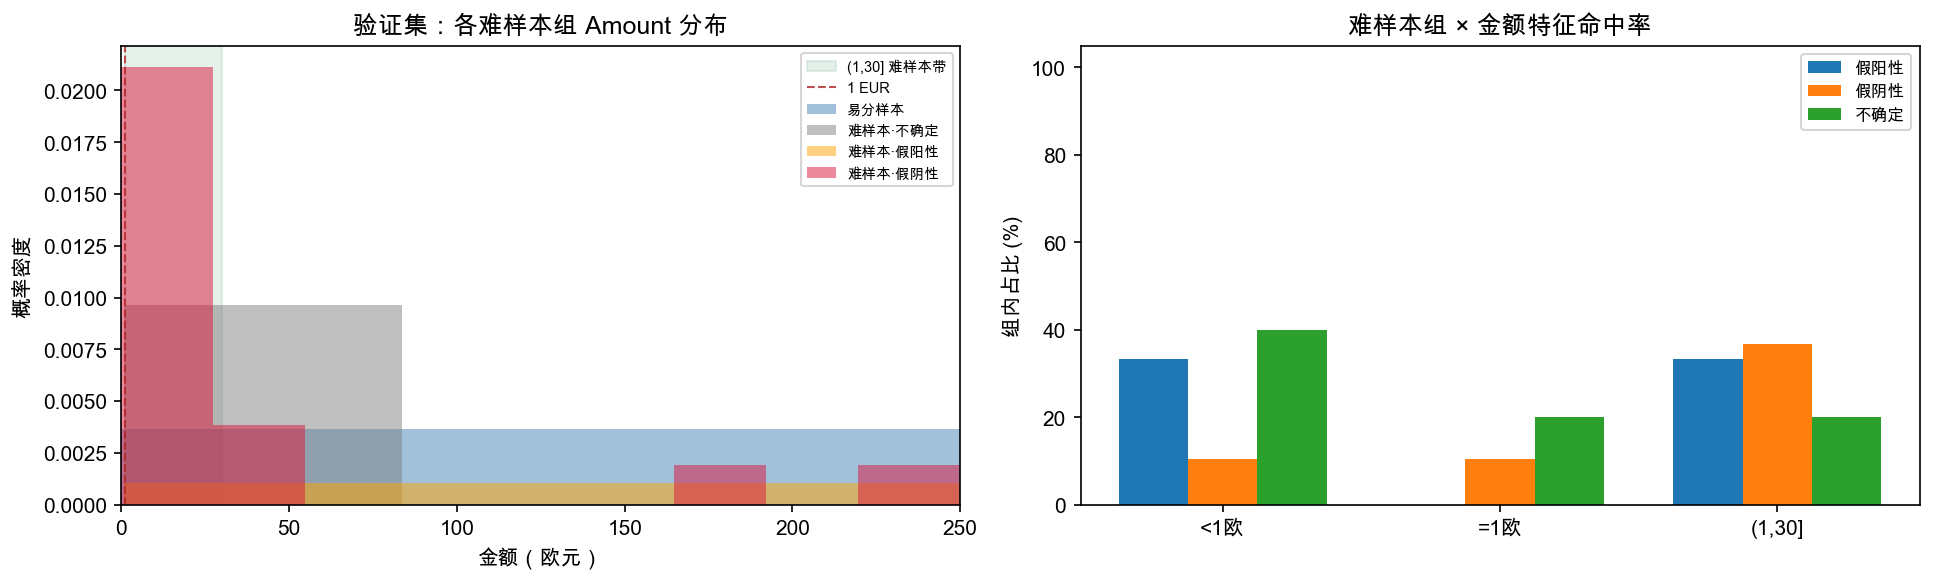


难样本驱动的 EDA 特征取舍：


,特征,处置,依据
0,is_inactive,弃用,过粗，训练效果不佳
1,is_small_testing,弃用,过粗，由金额带替代
2,is_one_euro,保留,hard_FP 金额中位数≈1
3,is_amount_1_30,保留,难样本金额带
4,is_amount_75_110,保留,欺诈簇画像 + 全表难样本人工定界（§4）


已更新 EDA_FEATURES（含 is_amount_1_30）→ runtime_state.json


In [41]:
# §3 exec
state = load_state()
BASE_FEATURES = state['BASE_FEATURES']
df = bind_cv_data(build_hard_eda_features(read_creditcard_csv(DATA_PATH)))
res = cross_val_eval('LightGBM', df, BASE_FEATURES)
threshold = res['best_threshold']
print('BASE LightGBM 最优 F1 阈值:', round(threshold, 4))

# 用 purged OOF 概率标注难样本
X, y = df[BASE_FEATURES], df['Class']
oof = np.full(len(y), np.nan)
for fold, (tr, va) in enumerate(iter_purged_cv_folds(len(df)), 1):
    X_tr, y_tr = X.iloc[tr], y.iloc[tr]
    X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=CV_RANDOM_STATE+fold)
    clf = make_classifier('LightGBM', y_fit, random_state=CV_RANDOM_STATE+fold)
    fit_classifier(clf, 'LightGBM', X_fit, y_fit, X_es, y_es)
    oof[va] = clf.predict_proba(X.iloc[va])[:,1]
# hard 标注阈值：cal 段定 t*，避免整份 OOF 同集过拟合
thr = metrics_at_threshold_honest(y, oof)['best_threshold']
UNCERTAIN_BAND = 0.15
tag_hard = make_hard_tagger(thr, uncertain_band=UNCERTAIN_BAND)

df['p_fraud'] = oof
df['hard_tag'] = [tag_hard(p, int(c)) for p, c in zip(df['p_fraud'], df['Class'])]

# 画像用最后一折验证集（对齐 eda 验证集分析）
_, val_idx = list(iter_purged_cv_folds(len(df)))[-1]
val_df = df.iloc[val_idx].copy()
print(f'画像折验证集: {len(val_df):,} 笔 | 难样本 {int((val_df["hard_tag"] != "easy").sum())} 笔')
display(val_df['hard_tag'].value_counts().to_frame('样本数'))

profile_val = build_hard_profile_table(val_df)
profile_val.to_csv(OUT_HARD / 'hard_sample_profile.csv', index=False, encoding='utf-8-sig')
display(profile_val)

fn_med = val_df.loc[val_df['hard_tag'] == 'hard_FN', 'Amount'].median()
fp_med = val_df.loc[val_df['hard_tag'] == 'hard_FP', 'Amount'].median()
print(f'hard_FN Amount 中位数: {fn_med:.2f} | hard_FP Amount 中位数: {fp_med:.2f}')
print('结论: hard_FP 多集中在 1 EUR → is_one_euro；hard_FN 分散于 (1,30] → is_amount_1_30；[75,110] 见 §4（欺诈簇+全表难样本人工定界）')

for tag in ['hard_FP', 'hard_FN', 'hard_uncertain']:
    sub = df[df['hard_tag'] == tag]
    sub.to_csv(OUT_HARD / f'{tag}_samples.csv', index=False, encoding='utf-8-sig')

plot_hard_amount_figure(val_df, out_path=OUT_HARD / 'hard_amount.png')

# 供 §4 画像投影使用
hard_export = df[df['hard_tag'] != 'easy'][['Time', 'Class', 'hard_tag', 'Amount', 'p_fraud'] + state['V_COLS'][:5]].copy()
hard_export.to_pickle(OUT_HARD / 'hard_samples_for_portrait.pkl')
df[['Time', 'Class', 'hard_tag', 'p_fraud']].to_pickle(OUT_HARD / 'hard_tags_all.pkl')
feature_decisions = pd.DataFrame([
    {'特征': 'is_inactive', '处置': '弃用', '依据': '过粗，训练效果不佳'},
    {'特征': 'is_small_testing', '处置': '弃用', '依据': '过粗，由金额带替代'},
    {'特征': 'is_one_euro', '处置': '保留', '依据': 'hard_FP 金额中位数≈1'},
    {'特征': 'is_amount_1_30', '处置': '保留', '依据': '难样本金额带'},
    {'特征': 'is_amount_75_110', '处置': '保留', '依据': '欺诈簇画像 + 全表难样本人工定界（§4）'},
])
feature_decisions.to_csv(OUT_HARD / 'hard_feature_decisions.csv', index=False, encoding='utf-8-sig')
print('\n难样本驱动的 EDA 特征取舍：')
display(feature_decisions)

save_state(EDA_FEATURES=EDA_FEATURES)
print('已更新 EDA_FEATURES（含 is_amount_1_30）→ runtime_state.json')


### Family A 门控交叉特征

使用 `is_one_euro` 与对预测结果作用最显著的两个 V 特征进行特征交叉。  
曾取排名前六的 V 特征进行交叉，后实验证明排名前二的 V 特征一起用效果最好（具体可参考 FE1-FE6 的实验）

In [7]:
# §3.1 prep
TOP_V_K = 2


def pick_top_v_features(data, feature_cols, k=TOP_V_K, model_name='LightGBM', random_state=CV_RANDOM_STATE):
    data = sort_by_time(data)
    n = len(data)
    test_size = max(1, n // (CV_N_SPLITS + 1))
    tr_idx = np.arange(0, n - test_size)
    X_tr, y_tr = data.iloc[tr_idx][feature_cols], data.iloc[tr_idx]['Class']
    X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state)
    clf = make_classifier(model_name, y_fit, random_state=random_state)
    fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
    v_cols = [c for c in feature_cols if c.startswith('V')]
    imp = pd.Series(clf.feature_importances_, index=feature_cols)
    top_v = list(imp[v_cols].sort_values(ascending=False).head(k).index)
    print(f'Top-{k} V ({model_name} gain): {top_v}')
    return top_v


def build_cross_features(data, top_v, gate_col='is_one_euro', prefix='one_euro'):
    out = data.copy()
    gate = out[gate_col].astype(float)
    new_cols = []
    for v in top_v:
        name = f'{prefix}_{v}'
        out[name] = gate * out[v]
        new_cols.append(name)
    return out, new_cols


In [43]:
# §3.1 exec：写入 Family A 特征列到特征表
state = load_state()
df = bind_cv_data(build_hard_eda_features(read_creditcard_csv(DATA_PATH)))
BASE_FEATURES = state['BASE_FEATURES']
top_v = pick_top_v_features(df, BASE_FEATURES, k=TOP_V_K)
df, cross_family_a = build_cross_features(df, top_v, gate_col='is_one_euro', prefix='one_euro')

save_state(
    CROSS_FAMILY_A=cross_family_a,
    A_TOP2=list(cross_family_a[:TOP_V_K]),
    A1_COL=cross_family_a[0],
)
df.to_pickle(OUTPUT_DIR / 'df_modeling.pkl')
print('Family A 列:', cross_family_a)
print('已保存 →', OUTPUT_DIR / 'df_modeling.pkl')


Top-2 V (LightGBM gain): ['V14', 'V4']
Family A 列: ['one_euro_V14', 'one_euro_V4']
已保存 → /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/final_report/df_modeling.pkl


## 4. 欺诈模式 / 画像

参考：[`eda/credit-fraud-eda.ipynb`](eda/credit-fraud-eda.ipynb) §3.1–3.2、[`credit-fraud-feature-engineering-summary-report.ipynb`](feature-engineering-report/credit-fraud-feature-engineering-summary-report.ipynb) §4。

### 做了什么
- KMeans 肘部图
- 欺诈样本 PCA（按簇着色）
- 全表 PCA：欺诈 vs 正常
- 欺诈簇 Amount 画像
- 金额带欺诈率 / 覆盖
- 难样本 PCA 投影

### 结论
肘部不明显；欺诈簇边界模糊；正常/欺诈 PCA 重叠严重 → **分簇子模型收益有限**。  

#### `[75,110]` 区间怎么定的？

`is_amount_75_110` **不是**从某一欺诈簇的金额分布直接划出来的，而是 **人工综合** 两条线索后定的工程化区间：

1. **欺诈画像（本节）**：KMeans 后查看发现主簇 Amount 中位数 ~60、均值 ~95，提示存在**中额欺诈集中区**（特征是欺诈发生率低于基线，但因为金额区间覆盖范围大，实际落入其中的欺诈样本绝对数量不算少）。
2. **难样本人工核对（§3 + 早期实验）**：把 **全表难样本**中（`hard_FP` CSV，见 `03_hard_samples/`）逐笔核对 Amount，与簇画像交叉验证，再取 `[75,110]` 作为中额带。以降低 FP（误报）为导向。

输出：`04_fraud_portrait/`

In [8]:
# §4 prep：欺诈画像分析后增补 is_amount_75_110
def build_final_eda_features(data: pd.DataFrame) -> pd.DataFrame:
    """§1.1 + §3 + §4 定稿后的完整 EDA 候选特征（6 列）。"""
    out = data.copy()
    out['log1p_amount'] = np.log1p(out['Amount'])
    out['hours_since_start'] = (out['Time'] // 3600).astype(int)
    out['is_micro_testing'] = out['Amount'] < 1
    out['is_one_euro'] = out['Amount'] == 1.0
    out['is_amount_1_30'] = (out['Amount'] > 1) & (out['Amount'] <= 30)
    out['is_amount_75_110'] = (out['Amount'] >= 75) & (out['Amount'] <= 110)
    return out


EDA_FEATURES = [
    'log1p_amount', 'hours_since_start', 'is_micro_testing', 'is_one_euro',
    'is_amount_1_30', 'is_amount_75_110',
]


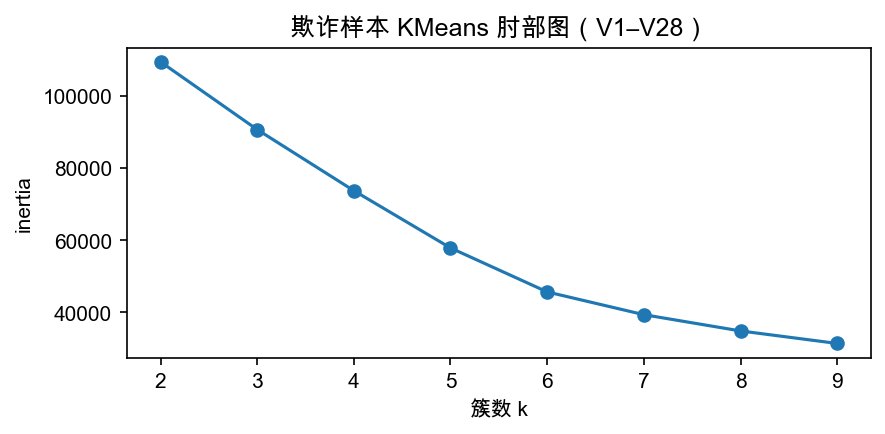

,样本数,Amount中位数,Amount均值,hours_since_start中位数
fraud_cluster,,,,
0,160,7.96,103.47,23.0
1,14,1.00,2.31,26.5
2,219,8.00,158.44,21.0
3,93,59.68,95.01,11.0
4,6,1.00,1.00,18.0


欺诈主簇（参考）: 簇2 | n=219 | 中位数 8.00 | 均值 158.44


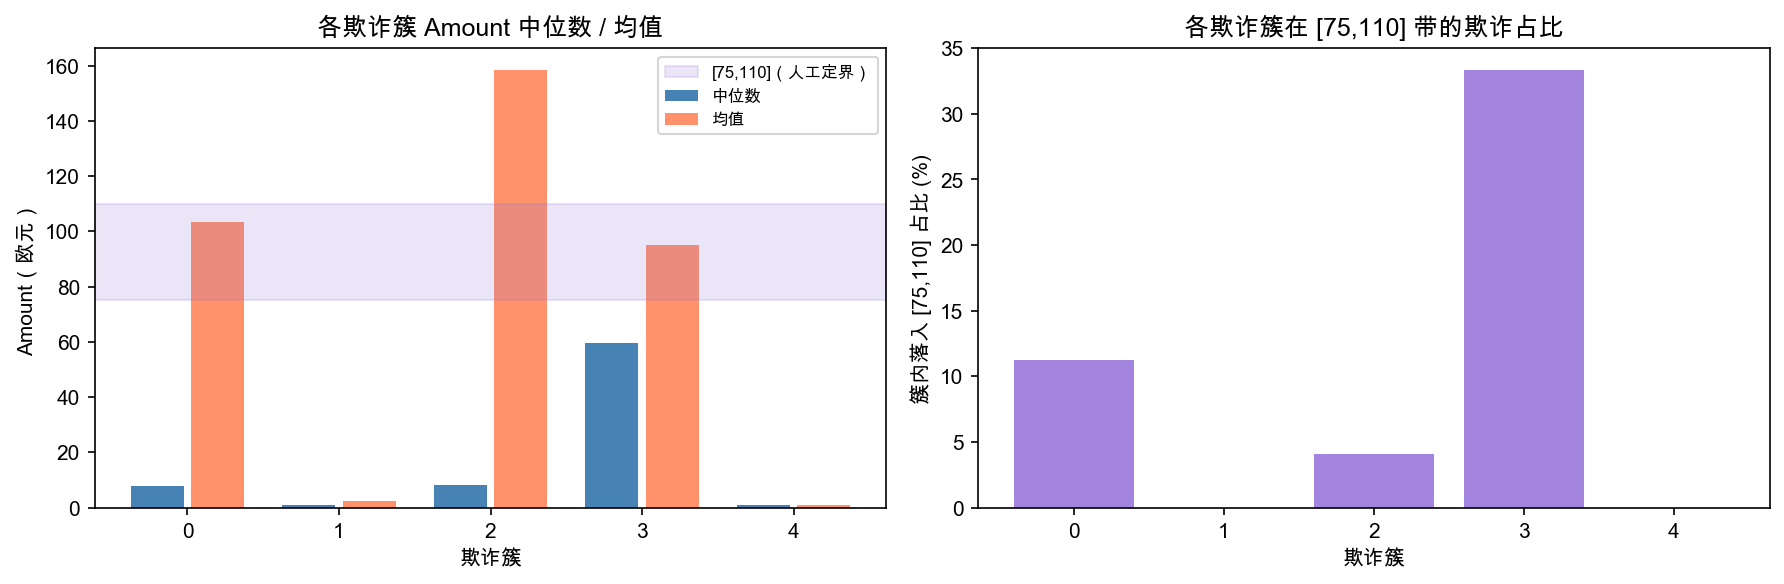

,金额带,样本数,欺诈笔数,欺诈率,相对基线倍数,占全表欺诈(%)
0,"(1,30]",130588,96,0.00074,0.43,19.51
1,"[75,110]",20464,58,0.00283,1.64,11.79


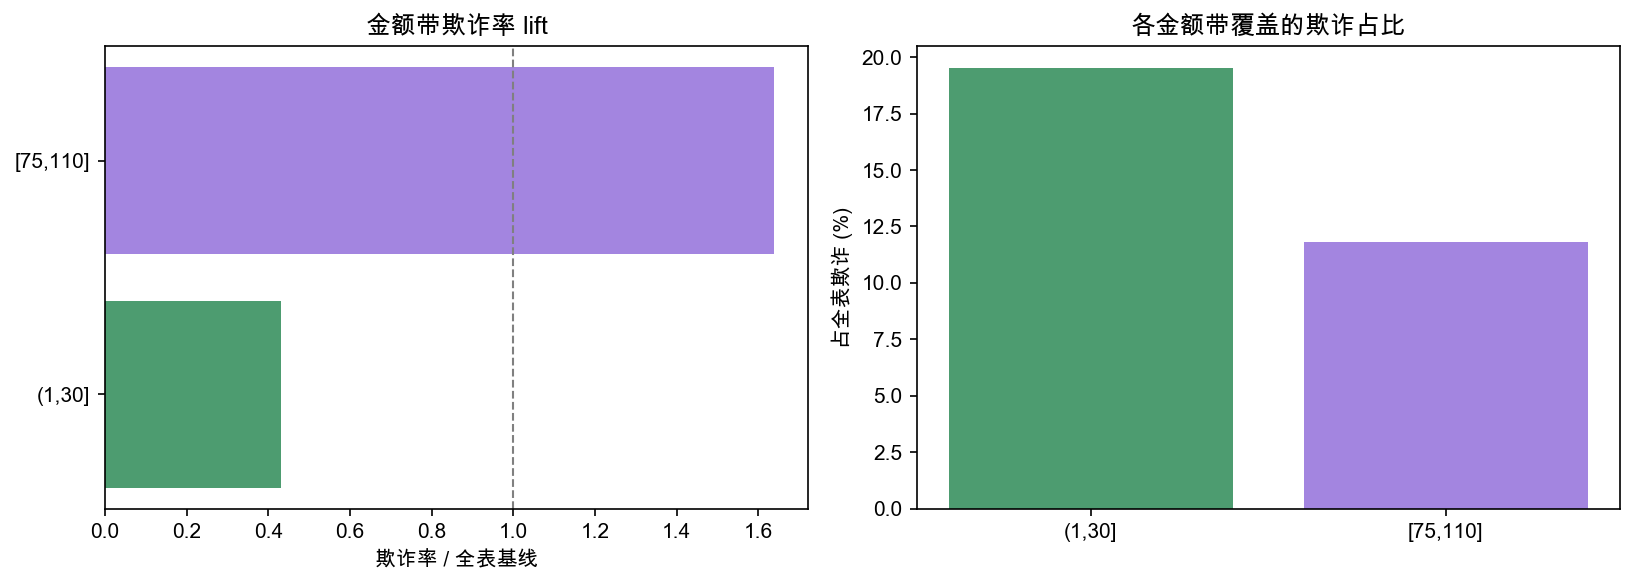

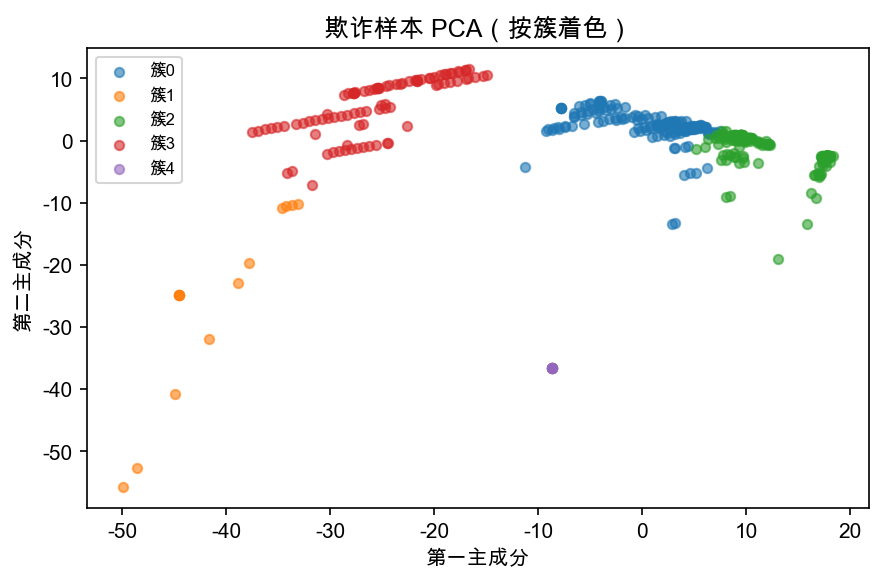

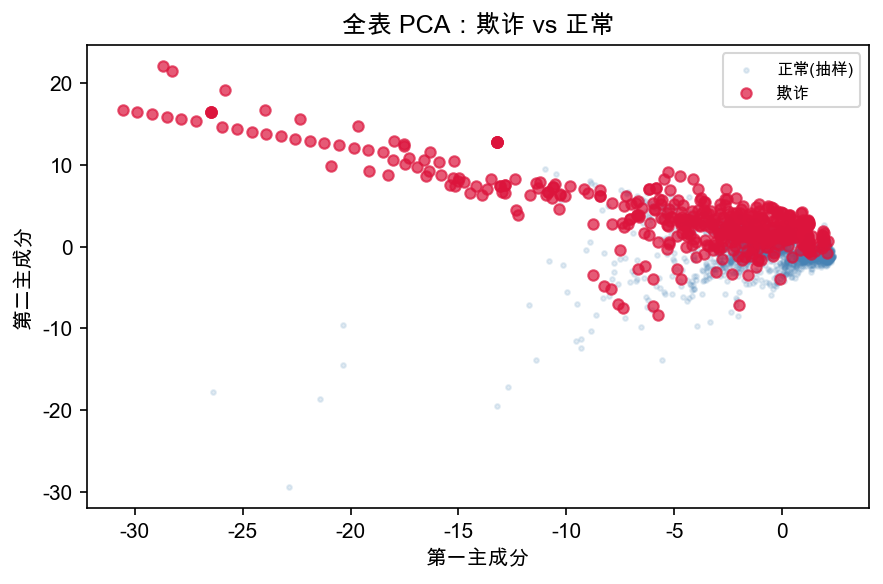

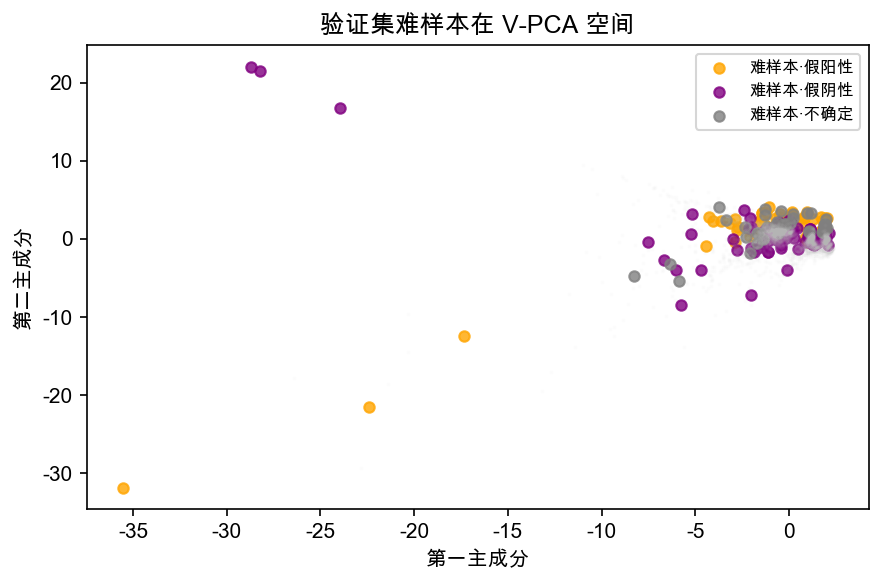

结论：肘部不明显；欺诈簇边界模糊；正常/欺诈 PCA 重叠严重 → 不新增聚类特征
已保存 → /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/final_report/04_fraud_portrait
已更新 EDA_FEATURES（含 is_amount_75_110）→ runtime_state.json
已回写 → /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/final_report/df_modeling.pkl


In [45]:
OUT_PORTRAIT = OUTPUT_DIR / '04_fraud_portrait'
OUT_PORTRAIT.mkdir(parents=True, exist_ok=True)

# §4 exec：欺诈 PCA / KMeans 画像（对齐 summary-report §4 + eda §3.1）
state = load_state()
df = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_modeling.pkl'))
if 'is_amount_75_110' not in df.columns:
    df = build_final_eda_features(df)
V_COLS = state['V_COLS']
setup_chinese_font()

fraud_df = df[df['Class'] == 1].copy()
X_fraud_v = fraud_df[V_COLS]

# --- 肘部图（report: kmeans_elbow.png）---
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_fraud_v)
    inertias.append(km.inertia_)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(2, 10), inertias, 'o-')
ax.set_xlabel('簇数 k'); ax.set_ylabel('inertia')
ax.set_title('欺诈样本 KMeans 肘部图（V1–V28）')
fig.tight_layout()
save_show_fig(fig, OUT_PORTRAIT / 'kmeans_elbow.png', dpi=150)

FRAUD_K = 5
km_fraud = KMeans(n_clusters=FRAUD_K, random_state=42, n_init=10)
fraud_df['fraud_cluster'] = km_fraud.fit_predict(X_fraud_v)
cluster_profile = fraud_df.groupby('fraud_cluster').agg(
    样本数=('Class', 'count'), Amount中位数=('Amount', 'median'),
    Amount均值=('Amount', 'mean'), hours_since_start中位数=('hours_since_start', 'median'),
).round(2)
cluster_profile.to_csv(OUT_PORTRAIT / 'fraud_cluster_profile.csv', index=False, encoding='utf-8-sig')
display(cluster_profile)

# --- 欺诈簇 Amount 画像（[75,110] 的参考输入之一，见 §4 文字说明）---
main_cluster = int(cluster_profile['样本数'].idxmax())
print(
    f'欺诈主簇（参考）: 簇{main_cluster} | n={int(cluster_profile.loc[main_cluster, "样本数"])}'
    f' | 中位数 {cluster_profile.loc[main_cluster, "Amount中位数"]:.2f}'
    f' | 均值 {cluster_profile.loc[main_cluster, "Amount均值"]:.2f}'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cp = cluster_profile.reset_index()
x = cp['fraud_cluster']
axes[0].bar(x - 0.2, cp['Amount中位数'], width=0.35, label='中位数', color='steelblue')
axes[0].bar(x + 0.2, cp['Amount均值'], width=0.35, label='均值', color='coral', alpha=0.85)
axes[0].axhspan(75, 110, alpha=0.18, color='mediumpurple', label='[75,110]（人工定界）')
axes[0].set_xticks(x)
axes[0].set_xlabel('欺诈簇'); axes[0].set_ylabel('Amount（欧元）')
axes[0].set_title('各欺诈簇 Amount 中位数 / 均值')
axes[0].legend(fontsize=8)

pct_in_band = fraud_df.groupby('fraud_cluster')['is_amount_75_110'].mean() * 100
axes[1].bar(pct_in_band.index, pct_in_band.values, color='mediumpurple', alpha=0.85)
axes[1].set_xlabel('欺诈簇'); axes[1].set_ylabel('簇内落入 [75,110] 占比 (%)')
axes[1].set_title('各欺诈簇在 [75,110] 带的欺诈占比')
fig.tight_layout()
save_show_fig(fig, OUT_PORTRAIT / 'fraud_cluster_amount.png', dpi=150)

# --- 全表金额带：欺诈率 lift + 欺诈覆盖 ---
baseline_rate = df['Class'].mean()
total_fraud = int(df['Class'].sum())
band_specs = [
    ('(1,30]', 'is_amount_1_30', 'seagreen'),
    ('[75,110]', 'is_amount_75_110', 'mediumpurple'),
]
band_rows = []
for label, col, _ in band_specs:
    sub = df[df[col]]
    fr = sub['Class'].mean()
    band_rows.append({
        '金额带': label,
        '样本数': len(sub),
        '欺诈笔数': int(sub['Class'].sum()),
        '欺诈率': round(fr, 5),
        '相对基线倍数': round(fr / baseline_rate, 2),
        '占全表欺诈(%)': round(sub['Class'].sum() / total_fraud * 100, 2),
    })
band_lift = pd.DataFrame(band_rows)
band_lift.to_csv(OUT_PORTRAIT / 'fraud_amount_band_lift.csv', index=False, encoding='utf-8-sig')
display(band_lift)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(band_lift['金额带'], band_lift['相对基线倍数'], color=['seagreen', 'mediumpurple'], alpha=0.85)
axes[0].axvline(1.0, color='gray', ls='--', lw=1)
axes[0].set_xlabel('欺诈率 / 全表基线')
axes[0].set_title('金额带欺诈率 lift')

axes[1].bar(band_lift['金额带'], band_lift['占全表欺诈(%)'], color=['seagreen', 'mediumpurple'], alpha=0.85)
axes[1].set_ylabel('占全表欺诈 (%)')
axes[1].set_title('各金额带覆盖的欺诈占比')
fig.tight_layout()
save_show_fig(fig, OUT_PORTRAIT / 'fraud_amount_band_lift.png', dpi=150)

# --- 欺诈样本 PCA 按簇着色（report: fraud_pca.png）---
pca_fraud = PCA(n_components=2, random_state=42).fit_transform(X_fraud_v)
fig, ax = plt.subplots(figsize=(6, 4))
for c in range(FRAUD_K):
    mask = fraud_df['fraud_cluster'] == c
    ax.scatter(pca_fraud[mask, 0], pca_fraud[mask, 1], alpha=0.6, s=20, label=f'簇{c}')
ax.set_xlabel('第一主成分'); ax.set_ylabel('第二主成分')
ax.set_title('欺诈样本 PCA（按簇着色）'); ax.legend(fontsize=8)
fig.tight_layout()
save_show_fig(fig, OUT_PORTRAIT / 'fraud_pca.png', dpi=150)

# --- 全表 PCA：欺诈 vs 正常（report: normal_fraud_pca.png）---
sample_normal = df[df['Class'] == 0].sample(n=5000, random_state=42)
pca_all = PCA(n_components=2, random_state=42)
pca_all.fit(df[V_COLS])
fraud_xy = pca_all.transform(fraud_df[V_COLS])
normal_xy = pca_all.transform(sample_normal[V_COLS])
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(normal_xy[:, 0], normal_xy[:, 1], alpha=0.15, s=5, c='steelblue', label='正常(抽样)')
ax.scatter(fraud_xy[:, 0], fraud_xy[:, 1], alpha=0.7, s=25, c='crimson', label='欺诈')
ax.set_xlabel('第一主成分'); ax.set_ylabel('第二主成分')
ax.set_title('全表 PCA：欺诈 vs 正常'); ax.legend(fontsize=8)
fig.tight_layout()
save_show_fig(fig, OUT_PORTRAIT / 'normal_fraud_pca.png', dpi=150)

# --- 难样本在 PCA 平面（eda §3.2 左图，需先跑 §3）---
hard_pkl = OUT_HARD / 'hard_tags_all.pkl'
if hard_pkl.exists():
    tags = pd.read_pickle(hard_pkl)
    plot_df = df.loc[tags.index].copy()
    plot_df['hard_tag'] = tags['hard_tag'].values
    hc = pca_all.transform(plot_df[V_COLS])
    fig, ax = plt.subplots(figsize=(6, 4))
    for tag, color, cn in HARD_PCA_LEGEND:
        m = plot_df['hard_tag'] == tag
        if m.any():
            ax.scatter(hc[m, 0], hc[m, 1], s=25, alpha=0.8, label=cn, c=color)
    ax.scatter(normal_xy[:, 0], normal_xy[:, 1], s=1, alpha=0.03, c='lightgray')
    ax.set_xlabel('第一主成分'); ax.set_ylabel('第二主成分')
    ax.set_title('验证集难样本在 V-PCA 空间'); ax.legend(fontsize=8)
    fig.tight_layout()
    save_show_fig(fig, OUT_PORTRAIT / 'pca_hard_samples.png', dpi=150)
else:
    print('提示：先运行 §3 以生成难样本 PCA 投影图')

print('结论：肘部不明显；欺诈簇边界模糊；正常/欺诈 PCA 重叠严重 → 不新增聚类特征')
print('已保存 →', OUT_PORTRAIT)

save_state(EDA_FEATURES=EDA_FEATURES)
df.to_pickle(OUTPUT_DIR / 'df_modeling.pkl')
print('已更新 EDA_FEATURES（含 is_amount_75_110）→ runtime_state.json')
print('已回写 →', OUTPUT_DIR / 'df_modeling.pkl')


## 1-4 定稿候选特征簇说明

探索性数据分析 + 难样本分析 + 欺诈画像之后，进入建模前的 **候选特征簇** 总览。

| 候选簇 | 特征 | 含义 |
| --- | --- | --- |
| BASE | V1–V28, Amount, Time | Kaggle 原始匿名 PCA 变量 + 原始金额/时间；所有实验的共同底座。 |
| EDA 事实特征 | log1p_amount | 金额分布显著不同，用 log 缩放保留金额尺度，对抗长尾效应。 |
| EDA 事实特征 | hours_since_start | 相对首笔交易的小时数；时间桶欺诈率存在聚集。 |
| EDA 事实特征 | is_micro_testing | Amount < 1，超小额卡测试信号。 |
| EDA 事实特征 | is_small_testing ❌ | 早期定义为 1 < Amount <= 20；后续发现效果不稳定，改为1 < Amount <= 5，仍不行。最终被难样本金额带特征取代。 |
| EDA 事实特征 | is_one_euro | Amount == 1.0；小额卡测试经典金额，特征交叉的基石。 |
| EDA 事实特征 | is_inactive ❌ | 低交易量小时桶；过粗且训练效果不佳，未进最终。 |
| 难样本金额带 | is_amount_1_30 | 从 hard sample 观察扩展出的中小额难样本带。 |
| 中额金额带 | is_amount_75_110 | **人工定界**：欺诈簇 Amount 画像 + 早期实验打印的全表难样本逐笔核对 |
| Family A 系列交叉特征 | one_euro_V14, one_euro_V4, ... | `is_one_euro × Top-V`（对分类贡献较大的一些 V 特征）。在 1 EUR 子空间内让一些高增益的 V 特征发挥作用；最终 A_top2 = V14, V4 特征与 one_euro 的交叉，且效果好于 A_top3, A_top4... |
| OOF Autoencoder | ae_oof_error | 使用 AutoEncoder 训练误差异常分；其结果不稳定，最终不用。 |
| OOF Isolation Forest | if_oof_score | 使用 Isolation Forest 训练误差异常分。每折只用训练折正常样本拟合 IF，再给验证折打分，防止泄露；效果明显，最终保留。 |

In [9]:
# 候选特征簇目录（summary-report §5）→ CSV 副本
candidate_clusters = pd.DataFrame([
    {'候选簇': 'BASE', '特征': 'V1–V28, Amount, Time', '含义': 'Kaggle 原始匿名 PCA 变量 + 原始金额/时间；所有实验的共同底座。'},
    {'候选簇': 'EDA 事实特征', '特征': 'log1p_amount', '含义': '金额分布显著不同，用 log 缩放保留金额尺度，对抗长尾效应。'},
    {'候选簇': 'EDA 事实特征', '特征': 'hours_since_start', '含义': '相对首笔交易的小时数；时间桶欺诈率存在聚集。'},
    {'候选簇': 'EDA 事实特征', '特征': 'is_micro_testing', '含义': 'Amount < 1，超小额卡测试信号。'},
    {'候选簇': 'EDA 事实特征', '特征': 'is_small_testing', '含义': '早期定义为 1 < Amount <= 20；后改 1 < Amount <= 5，仍不行。'},
    {'候选簇': 'EDA 事实特征', '特征': 'is_one_euro', '含义': 'Amount == 1.0；小额卡测试经典金额，特征交叉的基石。'},
    {'候选簇': 'EDA 事实特征', '特征': 'is_inactive', '含义': '低交易量小时桶；过粗且不稳定，未进最终。'},
    {'候选簇': '难样本金额带', '特征': 'is_amount_1_30', '含义': '从 hard sample 扩展的中小额难样本带。'},
    {'候选簇': '中额金额带', '特征': 'is_amount_75_110', '含义': '人工定界：欺诈簇画像 + 全表难样本逐笔核对。'},
    {'候选簇': 'Family A 交叉特征', '特征': 'one_euro_V14, one_euro_V4, ...', '含义': 'is_one_euro × Top-V；最终 A_top2 = V14, V4。'},
    {'候选簇': 'OOF Autoencoder', '特征': 'ae_oof_error', '含义': 'AE 训练误差异常分；不稳定，最终不用。'},
    {'候选簇': 'OOF Isolation Forest', '特征': 'if_oof_score', '含义': 'IF OOF 异常分；每折仅用训练折正常样本拟合，效果明显，最终保留。'},
])
candidate_clusters.to_csv(OUT_EDA / 'eda_candidate_clusters.csv', index=False, encoding='utf-8-sig')
display(candidate_clusters)
print('已保存 →', OUT_EDA / 'eda_candidate_clusters.csv')


,候选簇,特征,含义
0,BASE,"V1–V28, Amount, Time",Kaggle 原始匿名 PCA 变量 + 原始金额/时间；所有实验的共同底座。
1,EDA 事实特征,log1p_amount,金额分布显著不同，用 log 缩放保留金额尺度，对抗长尾效应。
2,EDA 事实特征,hours_since_start,相对首笔交易的小时数；时间桶欺诈率存在聚集。
3,EDA 事实特征,is_micro_testing,Amount < 1，超小额卡测试信号。
4,EDA 事实特征,is_small_testing,早期定义为 1 < Amount <= 20；后改 1 < Amount <= 5，仍不行。
5,EDA 事实特征,is_one_euro,Amount == 1.0；小额卡测试经典金额，特征交叉的基石。
6,EDA 事实特征,is_inactive,低交易量小时桶；过粗且不稳定，未进最终。
7,难样本金额带,is_amount_1_30,从 hard sample 扩展的中小额难样本带。
8,中额金额带,is_amount_75_110,人工定界：欺诈簇画像 + 全表难样本逐笔核对。
9,Family A 交叉特征,"one_euro_V14, one_euro_V4, ...","is_one_euro × Top-V；最终 A_top2 = V14, V4。"


已保存 → /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/01_eda/eda_candidate_clusters.csv


## 5. Focal Loss 与模糊样本加权

参考：[`eda/credit-fraud-eda.ipynb`](eda/credit-fraud-eda.ipynb) §2.2c、[`credit-fraud-feature-engineering-7.ipynb`](feature-engineering/credit-fraud-feature-engineering-7.ipynb) §6.5（区别是本节使用 **BASE 特征组**）。

---

### ⛔ 默认不执行 — 开关在 **§5 prep**

| 开关 | 默认 | 不选用原因（显著） |
|------|------|-------------------|
| `RUN_FOCAL_LOSS` | False | 效果 **≈ scale_pos_weight / 类别权重**，未带来稳定 AUC-PR 增益 |
| `RUN_FUZZY_WEIGHT` | False | OOF 模糊带加权网格 **整体提升几乎没有** |

### 二者动机
1. **Focal Loss**：针对 **极度不均衡数据集** 的梯度重加权尝试  
2. **模糊样本加权**：防止「模型排序能力尚可但概率挤在阈值附近」→ **防止正负样本区分度差，模型能力上限不高的尝试**

改为 `True` 可跑对比表至 `05_focal_fuzzy/`。

In [8]:
OUT_FOCAL = OUTPUT_DIR / '05_focal_fuzzy'
OUT_FOCAL.mkdir(parents=True, exist_ok=True)

# 可选实验（默认关闭，原因见本节 markdown）
RUN_FOCAL_LOSS = False
RUN_FUZZY_WEIGHT = False
QUICK_ABLATION = False  # True → §7 仅跑基线+IF 代表组合


# §5 prep
FOCAL_GAMMA = 2.0


def _focal_grad_hess(y_true, y_pred):
    y = y_true.astype(float)
    p = 1.0 / (1.0 + np.exp(-y_pred))
    pt = np.where(y == 1, p, 1 - p)
    w = (1 - pt) ** FOCAL_GAMMA
    grad = w * (p - y)
    hess = w * p * (1 - p)
    return grad, hess


def cross_val_focal(model_name, data, feature_cols, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    """Focal Loss CV 基线（效果通常 ≈ scale_pos_weight）。"""
    X, y = data[feature_cols], data['Class']
    fold_ap = []
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(len(X), n_splits=n_splits), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state + fold)
        if model_name == 'LightGBM':
            clf = lgb.LGBMClassifier(objective=_focal_grad_hess, n_estimators=500, random_state=random_state + fold, verbose=-1)
            clf.fit(X_fit, y_fit, eval_set=[(X_es, y_es)], eval_metric='binary_logloss',
                    callbacks=[lgb.early_stopping(50, verbose=False)])
        else:
            clf = make_classifier(model_name, y_fit, random_state=random_state + fold)
            fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba = clf.predict_proba(X_va)[:, 1]
        fold_ap.append(float(average_precision_score(y_va, proba)))
    return float(np.mean(fold_ap))


def _split_early_stop_set_weighted(X_tr, y_tr, sample_weight=None, es_frac=ES_FRAC, random_state=CV_RANDOM_STATE):
    if sample_weight is None:
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, es_frac=es_frac, random_state=random_state)
        return X_fit, X_es, y_fit, y_es, None, None
    X_fit, X_es, y_fit, y_es, sw_fit, sw_es = train_test_split(
        X_tr, y_tr, np.asarray(sample_weight, dtype=float),
        test_size=es_frac, random_state=random_state, stratify=y_tr,
    )
    return X_fit, X_es, y_fit, y_es, sw_fit, sw_es


def fit_classifier_with_sample_weight(clf, model_name, X_tr, y_tr, sample_weight=None, X_es=None, y_es=None):
    fit_kwargs = {}
    if sample_weight is not None:
        fit_kwargs['sample_weight'] = sample_weight
    if X_es is None or y_es is None:
        clf.fit(X_tr, y_tr, **fit_kwargs)
        return clf
    if model_name == 'LightGBM':
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], eval_metric='binary_logloss',
                callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)], **fit_kwargs)
    else:
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False, **fit_kwargs)
    return clf


def get_oof_proba_for_data(model_name, data, feature_cols, params=None, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)
    covered = np.zeros(len(y), dtype=bool)
    for inner_fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(len(data), n_splits=n_splits, data=data), start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state + inner_fold)
        clf = make_classifier(model_name, y_fit, params=params, random_state=random_state + inner_fold)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        oof[va_idx] = clf.predict_proba(X.iloc[va_idx])[:, 1]
        covered[va_idx] = True
    return oof, covered


def build_ambiguity_oof_cache(model_name, data, feature_cols, params=None, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    cache = []
    for outer_fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(len(data), n_splits=n_splits, data=data), start=1):
        train_df = data.iloc[tr_idx].reset_index(drop=True)
        train_oof, train_oof_covered = get_oof_proba_for_data(
            model_name, train_df, feature_cols, params=params, n_splits=n_splits,
            random_state=random_state + 100 * outer_fold,
        )
        cache.append({'outer_fold': outer_fold, 'tr_idx': tr_idx, 'va_idx': va_idx,
                      'train_oof': train_oof, 'train_oof_covered': train_oof_covered})
        print(f'  [{model_name}] 模糊样本 OOF cache fold {outer_fold}/{n_splits}')
    return cache


def weighted_cv_eval_from_cache(model_name, data, feature_cols, ambiguity_cache, proba_band, ambiguous_weight,
                                params=None, random_state=CV_RANDOM_STATE, use_sample_weight=True):
    low, high = (np.nan, np.nan) if not use_sample_weight else proba_band
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)  # 未覆盖 OOF 位保持 NaN；best_f1_threshold 已 isfinite 掩码
    fold_ap, fold_ll = [], []
    for item in ambiguity_cache:
        tr_idx, va_idx = item['tr_idx'], item['va_idx']
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]
        covered_mask = item.get('train_oof_covered', np.ones(len(tr_idx), dtype=bool))
        if use_sample_weight:
            train_oof = item['train_oof']
            ambiguous_mask = covered_mask & (train_oof >= low) & (train_oof <= high)
            sw = np.ones(len(tr_idx), dtype=float)
            sw[ambiguous_mask] = ambiguous_weight
        else:
            sw = None
        X_fit, X_es, y_fit, y_es, sw_fit, _ = _split_early_stop_set_weighted(
            X_tr, y_tr, sample_weight=sw, random_state=random_state + item['outer_fold'])
        clf = make_classifier(model_name, y_fit, params=params, random_state=random_state + item['outer_fold'])
        fit_classifier_with_sample_weight(clf, model_name, X_fit, y_fit, sample_weight=sw_fit, X_es=X_es, y_es=y_es)
        proba_va = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba_va
        fold_ap.append(float(average_precision_score(y_va, proba_va)))
        fold_ll.append(float(log_loss(y_va, proba_va, labels=[0, 1])))
    # 与 cross_val_eval 相同：cal 定阈，eval 报 F1
    m = metrics_at_threshold_honest(y, oof)
    thr = m['best_threshold']
    f1 = m[F1_COMBO_COL]
    return {
        'model': model_name, 'band_low': low, 'band_high': high, 'ambiguous_weight': ambiguous_weight,
        'AUC-PR_mean': float(np.mean(fold_ap)), 'logloss_mean': float(np.mean(fold_ll)),
        F1_COMBO_COL: float(f1), F1_BASE_COL: float(f1), F1_COMBO_COL: float(f1),
        'FP': m['FP'], 'FN': m['FN'],
        'strategy': 'ambiguous_weighted' if use_sample_weight else 'base_unweighted',
    }


def run_ambiguous_weight_grid(data, feature_cols, bands=None, weight_grid=None, models=None):
    """OOF 模糊样本加权网格（FE-7 §6.5 流程，本节改用 BASE 特征组）。"""
    bands = bands or [(0.30, 0.70), (0.35, 0.65), (0.40, 0.60)]
    weight_grid = weight_grid or [1.0, 1.25, 1.5, 2.0, 3.0]
    models = models or MODELS
    if QUICK_ABLATION:
        bands, weight_grid, models = [(0.40, 0.60)], [1.0, 2.0], ('LightGBM',)
    rows = []
    for model_name in models:
        print(f'\\n模糊加权网格 — {model_name} @ BASE 特征')
        cache = build_ambiguity_oof_cache(model_name, data, feature_cols)
        rows.append(weighted_cv_eval_from_cache(model_name, data, feature_cols, cache, None, 1.0, use_sample_weight=False))
        for band, w in product(bands, weight_grid):
            if w == 1.0:
                continue
            rows.append(weighted_cv_eval_from_cache(model_name, data, feature_cols, cache, band, w, use_sample_weight=True))
    out = pd.DataFrame(rows).sort_values(['AUC-PR_mean', F1_COMBO_COL], ascending=[False, False]).reset_index(drop=True)
    best = out.iloc[0]
    base = out[out['strategy']=='base_unweighted'].iloc[0]
    print(f"最优: {best['model']} band=[{best['band_low']},{best['band_high']}] w={best['ambiguous_weight']} "
          f"AUC-PR={best['AUC-PR_mean']:.4f} (base {base['AUC-PR_mean']:.4f})")
    return out


In [48]:
state = load_state()
BASE_FEATURES = state['BASE_FEATURES']
df = bind_cv_data(build_final_eda_features(read_creditcard_csv(DATA_PATH)))

if RUN_FOCAL_LOSS:
    rows = []
    for m in MODELS:
        ap = cross_val_focal(m, df, BASE_FEATURES)
        rows.append({'模型': m, 'Focal_AUC-PR': ap})
    focal_df = pd.DataFrame(rows)
    focal_df.to_csv(OUT_FOCAL / 'focal_cv_results.csv', index=False, encoding='utf-8-sig')
    display(focal_df)
else:
    print('⏭️ RUN_FOCAL_LOSS=False：Focal Loss 效果与 scale_pos_weight 近似，未选用。')

if RUN_FUZZY_WEIGHT:
    fuzzy_df = run_ambiguous_weight_grid(df, BASE_FEATURES)
    fuzzy_df.to_csv(OUT_FOCAL / 'fuzzy_weight_grid.csv', index=False, encoding='utf-8-sig')
    display(fuzzy_df)
else:
    print('⏭️ RUN_FUZZY_WEIGHT=False：模糊样本加权对 BASE 特征组提升极其有限，未选用。')


⏭️ RUN_FOCAL_LOSS=False：Focal Loss 效果与 scale_pos_weight 近似，未选用。
⏭️ RUN_FUZZY_WEIGHT=False：模糊样本加权对 BASE 特征组提升极其有限，未选用。


## 6. 异常分特征：Isolation Forest vs Autoencoder

参考：[`credit-fraud-feature-engineering-5.ipynb`](feature-engineering/credit-fraud-feature-engineering-5.ipynb)、[`credit-fraud-feature-engineering-6.ipynb`](feature-engineering/credit-fraud-feature-engineering-6.ipynb)。

### 主路径（执行）
- **purgedcv OOF Isolation Forest** → `if_oof_score`（使用 Isolation Forest 训练误差异常分；每折只用训练折正常样本拟合 IF，再给验证折打分，防止泄露）

### ⛔ AE 默认不执行 — `RUN_AE_ANOMALY=False`

| | IF | AE |
|---|----|----|
| 结论 | **采用** | **不采用** |
| 原因 | 效果好且稳定 | 效果一般、**不如 IF** |

---

输出：`06_if_ae/`、`df_features.pkl`

In [9]:
OUT_ANOMALY = OUTPUT_DIR / '06_if_ae'
OUT_ANOMALY.mkdir(parents=True, exist_ok=True)

IF_RANDOM_STATE = 42
IF_N_ESTIMATORS = 200
IF_MAX_SAMPLES = 0.5
IF_CONTAMINATION = 'auto'
IF_MAX_NORMAL_SAMPLES = 50_000
RUN_AE_ANOMALY = False  # AE 不如 IF，见本节 markdown


# §6 prep：purged OOF IF

def oof_if_anomaly_score(data, feature_cols, random_state=IF_RANDOM_STATE):
    X = data[feature_cols].values.astype(np.float64)
    y = data['Class'].values
    oof = np.full(len(y), np.nan, dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(data=data, n_splits=CV_N_SPLITS), start=1):
        normal_tr = tr_idx[y[tr_idx] == 0]
        if len(normal_tr) > IF_MAX_NORMAL_SAMPLES:
            rng = np.random.default_rng(random_state + fold)
            normal_tr = rng.choice(normal_tr, size=IF_MAX_NORMAL_SAMPLES, replace=False)
        scaler = StandardScaler()
        X_normal = scaler.fit_transform(X[normal_tr])
        X_valid = scaler.transform(X[va_idx])
        iforest = IsolationForest(
            n_estimators=IF_N_ESTIMATORS, max_samples=IF_MAX_SAMPLES,
            contamination=IF_CONTAMINATION, random_state=random_state + fold, n_jobs=-1,
        )
        iforest.fit(X_normal)
        oof[va_idx] = -iforest.score_samples(X_valid)
        print(f'  IF fold {fold}/{CV_N_SPLITS} 完成，正常训练样本={len(normal_tr):,}')
    return oof


def oof_ae_anomaly_score(data, feature_cols, latent_dim=8, random_state=IF_RANDOM_STATE):
    """OOF Autoencoder 重构误差（参考 FE-5；默认不跑）。需 tensorflow。"""
    if tf is None or keras is None:
        raise NotImplementedError('RUN_AE_ANOMALY=True 需要 tensorflow')
    X = data[feature_cols].values.astype(np.float32)
    y = data['Class'].values
    oof = np.full(len(y), np.nan, dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(iter_purged_cv_folds(data=data), start=1):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[tr_idx[y[tr_idx]==0]])  # 仅正常样本训练 AE
        X_va = scaler.transform(X[va_idx])
        inp = keras.Input(shape=(X_tr.shape[1],))
        enc = keras.layers.Dense(16, activation='relu')(inp)
        lat = keras.layers.Dense(latent_dim, activation='relu')(enc)
        dec = keras.layers.Dense(16, activation='relu')(lat)
        out = keras.layers.Dense(X_tr.shape[1], activation='linear')(dec)
        ae = keras.Model(inp, out)
        ae.compile(optimizer='adam', loss='mse')
        ae.fit(X_tr, X_tr, epochs=10, batch_size=256, verbose=0)
        recon = ae.predict(X_va, verbose=0)
        oof[va_idx] = np.mean((X_va - recon) ** 2, axis=1)
        print(f'  AE fold {fold}/{CV_N_SPLITS} 完成')
    return oof


def add_if_gate_feature(data):
    out = data.copy()
    out['if_oof_score_x_one_euro'] = out['if_oof_score'] * out['is_one_euro'].astype(float)
    return out


def append_if_oof_score(df, v_cols=None, compute_if=True, verbose=True):
    """在已有 df_modeling 上追加 purged OOF IF（Family A / EDA 列应已存在）。"""
    state = load_state()
    v_cols = v_cols or state['V_COLS']
    out = df.copy()
    if compute_if:
        if verbose:
            print('开始计算 if_oof_score（purged OOF IF）...')
        out['if_oof_score'] = oof_if_anomaly_score(out, v_cols, random_state=IF_RANDOM_STATE)
        out = add_if_gate_feature(out)
    return out


In [50]:
print('§6 exec：在 df_modeling 上追加 OOF IF...')
state = load_state()
df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_modeling.pkl'))
df_fe = append_if_oof_score(df_fe, compute_if=True)
BASE_FEATURES = state['BASE_FEATURES']
FE_FAMILY_A = state['CROSS_FAMILY_A']
A_TOP2 = state['A_TOP2']
df_fe.to_pickle(OUTPUT_DIR / 'df_features.pkl')
feat_meta = {
    'BASE_FEATURES': BASE_FEATURES,
    'V_COLS': state['V_COLS'],
    'CROSS_FAMILY_A': FE_FAMILY_A,
    'A_TOP2': A_TOP2,
    'A1_COL': state['A1_COL'],
    'n_cols': len(df_fe.columns),
}
(OUTPUT_DIR / 'feature_meta.json').write_text(
    json.dumps({k: v for k, v in feat_meta.items() if isinstance(v, (list, str, int))},
               ensure_ascii=False, indent=2),
    encoding='utf-8',
)

if RUN_AE_ANOMALY:
    print('▶ 运行 OOF Autoencoder（对比用，默认不选用）...')
    try:
        ae_score = oof_ae_anomaly_score(df_fe, feat_meta['V_COLS'])
        df_fe['ae_oof_error'] = ae_score
        pd.DataFrame({'ae_oof_error': ae_score, 'if_oof_score': df_fe['if_oof_score'], 'Class': df_fe['Class']}).describe().to_csv(OUT_ANOMALY / 'ae_vs_if_summary.csv')
        print('AE 已计算；通常不如 IF，见 ae_vs_if_summary.csv')
    except Exception as e:
        print('AE 运行失败:', e)
else:
    print('⏭️ RUN_AE_ANOMALY=False：Autoencoder 效果一般且不如 IF，主流程仅用 if_oof_score。')

if_df = pd.DataFrame({'if_oof_score': df_fe['if_oof_score'], 'Class': df_fe['Class']})
if_df.describe().to_csv(OUT_ANOMALY / 'if_score_summary.csv')
print('IF OOF 完成 | A_top2:', A_TOP2)
print('已保存 →', OUTPUT_DIR / 'df_features.pkl')


§6 exec：在 df_modeling 上追加 OOF IF...
开始计算 if_oof_score（purged OOF IF）...
  IF fold 1/5 完成，正常训练样本=47,326
  IF fold 2/5 完成，正常训练样本=50,000
  IF fold 3/5 完成，正常训练样本=50,000
  IF fold 4/5 完成，正常训练样本=50,000
  IF fold 5/5 完成，正常训练样本=50,000
⏭️ RUN_AE_ANOMALY=False：Autoencoder 效果一般且不如 IF，主流程仅用 if_oof_score。
IF OOF 完成 | A_top2: ['one_euro_V14', 'one_euro_V4']
已保存 → /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/final_report/df_features.pkl


## 7. 特征消融

参考：[`credit-fraud-feature-engineering-3.ipynb`](feature-engineering/credit-fraud-feature-engineering-3.ipynb)、[`credit-fraud-feature-engineering-6.ipynb`](feature-engineering/credit-fraud-feature-engineering-6.ipynb)、[`credit-fraud-feature-engineering-summary-report.ipynb`](feature-engineering-report/credit-fraud-feature-engineering-summary-report.ipynb) §4–§5。  

候选特征消融矩阵由规则 **枚举** 生成。

### 组合规则（相对 `BASE_FEATURES` 的增量列）

每条特征组 = **`if_oof_score`（必选）** + **EDA 子集（可任意组合）** + **Family A 系列交叉特征（三选一）**，外加一行 `0. 基线（仅 BASE）` 作 Δ 参照。

| 块 | 规则 |
|----|------|
| **IF** | 除纯 BASE 外 **必须含 `if_oof_score`**，实验证明有稳定增益。 |
| **EDA** | 5 个 **元素** 任意组合（2⁵=32 种）：`log1p` / `hours` / `one_euro` / `micro` / **`bands`**。`bands` = `is_amount_1_30`+`is_amount_75_110` **成对出现**，禁止拆开。例：`IF+Ed[micro+bands+log1p]`、`IF+Ed[hours+one_euro+bands]+A_top2`。 |
| **Family A** | 仅三档：**无** / **+A1**（`one_euro_V4`）/ **+A_top2**（即`one_euro_V4`和`one_euro_V14`）。无 A_top3、无其它 A 单列。（由FE6 可见其效果不如 A_top2） |

**构造方式**：`32 种 EDA 子集 × 3 档 Family A` 的笛卡尔积（96） + 1 基线 → **97 组**；标签 `IF+Ed[tag1+tag2+…]{+A1|+A_top2(…)}`。

### 如何评价特征消融实验结果？  
为何 AUC-PR 为主、F1 为辅：  
- 银行业务要求打扰率 **FPR≤0.1%** 在后续定稿上已自然满足。不必以此为目标专门优化时，AUC-PR 为主，F1 为辅的策略能找到上限更高的模型
- **AUC-PR**为主：看模型的能力底色（排序正负样本的能力）
- **F1** 辅助：由于存在 AUC-F1 矛盾，且最终落地需要 F1，所以也要参考 F1@combo_t* 指标。鉴于数据集不均衡，欺诈样本数量少，cal 段搜索出的最优阈值 t* 可能在 eval 段表现不好，抖动大。此时可参考 F1@BASE_t* 指标的表现，判断 combo 是 F1 上限真的不好，还是被指标的抖动影响。

展示：Top-15 / 双模型 Δ 表 → `07_ablation/`

In [10]:
OUT_ABLATION = OUTPUT_DIR / '07_ablation'
OUT_ABLATION.mkdir(parents=True, exist_ok=True)

BASELINE_LABEL = '0_BASE'
ABLATION_WINNER_LABEL = 'IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)'  # §7/8 定稿；lookup 经 _normalize_ablation_label
FE_IF = ['if_oof_score']
AMOUNT_BAND_FEATURES = ['is_amount_1_30', 'is_amount_75_110']
ABLATION_EDA_ATOMS = [
    ('log1p', ['log1p_amount']),
    ('hours', ['hours_since_start']),
    ('one_euro', ['is_one_euro']),
    ('micro', ['is_micro_testing']),
    ('bands', list(AMOUNT_BAND_FEATURES)),
]


# §7 prep
FE8_DERIVED_PREFIXES = ('abs_v14_', 'abs_v10_', 'v14_x_', 'v10_x_', 'v4_minus_')


def is_fe8_derived_col(col: str) -> bool:
    return isinstance(col, str) and col.startswith(FE8_DERIVED_PREFIXES)


# 6.4a 全部人为特征组合矩阵（EDA + Family A + OOF IF；purgedcv WalkForwardSplit CV；LGB/XGB 分表）
# =============================================================================

FE_EDA = list(EDA_FEATURES)


def _dedupe_preserve_order(cols: list) -> list:
    seen, out = set(), []
    for c in cols:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out


def _extra_summary(extra_cols: list) -> str:
    if not extra_cols:
        return '—'
    s = ', '.join(extra_cols)
    return s if len(s) <= 72 else s[:69] + '...'


def _dedupe_specs(specs: list[tuple[list, str]]) -> list[tuple[list, str]]:
    seen: set[tuple[str, ...]] = set()
    out: list[tuple[list, str]] = []
    for extra, label in specs:
        key = tuple(_dedupe_preserve_order(extra))
        if key in seen:
            continue
        seen.add(key)
        out.append((list(key), label))
    return out


def iter_ablation_eda_arms():
    """§7：5 个 EDA 原子的全部子集（含空集 = 仅 IF）。"""
    for mask in range(2 ** len(ABLATION_EDA_ATOMS)):
        cols, tags = [], []
        for i, (tag, atom_cols) in enumerate(ABLATION_EDA_ATOMS):
            if mask & (1 << i):
                cols.extend(atom_cols)
                tags.append(tag)
        yield _dedupe_preserve_order(cols), '+'.join(tags) if tags else 'none'


def _atop2_label_suffix(a_top2=None) -> str:
    """与 build_fe_combo_specs 中 A_top2(...) 括号内顺序一致。"""
    if a_top2 is None:
        a_top2 = globals().get('A_TOP2')
        if not a_top2:
            a_top2 = load_state().get('A_TOP2', ['one_euro_V4', 'one_euro_V14'])
    return '+'.join(c.replace('one_euro_', '') for c in a_top2)


def _normalize_ablation_label(label: str, a_top2=None) -> str:
    """把 A_top2(V4+V14) / A_top2(V14+V4) 规范为当前 A_TOP2 列序，避免 specs 查不到。"""
    m = re.search(r'A_top2\(([^)]+)\)', label)
    if not m:
        return label
    canonical = _atop2_label_suffix(a_top2)
    return label[:m.start()] + f'A_top2({canonical})' + label[m.end():]


def build_fe_combo_specs(
    family_a_cols: list,
    fe_if: list | None = None,
) -> list[tuple[list, str]]:
    """
    §7 消融矩阵：IF 必现 + EDA 原子任意子集 × Family A（无 / A1 / A_top2）。
    Ed_bands 为原子级成对列；支持 IF+Ed[micro+bands+log1p] 等多原子叠加。
    """
    fe_if = list(fe_if if fe_if is not None else FE_IF)
    a1_col = family_a_cols[0]
    a_top2 = list(family_a_cols[:TOP_V_K])
    atop2_short = '+'.join(c.replace('one_euro_', '') for c in a_top2)
    a_modes: list[tuple[list, str]] = [
        ([], ''),
        ([a1_col], '+A1'),
        (a_top2, f'+A_top2({atop2_short})'),
    ]

    specs: list[tuple[list, str]] = [([], '0. 基线（仅 BASE）')]
    for eda_cols, eda_tag in iter_ablation_eda_arms():
        for a_cols, a_suffix in a_modes:
            extra = _dedupe_preserve_order(fe_if + list(eda_cols) + list(a_cols))
            if eda_tag == 'none':
                label = f'IF{a_suffix}' if a_suffix else 'IF'
            else:
                label = f'IF+Ed[{eda_tag}]{a_suffix}'
            specs.append((extra, label))
    return _dedupe_specs(specs)


def eval_fe_combo(
    data: pd.DataFrame,
    extra_cols: list,
    label: str,
    base_features: list,
    model_name: str = 'LightGBM',
    n_splits: int = CV_N_SPLITS,
    random_state: int = CV_RANDOM_STATE,
    threshold: float | None = None,
) -> dict:
    """purgedcv CV 评估 BASE + extra_cols。

    threshold=None：本 combo 在 OOF cal 段搜 t*（BASE 定标用）。
    threshold 给定：固定 t*，仅在 OOF eval 段算 F1（§7 共用 BASE 阈值，AUC 不变）。
    """
    extra_cols = _dedupe_preserve_order(list(extra_cols))
    feature_cols = _dedupe_preserve_order(base_features + extra_cols)
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise KeyError(f'[{label}] 缺少列: {missing}')

    res = cross_val_eval(
        model_name, data, feature_cols,
        n_splits=n_splits, random_state=random_state, threshold=threshold,
    )
    return {
        '特征组合': label,
        '增量列数': len(extra_cols),
        '增量摘要': _extra_summary(extra_cols),
        '增量列': extra_cols,
        'AUC-PR_mean': res['AUC-PR_mean'],
        'AUC-PR_std': res['AUC-PR_std'],
        F1_BASE_COL: res[F1_BASE_COL],
        F1_COMBO_COL: res[F1_COMBO_COL],
        PREC_BEST_COL: res[PREC_BEST_COL],
        REC_BEST_COL: res[REC_BEST_COL],
        'best_threshold': res['best_threshold'],
        'FP': res['FP'],
        'FN': res['FN'],
    }


def run_fe_combo_matrix(
    data: pd.DataFrame,
    combo_specs: list[tuple[list, str]],
    base_features: list,
    model_name: str = 'LightGBM',
    verbose: bool = True,
    shared_threshold: float | None = None,
) -> pd.DataFrame:
    """§7 消融：AUC 仍各 combo 独立 CV；F1 共用 BASE 在 cal 段定的 t*，eval 段比较。"""
    rows = []
    n = len(combo_specs)
    ref_thr = shared_threshold
    for i, (extra, label) in enumerate(combo_specs, start=1):
        if verbose:
            print(f'  [{model_name}] CV {i}/{n}: {label}')
        if ref_thr is None and label.startswith('0.'):
            base_row = eval_fe_combo(data, extra, label, base_features, model_name=model_name)
            ref_thr = base_row['best_threshold']
            rows.append(base_row)
            if verbose:
                print(f'    → 共用阈值 t*={ref_thr:.4f}（BASE cal 定，各 combo eval 比 F1；不影响 AUC）')
            continue
        rows.append(eval_fe_combo(
            data, extra, label, base_features, model_name=model_name, threshold=ref_thr,
        ))
    df_out = pd.DataFrame(rows)
    base_ap = float(df_out.loc[df_out['特征组合'].str.startswith('0.'), 'AUC-PR_mean'].iloc[0])
    df_out['Δ AUC-PR vs BASE'] = df_out['AUC-PR_mean'] - base_ap
    return df_out.sort_values('AUC-PR_mean', ascending=False).reset_index(drop=True)


def _presentation_df(df: pd.DataFrame) -> pd.DataFrame:
    """展示用表：隐藏长 list/总数列，F1 双列优先，best_threshold 置后。"""
    out = df.drop(columns=['增量列', '总特征数'], errors='ignore')
    out = _order_f1_columns(out)
    if 'best_threshold' in out.columns:
        cols = [c for c in out.columns if c != 'best_threshold']
        insert_at = max(len(cols) - 1, 0)
        out = out[cols[:insert_at] + ['best_threshold'] + cols[insert_at:]]
    return out


def _display_combo_table(df: pd.DataFrame, title: str) -> None:
    """展示组合表（隐藏增量列 list，用增量摘要代替）。"""
    print(title)
    display(_presentation_df(df).round(4))


def subset_specs_for_quick(specs):
    keep = []
    for extra, label in specs:
        if label.startswith('0.') or label in ('IF', 'IF+Ed[log1p+hours]+A_top2(V4+V14)', 'IF+Ed[micro+bands+log1p]'):
            keep.append((extra, label))
    return keep or specs[:5]


def _dual_model_avg(lgb, xgb, label, mean_col):
    return float(np.mean([float(lgb.loc[label, mean_col]), float(xgb.loc[label, mean_col])]))


def _dual_f1_col_avg(lgb, xgb, label, col, fallback='F1_mean'):
    if col in lgb.columns:
        return _dual_model_avg(lgb, xgb, label, col)
    if fallback in lgb.columns:
        return _dual_model_avg(lgb, xgb, label, fallback)
    raise KeyError(f'缺少列 {col!r}（且无 fallback {fallback!r}）')


def _dual_f1_fp(lgb, xgb, label):
    return {
        F1_COMBO_COL: _dual_f1_col_avg(lgb, xgb, label, 'F1_mean'),
        F1_BASE_COL: _dual_f1_col_avg(lgb, xgb, label, 'F1_BASE_mean'),
        F1_COMBO_COL: _dual_f1_col_avg(lgb, xgb, label, 'F1_COMBO_mean'),
        'FP': _dual_f1_col_avg(lgb, xgb, label, 'FP_mean', fallback='FP_mean'),
    }


F1_FP_MEAN_AGG = {
    'F1_mean': (F1_COMBO_COL, 'mean'),
    'F1_BASE_mean': (F1_BASE_COL, 'mean'),
    'F1_COMBO_mean': (F1_COMBO_COL, 'mean'),
    'FP_mean': ('FP', 'mean'),
}


def _combo_f1_at(df_i, label, col, fallback=F1_COMBO_COL) -> float:
    if col in df_i.columns:
        return float(df_i.loc[label, col])
    if fallback in df_i.columns:
        return float(df_i.loc[label, fallback])
    raise KeyError(f'缺少 F1 列 {col!r}（且无 {fallback!r}）')


def _dual_f1_from_combo_indices(lgb_i, xgb_i, label: str) -> dict:
    """§7 单 seed combo 表 → 双模型 F1@BASE / F1@combo 均值。"""
    fl_base = _combo_f1_at(lgb_i, label, F1_BASE_COL)
    fx_base = _combo_f1_at(xgb_i, label, F1_BASE_COL)
    fl_combo = _combo_f1_at(lgb_i, label, F1_COMBO_COL)
    fx_combo = _combo_f1_at(xgb_i, label, F1_COMBO_COL)
    return {
        F1_BASE_COL: (fl_base + fx_base) / 2,
        F1_COMBO_COL: (fl_combo + fx_combo) / 2,
    }


COMBO_DUAL_DISPLAY_COLS = [
    '特征组合', 'combo_label', 'Δ_LGB_AUC', 'Δ_XGB_AUC', 'Δ_mean_AUC', 'delta_mean_AUC',
    F1_BASE_COL, F1_COMBO_COL, 'Δ_mean_F1_BASE', 'Δ_mean_F1_combo',
    '双模型Δ_AUC均为正', '符号翻转',
]



def _f1_at_summary_row(df_i, label, f1_col):
    """单 seed combo 行或 summarize 聚合行读 F1（兼容 F1_BASE_mean 等）。"""
    mean_map = {
        F1_BASE_COL: 'F1_BASE_mean',
        F1_COMBO_COL: 'F1_COMBO_mean',
        THR_BEST_COL: 'thr_combo_mean',
    }
    for col in (mean_map.get(f1_col), f1_col):
        if col and col in df_i.columns:
            return float(df_i.loc[label, col])
    raise KeyError(f'缺少 F1 列 {f1_col!r}（期望 {mean_map.get(f1_col)!r} 或原名）')


def _dual_f1_deltas_vs_base(lgb_i, xgb_i, base_label: str) -> dict:
    return {
        'base_f1_base_lgb': _f1_at_summary_row(lgb_i, base_label, F1_BASE_COL),
        'base_f1_base_xgb': _f1_at_summary_row(xgb_i, base_label, F1_BASE_COL),
        'base_f1_combo_lgb': _f1_at_summary_row(lgb_i, base_label, F1_COMBO_COL),
        'base_f1_combo_xgb': _f1_at_summary_row(xgb_i, base_label, F1_COMBO_COL),
    }


def _row_delta_f1(lgb_i, xgb_i, label, bases) -> dict:
    return {
        'Δ_mean_F1_BASE': (
            (_f1_at_summary_row(lgb_i, label, F1_BASE_COL) - bases['base_f1_base_lgb'])
            + (_f1_at_summary_row(xgb_i, label, F1_BASE_COL) - bases['base_f1_base_xgb'])
        ) / 2,
        'Δ_mean_F1_combo': (
            (_f1_at_summary_row(lgb_i, label, F1_COMBO_COL) - bases['base_f1_combo_lgb'])
            + (_f1_at_summary_row(xgb_i, label, F1_COMBO_COL) - bases['base_f1_combo_xgb'])
        ) / 2,
    }


def _order_f1_columns(df: pd.DataFrame) -> pd.DataFrame:
    """展示时把 F1@BASE / F1@combo 排到 AUC 类指标之后。"""
    f1_priority = [F1_BASE_COL, F1_COMBO_COL, F1_COMBO_COL]
    anchor = next(
        (c for c in ('Δ_mean_AUC', 'delta_mean_AUC', 'AUC-PR_mean', 'AUC_mean', 'conservative_score') if c in df.columns),
        None,
    )
    cols = [c for c in df.columns if c not in f1_priority]
    if anchor and anchor in cols:
        i = cols.index(anchor) + 1
        for j, fc in enumerate([c for c in f1_priority if c in df.columns]):
            cols.insert(i + j, fc)
    else:
        cols.extend([c for c in f1_priority if c in df.columns])
    return df[cols]


COMBO_DUAL_EXTRA_COLS = (
    'conservative_score', 'LGB_positive_seed_ratio', 'XGB_positive_seed_ratio',
    'both_models_positive', '§7单seed排名', '§7单seed_Δ_mean_AUC', '符号翻转',
)


def _presentation_combo_dual(df: pd.DataFrame) -> pd.DataFrame:
    """§7/§8 双模型合并表：核心 F1/AUC 列 + §8 复验附加列（若存在）。"""
    cols = [c for c in COMBO_DUAL_DISPLAY_COLS if c in df.columns]
    cols += [c for c in COMBO_DUAL_EXTRA_COLS if c in df.columns and c not in cols]
    return df[cols]


def build_combo_dual(combo_lgb: pd.DataFrame, combo_xgb: pd.DataFrame) -> pd.DataFrame:
    """双模型合并表（FE-6 §6.4a 样式）：Δ_mean_AUC + 双 F1 + 是否双模型同号。"""
    combo_lgb = _ensure_dual_f1_columns(combo_lgb)
    combo_xgb = _ensure_dual_f1_columns(combo_xgb)
    lgb_i = combo_lgb.set_index('特征组合')
    xgb_i = combo_xgb.set_index('特征组合')
    base_label = combo_lgb.loc[combo_lgb['特征组合'].str.startswith('0.'), '特征组合'].iloc[0]
    base_f1_base_lgb = float(lgb_i.loc[base_label, F1_BASE_COL])
    base_f1_base_xgb = float(xgb_i.loc[base_label, F1_BASE_COL])
    base_f1_combo_lgb = float(lgb_i.loc[base_label, F1_COMBO_COL])
    base_f1_combo_xgb = float(xgb_i.loc[base_label, F1_COMBO_COL])
    rows = []
    for label in lgb_i.index.intersection(xgb_i.index):
        dl = float(lgb_i.loc[label, 'Δ AUC-PR vs BASE'])
        dx = float(xgb_i.loc[label, 'Δ AUC-PR vs BASE'])
        d_f1_base = (
            (float(lgb_i.loc[label, F1_BASE_COL]) - base_f1_base_lgb)
            + (float(xgb_i.loc[label, F1_BASE_COL]) - base_f1_base_xgb)
        ) / 2
        d_f1_combo = (
            (float(lgb_i.loc[label, F1_COMBO_COL]) - base_f1_combo_lgb)
            + (float(xgb_i.loc[label, F1_COMBO_COL]) - base_f1_combo_xgb)
        ) / 2
        rows.append({
            '特征组合': label,
            'Δ_LGB_AUC': dl, 'Δ_XGB_AUC': dx,
            'Δ_mean_AUC': (dl + dx) / 2,
            **_dual_f1_from_combo_indices(lgb_i, xgb_i, label),
            'Δ_mean_F1_BASE': d_f1_base,
            'Δ_mean_F1_combo': d_f1_combo,
            '双模型Δ_AUC均为正': dl > 0 and dx > 0,
            '符号翻转': (dl > 0) != (dx > 0),
        })
    return pd.DataFrame(rows).sort_values('Δ_mean_AUC', ascending=False).reset_index(drop=True)


def ablation_dual_to_screen_format(combo_dual: pd.DataFrame) -> pd.DataFrame:
    """单 seed 消融 dual → 与 FE8 dual_summary 同列名（供候选池合并）。"""
    if combo_dual.empty:
        return combo_dual
    out = combo_dual.rename(columns={'特征组合': 'combo_label', 'Δ_mean_AUC': 'delta_mean_AUC'}).copy()
    # conservative_score（单模型）= 跨 seed 的 delta_mean_AUC - delta_std_AUC
    out['conservative_score'] = out['delta_mean_AUC']
    out['extra_cols'] = ''
    out['both_models_positive'] = out.get('双模型Δ_AUC均为正', False)
    if 'delta_LGB_AUC' in out.columns:
        out['LGB_positive_seed_ratio'] = np.where(out['delta_LGB_AUC'] > 0, 1.0, 0.0)
        out['XGB_positive_seed_ratio'] = np.where(out['delta_XGB_AUC'] > 0, 1.0, 0.0)
    return out


In [52]:
# §7 exec
state = load_state()
df_fe = pd.read_pickle(OUTPUT_DIR / 'df_features.pkl')
df_fe = bind_cv_data(df_fe)
BASE_FEATURES = state['BASE_FEATURES']
FE_FAMILY_A = state['CROSS_FAMILY_A']

COMBO_SPECS = build_fe_combo_specs(FE_FAMILY_A)
print('§7 特征组合清单（共', len(COMBO_SPECS), '组）:')
for i, (extra, label) in enumerate(COMBO_SPECS, start=1):
    print(f'  {i:3d}. {label}  (+{len(extra)}列)')
if QUICK_ABLATION:
    COMBO_SPECS = subset_specs_for_quick(COMBO_SPECS)
    print('QUICK_ABLATION: 仅跑', len(COMBO_SPECS), '组')

print(f'共 {len(COMBO_SPECS)} 种组合 × purgedcv WalkForwardSplit CV')
combo_lgb = run_fe_combo_matrix(df_fe, COMBO_SPECS, BASE_FEATURES, model_name='LightGBM')
combo_xgb = run_fe_combo_matrix(df_fe, COMBO_SPECS, BASE_FEATURES, model_name='XGBoost')
combo_lgb.to_csv(OUT_ABLATION / 'ablation_lgb.csv', index=False, encoding='utf-8-sig')
combo_xgb.to_csv(OUT_ABLATION / 'ablation_xgb.csv', index=False, encoding='utf-8-sig')

print('\n=== LightGBM Top-15（AUC-PR 主、F1 辅）===')
_display_combo_table(combo_lgb.head(15), '')
print('\n=== XGBoost Top-15 ===')
_display_combo_table(combo_xgb.head(15), '')

combo_dual = build_combo_dual(combo_lgb, combo_xgb)
combo_dual.to_csv(OUT_ABLATION / 'ablation_dual_summary.csv', index=False, encoding='utf-8-sig')
pd.DataFrame([{'label': lbl, 'extra_cols': ' | '.join(ext)} for ext, lbl in COMBO_SPECS]).to_csv(
    OUT_ABLATION / 'ablation_combo_specs.csv', index=False, encoding='utf-8-sig')
ablation_screen_dual = ablation_dual_to_screen_format(combo_dual)
ablation_screen_dual.to_csv(OUT_ABLATION / 'ablation_screen_dual_summary.csv', index=False, encoding='utf-8-sig')
save_state(ABLATION_N_COMBOS=len(COMBO_SPECS))
print(f'\n=== 双模型合并 Top-15（全矩阵 {len(combo_dual)} 行）===')
display(_presentation_combo_dual(combo_dual.head(15)).round(4))

top_if = combo_dual[combo_dual['特征组合'].str.startswith('IF')].head(1)
if not top_if.empty:
    print('\n★ §7 当前双模型合并 Top-1（IF 系列）:')
    display(_presentation_combo_dual(top_if).round(4))

if_res = cross_val_eval('LightGBM', df_fe, BASE_FEATURES + ['if_oof_score'])
fpr = _fpr_from_eval_result(if_res, int(df_fe['Class'].sum()), n_total=len(df_fe))
print(f"\n纯 IF 增量 OOF FPR ≈ {fpr:.6f}（≪0.1%），特征筛选以 AUC-PR 为主、F1 为辅合理")


§7 特征组合清单（共 97 组）:
    1. 0. 基线（仅 BASE）  (+0列)
    2. IF  (+1列)
    3. IF+A1  (+2列)
    4. IF+A_top2(V14+V4)  (+3列)
    5. IF+Ed[log1p]  (+2列)
    6. IF+Ed[log1p]+A1  (+3列)
    7. IF+Ed[log1p]+A_top2(V14+V4)  (+4列)
    8. IF+Ed[hours]  (+2列)
    9. IF+Ed[hours]+A1  (+3列)
   10. IF+Ed[hours]+A_top2(V14+V4)  (+4列)
   11. IF+Ed[log1p+hours]  (+3列)
   12. IF+Ed[log1p+hours]+A1  (+4列)
   13. IF+Ed[log1p+hours]+A_top2(V14+V4)  (+5列)
   14. IF+Ed[one_euro]  (+2列)
   15. IF+Ed[one_euro]+A1  (+3列)
   16. IF+Ed[one_euro]+A_top2(V14+V4)  (+4列)
   17. IF+Ed[log1p+one_euro]  (+3列)
   18. IF+Ed[log1p+one_euro]+A1  (+4列)
   19. IF+Ed[log1p+one_euro]+A_top2(V14+V4)  (+5列)
   20. IF+Ed[hours+one_euro]  (+3列)
   21. IF+Ed[hours+one_euro]+A1  (+4列)
   22. IF+Ed[hours+one_euro]+A_top2(V14+V4)  (+5列)
   23. IF+Ed[log1p+hours+one_euro]  (+4列)
   24. IF+Ed[log1p+hours+one_euro]+A1  (+5列)
   25. IF+Ed[log1p+hours+one_euro]+A_top2(V14+V4)  (+6列)
   26. IF+Ed[micro]  (+2列)
   27. IF+Ed[micro]+A1  (+3列)
   28. I

,特征组合,增量列数,增量摘要,AUC-PR_mean,F1@BASE_t*,F1@combo_t*,F1@combo_t*,F1@combo_t*,F1@combo_t*,AUC-PR_std,Precision@best,Recall@best,FP,FN,best_threshold,Δ AUC-PR vs BASE
0,IF+Ed[hours]+A_top2(V14+V4),4,"if_oof_score, hours_since_start, one_euro_V14,...",0.7859,0.7771,0.7817,0.7817,0.7817,0.7817,0.0382,0.7698,0.7846,61,56,0.4779,0.0147
1,IF+Ed[one_euro+bands]+A1,5,"if_oof_score, is_one_euro, is_amount_1_30, is_...",0.7835,0.7316,0.7439,0.7439,0.7439,0.7439,0.0383,0.7007,0.7654,85,61,0.4779,0.0122
2,IF+Ed[hours+bands]+A1,5,"if_oof_score, hours_since_start, is_amount_1_3...",0.7826,0.7384,0.7586,0.7586,0.7586,0.7586,0.0353,0.7133,0.7654,80,61,0.4779,0.0113
3,IF+Ed[one_euro+micro]+A_top2(V14+V4),5,"if_oof_score, is_one_euro, is_micro_testing, o...",0.7818,0.7580,0.7182,0.7182,0.7182,0.7182,0.0351,0.7399,0.7769,71,58,0.4779,0.0106
4,IF+Ed[log1p+one_euro],3,"if_oof_score, log1p_amount, is_one_euro",0.7810,0.7551,0.7482,0.7482,0.7482,0.7482,0.0326,0.7345,0.7769,73,58,0.4779,0.0097
5,IF+Ed[log1p+hours+micro],4,"if_oof_score, log1p_amount, hours_since_start,...",0.7810,0.7684,0.7698,0.7698,0.7698,0.7698,0.0396,0.7528,0.7846,67,56,0.4779,0.0097
6,IF+Ed[log1p+hours+micro]+A1,5,"if_oof_score, log1p_amount, hours_since_start,...",0.7808,0.7486,0.7197,0.7197,0.7197,0.7197,0.0416,0.7158,0.7846,81,56,0.4779,0.0096
7,IF+Ed[one_euro]+A_top2(V14+V4),4,"if_oof_score, is_one_euro, one_euro_V14, one_e...",0.7808,0.7788,0.7232,0.7232,0.7232,0.7232,0.0399,0.7658,0.7923,63,54,0.4779,0.0096
8,IF+Ed[micro+bands]+A1,5,"if_oof_score, is_micro_testing, is_amount_1_30...",0.7806,0.7409,0.7247,0.7247,0.7247,0.7247,0.0357,0.7049,0.7808,85,57,0.4779,0.0093
9,IF+Ed[log1p+hours]+A1,4,"if_oof_score, log1p_amount, hours_since_start,...",0.7804,0.7675,0.7763,0.7763,0.7763,0.7763,0.0441,0.7546,0.7808,66,57,0.4779,0.0091



=== XGBoost Top-15 ===



,特征组合,增量列数,增量摘要,AUC-PR_mean,F1@BASE_t*,F1@combo_t*,F1@combo_t*,F1@combo_t*,F1@combo_t*,AUC-PR_std,Precision@best,Recall@best,FP,FN,best_threshold,Δ AUC-PR vs BASE
0,IF+Ed[log1p+one_euro+micro]+A1,5,"if_oof_score, log1p_amount, is_one_euro, is_mi...",0.7761,0.7413,0.7455,0.7455,0.7455,0.7455,0.0438,0.7442,0.7385,66,68,0.3229,0.0066
1,IF+Ed[log1p+hours+micro+bands],6,"if_oof_score, log1p_amount, hours_since_start,...",0.7754,0.7562,0.7449,0.7449,0.7449,0.7449,0.0396,0.7548,0.7577,64,63,0.3229,0.0060
2,IF+Ed[one_euro+micro]+A_top2(V14+V4),5,"if_oof_score, is_one_euro, is_micro_testing, o...",0.7744,0.7462,0.7456,0.7456,0.7456,0.7456,0.0407,0.7462,0.7462,66,66,0.3229,0.0049
3,IF+Ed[log1p+hours+one_euro+bands]+A_top2(V14+V4),8,"if_oof_score, log1p_amount, hours_since_start,...",0.7743,0.7628,0.7572,0.7572,0.7572,0.7572,0.0400,0.7846,0.7423,53,67,0.3229,0.0048
4,IF+Ed[log1p+hours+one_euro+bands],6,"if_oof_score, log1p_amount, hours_since_start,...",0.7741,0.7568,0.7316,0.7316,0.7316,0.7316,0.0399,0.7597,0.7538,62,64,0.3229,0.0046
5,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4),8,"if_oof_score, log1p_amount, is_one_euro, is_mi...",0.7734,0.7456,0.7266,0.7266,0.7266,0.7266,0.0412,0.7529,0.7385,63,68,0.3229,0.0039
6,IF+Ed[hours+one_euro]+A1,4,"if_oof_score, hours_since_start, is_one_euro, ...",0.7731,0.7573,0.7411,0.7411,0.7411,0.7411,0.0387,0.7647,0.7500,60,65,0.3229,0.0036
7,IF+Ed[log1p+bands]+A1,5,"if_oof_score, log1p_amount, is_amount_1_30, is...",0.7725,0.7452,0.7417,0.7417,0.7417,0.7417,0.0451,0.7481,0.7423,65,67,0.3229,0.0031
8,IF+Ed[hours+one_euro]+A_top2(V14+V4),5,"if_oof_score, hours_since_start, is_one_euro, ...",0.7725,0.7554,0.7525,0.7525,0.7525,0.7525,0.0424,0.7689,0.7423,58,67,0.3229,0.0030
9,IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2...,9,"if_oof_score, log1p_amount, hours_since_start,...",0.7720,0.7255,0.7234,0.7234,0.7234,0.7234,0.0423,0.7241,0.7269,72,71,0.3229,0.0026



=== 双模型合并 Top-15（全矩阵 97 行）===


,特征组合,Δ_LGB_AUC,Δ_XGB_AUC,Δ_mean_AUC,F1@BASE_t*,F1@combo_t*,Δ_mean_F1_BASE,Δ_mean_F1_combo,双模型Δ_AUC均为正,符号翻转
0,IF+Ed[one_euro+micro]+A_top2(V14+V4),0.0106,0.0049,0.0078,0.7521,0.7319,-0.0005,-0.0207,True,False
1,IF+Ed[log1p+one_euro+micro]+A1,0.0068,0.0066,0.0067,0.7447,0.7362,-0.0079,-0.0164,True,False
2,IF+Ed[log1p+hours+one_euro+bands]+A_top2(V14+V4),0.0085,0.0048,0.0067,0.7626,0.7462,0.0100,-0.0064,True,False
3,IF+Ed[hours+bands]+A1,0.0113,0.0017,0.0065,0.7391,0.7394,-0.0135,-0.0132,True,False
4,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4),0.0085,0.0039,0.0062,0.7542,0.7121,0.0016,-0.0405,True,False
5,IF+Ed[hours+one_euro]+A1,0.0080,0.0036,0.0058,0.7578,0.7548,0.0052,0.0023,True,False
6,IF+Ed[hours+one_euro]+A_top2(V14+V4),0.0084,0.0030,0.0057,0.7536,0.7413,0.0010,-0.0113,True,False
7,IF+Ed[log1p+hours+micro+bands],0.0046,0.0060,0.0053,0.7474,0.7090,-0.0052,-0.0436,True,False
8,IF+Ed[hours]+A_top2(V14+V4),0.0147,-0.0043,0.0052,0.7619,0.7561,0.0093,0.0035,False,True
9,IF+Ed[log1p+bands]+A1,0.0069,0.0031,0.0050,0.7471,0.7339,-0.0055,-0.0187,True,False



★ §7 当前双模型合并 Top-1（IF 系列）:


,特征组合,Δ_LGB_AUC,Δ_XGB_AUC,Δ_mean_AUC,F1@BASE_t*,F1@combo_t*,Δ_mean_F1_BASE,Δ_mean_F1_combo,双模型Δ_AUC均为正,符号翻转
0,IF+Ed[one_euro+micro]+A_top2(V14+V4),0.0106,0.0049,0.0078,0.7521,0.7319,-0.0005,-0.0207,True,False



纯 IF 增量 OOF FPR ≈ 0.000411（≪0.1%），特征筛选以 AUC-PR 为主、F1 为辅合理


## 8. 双模型合并 Top-15 多种子复验

从已保存的 `07_ablation/ablation_dual_summary.csv` 读取 Top-15 的特征组合，用 `CONFIRM_SEEDS` 更多的随机种子重新评估稳定性。
- 输入：`ablation_dual_summary.csv` + `ablation_combo_specs.csv`
- 输出：`07_ablation/ablation_top15_confirm_*.csv`

### §7 与 §8 的 BASE F1 绝对值为何可能不同？

| | §7 | §8 |
|---|---|---|
| 随机种子 | 单 seed `CV_RANDOM_STATE=42` | `CONFIRM_SEEDS`（5 个，**与 §7 不重叠**） |
| BASE 的 F1 列 | 一次 OOF → 一次 cal/eval | 5 次 OOF 在 LGB/XGB 上分别取均值后再双模型平均 |
| `Δ_mean_F1_*` 减谁 | 同行 §7 单 seed BASE | 同行 §8 多种子 BASE（同 seed、同 fold、同 cal/eval 协议） |

**不要横向对比 §7 表与 §8 表的 F1 绝对值**；只看**各自表内**的 Δ 与排序。

In [11]:
CONFIRM_SEEDS = [7, 13, 123, 256, 3141]  # 复验专用，与 SCREEN_SEEDS 零重叠
ABLATION_BASELINE_LABEL = '0. 基线（仅 BASE）'


# §8 prep

def _load_ablation_extra_map(specs_csv: Path) -> dict[str, list]:
    specs = pd.read_csv(specs_csv)
    out = {}
    for _, row in specs.iterrows():
        extra = [c.strip() for c in str(row['extra_cols']).split('|') if c.strip()]
        out[str(row['label'])] = extra
    return out


def _resolve_ablation_baseline_label(per_model: pd.DataFrame) -> str:
    labels = per_model['特征组合'].astype(str).unique()
    for lbl in labels:
        if lbl.startswith('0.'):
            return lbl
    if ABLATION_BASELINE_LABEL in labels:
        return ABLATION_BASELINE_LABEL
    raise ValueError('per_model 中未找到基线行（特征组合应以 0. 开头）')


def _ablation_base_row(model: str, seed: int, base_res: dict, baseline_label: str) -> dict:
    return {
        '特征组合': baseline_label,
        '模型': model,
        'seed': seed,
        'AUC-PR_mean': base_res['AUC-PR_mean'],
        'delta_AUC_vs_BASE': 0.0,
        F1_COMBO_COL: base_res[F1_COMBO_COL],
        THR_BEST_COL: base_res.get(THR_BEST_COL, np.nan),
        F1_BASE_COL: base_res[F1_BASE_COL],
        F1_COMBO_COL: base_res[F1_COMBO_COL],
        'FP': base_res['FP'],
    }


def _summarize_ablation_multiseed_raw(raw: pd.DataFrame) -> pd.DataFrame:
    raw = _ensure_dual_f1_columns(raw)
    return (
        raw.groupby(['特征组合', '模型'], as_index=False)
        .agg(
            delta_mean_AUC=('delta_AUC_vs_BASE', 'mean'),
            delta_std_AUC=('delta_AUC_vs_BASE', 'std'),
            positive_seed_ratio=('delta_AUC_vs_BASE', lambda s: float((s > 0).mean())),
            **F1_FP_MEAN_AGG,
        )
    )


def _build_ablation_confirm_dual(
    per_model: pd.DataFrame,
    baseline_label: str | None = None,
) -> pd.DataFrame:
    per_model = _ensure_dual_f1_columns(per_model)
    if baseline_label is None:
        baseline_label = _resolve_ablation_baseline_label(per_model)
    lgb = per_model[per_model['模型'] == 'LightGBM'].set_index('特征组合')
    xgb = per_model[per_model['模型'] == 'XGBoost'].set_index('特征组合')
    if baseline_label not in lgb.index or baseline_label not in xgb.index:
        raise ValueError(f'基线 {baseline_label!r} 须在 per_model 的 LGB/XGB 两行均存在')
    bases = _dual_f1_deltas_vs_base(lgb, xgb, baseline_label)
    rows = []
    for label in lgb.index.intersection(xgb.index):
        if label == baseline_label:
            continue
        dl, dx = float(lgb.loc[label, 'delta_mean_AUC']), float(xgb.loc[label, 'delta_mean_AUC'])
        lgb_std = float(lgb.loc[label, 'delta_std_AUC'] or 0.0)
        xgb_std = float(xgb.loc[label, 'delta_std_AUC'] or 0.0)
        f1d = _dual_f1_fp(lgb, xgb, label)
        row = {
            '特征组合': label,
            'Δ_LGB_AUC': dl, 'Δ_XGB_AUC': dx,
            'delta_mean_AUC': (dl + dx) / 2,
            'LGB_positive_seed_ratio': float(lgb.loc[label, 'positive_seed_ratio']),
            'XGB_positive_seed_ratio': float(xgb.loc[label, 'positive_seed_ratio']),
            'both_models_positive': dl > 0 and dx > 0,
            'conservative_score': ((dl - lgb_std) + (dx - xgb_std)) / 2,
            **f1d,
            '符号翻转': (dl > 0) != (dx > 0),
            **_row_delta_f1(lgb, xgb, label, bases),
        }
        rows.append(row)
    return pd.DataFrame(rows).sort_values('conservative_score', ascending=False).reset_index(drop=True)


def run_ablation_top15_confirm(
    df_fe,
    base_features,
    labels: list[str],
    extra_map: dict[str, list],
    seeds=None,
    models=None,
    checkpoint_path: Path | None = None,
    baseline_label: str = ABLATION_BASELINE_LABEL,
):
    seeds = list(seeds if seeds is not None else CONFIRM_SEEDS)
    models = list(models if models is not None else MODELS)
    done: dict[tuple, dict] = {}
    if checkpoint_path and checkpoint_path.is_file():
        prev = _ensure_dual_f1_columns(pd.read_csv(checkpoint_path))
        for _, row in prev.iterrows():
            done[(row['特征组合'], row['模型'], int(row['seed']))] = row.to_dict()
    rows = list(done.values())
    total = len(labels) * len(models) * len(seeds) + len(models) * len(seeds)
    step = len(rows)
    for model in models:
        for seed in seeds:
            base_res = cross_val_eval(model, df_fe, base_features, random_state=seed)
            shared_thr = base_res['best_threshold']
            base_key = (baseline_label, model, seed)
            if base_key not in done:
                step += 1
                print(f'[{step}/{total}] {model} seed={seed} | {baseline_label}', flush=True)
                base_row = _ablation_base_row(model, seed, base_res, baseline_label)
                rows.append(base_row)
                done[base_key] = base_row
                if checkpoint_path:
                    _ensure_dual_f1_columns(pd.DataFrame(rows)).to_csv(
                        checkpoint_path, index=False, encoding='utf-8-sig')
            for label in labels:
                extra = extra_map.get(label, [])
                cols = base_features + list(extra)
                key = (label, model, seed)
                if key in done:
                    continue
                step += 1
                print(f'[{step}/{total}] {model} seed={seed} | {label}', flush=True)
                res = cross_val_eval(
                    model, df_fe, cols, random_state=seed, threshold=shared_thr,
                )
                row = {
                    '特征组合': label, '模型': model, 'seed': seed,
                    'AUC-PR_mean': res['AUC-PR_mean'],
                    'delta_AUC_vs_BASE': res['AUC-PR_mean'] - base_res['AUC-PR_mean'],
                    THR_BEST_COL: res.get(THR_BEST_COL, np.nan),
                    F1_BASE_COL: res[F1_BASE_COL],
                    F1_COMBO_COL: res[F1_COMBO_COL],
                    'FP': res['FP'],
                }
                rows.append(row)
                done[key] = row
                if checkpoint_path:
                    _ensure_dual_f1_columns(pd.DataFrame(rows)).to_csv(
                        checkpoint_path, index=False, encoding='utf-8-sig')
    raw = _ensure_dual_f1_columns(pd.DataFrame(rows))
    per_model = _summarize_ablation_multiseed_raw(raw)
    dual = _build_ablation_confirm_dual(per_model, baseline_label=baseline_label)
    return raw, per_model, dual


In [54]:
# §8 exec（读 §7 已保存结果，不重新跑 97 组矩阵）
ABLATION_TOP15_N = 15
dual_path = OUT_ABLATION / 'ablation_dual_summary.csv'
specs_path = OUT_ABLATION / 'ablation_combo_specs.csv'
ckpt_path = OUT_ABLATION / 'ablation_top15_confirm_checkpoint.csv'

if not dual_path.is_file():
    raise FileNotFoundError(f'未找到 {dual_path}，请先运行 §7 exec')
if not specs_path.is_file():
    raise FileNotFoundError(f'未找到 {specs_path}，请先运行 §7 exec')

screen_dual = pd.read_csv(dual_path)
extra_map = _load_ablation_extra_map(specs_path)
top_labels = [
    lbl for lbl in screen_dual['特征组合'].tolist()
    if not str(lbl).startswith('0.')
][:ABLATION_TOP15_N]

state = load_state()
df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
BASE_FEATURES = state['BASE_FEATURES']

print(f'§8 复验 Top-{len(top_labels)} × {len(MODELS)} 模型 × {len(CONFIRM_SEEDS)} seed = {CONFIRM_SEEDS}\n')

raw_c, per_model_c, confirm_dual = run_ablation_top15_confirm(
    df_fe, BASE_FEATURES, top_labels, extra_map,
    seeds=CONFIRM_SEEDS, checkpoint_path=ckpt_path,
    baseline_label=ABLATION_BASELINE_LABEL,
)

# §7 单 seed BASE F1 vs §8 多种子 BASE F1（绝对值对照，不进表）
_s7_base = screen_dual[screen_dual['特征组合'].astype(str).str.startswith('0.')]
_pm_bl = per_model_c[per_model_c['特征组合'] == ABLATION_BASELINE_LABEL]
if len(_s7_base) and len(_pm_bl):
    _lgb = _pm_bl[_pm_bl['模型'] == 'LightGBM'].iloc[0]
    _xgb = _pm_bl[_pm_bl['模型'] == 'XGBoost'].iloc[0]
    _f1_s8_combo = (float(_lgb['F1_COMBO_mean']) + float(_xgb['F1_COMBO_mean'])) / 2
    _f1_s8_base = (float(_lgb['F1_BASE_mean']) + float(_xgb['F1_BASE_mean'])) / 2
    _f1_s7 = float(_s7_base.iloc[0][F1_COMBO_COL])
    print(
        f'ℹ️ BASE F1 绝对值：§7 单 seed42 {F1_COMBO_COL}={_f1_s7:.4f}；'
        f'§8 seeds{CONFIRM_SEEDS} 聚合 {F1_COMBO_COL}={_f1_s8_combo:.4f}、'
        f'{F1_BASE_COL}={_f1_s8_base:.4f}。种子不同故不必一致；'
        f'§8 表内 Δ_mean_F1_* 仅与同节多种子 BASE 作差。\n'
    )

# 对照 §7 单 seed 排名
screen_rank = screen_dual.reset_index(drop=True)
screen_rank['§7单seed排名'] = screen_rank.index + 1
rank_map = screen_rank.set_index('特征组合')['§7单seed排名']
delta_map = screen_rank.set_index('特征组合')['Δ_mean_AUC']
confirm_dual = confirm_dual.copy()
confirm_dual['§7单seed排名'] = confirm_dual['特征组合'].map(rank_map)
confirm_dual['§7单seed_Δ_mean_AUC'] = confirm_dual['特征组合'].map(delta_map)

raw_c.to_csv(OUT_ABLATION / 'ablation_top15_confirm_raw.csv', index=False, encoding='utf-8-sig')
per_model_c.to_csv(OUT_ABLATION / 'ablation_top15_confirm_per_model.csv', index=False, encoding='utf-8-sig')
confirm_dual.to_csv(OUT_ABLATION / 'ablation_top15_confirm_dual.csv', index=False, encoding='utf-8-sig')

print('=== §8 多种子复验 dual（按 conservative_score）===')
display(_presentation_combo_dual(confirm_dual).round(4))

winner = confirm_dual.iloc[0]['特征组合'] if len(confirm_dual) else '—'
print(f'\n★ §8 复验 Top-1: {winner}')
if len(confirm_dual):
    top1 = confirm_dual.iloc[0]
    print(
        f"  conservative_score={top1['conservative_score']:.4f} | "
        f"LGB seed正比例={top1['LGB_positive_seed_ratio']:.2f} | "
        f"XGB seed正比例={top1['XGB_positive_seed_ratio']:.2f}"
    )
print('\n已保存 →', OUT_ABLATION / 'ablation_top15_confirm_dual.csv')


§8 复验 Top-15 × 2 模型 × 5 seed = [7, 13, 123, 256, 3141]

[1/160] LightGBM seed=7 | 0. 基线（仅 BASE）
[2/160] LightGBM seed=7 | IF+Ed[one_euro+micro]+A_top2(V14+V4)
[3/160] LightGBM seed=7 | IF+Ed[log1p+one_euro+micro]+A1
[4/160] LightGBM seed=7 | IF+Ed[log1p+hours+one_euro+bands]+A_top2(V14+V4)
[5/160] LightGBM seed=7 | IF+Ed[hours+bands]+A1
[6/160] LightGBM seed=7 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[7/160] LightGBM seed=7 | IF+Ed[hours+one_euro]+A1
[8/160] LightGBM seed=7 | IF+Ed[hours+one_euro]+A_top2(V14+V4)
[9/160] LightGBM seed=7 | IF+Ed[log1p+hours+micro+bands]
[10/160] LightGBM seed=7 | IF+Ed[hours]+A_top2(V14+V4)
[11/160] LightGBM seed=7 | IF+Ed[log1p+bands]+A1
[12/160] LightGBM seed=7 | IF+Ed[one_euro+bands]+A1
[13/160] LightGBM seed=7 | IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2(V14+V4)
[14/160] LightGBM seed=7 | IF+Ed[hours+micro]+A_top2(V14+V4)
[15/160] LightGBM seed=7 | IF+Ed[log1p+hours+micro]
[16/160] LightGBM seed=7 | IF+Ed[log1p+one_euro]+A_top2(V14+V4)


,特征组合,Δ_LGB_AUC,Δ_XGB_AUC,delta_mean_AUC,F1@BASE_t*,F1@combo_t*,Δ_mean_F1_BASE,Δ_mean_F1_combo,符号翻转,conservative_score,LGB_positive_seed_ratio,XGB_positive_seed_ratio,both_models_positive,§7单seed排名,§7单seed_Δ_mean_AUC
0,IF+Ed[one_euro+micro]+A_top2(V14+V4),0.0055,0.0053,0.0054,0.7171,0.7345,0.0052,0.0225,False,0.0009,1.0,1.0,True,1,0.0078
1,IF+Ed[hours+micro]+A_top2(V14+V4),0.0047,0.0044,0.0046,0.7183,0.6957,0.0063,-0.0162,False,-0.0004,1.0,0.8,True,13,0.0046
2,IF+Ed[log1p+one_euro]+A_top2(V14+V4),0.0037,0.0047,0.0042,0.7221,0.7228,0.0102,0.0108,False,-0.0005,0.8,1.0,True,15,0.0045
3,IF+Ed[one_euro+bands]+A1,0.0069,0.0022,0.0046,0.7201,0.7285,0.0082,0.0166,False,-0.0011,0.8,0.6,True,11,0.0047
4,IF+Ed[hours+one_euro]+A_top2(V14+V4),0.0037,0.0054,0.0045,0.7181,0.7130,0.0062,0.0011,False,-0.0012,0.8,0.8,True,7,0.0057
5,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4),0.0055,0.0052,0.0053,0.7226,0.7361,0.0107,0.0241,False,-0.0013,0.8,0.8,True,5,0.0062
6,IF+Ed[hours+bands]+A1,0.0068,0.0029,0.0049,0.7109,0.7201,-0.0011,0.0082,False,-0.0013,0.8,0.6,True,4,0.0065
7,IF+Ed[log1p+hours+one_euro+micro+bands]+A_top2...,0.0069,0.0022,0.0046,0.7191,0.7301,0.0072,0.0181,False,-0.0017,0.8,0.6,True,12,0.0046
8,IF+Ed[log1p+hours+one_euro+bands]+A_top2(V14+V4),0.0061,0.0035,0.0048,0.7202,0.7222,0.0082,0.0102,False,-0.0025,0.8,0.8,True,3,0.0067
9,IF+Ed[log1p+bands]+A1,0.0053,0.0018,0.0036,0.7135,0.7161,0.0016,0.0041,False,-0.0026,0.6,0.6,True,10,0.0050



★ §8 复验 Top-1: IF+Ed[one_euro+micro]+A_top2(V14+V4)
  conservative_score=0.0009 | LGB seed正比例=1.00 | XGB seed正比例=1.00

已保存 → /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/final_report/07_ablation/ablation_top15_confirm_dual.csv


## 7/8 定稿：消融基底

综合 **§7 单 seed 特征消融** 与 **§8 多种子复验**，选定消融基底：

**`IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)`**（+8 列）

| 成分 | 列 |
|------|-----|
| OOF IF | `if_oof_score` |
| EDA | `log1p_amount`, `is_one_euro`, `is_micro_testing`, `is_amount_1_30`, `is_amount_75_110` |
| Family A | `one_euro_V4`, `one_euro_V14` |

In [12]:
# §7/8 定稿 prep

def _resolve_ablation_winner(label: str) -> list[str]:
    specs_path = OUT_ABLATION / 'ablation_combo_specs.csv'
    if not specs_path.is_file():
        raise FileNotFoundError(f'请先运行 §7 exec → {specs_path}')
    specs = pd.read_csv(specs_path)
    label = _normalize_ablation_label(label)
    row = specs[specs['label'] == label]
    if row.empty:
        raise KeyError(f'未在 ablation_combo_specs 找到: {label}')
    return [c.strip() for c in str(row.iloc[0]['extra_cols']).split('|') if c.strip()]

label = _normalize_ablation_label(ABLATION_WINNER_LABEL)
state = load_state()
BASE_FEATURES = state['BASE_FEATURES']
WINNER_EXTRA = _resolve_ablation_winner(label)
FE8_WINNER = [c for c in WINNER_EXTRA if is_fe8_derived_col(c)]

save_state(
    WINNER_LABEL=label,
    WINNER_EXTRA=WINNER_EXTRA,
    WINNER_FEATURES=BASE_FEATURES + WINNER_EXTRA,
    FE8_WINNER=FE8_WINNER,
    CONFIRM_STATUS='ablation_provisional',
)

print('=== §7/8 消融基底已写入 runtime_state ===')
print('WINNER_LABEL:', label)
print(f'额外列 (+{len(WINNER_EXTRA)}):', WINNER_EXTRA)
print('总特征数:', len(BASE_FEATURES) + len(WINNER_EXTRA))

# 对照 §7 / §8 已保存排名
for path, col in [
    (OUT_ABLATION / 'ablation_dual_summary.csv', '特征组合'),
    (OUT_ABLATION / 'ablation_top15_confirm_dual.csv', '特征组合'),
]:
    if path.is_file():
        d = pd.read_csv(path)
        c = col if col in d.columns else 'combo_label'
        rank = d[d[c] == label].index
        if len(rank):
            print(f'{path.name}: 排名 #{rank[0] + 1}')


=== §7/8 消融基底已写入 runtime_state ===
WINNER_LABEL: IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
额外列 (+8): ['if_oof_score', 'log1p_amount', 'is_one_euro', 'is_micro_testing', 'is_amount_1_30', 'is_amount_75_110', 'one_euro_V14', 'one_euro_V4']
总特征数: 38
ablation_dual_summary.csv: 排名 #5
ablation_top15_confirm_dual.csv: 排名 #6


## 9. 定稿特征组的特征贡献度 → 新的衍生特征

参考：[`credit-fraud-feature-engineering-8.ipynb`](feature-engineering/credit-fraud-feature-engineering-8.ipynb)。  

**超参与 §7/8 消融筛选一致**。

### 特征列

在 **`state['WINNER_FEATURES']`**（默认 `IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)`）上导出 **gain importance**，在此基础上做新的衍生特征。

### 七列衍生特征（供 §10a–b Stage1/2）

| 列名 | 构造 |
|------|------|
| `abs_v14_minus_v10` | \|V14−V10\| |
| `v14_x_log1p_amount` | V14×log1p_amount |
| `v14_x_v10` | V14×V10 |
| `v14_x_v4` | V14×V4 |
| `abs_v14_minus_v12` | \|V14−V12\| |
| `v14_x_v12` | V14×V12 |
| `abs_v14_minus_v4` | \|V14−V4\| |

---

输出：`09_winner_importance/winner_importance_*.csv`、`fe8_derivation.csv`

In [12]:
OUT_WINNER_IMP = OUTPUT_DIR / '09_winner_importance'
OUT_WINNER_IMP.mkdir(parents=True, exist_ok=True)

# 贡献度与 §7/8 消融 cross_val_eval 一致（非 §12 调参结果）
ABLATION_CV_PARAMS = None


# §9 prep

def fit_full_and_importance(model_name, data, feature_cols, params=None, random_state=CV_RANDOM_STATE):
    X, y = data[feature_cols], data['Class']
    n = len(X)
    test_size = max(1, n // (CV_N_SPLITS + 1))
    tr_idx = np.arange(0, n - test_size)
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=random_state)
    clf = make_classifier(model_name, y_fit, params=params, random_state=random_state)
    fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
    imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    return clf, imp

FE8_NEW_ATOMS = [
    'abs_v14_minus_v10', 'v14_x_log1p_amount', 'v14_x_v10', 'v14_x_v4',
    'abs_v14_minus_v12', 'v14_x_v12', 'abs_v14_minus_v4',
]


def build_fe8_contribution_features(data):
    """§9 贡献度分析后，根据 Top V 交互/差分构造七列贡献度衍生特征。"""
    out = data.copy()
    out['abs_v14_minus_v10'] = (out['V14'] - out['V10']).abs()
    out['v14_x_log1p_amount'] = out['V14'] * out['log1p_amount']
    out['v14_x_v10'] = out['V14'] * out['V10']
    out['v14_x_v4'] = out['V14'] * out['V4']
    out['abs_v14_minus_v12'] = (out['V14'] - out['V12']).abs()
    out['v14_x_v12'] = out['V14'] * out['V12']
    out['abs_v14_minus_v4'] = (out['V14'] - out['V4']).abs()
    return out, list(FE8_NEW_ATOMS)


def ablation_cv_params_snapshot():
    """文档化 §7/8 cross_val_eval 使用的默认超参（与 make_classifier(params=None) 一致）。"""
    return {
        'LightGBM': {
            'source': 'ABLATION_CV_PARAMS=None',
            'learning_rate': 0.05, 'max_depth': 6, 'num_leaves': 31,
            'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
            'reg_alpha': 0.1, 'reg_lambda': 0.1, 'weight_scheme': 'balanced',
            'n_estimators': MAX_BOOST_ROUNDS,
        },
        'XGBoost': {
            'source': 'ABLATION_CV_PARAMS=None',
            'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1,
            'subsample': 0.8, 'colsample_bytree': 0.8,
            'reg_alpha': 0.1, 'reg_lambda': 1.0, 'weight_scheme': 'balanced',
            'n_estimators': MAX_BOOST_ROUNDS, 'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
        },
    }


def resolve_winner_feature_cols(state):
    """定稿特征列：优先 runtime_state，否则从 ablation 规格表解析。"""
    if state.get('WINNER_FEATURES'):
        return list(state['WINNER_FEATURES']), state.get('WINNER_LABEL', ABLATION_WINNER_LABEL)
    specs_path = OUT_ABLATION / 'ablation_combo_specs.csv'
    label = _normalize_ablation_label(ABLATION_WINNER_LABEL)
    specs = pd.read_csv(specs_path)
    row = specs[specs['label'] == label]
    if row.empty:
        raise KeyError(f'未找到定稿组: {label}')
    extra = [c.strip() for c in str(row.iloc[0]['extra_cols']).split('|') if c.strip()]
    return state['BASE_FEATURES'] + extra, label


贡献度超参：与 §7/8 消融 cross_val_eval 一致（ABLATION_CV_PARAMS=None）
定稿组: IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4) | 特征数: 38


,模型,source,learning_rate,max_depth,num_leaves,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,weight_scheme,n_estimators,min_child_weight,early_stopping_rounds
0,LightGBM,ABLATION_CV_PARAMS=None,0.05,6,31.0,20.0,0.8,0.8,0.1,0.1,balanced,1500,NaN,NaN
1,XGBoost,ABLATION_CV_PARAMS=None,0.05,6,NaN,NaN,0.8,0.8,0.1,1.0,balanced,1500,1.0,50.0


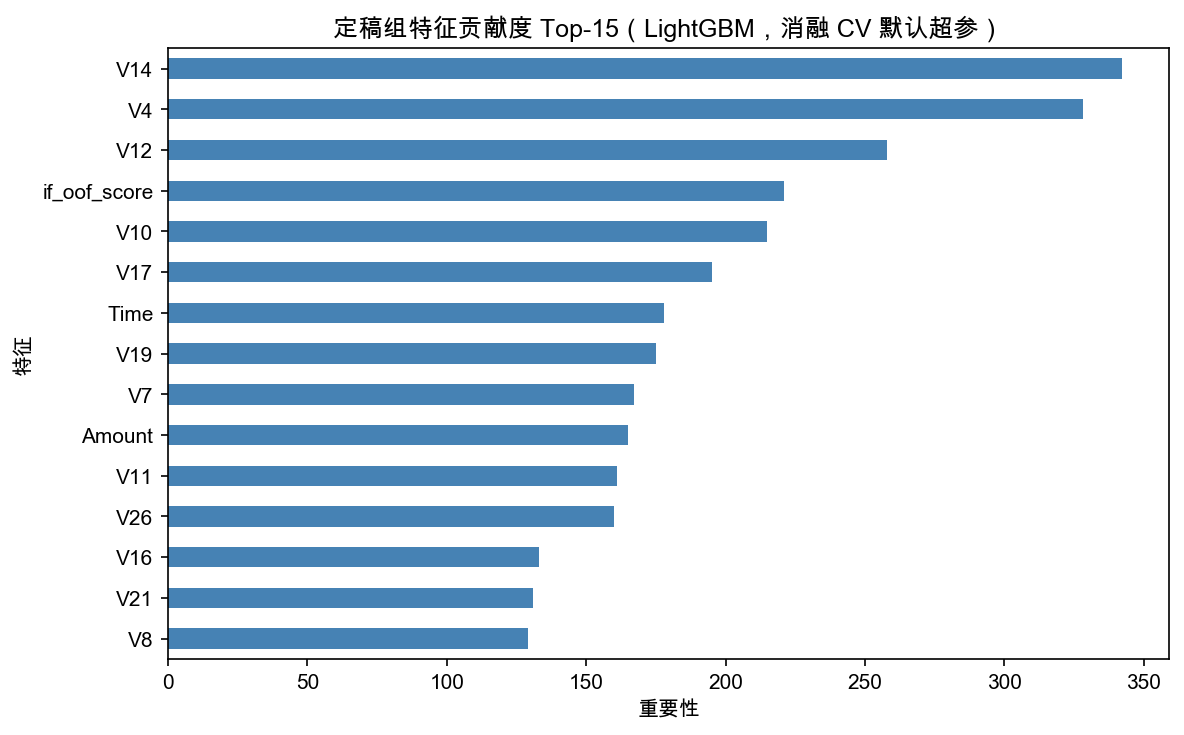

LightGBM Top-10:


V14             342
V4              328
V12             258
if_oof_score    221
V10             215
V17             195
Time            178
V19             175
V7              167
Amount          165
dtype: int32

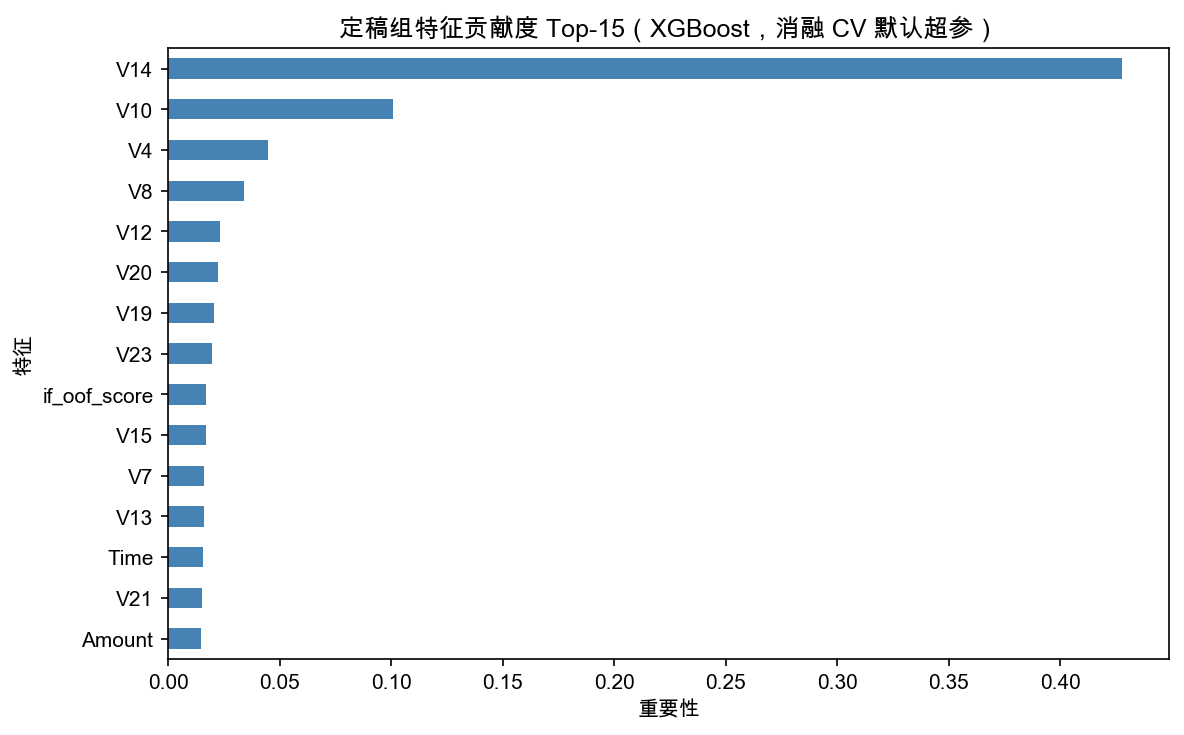

XGBoost Top-10:


V14             0.427383
V10             0.100907
V4              0.044780
V8              0.034100
V12             0.023304
V20             0.022388
V19             0.020439
V23             0.019804
if_oof_score    0.017113
V15             0.016925
dtype: float32


各模型 Top-5 V 列:
LightGBM → ['V14', 'V4', 'V12', 'V10', 'V17']
XGBoost → ['V14', 'V10', 'V4', 'V8', 'V12']

§9：贡献度分析完成后构造七列贡献度衍生...
§9 七列衍生特征: ['abs_v14_minus_v10', 'v14_x_log1p_amount', 'v14_x_v10', 'v14_x_v4', 'abs_v14_minus_v12', 'v14_x_v12', 'abs_v14_minus_v4']


,贡献度衍生特征,构造
0,abs_v14_minus_v10,|V14-V10|
1,v14_x_log1p_amount,V14*log1p_amount
2,v14_x_v10,V14*V10
3,v14_x_v4,V14*V4
4,abs_v14_minus_v12,|V14-V12|
5,v14_x_v12,V14*V12
6,abs_v14_minus_v4,|V14-V4|


已回写 → /Users/jingyuhe/代码/credit-fraud-dealing-with-imbalanced-datasets-test/src/output/final_report/df_features.pkl


In [57]:
# §9 exec
state = load_state()
df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
imp_cols, winner_label = resolve_winner_feature_cols(state)

params_snap = ablation_cv_params_snapshot()
params_df = pd.DataFrame([{'模型': k, **v} for k, v in params_snap.items()])
params_df.to_csv(OUT_WINNER_IMP / 'importance_params_ablation_cv.csv', index=False, encoding='utf-8-sig')
print('贡献度超参：与 §7/8 消融 cross_val_eval 一致（ABLATION_CV_PARAMS=None）')
print('定稿组:', winner_label, '| 特征数:', len(imp_cols))
display(params_df)

imps = {}
for name in MODELS:
    _, imp = fit_full_and_importance(name, df_fe, imp_cols, params=ABLATION_CV_PARAMS)
    imp.to_csv(OUT_WINNER_IMP / f'winner_importance_{name}.csv', encoding='utf-8-sig')
    imps[name] = imp
    top = imp.head(15)
    fig, ax = plt.subplots(figsize=(8, 5))
    top.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'定稿组特征贡献度 Top-15（{name}，消融 CV 默认超参）')
    ax.set_xlabel('重要性'); ax.set_ylabel('特征')
    fig.tight_layout()
    save_show_fig(fig, OUT_WINNER_IMP / f'winner_importance_{name}.png', dpi=150)
    print(name, 'Top-10:'); display(imp.head(10))

v_top = {m: imps[m][[c for c in imps[m].index if c.startswith('V')]].head(5) for m in MODELS}
print('\n各模型 Top-5 V 列:')
for m in MODELS:
    print(m, '→', list(v_top[m].index))

print('\n§9：贡献度分析完成后构造七列贡献度衍生...')
df_fe, fe8_features = build_fe8_contribution_features(df_fe)
df_fe.to_pickle(OUTPUT_DIR / 'df_features.pkl')
save_state(FE8_NEW_FEATURES=fe8_features)
print('§9 七列衍生特征:', fe8_features)
fe8_desc = pd.DataFrame({'贡献度衍生特征': fe8_features, '构造': [
    '|V14-V10|', 'V14*log1p_amount', 'V14*V10', 'V14*V4',
    '|V14-V12|', 'V14*V12', '|V14-V4|']})
fe8_desc.to_csv(OUT_WINNER_IMP / 'fe8_derivation.csv', index=False, encoding='utf-8-sig')
display(fe8_desc)
print('已回写 →', OUTPUT_DIR / 'df_features.pkl')


## 10. 贡献度新衍生特征 Stage 1：在 BASE 上筛 新特征的子集

参考：[`credit-fraud-feature-engineering-8.ipynb`](feature-engineering/credit-fraud-feature-engineering-8.ipynb) Stage 1-2。

### 探索历程

曾做 **IF 固定 + EDA × A1/A_top2 × 贡献度衍生特征** 全笛卡尔积，跑很久后发现 **`IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)`** 底子极好。现改为：Stage 1 取 **Top-15** 的贡献度衍生特征组，§10b 仅与消融基底组合做多种子定稿。

### Stage 1

在 BASE 上枚举所有新特征组合 **全部非空子集（127 组）** + 基线；先使用`SCREEN_SEEDS` 快速筛选 → 取 **Top-15**。

### Stage 2（§10b）

消融基底  IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4) + Top-15 的新特征组 → 在 CONFIRM_SEEDS 上进行多种子稳定性验证并定稿

---

输出：`10_fe8_stage1/`、`10_fe8_stage2/`

In [14]:
OUT_FE8_S1 = OUTPUT_DIR / '10_fe8_stage1'
OUT_FE8_S2 = OUTPUT_DIR / '10_fe8_stage2'
OUT_FE8_S1_SUPP = OUTPUT_DIR / '10_fe8_stage1_supp'
OUT_FE8_S2_SUPP = OUTPUT_DIR / '10_fe8_stage2_supp'
for _d in (OUT_FE8_S1, OUT_FE8_S2, OUT_FE8_S1_SUPP, OUT_FE8_S2_SUPP):
    _d.mkdir(parents=True, exist_ok=True)

SCREEN_SEEDS = [42, 77, 2026]
MIN_CONFIRM_CANDIDATES = 10
MAX_CONFIRM_CANDIDATES = 12
CONFIRM_MIN_POS_RATIO = 0.75
RUN_FE8_PIPELINE = False  # True → 重跑 §10 七列 FE8 Stage1/2
RUN_FE8_SUPPLEMENT = True  # True → §10c/§10d 六列补测（§12 不用 FE8，默认关）
MANUAL_FE8_SHORTLIST = None
FE8_TOP_N_MAX = 3
FE8_STAGE1_TOP_N = 15  # Stage1 dual → Stage2 精简子集数
DEFAULT_STAGE2_EDA_SUBSETS = ['hours+log1p', 'log1p+micro+bands', 'hours+one_euro+micro', 'log1p+hours+one_euro+bands']
STAGE2_SCREEN_EDA_TOP_N = 4
SKIP_FE8_STAGE1_IF_EXISTS = False
SKIP_FE8_STAGE2_IF_EXISTS = False
SKIP_FE8_SUPP_S1_IF_EXISTS = False
SKIP_FE8_SUPP_S2_IF_EXISTS = False


# §10 prep
if 'is_fe8_derived_col' not in globals():
    FE8_DERIVED_PREFIXES = ('abs_v14_', 'abs_v10_', 'v14_x_', 'v10_x_', 'v4_minus_')

    def is_fe8_derived_col(col: str) -> bool:
        return isinstance(col, str) and col.startswith(FE8_DERIVED_PREFIXES)

def _dedupe(cols):
    out, seen = [], set()
    for c in cols:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out


def _subset_label(cols):
    return '+'.join(sorted(cols)) if cols else 'none'


def _fe8_subsets(fe8_features):
    return [list(s) for k in range(1, len(fe8_features) + 1) for s in combinations(fe8_features, k)]


EDA_ATOMS = ABLATION_EDA_ATOMS  # 与 §7 共用
iter_eda_subsets = iter_ablation_eda_arms


def _make_record(records, seen, category, label, extra, stage):
    extra = _dedupe(extra)
    fe8_cols = [c for c in extra if is_fe8_derived_col(c)]
    hc_cols = [c for c in extra if c not in fe8_cols]
    key = (stage, tuple(sorted(extra)))
    if key in seen:
        return
    seen.add(key)
    records.append({
        'combo_id': len(records), 'stage': stage, 'category': category, 'label': label,
        'handcrafted_cols': hc_cols, 'fe8_cols': fe8_cols, 'extra_cols': extra,
        'n_handcrafted': len(hc_cols), 'n_fe8': len(fe8_cols), 'n_extra': len(extra),
    })


def build_stage1_specs(fe8_new_features):
    records, seen = [], set()
    _make_record(records, seen, 'baseline', BASELINE_LABEL, [], stage=1)
    for fe8_subset in _fe8_subsets(fe8_new_features):
        k = len(fe8_subset)
        label = f'S1_FE8_k{k}_{_subset_label(fe8_subset)}'
        _make_record(records, seen, 'stage1_fe8_on_base', label, list(fe8_subset), stage=1)
    return records


def export_combo_catalog(spec_records, csv_path, md_path, title):
    rows = [{
        'combo_id': r['combo_id'], 'stage': r['stage'], 'category': r['category'], 'label': r['label'],
        'n_handcrafted': r['n_handcrafted'], 'n_fe8': r['n_fe8'], 'n_extra': r['n_extra'],
        'handcrafted_cols': ' | '.join(r['handcrafted_cols']) if r['handcrafted_cols'] else '(none)',
        'fe8_cols': ' | '.join(r['fe8_cols']) if r['fe8_cols'] else '(none)',
        'extra_cols': ' | '.join(r['extra_cols']),
    } for r in spec_records]
    catalog_df = pd.DataFrame(rows)
    catalog_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
    lines = [f'# {title}（共 {len(spec_records)} 组）\n\n', f'- 对比基线：{BASELINE_LABEL}\n\n']
    for cat in catalog_df['category'].unique():
        sub = catalog_df[catalog_df['category'] == cat]
        lines.append(f'## {cat}（{len(sub)} 组）\n\n')
        for _, row in sub.iterrows():
            lines.append(f"### [{row['combo_id']}] {row['label']}\n")
            lines.append(f"- 手工：{row['handcrafted_cols']}\n")
            lines.append(f"- FE8：{row['fe8_cols']}\n")
            lines.append(f"- 全部：{row['extra_cols']}\n\n")
    md_path.write_text(''.join(lines), encoding='utf-8')
    return catalog_df


def _spec_row(rec, model_name, seed, res):
    return {
        'combo_id': rec['combo_id'], 'stage': rec['stage'], 'category': rec['category'],
        '特征组合': rec['label'], '模型': model_name, 'seed': seed,
        'n_handcrafted': rec['n_handcrafted'], 'n_fe8': rec['n_fe8'], 'n_extra': rec['n_extra'],
        'handcrafted_cols': ' | '.join(rec['handcrafted_cols']),
        'fe8_cols': ' | '.join(rec['fe8_cols']),
        'extra_cols': ' | '.join(rec['extra_cols']),
        **res,
    }


def eval_spec_once(rec, model_name, seed, df, base_features, cross_val_eval_fn, threshold=None):
    """CV 评估一条 spec。threshold 给定 → 共用 BASE cal 段定的 t*，只改 eval 段 F1（AUC 不变）。"""
    cols = base_features + [c for c in rec['extra_cols'] if c not in base_features]
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"{rec['label']} 缺失列: {missing}")
    res = cross_val_eval_fn(model_name, df, cols, random_state=seed, threshold=threshold)
    return _spec_row(rec, model_name, seed, res)


def run_stability_matrix(spec_records, checkpoint_path, df, base_features, cross_val_eval_fn, models=MODELS, seeds=None):
    """§9/10 稳定性矩阵：AUC 各 combo 独立 CV；F1 与 §7 相同，同 model×seed 共用 BASE 的 t*。"""
    seeds = list(seeds if seeds is not None else SCREEN_SEEDS)
    done = {}
    if checkpoint_path.is_file():
        prev = _ensure_dual_f1_columns(pd.read_csv(checkpoint_path))
        if '特征组合' in prev.columns:
            for _, row in prev.iterrows():
                done[(row['特征组合'], row['模型'], int(row['seed']))] = row.to_dict()
            print(f'checkpoint 恢复 {len(done)} 行 | {checkpoint_path}')
    rows = list(done.values())
    total = len(spec_records) * len(models) * len(seeds)
    step = len(rows)
    base_cache = {}  # (model, seed) → cross_val_eval(BASE)，cal 段定 t*

    def _base_res(model_name, seed):
        k = (model_name, seed)
        if k not in base_cache:
            base_cache[k] = cross_val_eval_fn(model_name, df, base_features, random_state=seed)
        return base_cache[k]

    for rec in spec_records:
        for model_name in models:
            for seed in seeds:
                key = (rec['label'], model_name, seed)
                if key in done:
                    continue
                step += 1
                print(f'[{step}/{total}] {model_name} seed={seed} | {rec["label"]}', flush=True)
                if rec['label'] == BASELINE_LABEL:
                    row = _spec_row(rec, model_name, seed, _base_res(model_name, seed))
                else:
                    shared_thr = _base_res(model_name, seed)['best_threshold']
                    row = eval_spec_once(
                        rec, model_name, seed, df, base_features, cross_val_eval_fn,
                        threshold=shared_thr,
                    )
                rows.append(row)
                done[key] = row
                _ensure_dual_f1_columns(pd.DataFrame(rows)).to_csv(
                    checkpoint_path, index=False, encoding='utf-8-sig')
    return _ensure_dual_f1_columns(pd.DataFrame(rows))


def summarize_stability(raw, baseline_label=BASELINE_LABEL):
    raw = _ensure_dual_f1_columns(raw)
    base = (
        raw[raw['特征组合'] == baseline_label]
        .groupby(['模型', 'seed'], as_index=False)['AUC-PR_mean']
        .mean()
        .rename(columns={'AUC-PR_mean': 'BASELINE_AUC_seed'})
    )
    if base.empty:
        raise ValueError(f'基线 {baseline_label} 无结果')
    merged = raw.merge(base, on=['模型', 'seed'], how='left')
    merged['delta_AUC_vs_BASE'] = merged['AUC-PR_mean'] - merged['BASELINE_AUC_seed']
    summary = (
        merged.groupby(['特征组合', '模型'], as_index=False)
        .agg(
            combo_id=('combo_id', 'first'), stage=('stage', 'first'), category=('category', 'first'),
            n_handcrafted=('n_handcrafted', 'first'), n_fe8=('n_fe8', 'first'), n_extra=('n_extra', 'first'),
            handcrafted_cols=('handcrafted_cols', 'first'), fe8_cols=('fe8_cols', 'first'),
            extra_cols=('extra_cols', 'first'),
            AUC_mean=('AUC-PR_mean', 'mean'), AUC_std_across_seed=('AUC-PR_mean', 'std'),
            delta_mean_AUC=('delta_AUC_vs_BASE', 'mean'), delta_std_AUC=('delta_AUC_vs_BASE', 'std'),
            positive_seed_ratio=('delta_AUC_vs_BASE', lambda s: float((s > 0).mean())),
            **F1_FP_MEAN_AGG, FN_mean=('FN', 'mean'),
        )
    )
    # conservative_score（单模型）= 跨 seed 的 delta_mean_AUC - delta_std_AUC
    summary['conservative_score'] = summary['delta_mean_AUC'] - summary['delta_std_AUC'].fillna(0.0)
    return merged, summary.sort_values(['模型', 'conservative_score'], ascending=[True, False]).reset_index(drop=True)


def build_dual_model_summary(stability_summary):
    lgb_s = stability_summary[stability_summary['模型'] == 'LightGBM'].set_index('特征组合')
    xgb_s = stability_summary[stability_summary['模型'] == 'XGBoost'].set_index('特征组合')
    rows = []
    for label in lgb_s.index.intersection(xgb_s.index):
        rows.append({
            'combo_id': int(lgb_s.loc[label, 'combo_id']),
            'stage': lgb_s.loc[label, 'stage'], 'category': lgb_s.loc[label, 'category'],
            'combo_label': label,
            'n_handcrafted': int(lgb_s.loc[label, 'n_handcrafted']),
            'n_fe8': int(lgb_s.loc[label, 'n_fe8']), 'n_extra': int(lgb_s.loc[label, 'n_extra']),
            'handcrafted_cols': lgb_s.loc[label, 'handcrafted_cols'],
            'fe8_cols': lgb_s.loc[label, 'fe8_cols'], 'extra_cols': lgb_s.loc[label, 'extra_cols'],
            'delta_LGB_AUC': float(lgb_s.loc[label, 'delta_mean_AUC']),
            'delta_XGB_AUC': float(xgb_s.loc[label, 'delta_mean_AUC']),
            'delta_mean_AUC': float(np.mean([lgb_s.loc[label, 'delta_mean_AUC'], xgb_s.loc[label, 'delta_mean_AUC']])),
            'LGB_positive_seed_ratio': float(lgb_s.loc[label, 'positive_seed_ratio']),
            'XGB_positive_seed_ratio': float(xgb_s.loc[label, 'positive_seed_ratio']),
            'both_models_positive': bool(lgb_s.loc[label, 'delta_mean_AUC'] > 0 and xgb_s.loc[label, 'delta_mean_AUC'] > 0),
            'conservative_score': float(np.mean([lgb_s.loc[label, 'conservative_score'], xgb_s.loc[label, 'conservative_score']])),
            **_dual_f1_fp(lgb_s, xgb_s, label),
        })
    return pd.DataFrame(rows).sort_values(
        ['both_models_positive', 'conservative_score', 'delta_mean_AUC'], ascending=False
    ).reset_index(drop=True)


def parse_fe8_cols(fe8_cols_str):
    if not isinstance(fe8_cols_str, str) or not fe8_cols_str.strip() or fe8_cols_str == '(none)':
        return []
    return [c.strip() for c in fe8_cols_str.split('|')]


def select_fe8_shortlist(dual_summary, fe8_new_features, top_n=FE8_TOP_N_MAX):
    if MANUAL_FE8_SHORTLIST is not None:
        out = []
        for item in MANUAL_FE8_SHORTLIST:
            cols = list(item) if isinstance(item, (list, tuple)) else [item]
            out.append(_dedupe(cols))
        print('使用 MANUAL_FE8_SHORTLIST:', out)
        return out
    pool = dual_summary[(dual_summary['combo_label'] != BASELINE_LABEL) & (dual_summary['n_fe8'] > 0)].copy()
    eligible = pool[
        pool['both_models_positive']
        & (pool['LGB_positive_seed_ratio'] >= 2 / 3)
        & (pool['XGB_positive_seed_ratio'] >= 2 / 3)
    ].sort_values(['conservative_score', 'delta_mean_AUC'], ascending=False)
    if eligible.empty:
        print('阶段1：无满足稳定性门槛的 FE8 组合，回退为 delta_mean_AUC Top-3')
        eligible = pool.sort_values('delta_mean_AUC', ascending=False).head(3)
    shortlisted, seen = [], set()
    for _, row in eligible.iterrows():
        key = tuple(sorted(parse_fe8_cols(row['fe8_cols'])))
        if not key or key in seen:
            continue
        seen.add(key)
        shortlisted.append(list(key))
        if len(shortlisted) >= top_n:
            break
    if not shortlisted:
        shortlisted = [list(fe8_new_features)]
        print('阶段1：shortlist 为空，回退 FE8 全原子列')
    return shortlisted


DUAL_SUMMARY_DISPLAY_DROP = ['combo_id', 'category', 'n_extra', 'extra_cols']


def present_dual_summary(df: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """Notebook 展示：完整表写 CSV，display 时去掉元数据列并排列 F1 双列。"""
    cols = [c for c in df.columns if c not in DUAL_SUMMARY_DISPLAY_DROP]
    return _order_f1_columns(df[cols].head(top_n))


def select_fe8_top_n(dual_summary, fe8_new_features, top_n=FE8_STAGE1_TOP_N):
    """Stage1 dual 中取 Top-N 唯一 FE8 子集（供精简 Stage2）。"""
    pool = dual_summary[
        (dual_summary['combo_label'] != BASELINE_LABEL) & (dual_summary['n_fe8'] > 0)
    ].copy()
    sort_col = 'conservative_score' if 'conservative_score' in pool.columns else 'delta_mean_AUC'
    pool = pool.sort_values(sort_col, ascending=False)
    out, seen = [], set()
    for _, row in pool.iterrows():
        key = tuple(sorted(parse_fe8_cols(row['fe8_cols'])))
        if not key or key in seen:
            continue
        seen.add(key)
        out.append(list(key))
        if len(out) >= top_n:
            break
    if not out:
        out = [list(fe8_new_features)]
        print('Stage1 Top-N 为空，回退 FE8 全原子列')
    return out


In [71]:
# §10 exec
if not RUN_FE8_PIPELINE:
    print('RUN_FE8_PIPELINE=False，跳过 §10 Stage1（七列历史跑批）')
else:
    state = load_state()
    df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
    BASE_FEATURES = state['BASE_FEATURES']
    FE8_NEW = state['FE8_NEW_FEATURES']
    ckpt = OUT_FE8_S1 / 'fe8_stage1_checkpoint.csv'

    STAGE1 = build_stage1_specs(FE8_NEW)
    export_combo_catalog(STAGE1, OUT_FE8_S1/'fe8_stage1_specs.csv', OUT_FE8_S1/'fe8_stage1_specs.md', 'FE8 Stage1')
    if SKIP_FE8_STAGE1_IF_EXISTS and ckpt.exists():
        raw_s1 = _ensure_dual_f1_columns(pd.read_csv(ckpt))
        print('从 checkpoint 加载 Stage1')
    else:
        raw_s1 = run_stability_matrix(STAGE1, ckpt, df_fe, BASE_FEATURES, cross_val_eval, seeds=SCREEN_SEEDS)
    raw_s1.to_csv(OUT_FE8_S1/'fe8_stage1_raw.csv', index=False, encoding='utf-8-sig')
    _, sum_s1 = summarize_stability(raw_s1)
    dual_s1 = build_dual_model_summary(sum_s1)
    dual_s1.to_csv(OUT_FE8_S1/'fe8_stage1_dual_summary.csv', index=False, encoding='utf-8-sig')

    FE8_STAGE1_TOP15 = select_fe8_top_n(dual_s1, FE8_NEW, top_n=FE8_STAGE1_TOP_N)
    SELECTED_FE8 = select_fe8_shortlist(dual_s1, FE8_NEW)
    (OUT_FE8_S1/'fe8_stage1_top15.json').write_text(json.dumps(FE8_STAGE1_TOP15, ensure_ascii=False, indent=2), encoding='utf-8')
    (OUT_FE8_S1/'fe8_stage1_shortlist.json').write_text(json.dumps(SELECTED_FE8, ensure_ascii=False, indent=2), encoding='utf-8')
    display(present_dual_summary(dual_s1).round(4))
    print(f'Stage1 Top-{FE8_STAGE1_TOP_N} 子集（→ Stage2）:', FE8_STAGE1_TOP15)
    print('Stage1 shortlist (Top-3 兼容):', SELECTED_FE8)
    save_state(FE8_STAGE1_TOP15=FE8_STAGE1_TOP15, SELECTED_FE8=SELECTED_FE8)


RUN_FE8_PIPELINE=False，跳过 §10 Stage1（七列历史跑批）


## 10b. 贡献度新衍生特征 Stage 2：消融基底 + Stage 1 Top-15（多种子验证稳定性）

1. **`IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)`**（消融基底）
2. 上述基底 + Stage 1 **Top-15** 进行组合

用 **`CONFIRM_SEEDS`** 多种子排名。

---

输出：`10_fe8_stage2/fe8_stage2_*`

In [15]:
# §10b prep：Stage2 定稿辅助

def build_stage2_ablation_fe8_specs(ablation_label: str, ablation_extra: list, fe8_subsets: list):
    """精简 Stage2：消融基底 + 基底×各 FE8 子集（含 BASE 参照行供 Δ 计算）。"""
    records, seen = [], set()
    _make_record(records, seen, 'baseline_ref', BASELINE_LABEL, [], stage=2)
    _make_record(records, seen, 'ablation_base', ablation_label, list(ablation_extra), stage=2)
    for fe8_subset in fe8_subsets:
        fe8_tag = _subset_label(fe8_subset)
        label = f'{ablation_label}+FE8[{fe8_tag}]'
        extra = _dedupe(list(ablation_extra) + list(fe8_subset))
        _make_record(records, seen, 'ablation_fe8_combo', label, extra, stage=2)
    return records


def _ablation_combo_mask(dual_summary: pd.DataFrame, ablation_label: str) -> pd.Series:
    """仅保留与当前 §7/8 消融基底 label 前缀一致的 Stage2 行。"""
    ablation_label = _normalize_ablation_label(ablation_label)
    cl = dual_summary['combo_label'].astype(str)
    return cl.eq(ablation_label) | cl.str.startswith(ablation_label + '+FE8[')


def dual_has_ablation_combos(dual_summary: pd.DataFrame, ablation_label: str = ABLATION_WINNER_LABEL) -> bool:
    if dual_summary is None or dual_summary.empty or 'combo_label' not in dual_summary.columns:
        return False
    return bool(_ablation_combo_mask(dual_summary, ablation_label).any())


def select_stage2_winner(dual_summary: pd.DataFrame, ablation_label: str = ABLATION_WINNER_LABEL):
    ablation_label = _normalize_ablation_label(ablation_label)
    pool = dual_summary[_ablation_combo_mask(dual_summary, ablation_label)].copy()
    if pool.empty:
        raise ValueError(
            f'Stage2 结果中无当前消融基底 {ablation_label!r} 的组合，'
            '请重跑 Stage2 或删除旧 checkpoint'
        )
    return pool.sort_values(
        ['both_models_positive', 'conservative_score', 'delta_mean_AUC'], ascending=False
    ).iloc[0]


def apply_stage2_winner_to_state(winner_row, base_features: list, confirm_status='fe8_stage2_confirmed'):
    label = winner_row['combo_label']
    extra_str = winner_row.get('extra_cols', '')
    if isinstance(extra_str, str) and extra_str.strip() and str(extra_str) != 'nan':
        extra = [c.strip() for c in extra_str.split('|') if c.strip()]
    else:
        extra = []
    fe8_cols = parse_fe8_cols(winner_row.get('fe8_cols', ''))
    payload = {
        'WINNER_LABEL': label,
        'WINNER_EXTRA': extra,
        'WINNER_FEATURES': base_features + extra,
        'FE8_WINNER': fe8_cols,
        'CONFIRM_STATUS': confirm_status,
    }
    save_state(**payload)
    return payload


In [73]:
# §10b exec
if not RUN_FE8_PIPELINE:
    print('RUN_FE8_PIPELINE=False，跳过 §10b Stage2（七列历史定稿）')
else:
    state = load_state()
    df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
    BASE_FEATURES = state['BASE_FEATURES']
    FE8_TOP = state.get('FE8_STAGE1_TOP15') or state.get('SELECTED_FE8')
    if not FE8_TOP:
        raise ValueError('请先运行 §10 Stage1 得到 FE8_STAGE1_TOP15')

    specs_path = OUT_ABLATION / 'ablation_combo_specs.csv'
    specs = pd.read_csv(specs_path)
    ablation_label = _normalize_ablation_label(ABLATION_WINNER_LABEL)
    row = specs[specs['label'] == ablation_label]
    if row.empty:
        raise KeyError(f'未找到 {ablation_label}')
    ablation_extra = [c.strip() for c in str(row.iloc[0]['extra_cols']).split('|') if c.strip()]

    STAGE2 = build_stage2_ablation_fe8_specs(ablation_label, ablation_extra, FE8_TOP)
    export_combo_catalog(STAGE2, OUT_FE8_S2/'fe8_stage2_specs.csv', OUT_FE8_S2/'fe8_stage2_specs.md', 'FE8 Stage2 精简')
    print(f'Stage2 候选: 1 消融基底 + {len(FE8_TOP)} FE8 子集 = {len(STAGE2)-1} 组（+BASE 参照）')
    print('多种子:', CONFIRM_SEEDS)

    ckpt = OUT_FE8_S2 / 'fe8_stage2_confirm_checkpoint.csv'
    if SKIP_FE8_STAGE2_IF_EXISTS and ckpt.exists():
        raw_s2 = _ensure_dual_f1_columns(pd.read_csv(ckpt))
        if not dual_has_ablation_combos(raw_s2, ablation_label):
            print('checkpoint 与当前消融基底不匹配，重跑 Stage2')
            raw_s2 = run_stability_matrix(STAGE2, ckpt, df_fe, BASE_FEATURES, cross_val_eval, seeds=CONFIRM_SEEDS)
        else:
            print('从 checkpoint 加载 Stage2')
    else:
        raw_s2 = run_stability_matrix(STAGE2, ckpt, df_fe, BASE_FEATURES, cross_val_eval, seeds=CONFIRM_SEEDS)
    raw_s2.to_csv(OUT_FE8_S2/'fe8_stage2_raw.csv', index=False, encoding='utf-8-sig')
    _, sum_s2 = summarize_stability(raw_s2)
    dual_s2 = build_dual_model_summary(sum_s2)
    dual_s2.to_csv(OUT_FE8_S2/'fe8_stage2_dual_summary.csv', index=False, encoding='utf-8-sig')

    winner_row = select_stage2_winner(dual_s2, ablation_label)
    display(present_dual_summary(dual_s2, top_n=16).round(4))
    winner_payload = apply_stage2_winner_to_state(winner_row, BASE_FEATURES, confirm_status='fe8_stage2_confirmed')
    print('\n★ Stage2 定稿:', winner_payload['WINNER_LABEL'])
    print('最优特征组:', winner_payload['FE8_WINNER'] or '(无，即纯消融基底)')
    save_state(FE8_STAGE2_TOP_LABEL=winner_payload['WINNER_LABEL'])


RUN_FE8_PIPELINE=False，跳过 §10b Stage2（七列历史定稿）


## 10c. 六列新特征补测 Stage 1（SCREEN_SEEDS 快筛）

在 §10b 七列定稿完成后，换 **六列正交池** 补测（对之前的结果进行观察后，去掉表现不好的特征，换上新的特征）。

### 特征列（63 个非空子集 + BASE）
`abs_v14_minus_v12`, `v14_x_log1p_amount`, `abs_v10_minus_v12`, `v10_x_log1p_amount`, `v4_minus_v14`, `v4_minus_v12`

### 流程
1. 本节 **prep** 定义六列补测池，**exec** 写入 `df_features.pkl`（`FE8_SUPP_FEATURES`）
2. `SCREEN_SEEDS` → **Top-15** → `10_fe8_stage1_supp/`
3. §10d：`CONFIRM_SEEDS` 在消融基底上定稿 → `10_fe8_stage2_supp/`

> Δ 仍相对 **`0_BASE`**；看边际请用「补测组合 Δ − 消融基底 Δ」。

In [16]:
# §10c prep：六列补测池（§10a–b 结论后的扩展）
FE8_SUPP_ATOMS = [
    'abs_v14_minus_v12', 'v14_x_log1p_amount', 'abs_v10_minus_v12',
    'v10_x_log1p_amount', 'v4_minus_v14', 'v4_minus_v12',
]


def build_fe8_supplement_features(data):
    """§10c：在 §9 七列衍生已写入 df 后，追加/刷新六列补测池。"""
    out = data.copy()
    out['abs_v14_minus_v12'] = (out['V14'] - out['V12']).abs()
    out['v14_x_log1p_amount'] = out['V14'] * out['log1p_amount']
    out['abs_v10_minus_v12'] = (out['V10'] - out['V12']).abs()
    out['v10_x_log1p_amount'] = out['V10'] * out['log1p_amount']
    out['v4_minus_v14'] = out['V4'] - out['V14']
    out['v4_minus_v12'] = out['V4'] - out['V12']
    return out, list(FE8_SUPP_ATOMS)


In [75]:
# §10c exec：六列补测 Stage1
if not RUN_FE8_SUPPLEMENT:
    print('RUN_FE8_SUPPLEMENT=False，跳过 §10c')
else:
    state = load_state()
    df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
    BASE_FEATURES = state['BASE_FEATURES']

    print('§10c：写入六列补测池...')
    df_fe, fe8_supp = build_fe8_supplement_features(df_fe)
    df_fe.to_pickle(OUTPUT_DIR / 'df_features.pkl')
    save_state(FE8_SUPP_FEATURES=fe8_supp)
    print('六列补测池:', fe8_supp)

    ckpt = OUT_FE8_S1_SUPP / 'fe8_stage1_supp_checkpoint.csv'
    STAGE1_SUPP = build_stage1_specs(fe8_supp)
    export_combo_catalog(
        STAGE1_SUPP,
        OUT_FE8_S1_SUPP / 'fe8_stage1_supp_specs.csv',
        OUT_FE8_S1_SUPP / 'fe8_stage1_supp_specs.md',
        'FE8 Stage1 六列补测',
    )
    print(f'Stage1 补测: {len(STAGE1_SUPP)-1}个特征组合子集 + BASE | 快筛种子 {SCREEN_SEEDS}')

    if SKIP_FE8_SUPP_S1_IF_EXISTS and ckpt.exists():
        raw_s1_supp = _ensure_dual_f1_columns(pd.read_csv(ckpt))
        print('从 checkpoint 加载 Stage1 补测')
    else:
        raw_s1_supp = run_stability_matrix(
            STAGE1_SUPP, ckpt, df_fe, BASE_FEATURES, cross_val_eval, seeds=SCREEN_SEEDS,
        )
    raw_s1_supp.to_csv(OUT_FE8_S1_SUPP / 'fe8_stage1_supp_raw.csv', index=False, encoding='utf-8-sig')
    _, sum_s1_supp = summarize_stability(raw_s1_supp)
    dual_s1_supp = build_dual_model_summary(sum_s1_supp)
    dual_s1_supp.to_csv(OUT_FE8_S1_SUPP / 'fe8_stage1_supp_dual_summary.csv', index=False, encoding='utf-8-sig')

    FE8_SUPP_STAGE1_TOP15 = select_fe8_top_n(dual_s1_supp, fe8_supp, top_n=FE8_STAGE1_TOP_N)
    FE8_SUPP_SELECTED = select_fe8_shortlist(dual_s1_supp, fe8_supp)
    (OUT_FE8_S1_SUPP / 'fe8_stage1_supp_top15.json').write_text(
        json.dumps(FE8_SUPP_STAGE1_TOP15, ensure_ascii=False, indent=2), encoding='utf-8',
    )
    (OUT_FE8_S1_SUPP / 'fe8_stage1_supp_shortlist.json').write_text(
        json.dumps(FE8_SUPP_SELECTED, ensure_ascii=False, indent=2), encoding='utf-8',
    )
    display(present_dual_summary(dual_s1_supp).round(4))
    print(f'Stage1 补测 Top-{FE8_STAGE1_TOP_N}:', FE8_SUPP_STAGE1_TOP15)
    save_state(FE8_SUPP_STAGE1_TOP15=FE8_SUPP_STAGE1_TOP15, FE8_SUPP_SELECTED=FE8_SUPP_SELECTED)


§10c：写入六列补测池...
六列补测池: ['abs_v14_minus_v12', 'v14_x_log1p_amount', 'abs_v10_minus_v12', 'v10_x_log1p_amount', 'v4_minus_v14', 'v4_minus_v12']
Stage1 补测: 63个特征组合子集 + BASE | 快筛种子 [42, 77, 2026]
[1/384] LightGBM seed=42 | 0_BASE
[2/384] LightGBM seed=77 | 0_BASE
[3/384] LightGBM seed=2026 | 0_BASE
[4/384] XGBoost seed=42 | 0_BASE
[5/384] XGBoost seed=77 | 0_BASE
[6/384] XGBoost seed=2026 | 0_BASE
[7/384] LightGBM seed=42 | S1_FE8_k1_abs_v14_minus_v12
[8/384] LightGBM seed=77 | S1_FE8_k1_abs_v14_minus_v12
[9/384] LightGBM seed=2026 | S1_FE8_k1_abs_v14_minus_v12
[10/384] XGBoost seed=42 | S1_FE8_k1_abs_v14_minus_v12
[11/384] XGBoost seed=77 | S1_FE8_k1_abs_v14_minus_v12
[12/384] XGBoost seed=2026 | S1_FE8_k1_abs_v14_minus_v12
[13/384] LightGBM seed=42 | S1_FE8_k1_v14_x_log1p_amount
[14/384] LightGBM seed=77 | S1_FE8_k1_v14_x_log1p_amount
[15/384] LightGBM seed=2026 | S1_FE8_k1_v14_x_log1p_amount
[16/384] XGBoost seed=42 | S1_FE8_k1_v14_x_log1p_amount
[17/384] XGBoost seed=77 | S1_FE8_k1_v14

,stage,combo_label,n_handcrafted,n_fe8,handcrafted_cols,fe8_cols,delta_LGB_AUC,delta_XGB_AUC,delta_mean_AUC,F1@BASE_t*,F1@combo_t*,F1@combo_t*,LGB_positive_seed_ratio,XGB_positive_seed_ratio,both_models_positive,conservative_score,FP
0,1,S1_FE8_k4_abs_v10_minus_v12+v14_x_log1p_amount...,0,4,,v14_x_log1p_amount | abs_v10_minus_v12 | v4_mi...,0.0150,0.0053,0.0102,0.7496,0.7291,0.7291,1.0,1.0000,True,0.0063,80.8333
1,1,S1_FE8_k4_v10_x_log1p_amount+v14_x_log1p_amoun...,0,4,,v14_x_log1p_amount | v10_x_log1p_amount | v4_m...,0.0109,0.0048,0.0079,0.7400,0.7329,0.7329,1.0,1.0000,True,0.0055,80.5000
2,1,S1_FE8_k2_v4_minus_v12+v4_minus_v14,0,2,,v4_minus_v14 | v4_minus_v12,0.0099,0.0074,0.0087,0.7442,0.7302,0.7302,1.0,1.0000,True,0.0044,81.1667
3,1,S1_FE8_k3_abs_v10_minus_v12+v4_minus_v12+v4_mi...,0,3,,abs_v10_minus_v12 | v4_minus_v14 | v4_minus_v12,0.0150,0.0048,0.0099,0.7409,0.7342,0.7342,1.0,0.6667,True,0.0041,90.3333
4,1,S1_FE8_k4_abs_v10_minus_v12+abs_v14_minus_v12+...,0,4,,abs_v14_minus_v12 | v14_x_log1p_amount | abs_v...,0.0144,0.0007,0.0076,0.7405,0.7195,0.7195,1.0,0.6667,True,0.0040,85.3333
5,1,S1_FE8_k2_v14_x_log1p_amount+v4_minus_v14,0,2,,v14_x_log1p_amount | v4_minus_v14,0.0116,0.0037,0.0076,0.7425,0.7282,0.7282,1.0,1.0000,True,0.0036,81.0000
6,1,S1_FE8_k1_v4_minus_v14,0,1,,v4_minus_v14,0.0146,0.0022,0.0084,0.7366,0.7307,0.7307,1.0,0.6667,True,0.0032,80.8333
7,1,S1_FE8_k4_abs_v10_minus_v12+v10_x_log1p_amount...,0,4,,v14_x_log1p_amount | abs_v10_minus_v12 | v10_x...,0.0090,0.0011,0.0050,0.7381,0.7403,0.7403,1.0,0.6667,True,0.0030,78.3333
8,1,S1_FE8_k3_v10_x_log1p_amount+v4_minus_v12+v4_m...,0,3,,v10_x_log1p_amount | v4_minus_v14 | v4_minus_v12,0.0101,0.0060,0.0080,0.7459,0.7482,0.7482,1.0,1.0000,True,0.0029,84.1667
9,1,S1_FE8_k4_abs_v10_minus_v12+abs_v14_minus_v12+...,0,4,,abs_v14_minus_v12 | abs_v10_minus_v12 | v4_min...,0.0114,0.0030,0.0072,0.7451,0.7338,0.7338,1.0,0.6667,True,0.0028,82.0000


Stage1 补测 Top-15: [['abs_v10_minus_v12', 'v14_x_log1p_amount', 'v4_minus_v12', 'v4_minus_v14'], ['v10_x_log1p_amount', 'v14_x_log1p_amount', 'v4_minus_v12', 'v4_minus_v14'], ['v4_minus_v12', 'v4_minus_v14'], ['abs_v10_minus_v12', 'v4_minus_v12', 'v4_minus_v14'], ['abs_v10_minus_v12', 'abs_v14_minus_v12', 'v14_x_log1p_amount', 'v4_minus_v14'], ['v14_x_log1p_amount', 'v4_minus_v14'], ['v4_minus_v14'], ['abs_v10_minus_v12', 'v10_x_log1p_amount', 'v14_x_log1p_amount', 'v4_minus_v14'], ['v10_x_log1p_amount', 'v4_minus_v12', 'v4_minus_v14'], ['abs_v10_minus_v12', 'abs_v14_minus_v12', 'v4_minus_v12', 'v4_minus_v14'], ['abs_v10_minus_v12', 'v4_minus_v14'], ['abs_v10_minus_v12', 'v10_x_log1p_amount', 'v14_x_log1p_amount', 'v4_minus_v12', 'v4_minus_v14'], ['abs_v14_minus_v12', 'v4_minus_v12', 'v4_minus_v14'], ['abs_v10_minus_v12', 'abs_v14_minus_v12', 'v14_x_log1p_amount', 'v4_minus_v12', 'v4_minus_v14'], ['abs_v10_minus_v12', 'v10_x_log1p_amount', 'v4_minus_v14']]


## 10d. 六列新特征补测 Stage 2（CONFIRM_SEEDS 定稿）

消融基底 + §10c **Top-15**；`CONFIRM_SEEDS` 多种子排名。

- 输出：`10_fe8_stage2_supp/`（不覆盖 §10b 的 `10_fe8_stage2/`）
- 定稿状态：`CONFIRM_STATUS=fe8_supp_stage2_confirmed`

In [76]:
# §10d exec：六列补测 Stage2
if not RUN_FE8_SUPPLEMENT:
    print('RUN_FE8_SUPPLEMENT=False，跳过 §10d')
else:
    state = load_state()
    df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
    BASE_FEATURES = state['BASE_FEATURES']
    FE8_TOP_SUPP = state.get('FE8_SUPP_STAGE1_TOP15') or state.get('FE8_SUPP_SELECTED')
    if not FE8_TOP_SUPP:
        raise ValueError('请先运行 §10c 得到 FE8_SUPP_STAGE1_TOP15')

    specs = pd.read_csv(OUT_ABLATION / 'ablation_combo_specs.csv')
    ablation_label = _normalize_ablation_label(ABLATION_WINNER_LABEL)
    row = specs[specs['label'] == ablation_label]
    if row.empty:
        raise KeyError(f'未找到 {ablation_label}')
    ablation_extra = [c.strip() for c in str(row.iloc[0]['extra_cols']).split('|') if c.strip()]

    if state.get('FE8_STAGE2_TOP_LABEL'):
        save_state(FE8_STAGE2_LEGACY_LABEL=state['FE8_STAGE2_TOP_LABEL'])

    STAGE2_SUPP = build_stage2_ablation_fe8_specs(ablation_label, ablation_extra, FE8_TOP_SUPP)
    export_combo_catalog(
        STAGE2_SUPP,
        OUT_FE8_S2_SUPP / 'fe8_stage2_supp_specs.csv',
        OUT_FE8_S2_SUPP / 'fe8_stage2_supp_specs.md',
        'FE8 Stage2 六列补测',
    )
    print(f'Stage2 补测: 1 消融基底 + {len(FE8_TOP_SUPP)} FE8 子集 = {len(STAGE2_SUPP)-1} 组（+BASE 参照）')
    print('复验种子:', CONFIRM_SEEDS)

    ckpt = OUT_FE8_S2_SUPP / 'fe8_stage2_supp_confirm_checkpoint.csv'
    if SKIP_FE8_SUPP_S2_IF_EXISTS and ckpt.exists():
        raw_s2_supp = _ensure_dual_f1_columns(pd.read_csv(ckpt))
        if not dual_has_ablation_combos(raw_s2_supp, ablation_label):
            print('checkpoint 与当前消融基底不匹配，重跑 Stage2 补测')
            raw_s2_supp = run_stability_matrix(
                STAGE2_SUPP, ckpt, df_fe, BASE_FEATURES, cross_val_eval, seeds=CONFIRM_SEEDS,
            )
        else:
            print('从 checkpoint 加载 Stage2 补测')
    else:
        raw_s2_supp = run_stability_matrix(
            STAGE2_SUPP, ckpt, df_fe, BASE_FEATURES, cross_val_eval, seeds=CONFIRM_SEEDS,
        )
    raw_s2_supp.to_csv(OUT_FE8_S2_SUPP / 'fe8_stage2_supp_raw.csv', index=False, encoding='utf-8-sig')
    _, sum_s2_supp = summarize_stability(raw_s2_supp)
    dual_s2_supp = build_dual_model_summary(sum_s2_supp)
    dual_s2_supp.to_csv(OUT_FE8_S2_SUPP / 'fe8_stage2_supp_dual_summary.csv', index=False, encoding='utf-8-sig')

    winner_row = select_stage2_winner(dual_s2_supp, ablation_label)
    display(present_dual_summary(dual_s2_supp, top_n=16).round(4))
    winner_payload = apply_stage2_winner_to_state(
        winner_row, BASE_FEATURES, confirm_status='fe8_supp_stage2_confirmed',
    )
    print('\n★ Stage2 补测定稿:', winner_payload['WINNER_LABEL'])
    print('FE8 列:', winner_payload['FE8_WINNER'] or '(无，即纯消融基底)')
    save_state(FE8_SUPP_STAGE2_TOP_LABEL=winner_payload['WINNER_LABEL'])


Stage2 补测: 1 消融基底 + 15 FE8 子集 = 16 组（+BASE 参照）
复验种子: [7, 13, 123, 256, 3141]
[1/170] LightGBM seed=7 | 0_BASE
[2/170] LightGBM seed=13 | 0_BASE
[3/170] LightGBM seed=123 | 0_BASE
[4/170] LightGBM seed=256 | 0_BASE
[5/170] LightGBM seed=3141 | 0_BASE
[6/170] XGBoost seed=7 | 0_BASE
[7/170] XGBoost seed=13 | 0_BASE
[8/170] XGBoost seed=123 | 0_BASE
[9/170] XGBoost seed=256 | 0_BASE
[10/170] XGBoost seed=3141 | 0_BASE
[11/170] LightGBM seed=7 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[12/170] LightGBM seed=13 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[13/170] LightGBM seed=123 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[14/170] LightGBM seed=256 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[15/170] LightGBM seed=3141 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[16/170] XGBoost seed=7 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[17/170] XGBoost seed=13 | IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
[18/170] XGBoost seed=123 | IF+Ed[log1p+on

,stage,combo_label,n_handcrafted,n_fe8,handcrafted_cols,fe8_cols,delta_LGB_AUC,delta_XGB_AUC,delta_mean_AUC,F1@BASE_t*,F1@combo_t*,F1@combo_t*,LGB_positive_seed_ratio,XGB_positive_seed_ratio,both_models_positive,conservative_score,FP
0,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,5,if_oof_score | log1p_amount | is_one_euro | is...,abs_v10_minus_v12 | v10_x_log1p_amount | v14_x...,0.0098,0.0093,0.0096,0.7019,0.6993,0.6993,1.0,1.0,True,0.0054,97.5
1,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,3,if_oof_score | log1p_amount | is_one_euro | is...,v10_x_log1p_amount | v4_minus_v12 | v4_minus_v14,0.0114,0.0085,0.0099,0.7020,0.6953,0.6953,1.0,1.0,True,0.0052,90.7
2,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,2,if_oof_score | log1p_amount | is_one_euro | is...,v4_minus_v12 | v4_minus_v14,0.0118,0.0081,0.0099,0.7066,0.7058,0.7058,1.0,1.0,True,0.0049,94.1
3,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,3,if_oof_score | log1p_amount | is_one_euro | is...,abs_v10_minus_v12 | v4_minus_v12 | v4_minus_v14,0.0116,0.0104,0.0110,0.7026,0.6998,0.6998,1.0,1.0,True,0.0047,93.5
4,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,4,if_oof_score | log1p_amount | is_one_euro | is...,abs_v10_minus_v12 | v14_x_log1p_amount | v4_mi...,0.0081,0.0119,0.0100,0.7005,0.6627,0.6627,1.0,1.0,True,0.0046,95.5
5,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,4,if_oof_score | log1p_amount | is_one_euro | is...,abs_v10_minus_v12 | abs_v14_minus_v12 | v4_min...,0.0073,0.0091,0.0082,0.6931,0.6880,0.6880,1.0,1.0,True,0.0044,100.6
6,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,4,if_oof_score | log1p_amount | is_one_euro | is...,abs_v10_minus_v12 | v10_x_log1p_amount | v14_x...,0.0114,0.0066,0.0090,0.7112,0.7113,0.7113,1.0,1.0,True,0.0042,83.6
7,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,2,if_oof_score | log1p_amount | is_one_euro | is...,v14_x_log1p_amount | v4_minus_v14,0.0104,0.0064,0.0084,0.7070,0.7138,0.7138,1.0,1.0,True,0.0041,81.8
8,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,3,if_oof_score | log1p_amount | is_one_euro | is...,abs_v14_minus_v12 | v4_minus_v12 | v4_minus_v14,0.0078,0.0083,0.0080,0.7026,0.7048,0.7048,1.0,1.0,True,0.0037,96.9
9,2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,8,4,if_oof_score | log1p_amount | is_one_euro | is...,v10_x_log1p_amount | v14_x_log1p_amount | v4_m...,0.0075,0.0097,0.0086,0.7041,0.6905,0.6905,0.8,1.0,True,0.0029,92.6



★ Stage2 补测定稿: IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)+FE8[abs_v10_minus_v12+v10_x_log1p_amount+v14_x_log1p_amount+v4_minus_v12+v4_minus_v14]
FE8 列: ['abs_v10_minus_v12', 'v10_x_log1p_amount', 'v14_x_log1p_amount', 'v4_minus_v12', 'v4_minus_v14']


## 10.5 定稿汇总

定稿优先级（§11 对比用）：**§10d 六列补测 Stage2** > §10b 七列 Stage2 > §7/8 消融基底。

**§12/§13 调参与融合**：因为加上基于贡献度的新衍生特征组后，AUC 和 F1 指标反而更差。因此固定 **§7/8 消融胜者** 进行，不采用 新衍生特征 追加列。

---

本节同步 `11_confirm/confirm_winner.json`。

输出：`11_confirm/`

In [17]:
OUT_CONFIRM = OUTPUT_DIR / '11_confirm'
OUT_CONFIRM.mkdir(parents=True, exist_ok=True)


# §10.5 exec：定稿汇总（§10d 补测优先）
state = load_state()
df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
BASE_FEATURES = state['BASE_FEATURES']
OUT_CONFIRM.mkdir(parents=True, exist_ok=True)

ablation_label = _normalize_ablation_label(ABLATION_WINNER_LABEL)


def _winner_matches_ablation(st: dict) -> bool:
    wl = st.get('WINNER_LABEL', '')
    return wl == ablation_label or wl.startswith(ablation_label + '+FE8[')


def _apply_ablation_base_only(source_tag: str):
    extra = _resolve_ablation_winner(ablation_label)
    save_state(
        WINNER_LABEL=ablation_label,
        WINNER_EXTRA=extra,
        WINNER_FEATURES=BASE_FEATURES + extra,
        FE8_WINNER=[c for c in extra if is_fe8_derived_col(c)],
        CONFIRM_STATUS='ablation_provisional',
    )
    return load_state(), source_tag


s2_supp_path = OUT_FE8_S2_SUPP / 'fe8_stage2_supp_dual_summary.csv'
s2_dual_path = OUT_FE8_S2 / 'fe8_stage2_dual_summary.csv'
source = None

if s2_supp_path.is_file():
    dual = pd.read_csv(s2_supp_path)
    dual.to_csv(OUT_CONFIRM / 'confirm_dual_summary.csv', index=False, encoding='utf-8-sig')
    if dual_has_ablation_combos(dual, ablation_label):
        if (state.get('CONFIRM_STATUS') != 'fe8_supp_stage2_confirmed') or (not _winner_matches_ablation(state)):
            winner_row = select_stage2_winner(dual, ablation_label)
            apply_stage2_winner_to_state(winner_row, BASE_FEATURES, confirm_status='fe8_supp_stage2_confirmed')
            state = load_state()
        source = '§10d 六列补测 Stage2'
    else:
        print('Stage2 补测 dual summary 与当前消融基底不匹配，回退 §7/8 消融基底')
        state, source = _apply_ablation_base_only('§7/8 ablation base (Stage2 补测结果过期)')
elif s2_dual_path.is_file():
    dual = pd.read_csv(s2_dual_path)
    dual.to_csv(OUT_CONFIRM / 'confirm_dual_summary.csv', index=False, encoding='utf-8-sig')
    if dual_has_ablation_combos(dual, ablation_label):
        if (state.get('CONFIRM_STATUS') != 'fe8_stage2_confirmed') or (not _winner_matches_ablation(state)):
            winner_row = select_stage2_winner(dual, ablation_label)
            apply_stage2_winner_to_state(winner_row, BASE_FEATURES, confirm_status='fe8_stage2_confirmed')
            state = load_state()
        source = '§10b 七列 Stage2'
    else:
        print('Stage2 dual summary 与当前消融基底不匹配，回退 §7/8 消融基底')
        state, source = _apply_ablation_base_only('§7/8 ablation base (Stage2 结果过期)')
else:
    print('未找到 Stage2 dual summary，使用 §7/8 消融基底')
    state, source = _apply_ablation_base_only('§7/8 ablation base only')

label = state['WINNER_LABEL']
winner_meta = {
    'status': state.get('CONFIRM_STATUS'),
    'combo_label': label,
    'source': source,
    'WINNER_EXTRA': state['WINNER_EXTRA'],
    'WINNER_FEATURES': state['WINNER_FEATURES'],
    'FE8_WINNER': state.get('FE8_WINNER', []),
    'FE8_STAGE2_LEGACY_LABEL': state.get('FE8_STAGE2_LEGACY_LABEL'),
    'confirm_seeds': CONFIRM_SEEDS,
    'screen_seeds': SCREEN_SEEDS,
}
(OUT_CONFIRM / 'confirm_winner.json').write_text(json.dumps(winner_meta, ensure_ascii=False, indent=2), encoding='utf-8-sig')
print('定稿来源:', source)
print('定稿组:', label)
print('新特征列:', state.get('FE8_WINNER') or '(无)')
print('CONFIRM_STATUS:', state.get('CONFIRM_STATUS'))

wres = cross_val_eval('LightGBM', df_fe, state['WINNER_FEATURES'])
fpr = _fpr_from_eval_result(wres, int(df_fe['Class'].sum()), n_total=len(df_fe))
print(f"定稿组 OOF FPR ≈ {fpr:.6f}")


定稿来源: §10d 六列补测 Stage2
定稿组: IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)+FE8[abs_v10_minus_v12+v10_x_log1p_amount+v14_x_log1p_amount+v4_minus_v12+v4_minus_v14]
新特征列: ['abs_v10_minus_v12', 'v10_x_log1p_amount', 'v14_x_log1p_amount', 'v4_minus_v12', 'v4_minus_v14']
CONFIRM_STATUS: fe8_supp_stage2_confirmed
定稿组 OOF FPR ≈ 0.001363


## 11. 定稿特征组 vs BASE / §7–§8 消融基底

### 对比对象

1. **BASE**（30 列）
2. **§7/8 消融基底**（`ABLATION_WINNER_LABEL`，贡献度新特征 定稿前的最优手工特征组）
3. **定稿组**（`state['WINNER_LABEL']`，含 贡献度新特征 列）

### 结论

定稿组 AUC-PR 虽有提升，但 F1 雪崩，误报数量吓人，不采用。后续调参和模型融合仍采用 §7/8 的胜者。

---

输出：`11_final_compare/`

In [18]:
OUT_FINAL_CMP = OUTPUT_DIR / '11_final_compare'
OUT_FINAL_CMP.mkdir(parents=True, exist_ok=True)

# §11 prep

def run_dual_seed_stability(data, base_features, extra_cols, label, models=('LightGBM', 'XGBoost'), seeds=(42, 2026)):
    """多种子稳定性：ΔAUC-PR 主看；F1 共用 BASE cal 定的 t*（与 §7/8 一致）。"""
    rows = []
    for model in models:
        for seed in seeds:
            base_res = cross_val_eval(model, data, base_features, random_state=seed)
            cols = base_features + list(extra_cols)
            if list(extra_cols):
                res = cross_val_eval(
                    model, data, cols, random_state=seed,
                    threshold=base_res['best_threshold'],
                )
            else:
                res = base_res
            rows.append({
                '特征组合': label, '模型': model, 'seed': seed,
                'AUC-PR_mean': res['AUC-PR_mean'],
                'delta_AUC_vs_BASE': res['AUC-PR_mean'] - base_res['AUC-PR_mean'],
                F1_BASE_COL: res[F1_BASE_COL],
                F1_COMBO_COL: res[F1_COMBO_COL],
            })
    df = pd.DataFrame(rows)
    summary = df.groupby(['特征组合', '模型'], as_index=False).agg(
        delta_mean=('delta_AUC_vs_BASE', 'mean'),
        delta_min=('delta_AUC_vs_BASE', 'min'),
        all_positive=('delta_AUC_vs_BASE', lambda s: bool((s > 0).all())),
    )
    return df, summary


def _resolve_ablation_extra() -> list[str]:
    specs = pd.read_csv(OUT_ABLATION / 'ablation_combo_specs.csv')
    label = _normalize_ablation_label(ABLATION_WINNER_LABEL)
    row = specs[specs['label'] == label]
    if row.empty:
        raise KeyError(f'未找到消融基底: {label}')
    return [c.strip() for c in str(row.iloc[0]['extra_cols']).split('|') if c.strip()]


In [79]:
# §11 exec
state = load_state()
df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
BASE_FEATURES = state['BASE_FEATURES']
ablation_extra = _resolve_ablation_extra()
comparisons = [
    ('BASE', []),
    (ABLATION_WINNER_LABEL, ablation_extra),
    (state['WINNER_LABEL'], state['WINNER_EXTRA']),
]
metric_rows, all_rows, summaries = [], [], []
base_res_cache = {}  # (model, seed) → BASE cross_val_eval；三组对比共用 t*

for label, extra in comparisons:
    for model in MODELS:
        cols = BASE_FEATURES + list(extra)
        for seed in CONFIRM_SEEDS:
            k = (model, seed)
            if k not in base_res_cache:
                base_res_cache[k] = cross_val_eval(model, df_fe, BASE_FEATURES, random_state=seed)
            base_res = base_res_cache[k]
            if list(extra):
                res = cross_val_eval(
                    model, df_fe, cols, random_state=seed,
                    threshold=base_res['best_threshold'],
                )
            else:
                res = base_res
            metric_rows.append({
                '对比组': label, '模型': model, 'seed': seed,
                'AUC-PR_mean': res['AUC-PR_mean'],
                F1_BASE_COL: res[F1_BASE_COL], F1_COMBO_COL: res[F1_COMBO_COL],
                'FP': res['FP'], 'FN': res['FN'], 'n_eval': _n_eval_from_result(res, n_total=len(df_fe)),
                'FPR': _fpr_from_eval_result(res, int(df_fe['Class'].sum()), n_total=len(df_fe)),
            })
    raw, summ = run_dual_seed_stability(df_fe, BASE_FEATURES, extra, label, models=MODELS, seeds=CONFIRM_SEEDS)
    raw['对比组'] = label
    all_rows.append(raw)
    summ['对比组'] = label
    summaries.append(summ)

metrics = pd.DataFrame(metric_rows)
metrics_sum = metrics.groupby(['对比组', '模型'], as_index=False).agg(
    AUC_mean=('AUC-PR_mean', 'mean'),
    F1_BASE_mean=(F1_BASE_COL, 'mean'), F1_COMBO_mean=(F1_COMBO_COL, 'mean'),
    FPR_mean=('FPR', 'mean'), FP_mean=('FP', 'mean'), FN_mean=('FN', 'mean'),
)
cmp_raw = pd.concat(all_rows, ignore_index=True)
cmp_sum = pd.concat(summaries, ignore_index=True)
metrics.to_csv(OUT_FINAL_CMP / 'final_compare_metrics_raw.csv', index=False, encoding='utf-8-sig')
metrics_sum.to_csv(OUT_FINAL_CMP / 'final_compare_metrics_summary.csv', index=False, encoding='utf-8-sig')
cmp_raw.to_csv(OUT_FINAL_CMP / 'final_compare_stability_raw.csv', index=False, encoding='utf-8-sig')
cmp_sum.to_csv(OUT_FINAL_CMP / 'final_compare_stability.csv', index=False, encoding='utf-8-sig')

print('=== §11 指标汇总（多种子均值）===')
display(_order_f1_columns(metrics_sum.rename(columns={
    'F1_BASE_mean': F1_BASE_COL, 'F1_COMBO_mean': F1_COMBO_COL,
})).round(4))
print('\n=== ΔAUC-PR 稳定性（种子', CONFIRM_SEEDS, '）===')
display(cmp_sum.round(4))


=== §11 指标汇总（多种子均值）===


,对比组,模型,AUC_mean,F1@BASE_t*,F1@combo_t*,F1@combo_t*,FPR_mean,FP_mean,FN_mean
0,BASE,LightGBM,0.7710,0.7162,0.7162,0.7162,0.0006,107.4,55.8
1,BASE,XGBoost,0.7671,0.7077,0.7077,0.7077,0.0002,34.6,98.2
2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4),LightGBM,0.7765,0.7255,0.7378,0.7378,0.0006,103.4,54.0
3,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4),XGBoost,0.7723,0.7197,0.7344,0.7344,0.0002,40.2,90.6
4,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,LightGBM,0.7808,0.6779,0.6491,0.6491,0.0009,151.8,49.8
5,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,XGBoost,0.7764,0.7259,0.7494,0.7494,0.0002,43.2,86.6



=== ΔAUC-PR 稳定性（种子 [7, 13, 123, 256, 3141] ）===


,特征组合,模型,delta_mean,delta_min,all_positive,对比组
0,BASE,LightGBM,0.0000,0.0000,False,BASE
1,BASE,XGBoost,0.0000,0.0000,False,BASE
2,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4),LightGBM,0.0055,-0.0054,False,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
3,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4),XGBoost,0.0052,-0.0028,False,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)
4,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,LightGBM,0.0098,0.0037,True,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...
5,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...,XGBoost,0.0093,0.0048,True,IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V...


### F1 崩盘原因分析

不同特征之间量纲不同，尤其是 PCA 脱敏后的数据，量纲说不明白，可解释性也是一团糟。新的交叉特征在量纲上的不可解释往往意味着引入了很多噪声，这可能是 F1 指标难看的原因。

## 12. 定稿特征组 Optuna 贝叶斯调参（+剪枝加速）

参考：[`credit-fraud-final-tune-stack.ipynb`](final-tune-stack/credit-fraud-final-tune-stack.ipynb)。  

### Optuna 贝叶斯搜索 + 剪枝机制

**Optuna TPE（Tree-structured Parzen Estimator）贝叶斯搜索**：
1. **一次搜索全部参数**：learning_rate、weight_scheme、max_depth、num_leaves/min_child_weight、subsample、colsample_bytree、reg_alpha、reg_lambda
2. **逐折剪枝（MedianPruner）**：每折结束后汇报中间 AUC-PR，若明显低于同期 trial 的中位数 → 提前终止该 trial

### 选优规则（不变）
- **AUC-PR（折均值）**

**特征组**：固定 **§7/8 消融胜者**（`ABLATION_WINNER_LABEL`），**不含** §9–§10 基于贡献度的特征 追加列。

---

输出：`12_tune/tune_results.json`、`tune_hist_*.csv`

In [19]:
# §12 prep — Optuna 贝叶斯搜索 + 剪枝

OUT_TUNE = OUTPUT_DIR / '12_tune'
OUT_TUNE.mkdir(parents=True, exist_ok=True)

OPTUNA_N_TRIALS = 100          # 贝叶斯搜索总试验次数
OPTUNA_RANDOM_STATE = 42       # 主随机种子
OPTUNA_TUNE_N_SPLITS = 5       # 调参阶段降为 n 折加速（完整验收仍 5 折）
PRUNING_EARLY_STOP = 50        # 早停轮数（与全局 EARLY_STOPPING_ROUNDS 一致）
PRUNING_N_WARMUP_STEPS = 3     # MedianPruner 前 3 折不剪枝


def resolve_tune_feature_cols(state=None):
    """§12/§13：固定用 §7/8 消融胜者特征，不含 FE8 追加列。"""
    state = state or load_state()
    base_features = state['BASE_FEATURES']
    label = _normalize_ablation_label(ABLATION_WINNER_LABEL)
    extra = _resolve_ablation_winner(label)
    return list(base_features) + list(extra), label


def cross_val_oof_nan(model_name, data, feature_cols, params,
                      n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE, fold_seed=True):
    """OOF CV — §13 融合阶段也复用此函数。"""
    params = params or {}
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)
    fold_rows = []
    for fold, (tr_idx, va_idx) in enumerate(make_fold_iter(X, y, n_splits, random_state), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        seed = random_state + fold if fold_seed else random_state
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=seed)
        clf = make_classifier(model_name, y_fit, params=params, random_state=seed)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba
        fold_rows.append({
            'model': model_name, 'fold': fold,
            'logloss': float(log_loss(y_va, proba, labels=[0, 1])),
            'AUC-PR': float(average_precision_score(y_va, proba)),
        })
    return oof, pd.DataFrame(fold_rows)


def cross_val_oof(model_name, data, feature_cols, params=None,
                  n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    """§12 调参用 OOF：每折 ES/模型 seed = random_state + fold，与 §7 cross_val_eval 一致。"""
    oof, fold_df = cross_val_oof_nan(
        model_name, data, feature_cols, params, n_splits, random_state, fold_seed=True,
    )
    return oof, fold_df['logloss'].tolist(), fold_df['AUC-PR'].tolist()


def make_fold_iter(X, y, n_splits, random_state):
    # purged walk-forward 折边界由 Time 排序决定，与 random_state 无关；
    # random_state 仅用于各折 ES/模型 seed（见 cross_val_oof_nan）。
    _ = random_state
    yield from iter_purged_cv_folds(len(X), n_splits=n_splits)


# ---- Optuna 贝叶斯搜索 ----

def _fit_with_pruning(clf, model_name, X_fit, y_fit, X_es, y_es, trial):
    """在训练折上 fit。不传逐轮剪枝回调——只用 early_stopping + 折间 MedianPruner。"""
    _ = trial  # 保留签名兼容性，逐轮剪枝收益有限且 optuna 4.9 存在方向推断兼容问题
    if model_name == 'LightGBM':
        clf.fit(X_fit, y_fit, eval_set=[(X_es, y_es)], eval_metric='binary_logloss',
                callbacks=[lgb.early_stopping(PRUNING_EARLY_STOP, verbose=False)])
    else:
        clf.fit(X_fit, y_fit, eval_set=[(X_es, y_es)], verbose=False)
    return clf


def _optuna_cv_fold_aps(model_name, data, feature_cols, params, trial,
                          n_splits=OPTUNA_TUNE_N_SPLITS, random_state=OPTUNA_RANDOM_STATE):
    """逐折跑 CV，每折汇报中间 AUC-PR 给 Optuna 用于剪枝。返回 oof + fold AP 列表。"""
    X, y = data[feature_cols], data['Class']
    oof = np.full(len(y), np.nan, dtype=float)
    fold_aps, fold_lls = [], []
    for fold, (tr_idx, va_idx) in enumerate(make_fold_iter(X, y, n_splits, random_state), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        seed = random_state + fold
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=seed)
        clf = make_classifier(model_name, y_fit, params=params, random_state=seed)
        _fit_with_pruning(clf, model_name, X_fit, y_fit, X_es, y_es, trial)
        proba = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba
        ap = float(average_precision_score(y_va, proba))
        fold_aps.append(ap)
        fold_lls.append(float(log_loss(y_va, proba, labels=[0, 1])))
        # 每折结束后汇报给 Optuna（MedianPruner 决策依据）
        trial.report(float(np.mean(fold_aps)), fold - 1)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return oof, fold_aps, fold_lls


def _suggest_params(trial, model_name):
    """一次 trial 搜索全部超参（替代原来的 5 阶段网格）。"""
    p = {}
    p['learning_rate'] = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    p['weight_scheme'] = trial.suggest_categorical(
        'weight_scheme', list(WEIGHT_SCHEMES.keys()))
    if model_name == 'LightGBM':
        p['max_depth'] = trial.suggest_int('max_depth', 3, 8)
        p['num_leaves'] = trial.suggest_int('num_leaves', 15, 127)
        p['min_child_samples'] = trial.suggest_int('min_child_samples', 5, 50)
    else:
        p['max_depth'] = trial.suggest_int('max_depth', 3, 8)
        p['min_child_weight'] = trial.suggest_int('min_child_weight', 1, 10)
    p['subsample'] = trial.suggest_float('subsample', 0.6, 1.0)
    p['colsample_bytree'] = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    p['reg_alpha'] = trial.suggest_float('reg_alpha', 0.0, 1.0)
    p['reg_lambda'] = trial.suggest_float('reg_lambda', 0.01, 5.0, log=True)
    return p


def optuna_tune_model(model_name, data, feature_cols,
                       n_trials=OPTUNA_N_TRIALS,
                       random_state=OPTUNA_RANDOM_STATE,
                       n_splits=OPTUNA_TUNE_N_SPLITS):
    """Optuna TPE 贝叶斯搜索 + 逐折 MedianPruner + 逐轮 callback 剪枝。

    Returns
    -------
    best_params : dict  超参 + AUC-PR_mean / F1@combo_t* / logloss_mean / logloss_std
    hist : pd.DataFrame  全部 trial 记录（含被剪枝的）
    """

    def objective(trial):
        params = _suggest_params(trial, model_name)
        oof, fold_aps, fold_lls = _optuna_cv_fold_aps(
            model_name, data, feature_cols, params, trial,
            n_splits=n_splits, random_state=random_state,
        )
        # 主指标 AUC-PR（折均值），F1 存入 user_attrs 供打破平局
        f1 = metrics_at_threshold_honest(data['Class'].values, oof)[F1_COMBO_COL]
        trial.set_user_attr('F1', float(f1))
        trial.set_user_attr('logloss_mean', float(np.mean(fold_lls)))
        trial.set_user_attr('logloss_std', float(np.std(fold_lls)))
        return float(np.mean(fold_aps))

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=random_state),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=PRUNING_N_WARMUP_STEPS,
        ),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = dict(study.best_params)
    best_params['AUC-PR_mean'] = study.best_value
    best_params[F1_COMBO_COL] = study.best_trial.user_attrs.get('F1', float('nan'))
    best_params['logloss_mean'] = study.best_trial.user_attrs.get('logloss_mean', float('nan'))
    best_params['logloss_std'] = study.best_trial.user_attrs.get('logloss_std', float('nan'))

    # 全部 trial 历史 → DataFrame（含被剪枝的标记为 PRUNED）
    hist_rows = []
    for t in study.trials:
        if t.state == optuna.trial.TrialState.COMPLETE:
            row = {**t.params,
                   'AUC-PR_mean': t.value,
                   F1_COMBO_COL: t.user_attrs.get('F1'),
                   'logloss_mean': t.user_attrs.get('logloss_mean'),
                   'logloss_std': t.user_attrs.get('logloss_std')}
        else:
            row = {**t.params,
                   'AUC-PR_mean': t.values[0] if t.values else None,
                   F1_COMBO_COL: None,
                   'logloss_mean': None,
                   'logloss_std': None,
                   'state': str(t.state)}
        hist_rows.append(row)

    return best_params, pd.DataFrame(hist_rows)


In [20]:
# §12 exec — Optuna 贝叶斯搜索

state = load_state()
df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
TUNE_FEATURES, TUNE_LABEL = resolve_tune_feature_cols(state)
hist_lgb = OUT_TUNE / 'tune_hist_lgb.csv'
hist_xgb = OUT_TUNE / 'tune_hist_xgb.csv'
tune_json = OUT_TUNE / 'tune_results.json'

print(f'§12 调参特征组: {TUNE_LABEL}（{len(TUNE_FEATURES)} 列，§7/8 胜者，不含 FE8）')
print(f'Optuna TPE 贝叶斯搜索 + MedianPruner 剪枝 | n_trials={OPTUNA_N_TRIALS} | {OPTUNA_TUNE_N_SPLITS} 折 CV')
print('选优: AUC-PR 主；F1@combo_t* 打破平局；logloss 仅参考')
print()

print('>>> LightGBM <<<')
best_lgb, h_lgb = optuna_tune_model('LightGBM', df_fe, TUNE_FEATURES)
h_lgb.to_csv(hist_lgb, index=False)

print('\n>>> XGBoost <<<')
best_xgb, h_xgb = optuna_tune_model('XGBoost', df_fe, TUNE_FEATURES)
h_xgb.to_csv(hist_xgb, index=False)

# best 保留完整 dict（含 AUC-PR/F1）用于显示和验收；JSON 只写超参键供 §13 使用
_metric_keys = {'AUC-PR_mean', F1_COMBO_COL, 'logloss_mean', 'logloss_std'}
best = {'LightGBM': best_lgb, 'XGBoost': best_xgb, 'feature_group': TUNE_LABEL}
tune_json.write_text(json.dumps({
    'LightGBM': {k: v for k, v in best_lgb.items() if k not in _metric_keys},
    'XGBoost': {k: v for k, v in best_xgb.items() if k not in _metric_keys},
    'feature_group': TUNE_LABEL,
}, ensure_ascii=False, indent=2), encoding='utf-8')

# 展示最优超参
display_cols = ['learning_rate', 'weight_scheme', 'max_depth', 'num_leaves',
                'min_child_samples', 'min_child_weight', 'subsample',
                'colsample_bytree', 'reg_alpha', 'reg_lambda',
                'AUC-PR_mean']
display_rows = []
for model_name in MODELS:
    if model_name in best:
        display_rows.append({'模型': model_name,
                             **{k: best[model_name].get(k) for k in display_cols}})
display(pd.DataFrame(display_rows))

# 调参后 5 折完整 OOF F1（供 §13 参考）
print('\n调参后 OOF F1（5 折完整 CV，供 §13 参考）:')
for m in MODELS:
    if m in best:
        oof, fold_df = cross_val_oof_nan(m, df_fe, TUNE_FEATURES, best[m],
                                         n_splits=CV_N_SPLITS)
        y = df_fe['Class'].values
        f1 = metrics_at_threshold_honest(y, oof)[F1_COMBO_COL]
        print(f'  {m} Optuna 调参后 OOF F1@combo_t* ≈ {f1:.4f}')

# 剪枝统计
for m, hist_path in [('LightGBM', hist_lgb), ('XGBoost', hist_xgb)]:
    if hist_path.exists():
        h = pd.read_csv(hist_path)
        n_pruned = int(h['state'].notna().sum()) if 'state' in h.columns else 0
        print(f'  {m}: {len(h)} trials → 完成 {len(h) - n_pruned}，剪枝 {n_pruned}')


[I 2026-07-06 11:45:09,202] A new study created in memory with name: no-name-5d5b1436-b2f6-4a68-852c-9629a62605d4


§12 调参特征组: IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)（38 列，§7/8 胜者，不含 FE8）
Optuna TPE 贝叶斯搜索 + MedianPruner 剪枝 | n_trials=100 | 5 折 CV
选优: AUC-PR 主；F1@combo_t* 打破平局；logloss 仅参考

>>> LightGBM <<<


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-06 11:45:23,074] Trial 0 finished with value: 0.7905253662304665 and parameters: {'learning_rate': 0.023688639503640783, 'weight_scheme': 'balanced', 'max_depth': 3, 'num_leaves': 112, 'min_child_samples': 32, 'subsample': 0.8832290311184182, 'colsample_bytree': 0.608233797718321, 'reg_alpha': 0.9699098521619943, 'reg_lambda': 1.7649715848175718}. Best is trial 0 with value: 0.7905253662304665.
[I 2026-07-06 11:45:39,959] Trial 1 finished with value: 0.7807950109592745 and parameters: {'learning_rate': 0.016305687346221478, 'weight_scheme': 'spw_2x', 'max_depth': 4, 'num_leaves': 84, 'min_child_samples': 11, 'subsample': 0.7168578594140872, 'colsample_bytree': 0.7465447373174766, 'reg_alpha': 0.45606998421703593, 'reg_lambda': 1.3157287601765633}. Best is trial 0 with value: 0.7905253662304665.
[I 2026-07-06 11:45:55,163] Trial 2 finished with value: 0.7849637017346608 and parameters: {'learning_rate': 0.015837031559118753, 'weight_scheme': 'spw_2x', 'max_depth': 3, 'num_lea

[I 2026-07-06 11:57:07,452] A new study created in memory with name: no-name-bcdd18a6-251e-4830-9fa6-f0b245a13f58


[I 2026-07-06 11:57:07,437] Trial 99 pruned. 

>>> XGBoost <<<


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-07-06 11:57:20,006] Trial 0 finished with value: 0.777714189385316 and parameters: {'learning_rate': 0.023688639503640783, 'weight_scheme': 'balanced', 'max_depth': 3, 'min_child_weight': 9, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184182, 'reg_alpha': 0.020584494295802447, 'reg_lambda': 4.147225000481637}. Best is trial 0 with value: 0.777714189385316.
[I 2026-07-06 11:57:23,175] Trial 1 finished with value: 0.7877844520746284 and parameters: {'learning_rate': 0.06798962421591129, 'weight_scheme': 'no_weight', 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.8447411578889518, 'colsample_bytree': 0.6557975442608167, 'reg_alpha': 0.29214464853521815, 'reg_lambda': 0.09745399020374085}. Best is trial 1 with value: 0.7877844520746284.
[I 2026-07-06 11:57:33,217] Trial 2 finished with value: 0.7631924065922294 and parameters: {'learning_rate': 0.028580510658069373, 'weight_scheme': 'balanced', 'max_depth': 6, 'min_child_weight': 2, 'subsample': 0.626020

,模型,learning_rate,weight_scheme,max_depth,num_leaves,min_child_samples,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,AUC-PR_mean
0,LightGBM,0.063545,balanced,4,26.0,30.0,NaN,0.815478,0.648137,0.820235,0.391847,0.797110
1,XGBoost,0.032481,balanced,7,NaN,NaN,8.0,0.820718,0.600234,0.065186,3.947075,0.792526



调参后 OOF F1（5 折完整 CV，供 §13 参考）:
  LightGBM Optuna 调参后 OOF F1@combo_t* ≈ 0.7938
  XGBoost Optuna 调参后 OOF F1@combo_t* ≈ 0.7799
  LightGBM: 100 trials → 完成 83，剪枝 17
  XGBoost: 100 trials → 完成 73，剪枝 27


## 13. 模型融合

参考：[`credit-fraud-final-tune-stack.ipynb`](final-tune-stack/credit-fraud-final-tune-stack.ipynb)。  

三种方案：
1. **概率加权平均** — 找权重 `w`：融合分 = `w × LGB OOF + (1-w) × XGB OOF`
2. **Rank 加权平均** — 先把 OOF 概率变成「名次百分位」，再搜索最优加权平均
3. **Logistic Stacking** — 用 LGB/XGB 两列 OOF 当特征，再训一层逻辑回归

---

### 为什么要 Nested（嵌套）融合？

概率加权要同时调：
- **w**：LGB 占多少、XGB 占多少
- **t\***：多高的分数算欺诈

若在**同一份 OOF** 上对 101 个 `w` 各搜一个最优 t\*，再在同一份 OOF 上比 F1，等于用同集调参又在同集上打分，**F1 会偏乐观**。

**Nested 做法（本 notebook §13 已实现）：**
1. **外层**：整份融合 OOF **只切一次** cal / eval（LGB、XGB 同步切，保证可比）
2. **内层**（每个候选 w）：
   - 只在 **cal** 上：算融合分 → 搜该 w 下的最优 **t\***
   - 只在 **eval** 上：用刚定的 t\* 数 FP/FN，算 **F1**
3. 用 **eval 上的 F1** 在 101 个 w 里选最优；表里报告的 F1/AUC/FP/FN 也来自 **eval**

Rank 融合额外注意：排名在 **cal 内、eval 内分别算**，避免把 cal 的排名信息泄漏到 eval。

---

### 概率加权可选：Isotonic 校准（`CALIBRATE_WEIGHTED_FUSION`）

LGB/XGB 线性加权后的分数未必是 well-calibrated 概率。prep 中默认 **开启**，在保持单调性的前提下，校准或修正模型输出：

1. **cal**：`iso.fit(p_cal, y_cal)` — 只用 cal 标签，不用 eval
2. `p_cal' = iso.transform(p_cal)` → 在**校准后的 cal** 上搜 **t\***
3. **eval**：`p_eval' = iso.transform(p_eval)` → 固定 t\* 报 F1 / logloss

### 选优规则

**F1 → AUC-PR → logloss** 自动排序。

### Rank 融合时 logloss「失真」

概率被映射到 **百分位 [0,1]** 后，logloss **失去「概率是否校准」的含义** — 数值波动是 **假象**，勿与概率加权 logloss 直接比。

### Stacking 可能偏弱的原因

LGB/XGB OOF **Pearson 相关极高（~0.94+）** → 两列 meta 特征多重共线性，逻辑回归模型可能学到类似2,-1或1000,-999的特征列权重，训练不稳定。

---

输出：`13_fusion/`

In [21]:
OUT_FUSION = OUTPUT_DIR / '13_fusion'
OUT_FUSION.mkdir(parents=True, exist_ok=True)


# §13 prep

FUSION_METHOD_CN = {
    'weighted_average_best': '概率加权',
    'rank_average_best': '排名加权',
    'logistic_stacking': '逻辑回归堆叠',
}

def plot_fusion_pr_bars(fusion_df, out_path, title='融合方案精准率 / 召回率对比'):
    setup_chinese_font()
    plot_df = fusion_df.copy()
    plot_df['label'] = plot_df['method'].map(FUSION_METHOD_CN).fillna(plot_df['method'])
    x = np.arange(len(plot_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, plot_df['Precision'], w, label='精准率')
    ax.bar(x + w/2, plot_df['Recall'], w, label='召回率')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['label'], rotation=15)
    ax.set_ylabel('分数')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1.05)
    fig.tight_layout()
    save_show_fig(fig, out_path)
    return fig


def present_fusion_results(fusion_df: pd.DataFrame) -> pd.DataFrame:
    """注3：融合结果表中文展示列。"""
    out = fusion_df.copy()
    out['融合方式'] = out['method'].map(FUSION_METHOD_CN).fillna(out['method'])
    cols = [c for c in ['融合方式', 'Precision', 'Recall', 'F1', 'AUC-PR', 'logloss'] if c in out.columns]
    return out[cols]


# ---------------------------------------------------------------------------
# §13 Nested 融合（两层 cal / eval）
#
# 【背景】融合要调两个数：权重 w（LGB 占多少）和阈值 t*（多少分算欺诈）。
#   若在「同一份 OOF」上对每个 w 搜 t* 又在同一份 OOF 上比 F1，分数会偏乐观。
#
# 【做法】
#   外层 split_oof_cal_eval_multi：整份 OOF 只切一次
#     · cal（时间靠前 ~25%）：允许调 w 和 t*
#     · eval（剩余 ~80%）：只打分，不再调参 → honest 验收
#   内层（每个 w）：
#     1) cal 上算融合分 → search_best_threshold 得 t*
#     2) eval 上算融合分 → 固定 t* 数 FP/FN → evaluate_prediction(..., cal_frac=0)
#   101 个 w 用 eval F1 选最优。
#
# Stacking 无 w 网格；evaluate_prediction 默认 cal_frac>0，仍在 cal 定 t*、eval 报 F1。
#
# CALIBRATE_WEIGHTED_FUSION（可选，默认 True）：
#   概率加权在每个 w 的 cal 融合分上 fit IsotonicRegression，eval 上 transform 后再定 t* / 报 logloss。
#   保序 → AUC-PR 基本不变；rank 融合不做（百分位无概率语义）。
#   禁止在全量 OOF 上 fit_transform —— 会把 eval 标签泄漏进校准器。
# ---------------------------------------------------------------------------

CALIBRATE_WEIGHTED_FUSION = True  # 概率加权：每个 w 在 cal 上 isotonic fit，eval 上 transform；rank 不适用


def _isotonic_calibrate_pair(p_cal, y_cal, p_eval):
    """Isotonic 校准：仅在 cal 上 fit，分别 transform cal/eval（避免 eval 标签泄漏）。

    保序 → cal/eval 各自内部排序不变，AUC-PR 基本不变；主要改善 logloss 可解释性。
    cal 不足两类或融合分无变化时跳过，返回原分数与 applied=False。
    """
    p_cal = np.asarray(p_cal, dtype=float)
    p_eval = np.asarray(p_eval, dtype=float)
    y_cal = np.asarray(y_cal).astype(int)
    if len(np.unique(y_cal)) < 2 or len(np.unique(p_cal)) < 2:
        return p_cal, p_eval, False
    try:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(p_cal, y_cal)
        return iso.transform(p_cal), iso.transform(p_eval), True
    except Exception:
        return p_cal, p_eval, False


def search_best_threshold(y_true, proba):
    """只在 cal 段调用：扫描阈值使 F1 最大。勿对 eval 段直接调用后当最终指标。"""
    return best_f1_threshold(y_true, proba)


def evaluate_prediction(name, y_true, proba, extra=None, threshold=None, cal_frac=OOF_CAL_FRAC):
    """单路融合 / Stacking 的验收函数。

    模式 A — cal_frac > 0（默认，用于 Stacking）：
      先 honest 切 cal/eval → cal 定 t*（若未传入 threshold）→ eval 报 AUC/F1/FP/FN。
      此处 AUC/logloss 也算在 eval 段，与 F1 同集，避免「AUC 用全 OOF、F1 用 eval」口径混搭。

    模式 B — cal_frac = 0 且传入 threshold（融合 w 网格的内层）：
      y_true/proba 应已是 eval 段；不再切分、不再搜阈，只应用 cal 上定好的 t*。
    """
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)
    mask = np.isfinite(proba)
    y_all, p_all = y_true[mask], proba[mask]
    if cal_frac <= 0:
        y_eval, p_eval = y_all, p_all
        n_cal = 0
        if threshold is None:
            threshold, _ = search_best_threshold(y_eval, p_eval)
    else:
        y_cal, p_cal, y_eval, p_eval, n_cal = split_oof_cal_eval(y_true, proba, cal_frac)
        if threshold is None:
            threshold, _ = search_best_threshold(y_cal, p_cal)
    auc_pr = average_precision_score(y_eval, p_eval)
    m = metrics_at_threshold(y_eval, p_eval, threshold)
    row = {
        'method': name,
        'n_cal': int(n_cal),
        'n_eval': m['n_eval'],
        'n_excluded': int((~mask).sum()),
        'AUC-PR': float(auc_pr),
        'logloss': float(log_loss(y_eval, np.clip(p_eval, 1e-7, 1 - 1e-7), labels=[0, 1])),
        'best_threshold': float(threshold),
        'F1': m[F1_COMBO_COL],
        'Precision': m[PREC_BEST_COL],
        'Recall': m[REC_BEST_COL],
        'FP': m['FP'],
        'FN': m['FN'],
    }
    if extra:
        row.update(extra)
    return row


def weighted_average_search(y_true, lgb_oof, xgb_oof, cal_frac=OOF_CAL_FRAC):
    """Nested 概率加权：cal 上拟合 (w, t*)，eval 上比较 F1 选最优 w。

    若 CALIBRATE_WEIGHTED_FUSION=True：每个 w 在 cal 上 isotonic fit，transform 后再定 t*（eval 仅 transform）。
    """
    cal, ev, n_cal, n_excl = split_oof_cal_eval_multi(y_true, cal_frac, lgb_oof, xgb_oof)
    y_cal, l_cal, x_cal = cal
    y_eval, l_eval, x_eval = ev
    rows = []
    for w_lgb in np.linspace(0.0, 1.0, 101):
        p_cal = w_lgb * l_cal + (1.0 - w_lgb) * x_cal
        p_eval = w_lgb * l_eval + (1.0 - w_lgb) * x_eval
        iso_applied = False
        if CALIBRATE_WEIGHTED_FUSION:
            p_cal, p_eval, iso_applied = _isotonic_calibrate_pair(p_cal, y_cal, p_eval)
        thr, _ = search_best_threshold(y_cal, p_cal)  # t* 在校准后的 cal 上定（若开启 isotonic）
        row = evaluate_prediction(
            'weighted_average', y_eval, p_eval,
            extra={'w_lgb': float(w_lgb), 'w_xgb': float(1.0 - w_lgb), 'isotonic_calibrated': iso_applied},
            threshold=thr, cal_frac=0.0,
        )
        row['n_cal'] = n_cal
        row['n_excluded'] = n_excl
        rows.append(row)
    grid = pd.DataFrame(rows)
    best_idx = grid.sort_values(['F1', 'AUC-PR', 'logloss'], ascending=[False, False, True]).index[0]
    return grid.loc[best_idx].to_dict(), grid


def rank_percentile(proba):
    return pd.Series(proba).rank(method='average', pct=True).to_numpy()


def rank_average_search(y_true, lgb_oof, xgb_oof, cal_frac=OOF_CAL_FRAC):
    """Nested 排名加权：cal/eval 各自算 rank，再与概率加权相同的 nested 流程。"""
    cal, ev, n_cal, n_excl = split_oof_cal_eval_multi(y_true, cal_frac, lgb_oof, xgb_oof)
    y_cal, l_cal, x_cal = cal
    y_eval, l_eval, x_eval = ev
    rank_lgb_cal, rank_xgb_cal = rank_percentile(l_cal), rank_percentile(x_cal)
    rank_lgb_eval, rank_xgb_eval = rank_percentile(l_eval), rank_percentile(x_eval)
    rows = []
    for w_lgb in np.linspace(0.0, 1.0, 101):
        p_cal = w_lgb * rank_lgb_cal + (1.0 - w_lgb) * rank_xgb_cal
        thr, _ = search_best_threshold(y_cal, p_cal)
        p_eval = w_lgb * rank_lgb_eval + (1.0 - w_lgb) * rank_xgb_eval
        row = evaluate_prediction(
            'rank_weighted_average', y_eval, p_eval,
            extra={'w_lgb': float(w_lgb), 'w_xgb': float(1.0 - w_lgb)},
            threshold=thr, cal_frac=0.0,
        )
        row['n_cal'] = n_cal
        row['n_excluded'] = n_excl
        rows.append(row)
    grid = pd.DataFrame(rows)
    best_idx = grid.sort_values(['F1', 'AUC-PR', 'logloss'], ascending=[False, False, True]).index[0]
    return grid.loc[best_idx].to_dict(), grid


def stacking_oof(meta_features, y, n_splits=CV_N_SPLITS):
    meta_features = pd.DataFrame(meta_features).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    meta_covered = meta_features.notna().all(axis=1).to_numpy()
    oof = np.full(len(y), np.nan, dtype=float)
    coef_rows = []
    for fold, (tr_idx, va_idx) in enumerate(make_fold_iter(meta_features, y, n_splits, CV_RANDOM_STATE), start=1):
        tr_idx, va_idx = np.asarray(tr_idx), np.asarray(va_idx)
        tr_meta = tr_idx[meta_covered[tr_idx]]
        va_meta = va_idx[meta_covered[va_idx]]
        if len(tr_meta) == 0 or len(va_meta) == 0:
            print(f'  Stacking fold {fold}/{n_splits} 跳过')
            continue
        scaler = RobustScaler()
        X_tr = scaler.fit_transform(meta_features.iloc[tr_meta])
        X_va = scaler.transform(meta_features.iloc[va_meta])
        clf = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, class_weight='balanced', random_state=CV_RANDOM_STATE + fold)
        clf.fit(X_tr, y.iloc[tr_meta])
        oof[va_meta] = clf.predict_proba(X_va)[:, 1]
        coef_rows.append(pd.DataFrame({'fold': fold, 'meta_feature': meta_features.columns, 'coef': clf.coef_[0]}))
        print(f'  Stacking fold {fold}/{n_splits} 完成 (train={len(tr_meta):,}, valid={len(va_meta):,})')
    if not coef_rows:
        raise ValueError('Stacking 没有任何可训练折，请检查基础模型 OOF 覆盖范围')
    return oof, pd.concat(coef_rows, ignore_index=True)


§13 融合特征组: IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)（38 列，§7/8 胜者，不含 FE8）
加载缓存 OOF
  Stacking fold 1/5 跳过
  Stacking fold 2/5 完成 (train=47,467, valid=47,467)
  Stacking fold 3/5 完成 (train=94,934, valid=47,467)
  Stacking fold 4/5 完成 (train=142,396, valid=47,467)
  Stacking fold 5/5 完成 (train=189,866, valid=47,467)
概率加权 isotonic 校准: CALIBRATE_WEIGHTED_FUSION=True


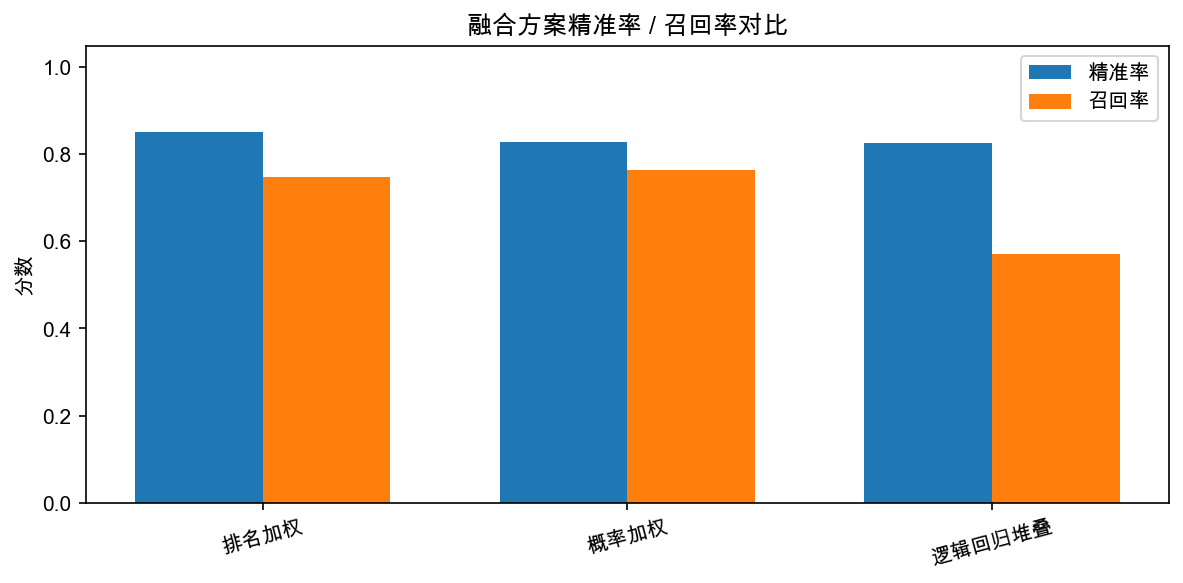

,融合方式,Precision,Recall,F1,AUC-PR,logloss,FP（误报）,FN（漏报）
1,排名加权,0.85165,0.74879,0.79692,0.78989,0.93122,27,52
0,概率加权,0.82723,0.76329,0.79397,0.73609,0.00334,33,49
2,逻辑回归堆叠,0.82517,0.57005,0.67429,0.70065,0.17358,25,89


最优融合（F1 优先）: rank_average_best | FP=27 FN=52
Rank logloss 失真：概率→百分位后 logloss 无校准意义
Stacking 失效可能：LGB/XGB OOF Pearson≈0.937，meta 特征高度共线


In [22]:
# §13 exec
state = load_state()
df_fe = bind_cv_data(pd.read_pickle(OUTPUT_DIR / 'df_features.pkl'))
TUNE_FEATURES, TUNE_LABEL = resolve_tune_feature_cols(state)
tune = json.loads((OUT_TUNE / 'tune_results.json').read_text(encoding='utf-8'))
oof_pkl = OUT_FUSION / 'base_oof.pkl'
oof_meta_path = OUT_FUSION / 'base_oof_meta.json'

print(f'§13 融合特征组: {TUNE_LABEL}（{len(TUNE_FEATURES)} 列，§7/8 胜者，不含 FE8）')
if tune.get('feature_group') != TUNE_LABEL:
    raise ValueError(
        f"tune_results 特征组 {tune.get('feature_group')!r} ≠ §7/8 胜者 {TUNE_LABEL!r}，请先重跑 §12"
    )

load_cached_oof = False
if oof_pkl.exists() and oof_meta_path.exists():
    oof_meta = json.loads(oof_meta_path.read_text(encoding='utf-8'))
    load_cached_oof = oof_meta.get('feature_group') == TUNE_LABEL
    if not load_cached_oof:
        print(f"忽略缓存 OOF（{oof_meta.get('feature_group')} ≠ {TUNE_LABEL}）")
if load_cached_oof:
    oof_df = pd.read_pickle(oof_pkl)
    print('加载缓存 OOF')
else:
    lgb_oof, _ = cross_val_oof_nan('LightGBM', df_fe, TUNE_FEATURES, tune['LightGBM'])
    xgb_oof, _ = cross_val_oof_nan('XGBoost', df_fe, TUNE_FEATURES, tune['XGBoost'])
    oof_df = df_fe[['Class']].copy()
    oof_df['LightGBM'] = lgb_oof
    oof_df['XGBoost'] = xgb_oof
    oof_df.to_pickle(oof_pkl)
    oof_meta_path.write_text(
        json.dumps({'feature_group': TUNE_LABEL}, ensure_ascii=False, indent=2),
        encoding='utf-8',
    )

y = oof_df['Class'].to_numpy()
lgb_oof = oof_df['LightGBM'].to_numpy()
xgb_oof = oof_df['XGBoost'].to_numpy()
base_mask = np.isfinite(lgb_oof) & np.isfinite(xgb_oof)
meta = pd.DataFrame({'lgb_oof': lgb_oof, 'xgb_oof': xgb_oof})
stack_oof, stack_coef = stacking_oof(meta, y)
fusion_mask = base_mask & np.isfinite(stack_oof)
fy, fl, fx, fs = y[fusion_mask], lgb_oof[fusion_mask], xgb_oof[fusion_mask], stack_oof[fusion_mask]

print(f'概率加权 isotonic 校准: CALIBRATE_WEIGHTED_FUSION={CALIBRATE_WEIGHTED_FUSION}')

# Nested：101 个 w 仅在 cal 拟合 (w,t*)，用 eval F1 选最优
best_w, wgrid = weighted_average_search(fy, fl, fx)
best_w['method'] = 'weighted_average_best'
best_r, rgrid = rank_average_search(fy, fl, fx)
best_r['method'] = 'rank_average_best'
# Stacking 无 w 网格；阈值仍 cal 定、eval 报（evaluate_prediction 默认模式 A）
stack_row = evaluate_prediction('logistic_stacking', fy, fs)
fusion_results = pd.DataFrame([best_w, best_r, stack_row]).sort_values(['F1','AUC-PR','logloss'], ascending=[False,False,True])

fusion_results.to_csv(OUT_FUSION / 'fusion_results.csv', index=False)
wgrid.to_csv(OUT_FUSION / 'weighted_average_grid.csv', index=False)
rgrid.to_csv(OUT_FUSION / 'rank_average_grid.csv', index=False)
corr = float(meta.loc[fusion_mask].corr().loc['lgb_oof','xgb_oof'])
(OUT_FUSION / 'stack_results.json').write_text(json.dumps({
    'best_fusion': fusion_results.iloc[0]['method'], 'pearson_corr': corr,
    'calibrate_weighted_fusion': CALIBRATE_WEIGHTED_FUSION,
    'note_rank_logloss': 'Rank 融合 logloss 因百分位排名失真，仅供参考',
    'note_stacking': f'OOF 高相关 ~{corr:.2f} → LR Stacking 难发挥',
    'fusion_results': fusion_results.to_dict(orient='records'),
}, ensure_ascii=False, indent=2), encoding='utf-8')

plot_fusion_pr_bars(fusion_results, OUT_FUSION / 'fusion_precision_recall.png')
fusion_show = present_fusion_results(fusion_results).round(5)
fusion_show['FP（误报）'] = fusion_results['FP'].astype(int).values
fusion_show['FN（漏报）'] = fusion_results['FN'].astype(int).values
display(fusion_show)
best = fusion_results.iloc[0]
print(f"最优融合（F1 优先）: {best['method']} | FP={int(best['FP'])} FN={int(best['FN'])}")
print('Rank logloss 失真：概率→百分位后 logloss 无校准意义')
print(f'Stacking 失效可能：LGB/XGB OOF Pearson≈{corr:.3f}，meta 特征高度共线')


## 模型性能优化方向

本节记录后续若要继续冲模型上限时，优先考虑的优化方向。

### 1. 模型融合的判断标准

CatBoost 的 base 在前期实验中表现很差，但不代表绝对不能融合，是否保留看它是否提供互补错误。判断标准不是单模型分数本身，而是：

```text
它的 OOF 预测和 LightGBM / XGBoost 的相关性是否较低
它在 Recall@ 或 AmountRecall 上是否有独立贡献
它是否能抓住现有模型稳定漏掉的一部分欺诈样本
```

个人以为或许该试试 DNN。

### 2. 关于 FP 加权

在训练中对 FP 加权不能直接使用最终验证集答案，否则会泄漏。正确做法是基于训练集内部的 OOF 预测：先用交叉验证找出训练集中反复被误判为欺诈的正常样本，再在下一轮训练中把这些样本加权。最终评估仍必须放在没有参与挖掘的验证段上。

## EX1/2. 关于损失函数和评价指标的实验

对每个训练折的 **fit 子集**，定义类别不平衡比：

$$r=\frac{N_0}{N_1}$$

金额函数使用对数、欺诈样本 95% 分位截尾，并缩放到 $[0,1]$：

$$g(A_i)=\frac{\min[\log(1+A_i),q_{95}^{+}]}{q_{95}^{+}}$$

小额卡测试指示变量：

$$h(A_i)=\mathbb I(A_i\le1)$$

欺诈内部业务权重：

$$u_i=1+\beta g(A_i)+\eta h(A_i)$$

其中基础项 1 保证零金额和小额欺诈不会被忽略；$\beta$ 只控制大额欺诈倾向；$\eta$ 只控制小额卡测试保护。为了避免改变 $\beta,\eta$ 时连带改变整个正类总权重，使用 fit 子集正类均值归一化：

$$\bar u_+=\frac1{N_1}\sum_{j:y_j=1}u_j$$

最终样本权重为：

$$w_i=\begin{cases}1,&y_i=0\\
\kappa r\dfrac{u_i}{\bar u_+},&y_i=1\end{cases}$$

损失函数是加权二元交叉熵：

$$\boxed{\mathcal L=-\frac1n\sum_iw_i[y_i\log p_i+(1-y_i)\log(1-p_i)]}$$

- $r$：处理类别不平衡，对应原模型的 balanced 权重。
- $\kappa$：调整整个欺诈类相对于正常类的重要性。
- $\beta$：在欺诈类内部向大额交易重新分配权重。
- $\eta$：在欺诈类内部向 `Amount<=1` 的卡测试交易重新分配权重。
- $\bar u_+$：让 $\beta,\eta$ 只改变正类内部结构，不偷偷放大正类总权重。

**防泄漏约束：** $r,q_{95}^{+},\bar u_+$ 只能在每折 fit 子集计算；早停集和验证折只能使用已有状态 transform。

参考：[`credit-fraud-amount-aware-loss.ipynb`](loss-function/credit-fraud-amount-aware-loss.ipynb)。

### 失败原因

虽然以上的损失函数设计用了银行的惯例做法，但现实中银行不会只靠 Amount 区分欺诈。由于所有其他特征的业务含义已被 PCA 脱敏破坏，哪怕照搬银行的损失函数设计也没好结果。同时各种情况下 AmountRecall 效果要么一般要么顾此失彼，让人不禁怀疑围绕这个指标优化是否真的值得。不是说 Amount Recall 没有业务意义，而是当前数据不足以支持模型稳定学习“高价值欺诈”的独立规律。Amount Recall 在当前情况下作为业务验收指标，而非训练和选参目标。

AI对实验的评价：在固定告警预算下，金额感知样本加权虽然在部分 calibration 实验中提高了 Amount Recall，但该增益未能稳定迁移到时间靠后的 evaluation 数据。两种模型、两个特征组中均未出现一致的 Pareto 改善；多数配置的 Amount Recall 下降，或伴随 F1、总召回率及误报表现恶化。因此，在当前匿名化、缺少账户标识与行为序列的数据条件下，直接围绕交易金额调整损失函数的收益有限。

## EX3. 基于 OOF 模型分数的 KS 分箱与风险分层

### EX3 的阈值与 F1 命名口径

“Top-K”：先按风险分数从高到低排序，只取最靠前的 K 部分交易做告警/人工审核。  
EX3 的 KS、十分位风险层和固定 Top-k 行都使用全量有效 OOF；Top-k 的分数截点由预先指定的告警预算决定，因此其阈值依赖指标统一写为 `@Top-k`。表末另保留 §13 的 F1 最优 `eval` 参考行，用于说明前文的低误报基准；它与全量 Top-k 行的样本范围和排名百分位口径不同，不能直接相减或横向比较。

### 1. 这一节究竟在做什么？

模型先给每笔交易一个风险分数，再把分数最高的交易排在最前面。**然而模型输出还需要和银行现实的业务成本相结合形成最终策略**，因此需要回答两个业务问题：

1. 如果银行只能处理最高风险的 0.01%、0.10%、0.50%、1%、2%、5% 或 10%，分别能抓到多少欺诈，又会误报多少正常交易？
2. 应该如何把模型输出转化成“最高风险层、中间风险层、最低风险层”等可使用的风险分层来支持银行后续多维度的风控策略？

这里的分层依据不是交易金额，而是模型综合使用 `V1–V28`、`Amount`、`Time` 和衍生特征以后得到的 OOF 风险排序。金额只用来观察各风险层的金额特征，以及计算漏掉了多少欺诈金额。

### 2. 几个基础概念

#### 2.1 `risk_score`

本节使用 §13 最优融合方案：先分别把 LightGBM 和 XGBoost 的 OOF 预测转换成“在全部样本中的排名百分位”，再按 0.63 和 0.37 加权平均。`risk_score` 越接近 1，表示这笔交易在当前样本中排得越靠前、相对风险越高；越接近 0，表示排名越靠后。

必须注意：`risk_score=0.90` 表示风险排名很高，不等于“有 90% 的概率是欺诈”。它是排名型风险分数，不是经过概率校准后的真实欺诈概率。

#### 2.2 KS

先把所有交易按风险分数从高到低排列，再从队首逐笔向后看：

- `样本累计占比`：从第 1 名累计到当前名次，一共看了全部有效样本的多少。
- `累计欺诈召回`：到当前位置为止，已经覆盖了全部欺诈中的多少。
- `累计正常覆盖`：到当前位置为止，也覆盖了全部正常交易中的多少。
- `KS = 累计欺诈召回 - 累计正常覆盖`。

如果一个模型没有区分能力，抓到欺诈的速度和纳入正常交易的速度差不多，KS 会接近 0。如果模型能把欺诈集中排在前面，累计欺诈召回会快速上升，而累计正常覆盖上升较慢，二者差距就会变大。KS 越大，说明排序区分能力越强；但 KS 只说明“排得好不好”，不直接告诉银行最终应该拦截多少交易。

### 2.3 KS 曲线表

KS 曲线表的每一行对应风险排序中的一个位置，共 237,335 行。列含义如下：

- `rank`：按风险从高到低的名次。1 表示全体有效 OOF 样本中风险最高的交易。
- `row_id`：交易在原始数据中的行号，用于回到原始数据定位这笔交易；它不是银行卡号或客户编号。
- `risk_score`：LightGBM/XGBoost 排名融合后的相对风险分数，越大越靠前，不是实际欺诈概率。

本次最大 KS 为 0.859，出现在最高风险的前 1.50%，对应风险分数约 0.976983。即检查到风险队列前 1.5% 时，“已覆盖欺诈比例”和“已覆盖正常比例”的差距最大，模型在这里的排序分离最明显。

这不等于银行应当直接采用 1.5% 作为拦截阈值。最终阈值还取决于每日可处理告警数、误报造成的客户打扰、漏报损失以及拦截和人工审核成本。KS 点更适合作为风险层边界或候选策略点，而不是自动生成的上线决策。

### 2.4 十分位风险层表

十分位是把 237,335 笔有效交易按风险从高到低平均分成十组，每组约占 10%。`D01` 是最高风险的 10%，`D10` 是最低风险的 10%。各列含义如下：

- `风险层`：分组编号。D01 最高，D10 最低。
- `风险说明`：方便阅读的中文标签，例如“最高风险层”。
- `样本数`：这一层一共有多少笔交易。
- `样本占比`：这一层占有效 OOF 样本的比例；十分位通常约为 0.10，即 10%。
- `欺诈数`：这一层真实欺诈交易的数量。
- `正常数`：这一层真实正常交易的数量。
- `欺诈率`：`欺诈数 ÷ 样本数`。这一层随机取一笔，有多大比例实际是欺诈。
- `Lift`：这一层欺诈率是全部有效样本平均欺诈率的多少倍。Lift=9 表示这一层的欺诈浓度约为总体平均水平的 9 倍；Lift=1 表示与总体平均相同；小于 1 表示低于总体平均。
- `欺诈召回贡献`：全部真实欺诈中，有多少落在这一层。例如 0.9017 表示这一层单独包含全部欺诈的 90.17%。
- `正常覆盖贡献`：全部正常交易中，有多少落在这一层。它反映这一层带来的正常交易处理量。
- `欺诈金额`：这一层所有真实欺诈交易金额的合计。
- `欺诈金额召回贡献`：全部欺诈金额中，有多少位于这一层。例如 0.8551 表示该层包含全部欺诈金额的 85.51%。
- `平均Amount`：这一层所有交易金额的平均值。
- `Amount中位数`：把这一层金额排序后位于正中间的金额；通常比平均数更能代表“典型交易金额”。
- `Amount_P95`：金额的第 95 百分位数，即这一层约 95% 的交易金额不超过该值，约 5% 更高。
- `risk_score下界`：进入这一风险层的最低 `risk_score`。
- `risk_score上界`：这一风险层中的最高 `risk_score`。

#### 本次十分位风险表结果

- D01 只有约 10% 的有效交易，却包含 312 笔欺诈，占全部有效 OOF 欺诈的 90.17%，同时包含全部欺诈金额的 85.51%。这说明模型确实把绝大多数欺诈集中到了最高风险层。
- D01 的欺诈率为 1.3146%，Lift 为 9.02。因为原始欺诈极少，即使风险浓度提高 9 倍，D01 中仍然绝大多数是正常交易：23,733 笔中有 23,421 笔正常。
- D02 只额外包含 10 笔欺诈，D03 包含 7 笔，后续各层的欺诈非常稀疏。到 D09 时累计欺诈召回达到 100%，D10 没有欺诈。
- D03 的欺诈数量只有 7 笔，但欺诈金额召回贡献为 8.37%，说明其中存在金额较大的欺诈。这也说明只看欺诈笔数会遗漏金额损失视角。

### 2.5 Top-K 固定告警预算策略表

表中的固定预算覆盖 Top 0.01%、0.02%、0.05%、0.10%、0.20%、0.50%、0.75%、1%、2%、3%、5%、10%；最大 KS 所在的 Top 1.50% 作为单独的参考点。主表只展示告警量、TP、FP、FN、Precision、Recall、F1 及相对上一档的新增 TP、FP 和边际 Precision；金额召回、漏掉金额、风险分截点等完整指标保存在 `ex3_topk_policy.csv`。

`相对上一档边际Precision = 新增TP ÷ 新增告警数`，用于判断扩大一档告警容量时，新加入交易的欺诈浓度。§13 的 F1 最优阈值参考单独保存为 `ex3_f1_eval_reference.csv`：其 FP=27 是 honest eval 结果，因与 EX3 全量 Top-K 的样本范围和排名口径不同，不能直接作差。

### 2.6 SHAP 候选样本表

这张表本身不是 SHAP 结果，而是为 EX4 挑选“值得解释的个案”。各列含义如下：

- `样本类型`：候选属于高置信 FP、典型 TP、低风险 FN 或大额 FN 中的哪一类。
- `row_id`：原始数据行号，用于在 EX4 和原始数据之间对应同一笔交易。
- `risk_score`：融合后的相对风险排名分数。
- `score_method`：生成 `risk_score` 的融合方法；本次为 `rank_average_best`，即最优排名加权融合。
- `LightGBM`：§13 中 LightGBM 对该样本给出的 OOF 预测值。
- `XGBoost`：§13 中 XGBoost 对该样本给出的 OOF 预测值。

四种候选：

- 高置信 FP：真实为正常，但模型排在极高风险位置。研究模型为什么会“误杀”。
- 典型 TP：真实为欺诈，而且模型风险极高。研究模型抓对时依赖哪些模式。
- 低风险 FN：真实为欺诈，但风险分数较低。研究模型为什么漏报。
- 大额 FN：真实为欺诈、未进入 Top 5%，并且金额相对较大。从潜在损失角度研究重要漏报。

### 3. EX3 最终结果

模型的 OOF 排序具有很强的风险集中能力，最大 KS 为 0.859；最高风险的 D01 层约占 10% 交易，却包含 90.17% 的欺诈笔数和 85.51% 的欺诈金额。固定告警预算实验进一步显示，Top 1% 已抓到 85.26% 的欺诈，但继续扩大队列带来的召回增益有限、误报成本快速上升。另外 D03 的欺诈数量只有 7 笔，但欺诈金额召回贡献为 8.37%，这可能对后面的 SHAP 单样本解释提出目标。  

**前文中最优 F1 的对应阈值虽可以看作一个 Top-K 策略值，但 EX3 的价值在于，银行有其业务（如误报代价、人工审核成本等）约束，不能简单选取最优 F1 阈值作为其业务策略。而 KS 分层可以提供一个业务策略分析的框架。**

In [23]:
# EX3 prep：OOF 风险分层 / KS 分箱 / Top-k 策略函数与配置
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def _ex3_display(df, n=20):
    """Notebook / script 双环境展示。"""
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n))


def _ex3_setup_output_dir():
    """尽量复用前文 OUTPUT_DIR；若单独运行本节，则按 notebook 固定目录兜底。"""
    global OUTPUT_DIR
    try:
        base = OUTPUT_DIR
    except NameError:
        base = Path('/Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report')
        OUTPUT_DIR = base
    out = Path(base) / 'EX3_risk_stratification'
    out.mkdir(parents=True, exist_ok=True)
    return out


def _ex3_rank_percentile(values):
    """与 §13 rank_average 的 rank(method='average', pct=True) 保持一致。"""
    return pd.Series(values).rank(method='average', pct=True).to_numpy()


def _ex3_load_amount_time(n_expected):
    """读取 Amount / Time；优先用已经按时间排序并保存的 df_features.pkl。"""
    candidate_paths = [
        Path(OUTPUT_DIR) / 'df_features.pkl',
        Path(OUTPUT_DIR) / 'df_modeling.pkl',
    ]
    for p in candidate_paths:
        if p.exists():
            df_amt = pd.read_pickle(p)
            if len(df_amt) == n_expected and {'Amount', 'Time'}.issubset(df_amt.columns):
                return df_amt[['Amount', 'Time']].reset_index(drop=True)

    # 兜底：直接读原始 creditcard.csv，并按 Time 排序以匹配主协议。
    try:
        raw = read_creditcard_csv(DATA_PATH)
    except NameError:
        raw_path = Path('/Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/input/creditcard.csv')
        raw = pd.read_csv(raw_path)
    raw = raw.sort_values('Time', kind='mergesort').reset_index(drop=True)
    if len(raw) != n_expected:
        raise ValueError(f'Amount/Time 长度 {len(raw):,} 与 OOF 长度 {n_expected:,} 不一致')
    return raw[['Amount', 'Time']]


def ex3_build_risk_scores(oof_df, fusion_results=None):
    """构造 EX3 的统一风险分数。

    优先级：
    1. 如果 §13 best method 是 rank_average_best，按记录的 w_lgb/w_xgb 重建 rank 融合分；
    2. 如果 best method 是 weighted_average_best，按记录权重重建概率加权分；
    3. 其他情况使用 LightGBM / XGBoost 平均分兜底。

    注：EX3 只做风险排序和分层，不重新搜索融合权重，也不重新调阈值。
    """
    out = oof_df.copy().reset_index(drop=True)
    if 'Class' not in out.columns:
        raise KeyError('OOF 数据必须包含 Class 列')
    for col in ['LightGBM', 'XGBoost']:
        if col not in out.columns:
            raise KeyError(f'OOF 数据缺少 {col} 列')

    method = 'simple_average_fallback'
    w_lgb = 0.5
    w_xgb = 0.5
    if fusion_results is not None and len(fusion_results):
        best = fusion_results.sort_values(['F1', 'AUC-PR', 'logloss'], ascending=[False, False, True]).iloc[0]
        method = str(best.get('method', method))
        if pd.notna(best.get('w_lgb', np.nan)):
            w_lgb = float(best['w_lgb'])
            w_xgb = float(best.get('w_xgb', 1.0 - w_lgb))

    valid_base = out['LightGBM'].notna() & out['XGBoost'].notna()
    if method == 'rank_average_best':
        l_rank = np.full(len(out), np.nan, dtype=float)
        x_rank = np.full(len(out), np.nan, dtype=float)
        l_rank[valid_base] = _ex3_rank_percentile(out.loc[valid_base, 'LightGBM'].to_numpy())
        x_rank[valid_base] = _ex3_rank_percentile(out.loc[valid_base, 'XGBoost'].to_numpy())
        out['risk_score'] = w_lgb * l_rank + w_xgb * x_rank
        score_note = '§13 最优 rank_average_best：风险分数是 LGB/XGB OOF 排名百分位的加权平均。'
    elif method == 'weighted_average_best':
        out['risk_score'] = w_lgb * out['LightGBM'] + w_xgb * out['XGBoost']
        score_note = '§13 最优 weighted_average_best：风险分数是 LGB/XGB OOF 概率的加权平均。'
    else:
        out['risk_score'] = 0.5 * out['LightGBM'] + 0.5 * out['XGBoost']
        score_note = '未重建复杂融合方法，使用 LGB/XGB OOF 概率均值作为风险分数。'

    amt_time = _ex3_load_amount_time(len(out))
    out['Amount'] = amt_time['Amount'].to_numpy()
    out['Time'] = amt_time['Time'].to_numpy()
    out['row_id'] = np.arange(len(out))
    out['score_method'] = method
    out['score_weight_lgb'] = w_lgb
    out['score_weight_xgb'] = w_xgb
    return out, {
        'score_method': method,
        'score_weight_lgb': w_lgb,
        'score_weight_xgb': w_xgb,
        'score_note': score_note,
        'n_total': int(len(out)),
        'n_valid_score': int(out['risk_score'].notna().sum()),
    }


def ex3_make_ks_curve(scores_df):
    """按风险分数降序计算逐样本累计 KS 曲线。"""
    df = scores_df.loc[scores_df['risk_score'].notna()].copy()
    df = df.sort_values('risk_score', ascending=False, kind='mergesort').reset_index(drop=True)
    df['rank'] = np.arange(1, len(df) + 1)
    df['样本累计占比'] = df['rank'] / len(df)
    y = df['Class'].astype(int).to_numpy()
    bad_total = max(int((y == 1).sum()), 1)
    good_total = max(int((y == 0).sum()), 1)
    df['累计欺诈召回'] = np.cumsum(y == 1) / bad_total
    df['累计正常覆盖'] = np.cumsum(y == 0) / good_total
    df['KS'] = df['累计欺诈召回'] - df['累计正常覆盖']
    return df[['rank', 'row_id', 'risk_score', 'Class', 'Amount', '样本累计占比', '累计欺诈召回', '累计正常覆盖', 'KS']]


def ex3_make_decile_table(scores_df):
    """十分位风险层：D01 最高风险，D10 最低风险。"""
    df = scores_df.loc[scores_df['risk_score'].notna()].copy()
    total_n = len(df)
    total_fraud = max(int(df['Class'].sum()), 1)
    total_normal = max(int((df['Class'] == 0).sum()), 1)
    total_fraud_amount = float(df.loc[df['Class'] == 1, 'Amount'].sum())
    overall_fraud_rate = df['Class'].mean()

    rank_pct = df['risk_score'].rank(method='first', ascending=False, pct=True)
    df['risk_decile'] = np.ceil(rank_pct * 10).astype(int).clip(1, 10)

    rows = []
    for decile, g in df.groupby('risk_decile', sort=True):
        y = g['Class'].astype(int)
        fraud_amount = float(g.loc[y == 1, 'Amount'].sum())
        fraud_rate = float(y.mean()) if len(g) else 0.0
        rows.append({
            '风险层': f'D{decile:02d}',
            '风险说明': '最高风险层' if decile == 1 else ('最低风险层' if decile == 10 else '中间风险层'),
            '样本数': int(len(g)),
            '样本占比': len(g) / total_n,
            '欺诈数': int(y.sum()),
            '正常数': int((y == 0).sum()),
            '欺诈率': fraud_rate,
            'Lift': fraud_rate / overall_fraud_rate if overall_fraud_rate > 0 else np.nan,
            '欺诈召回贡献': int(y.sum()) / total_fraud,
            '正常覆盖贡献': int((y == 0).sum()) / total_normal,
            '欺诈金额': fraud_amount,
            '欺诈金额召回贡献': fraud_amount / total_fraud_amount if total_fraud_amount > 0 else np.nan,
            '平均Amount': float(g['Amount'].mean()),
            'Amount中位数': float(g['Amount'].median()),
            'Amount_P95': float(g['Amount'].quantile(0.95)),
            'risk_score下界': float(g['risk_score'].min()),
            'risk_score上界': float(g['risk_score'].max()),
        })
    out = pd.DataFrame(rows).sort_values('风险层')
    out['累计欺诈召回'] = out['欺诈召回贡献'].cumsum()
    out['累计正常覆盖'] = out['正常覆盖贡献'].cumsum()
    out['累计KS'] = out['累计欺诈召回'] - out['累计正常覆盖']
    return out


EX3_TOPK_METRIC_SUFFIX = '@Top-K'
EX3_TOPK_RATES = (0.0001, 0.0002, 0.0005, 0.001, 0.00125, 0.0015, 0.00175, 0.002, 0.005, 0.0075, 0.01, 0.02, 0.03, 0.05, 0.10)


def _ex3_topk_row(df, n_alert, strategy):
    """按告警队列长度计算全量 OOF 的统一策略指标。"""
    y_all = df['Class'].astype(int).to_numpy()
    pred = np.zeros(len(df), dtype=int)
    pred[:n_alert] = 1
    tn, fp, fn, tp = confusion_matrix(y_all, pred, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    total_fraud_amount = float(df.loc[df['Class'] == 1, 'Amount'].sum())
    caught_amount = float(df.loc[:n_alert - 1].query('Class == 1')['Amount'].sum())
    return {
        '策略': strategy, '告警样本占比': n_alert / len(df),
        f'告警交易数{EX3_TOPK_METRIC_SUFFIX}': int(n_alert),
        f'TP{EX3_TOPK_METRIC_SUFFIX}': int(tp), f'FP{EX3_TOPK_METRIC_SUFFIX}': int(fp),
        f'FN{EX3_TOPK_METRIC_SUFFIX}': int(fn), f'Precision{EX3_TOPK_METRIC_SUFFIX}': precision,
        f'Recall{EX3_TOPK_METRIC_SUFFIX}': recall, f'F1{EX3_TOPK_METRIC_SUFFIX}': f1,
        f'FPR{EX3_TOPK_METRIC_SUFFIX}': fp / (fp + tn) if (fp + tn) else 0.0,
        f'欺诈金额召回率{EX3_TOPK_METRIC_SUFFIX}': caught_amount / total_fraud_amount if total_fraud_amount > 0 else np.nan,
        f'漏掉欺诈金额{EX3_TOPK_METRIC_SUFFIX}': total_fraud_amount - caught_amount,
        f'风险分截点{EX3_TOPK_METRIC_SUFFIX}': float(df.loc[n_alert - 1, 'risk_score']),
    }


def ex3_make_topk_policy(scores_df, ks_best_rank, top_rates=EX3_TOPK_RATES):
    """固定预算与最大 KS 点：统一在全量有效 OOF 风险排序上计算。"""
    df = scores_df.loc[scores_df['risk_score'].notna()].copy()
    df = df.sort_values('risk_score', ascending=False, kind='mergesort').reset_index(drop=True)
    specs = [(max(1, int(np.ceil(len(df) * rate))), f'Top {rate:.2%}') for rate in top_rates]
    specs.append((int(ks_best_rank), f'最大KS点（Top {ks_best_rank / len(df):.2%})'))
    rows, seen = [], set()
    for n_alert, strategy in specs:
        if n_alert in seen:
            continue
        seen.add(n_alert)
        rows.append(_ex3_topk_row(df, n_alert, strategy))
    out = pd.DataFrame(rows).sort_values(f'告警交易数{EX3_TOPK_METRIC_SUFFIX}').reset_index(drop=True)
    alert_col, tp_col, fp_col = (f'告警交易数{EX3_TOPK_METRIC_SUFFIX}', f'TP{EX3_TOPK_METRIC_SUFFIX}', f'FP{EX3_TOPK_METRIC_SUFFIX}')
    out['相对上一档新增告警数'] = out[alert_col].diff()
    out['相对上一档新增TP'] = out[tp_col].diff()
    out['相对上一档新增FP'] = out[fp_col].diff()
    out['相对上一档边际Precision'] = out['相对上一档新增TP'] / out['相对上一档新增告警数']
    return out


def ex3_make_f1_eval_reference(fusion_results):
    """保留 §13 honest eval 的 F1 基准；不与全量 Top-K 行作差。"""
    best = fusion_results.sort_values(['F1', 'AUC-PR', 'logloss'], ascending=[False, False, True]).iloc[0]
    tp = int(round(float(best['Recall']) * (float(best['FN']) / max(1.0 - float(best['Recall']), 1e-12))))
    fp, fn, n_eval = int(best['FP']), int(best['FN']), int(best['n_eval'])
    return pd.DataFrame([{
        '策略': '§13 F1最优阈值参考', '评估范围': '§13 eval', '告警样本占比': (tp + fp) / n_eval,
        f'告警交易数{EX3_TOPK_METRIC_SUFFIX}': tp + fp, f'TP{EX3_TOPK_METRIC_SUFFIX}': tp,
        f'FP{EX3_TOPK_METRIC_SUFFIX}': fp, f'FN{EX3_TOPK_METRIC_SUFFIX}': fn,
        f'Precision{EX3_TOPK_METRIC_SUFFIX}': float(best['Precision']), f'Recall{EX3_TOPK_METRIC_SUFFIX}': float(best['Recall']),
        f'F1{EX3_TOPK_METRIC_SUFFIX}': float(best['F1']), '§13 best_threshold': float(best['best_threshold']),
    }])


def ex3_make_shap_candidate_table(scores_df, top_fp=20, top_tp=20, low_fn=20, large_fn=20):
    """为下一节 SHAP 单样本解释准备候选样本。"""
    df = scores_df.loc[scores_df['risk_score'].notna()].copy()
    p99 = df['risk_score'].quantile(0.99)
    p95 = df['risk_score'].quantile(0.95)
    p50 = df['risk_score'].quantile(0.50)

    parts = []
    high_fp = df[(df['Class'] == 0) & (df['risk_score'] >= p99)].sort_values('risk_score', ascending=False).head(top_fp).copy()
    high_fp['样本类型'] = '高置信FP：模型分数极高但真实为正常'
    parts.append(high_fp)

    typical_tp = df[(df['Class'] == 1) & (df['risk_score'] >= p95)].sort_values('risk_score', ascending=False).head(top_tp).copy()
    typical_tp['样本类型'] = '典型TP：高风险层内被模型抓到的欺诈'
    parts.append(typical_tp)

    low_fn = df[(df['Class'] == 1) & (df['risk_score'] <= p50)].sort_values('risk_score', ascending=True).head(low_fn).copy()
    low_fn['样本类型'] = '低风险FN：真实欺诈但模型分数偏低'
    parts.append(low_fn)

    large_fn = df[(df['Class'] == 1) & (df['risk_score'] < p95)].sort_values('Amount', ascending=False).head(large_fn).copy()
    large_fn['样本类型'] = '大额FN候选：未进入Top5%但金额较大的欺诈'
    parts.append(large_fn)

    cand = pd.concat(parts, ignore_index=True)
    keep = ['样本类型', 'row_id', 'Time', 'Amount', 'Class', 'risk_score', 'LightGBM', 'XGBoost', 'score_method']
    cand = cand[keep].drop_duplicates(subset=['样本类型', 'row_id']).sort_values(['样本类型', 'risk_score'], ascending=[True, False])
    return cand


EX3 风险分数口径： §13 最优 rank_average_best：风险分数是 LGB/XGB OOF 排名百分位的加权平均。
有效 OOF 样本数：237,335 / 284,807
最大 KS=0.8590，发生在累计样本占比=1.50%，风险分数阈值≈0.976983

=== EX3 十分位风险层表（D01 最高风险）===


,风险层,风险说明,样本数,样本占比,欺诈数,欺诈率,Lift,欺诈召回贡献,累计欺诈召回,欺诈金额召回贡献,累计KS,平均Amount,Amount中位数,Amount_P95,risk_score下界,risk_score上界
0,D01,最高风险层,23733,0.099998,312,0.013146,9.017531,0.901734,0.901734,0.855145,0.802907,116.768819,12.310,500.0000,0.876306,0.999993
1,D02,中间风险层,23734,0.100002,10,0.000421,0.289011,0.028902,0.930636,0.029681,0.731703,99.529077,16.400,463.7215,0.776798,0.876295
2,D03,中间风险层,23733,0.099998,7,0.000295,0.202316,0.020231,0.950867,0.083700,0.651819,93.643509,15.730,415.6880,0.684927,0.776797
3,D04,中间风险层,23734,0.100002,3,0.000126,0.086703,0.008671,0.959538,0.000779,0.560354,83.842857,18.640,350.0000,0.594493,0.684925
4,D05,中间风险层,23733,0.099998,6,0.000253,0.173414,0.017341,0.976879,0.001165,0.477577,81.717590,19.940,338.7900,0.503915,0.594493
5,D06,中间风险层,23734,0.100002,4,0.000169,0.115605,0.011561,0.988439,0.026517,0.389006,83.115362,22.000,344.6135,0.410972,0.503915
6,D07,中间风险层,23733,0.099998,1,0.000042,0.028902,0.002890,0.991329,0.000112,0.291757,87.151774,26.940,350.4060,0.313498,0.410967
7,D08,中间风险层,23734,0.100002,2,0.000084,0.057802,0.005780,0.997110,0.000742,0.197398,88.414803,30.375,354.9145,0.215572,0.313494
8,D09,中间风险层,23733,0.099998,1,0.000042,0.028902,0.002890,1.000000,0.002158,0.100148,83.120620,30.650,332.8200,0.121816,0.215572
9,D10,最低风险层,23734,0.100002,0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,59.482897,23.985,231.8900,0.000020,0.121813



=== EX3 Top-K 固定告警预算策略表（全量有效 OOF）===


,策略,告警样本占比,告警交易数@Top-K,TP@Top-K,FP@Top-K,FN@Top-K,Precision@Top-K,Recall@Top-K,F1@Top-K,欺诈金额召回率@Top-K,漏掉欺诈金额@Top-K,相对上一档新增TP,相对上一档新增FP,相对上一档边际Precision
0,Top 0.01%,0.000101,24,24,0,322,1.000000,0.069364,0.129730,0.096676,41025.03,NaN,NaN,NaN
1,Top 0.02%,0.000202,48,48,0,298,1.000000,0.138728,0.243655,0.257922,33701.92,24.0,0.0,1.000000
2,Top 0.05%,0.000501,119,116,3,230,0.974790,0.335260,0.498925,0.429408,25913.78,68.0,3.0,0.957746
3,Top 0.10%,0.001003,238,221,17,125,0.928571,0.638728,0.756849,0.616099,17435.09,105.0,14.0,0.882353
4,Top 0.12%,0.001251,297,258,39,88,0.868687,0.745665,0.802488,0.687871,14175.55,37.0,22.0,0.627119
5,Top 0.15%,0.001504,357,270,87,76,0.756303,0.780347,0.768137,0.705513,13374.32,12.0,48.0,0.200000
6,Top 0.18%,0.001753,416,279,137,67,0.670673,0.806358,0.732283,0.712409,13061.14,9.0,50.0,0.152542
7,Top 0.20%,0.002001,475,285,190,61,0.600000,0.823699,0.694275,0.730995,12217.03,6.0,53.0,0.101695
8,Top 0.50%,0.005001,1187,290,897,56,0.244313,0.838150,0.378343,0.760037,10898.08,5.0,707.0,0.007022
9,Top 0.75%,0.007504,1781,294,1487,52,0.165076,0.849711,0.276446,0.760978,10855.31,4.0,590.0,0.006734


完整指标已保存：/Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/EX3_risk_stratification/ex3_topk_policy.csv
§13 F1 阈值参考已单独保存：/Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/EX3_risk_stratification/ex3_f1_eval_reference.csv

=== EX3 SHAP 单样本解释候选清单（下一节使用）===


,样本类型,row_id,Time,Amount,Class,risk_score,LightGBM,XGBoost,score_method
47,低风险FN：真实欺诈但模型分数偏低,101509,67857.0,320.00,1,0.481329,0.000027,0.000036,rank_average_best
46,低风险FN：真实欺诈但模型分数偏低,112840,72824.0,45.03,1,0.475424,0.000008,0.000092,rank_average_best
45,低风险FN：真实欺诈但模型分数偏低,91671,63578.0,290.18,1,0.435085,0.000013,0.000048,rank_average_best
44,低风险FN：真实欺诈但模型分数偏低,100623,67571.0,549.06,1,0.427944,0.000009,0.000061,rank_average_best
43,低风险FN：真实欺诈但模型分数偏低,79874,58217.0,5.09,1,0.372909,0.000006,0.000053,rank_average_best
...,...,...,...,...,...,...,...,...,...
15,高置信FP：模型分数极高但真实为正常,149865,92087.0,1.00,0,0.999012,0.948154,0.802282,rank_average_best
16,高置信FP：模型分数极高但真实为正常,185669,126765.0,0.77,0,0.999009,0.944874,0.809362,rank_average_best
17,高置信FP：模型分数极高但真实为正常,94432,64883.0,1.29,0,0.998985,0.827260,0.916190,rank_average_best
18,高置信FP：模型分数极高但真实为正常,191587,129332.0,0.77,0,0.998983,0.983425,0.527121,rank_average_best


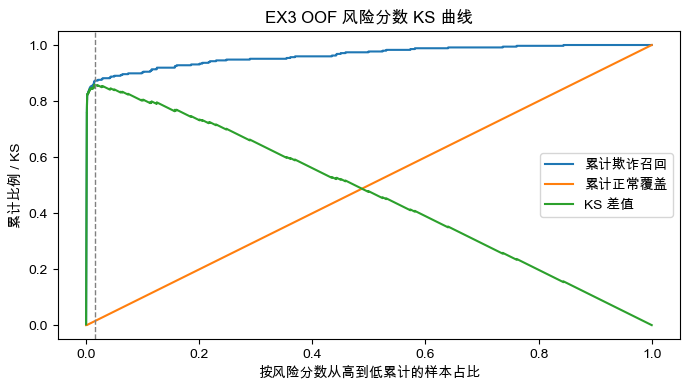

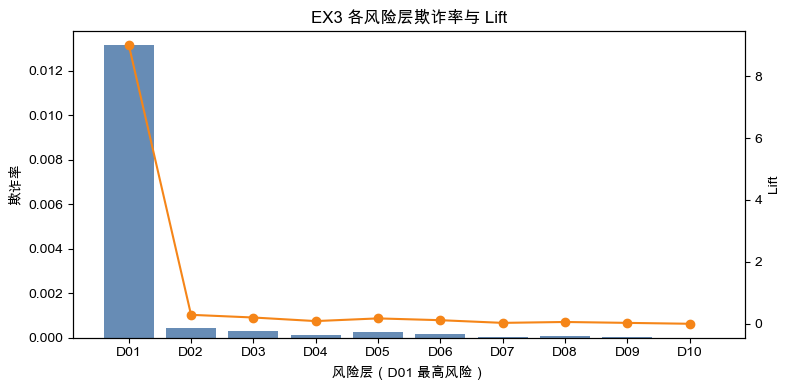


已保存 EX3 输出 → /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/EX3_risk_stratification


In [24]:
# EX3 exec：生成 OOF 风险分层、KS 分箱与策略输出
OUT_EX3 = _ex3_setup_output_dir()
OUT_FUSION_EX3 = Path(OUTPUT_DIR) / '13_fusion'
oof_path = OUT_FUSION_EX3 / 'base_oof.pkl'
fusion_path = OUT_FUSION_EX3 / 'fusion_results.csv'

if not oof_path.exists():
    raise FileNotFoundError(f'未找到 §13 OOF 缓存：{oof_path}。请先运行 §13，或确认 base_oof.pkl 是否存在。')

oof_df_ex3 = pd.read_pickle(oof_path)
fusion_results_ex3 = pd.read_csv(fusion_path) if fusion_path.exists() else None
scores_ex3, score_meta_ex3 = ex3_build_risk_scores(oof_df_ex3, fusion_results_ex3)
valid_scores_ex3 = scores_ex3.loc[scores_ex3['risk_score'].notna()].copy()

ks_curve_ex3 = ex3_make_ks_curve(scores_ex3)
ks_best_ex3 = ks_curve_ex3.loc[ks_curve_ex3['KS'].idxmax()]
decile_layers_ex3 = ex3_make_decile_table(scores_ex3)
topk_policy_ex3 = ex3_make_topk_policy(scores_ex3, ks_best_rank=int(ks_best_ex3['rank']))
if fusion_results_ex3 is None or fusion_results_ex3.empty:
    raise FileNotFoundError(f'未找到 §13 融合结果：{fusion_path}，无法生成 F1 阈值参考行。')
f1_eval_reference_ex3 = ex3_make_f1_eval_reference(fusion_results_ex3)
shap_candidates_ex3 = ex3_make_shap_candidate_table(scores_ex3)

scores_ex3.to_csv(OUT_EX3 / 'ex3_oof_scores.csv', index=False, encoding='utf-8-sig')
ks_curve_ex3.to_csv(OUT_EX3 / 'ex3_ks_curve.csv', index=False, encoding='utf-8-sig')
decile_layers_ex3.to_csv(OUT_EX3 / 'ex3_decile_risk_layers.csv', index=False, encoding='utf-8-sig')
topk_policy_ex3.to_csv(OUT_EX3 / 'ex3_topk_policy.csv', index=False, encoding='utf-8-sig')
f1_eval_reference_ex3.to_csv(OUT_EX3 / 'ex3_f1_eval_reference.csv', index=False, encoding='utf-8-sig')
shap_candidates_ex3.to_csv(OUT_EX3 / 'ex3_shap_sample_candidates.csv', index=False, encoding='utf-8-sig')
(OUT_EX3 / 'ex3_score_meta.json').write_text(json.dumps(score_meta_ex3, ensure_ascii=False, indent=2), encoding='utf-8')

print('EX3 风险分数口径：', score_meta_ex3['score_note'])
print(f"有效 OOF 样本数：{score_meta_ex3['n_valid_score']:,} / {score_meta_ex3['n_total']:,}")
print(f"最大 KS={ks_best_ex3['KS']:.4f}，发生在累计样本占比={ks_best_ex3['样本累计占比']:.2%}，风险分数阈值≈{ks_best_ex3['risk_score']:.6f}")

print('\n=== EX3 十分位风险层表（D01 最高风险）===')
show_cols = [
    '风险层', '风险说明', '样本数', '样本占比', '欺诈数', '欺诈率', 'Lift',
    '欺诈召回贡献', '累计欺诈召回', '欺诈金额召回贡献', '累计KS',
    '平均Amount', 'Amount中位数', 'Amount_P95', 'risk_score下界', 'risk_score上界'
]
_ex3_display(decile_layers_ex3[show_cols].round(6), n=10)

print('\n=== EX3 Top-K 固定告警预算策略表（全量有效 OOF）===')
topk_display_cols = [
    '策略', '告警样本占比', f'告警交易数{EX3_TOPK_METRIC_SUFFIX}',
    f'TP{EX3_TOPK_METRIC_SUFFIX}', f'FP{EX3_TOPK_METRIC_SUFFIX}', f'FN{EX3_TOPK_METRIC_SUFFIX}',
    f'Precision{EX3_TOPK_METRIC_SUFFIX}', f'Recall{EX3_TOPK_METRIC_SUFFIX}', f'F1{EX3_TOPK_METRIC_SUFFIX}',
    f'欺诈金额召回率{EX3_TOPK_METRIC_SUFFIX}', f'漏掉欺诈金额{EX3_TOPK_METRIC_SUFFIX}',
    '相对上一档新增TP', '相对上一档新增FP', '相对上一档边际Precision',
]
_ex3_display(topk_policy_ex3[topk_display_cols].round(6), n=len(topk_policy_ex3))
print(f"完整指标已保存：{OUT_EX3 / 'ex3_topk_policy.csv'}")
print(f"§13 F1 阈值参考已单独保存：{OUT_EX3 / 'ex3_f1_eval_reference.csv'}")

print('\n=== EX3 SHAP 单样本解释候选清单（下一节使用）===')
_ex3_display(shap_candidates_ex3.round(6), n=80)

# 图 1：KS 曲线
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks_curve_ex3['样本累计占比'], ks_curve_ex3['累计欺诈召回'], label='累计欺诈召回')
ax.plot(ks_curve_ex3['样本累计占比'], ks_curve_ex3['累计正常覆盖'], label='累计正常覆盖')
ax.plot(ks_curve_ex3['样本累计占比'], ks_curve_ex3['KS'], label='KS 差值')
ax.axvline(float(ks_best_ex3['样本累计占比']), color='grey', linestyle='--', linewidth=1)
ax.set_title('EX3 OOF 风险分数 KS 曲线')
ax.set_xlabel('按风险分数从高到低累计的样本占比')
ax.set_ylabel('累计比例 / KS')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_EX3 / 'ex3_ks_curve.png', dpi=160, bbox_inches='tight')
plt.show()

# 图 2：decile 欺诈率和 lift
fig, ax1 = plt.subplots(figsize=(8, 4))
x = np.arange(len(decile_layers_ex3))
ax1.bar(x, decile_layers_ex3['欺诈率'], color='#4C78A8', alpha=0.85, label='欺诈率')
ax1.set_ylabel('欺诈率')
ax1.set_xticks(x)
ax1.set_xticklabels(decile_layers_ex3['风险层'])
ax1.set_xlabel('风险层（D01 最高风险）')
ax2 = ax1.twinx()
ax2.plot(x, decile_layers_ex3['Lift'], color='#F58518', marker='o', label='Lift')
ax2.set_ylabel('Lift')
ax1.set_title('EX3 各风险层欺诈率与 Lift')
fig.tight_layout()
fig.savefig(OUT_EX3 / 'ex3_decile_fraud_rate_lift.png', dpi=160, bbox_inches='tight')
plt.show()

print('\n已保存 EX3 输出 →', OUT_EX3)


## EX4. SHAP 单样本解释：高置信 FP / TP / FN / 大额 FN

### 1. SHAP

SHAP 可以把一次模型判断拆成若干个特征的加分项和减分项：有些特征把判断推向“更像欺诈”，另一些特征把判断推向“更像正常”。让我们能具体检查“这次为什么抓对、为什么误报、为什么漏报”。

### 2. 为什么采用 OOF 折内解释？

OOF 折内解释的意思是：每个候选样本只由“训练时没有见过它”的时间折模型计算 SHAP。这与 EX3 的 OOF 风险分层口径一致。如果改用在全量数据上训练的最终模型解释低风险 FN，模型可能已经在训练中记住这笔欺诈，再给出很高概率，从而掩盖当时真正漏报的原因。

本节解释的是同一特征组、同一时间折训练流程下的 **LightGBM 组件**。§13 的最终 `risk_score` 是 LightGBM 与 XGBoost 排名百分位的加权融合，不是一棵可以直接计算 TreeSHAP 的树。因此：

- EX4 可以解释 LightGBM 组件为什么把某笔交易判高或判低。
- EX4 不能直接解释整个排名融合分数。

### 3. 几个基础概念

#### 3.1 SHAP value

SHAP value 表示某个特征对当前样本模型输出的局部贡献：

- SHAP 为正：把模型输出推向更高欺诈风险。
- SHAP 为负：把模型输出推向更低欺诈风险。
- 绝对值越大：这个特征对这次判断的影响越强。
- 接近 0：这个特征对这次判断影响很小。

本节 TreeSHAP 的加法发生在 LightGBM 的原始输出尺度上，通常可理解为对数优势（log-odds）尺度，而不是直接在 0–1 概率上相加。模型会再把原始输出转换成 `欺诈概率@LightGBM折内OOF模型`。因此“SHAP=2”不是“概率增加 200%”，而是“该特征对风险判断产生较强的正向推动”。

#### 3.2 base value

base value 是模型在还没有考虑当前样本具体特征前的基准输出，可以近似理解为模型的起点。对某个样本：

`最终原始输出 = base value + 所有特征的 SHAP value 之和`。

waterfall 图就是从这个起点出发，逐项展示正向和负向贡献如何把结果推到最终输出。

### 4. 四类样本

- **高置信 FP**：真实正常，但风险分数极高。用于诊断误报是否由某组“非常像欺诈”的特征模式造成。
- **典型 TP**：真实欺诈，且处于高风险层。用于理解模型抓对时最依赖哪些特征。
- **低风险 FN**：真实欺诈，但模型风险分数偏低。用于诊断模型忽略了什么，或哪些负向特征压低了判断。
- **大额 FN**：未进入 Top 5% 的真实欺诈中金额较大的候选。用于优先检查可能带来较大损失的漏报（来自 EX3 中 D03 风险层结论的警示）。

同一笔交易可能同时属于低风险 FN 和大额 FN，因此 68 行候选中可能出现相同的 `row_id`，但 `样本类型` 不同。

### 5. 单样本 SHAP 摘要表

这张表一共 68 行，每行代表“某种诊断类型下的一笔候选交易”。各列含义如下：

- `样本类型`：这行属于高置信 FP、典型 TP、低风险 FN 或大额 FN。
- `row_id`：原始数据中的行号，用于定位交易，不是客户编号。
- `风险分@EX3融合`：§13 LightGBM/XGBoost 排名融合后的相对风险分数。接近 1 表示排序很靠前，不等于实际欺诈概率接近 100%。
- `LightGBM概率@EX3融合输入`：§13 原始 LightGBM 对该样本给出的 OOF 概率输出。
- `XGBoost概率@EX3融合输入`：§13 原始 XGBoost 对该样本给出的 OOF 概率输出。
- `欺诈概率@LightGBM折内OOF模型`：为了计算 SHAP，按同一时间折和同一特征组重新训练的 LightGBM 解释模型对该样本给出的概率。它应与 `LightGBM概率@EX3融合输入` 的判断方向高度一致，但因重新训练细节和最佳迭代轮数可能略有差异。
- `SHAP基准值@LightGBM折内OOF模型`：解释模型在原始输出尺度上的基准值，是 waterfall 图的起点，不是欺诈概率。
- `Top正向特征`：把当前样本推向更高欺诈风险的主要特征。括号中的正数是该特征的正向 SHAP 贡献。
- `Top负向特征`：把当前样本推向更低欺诈风险的主要特征。括号中的负数是负向 SHAP 贡献；若显示“—”，表示最主要贡献几乎都在正向推动。
- `解释摘要`：把最重要的正向和负向贡献组合成便于阅读的一句话。它只是模型行为摘要，不是对真实欺诈原因的证明。

#### 为什么 `risk_score` 不低，但原始模型概率仍可能很小？

`风险分@EX3融合` 使用的是排名百分位。欺诈极度稀少时，很多原始概率都会非常小；其中相对较大的样本仍可能排到较高百分位。因此某个大额 FN 的 `risk_score` 可能为 0.6 左右，而 `LightGBM概率@EX3融合输入` 只有 0.0001 左右。这并不矛盾：前者描述“相对排名”，后者才是模型的原始概率输出。

### 6. 分组平均 SHAP 表

单样本解释容易受个别交易影响，因此还要把同一种 `样本类型` 的候选放在一起，观察共同模式。各列含义如下：

- `平均|SHAP|@LightGBM折内OOF模型`：该类样本中，这个特征 SHAP 绝对值的平均数。它只看影响强弱，不区分方向；数值越大，说明这个特征对该类样本的判断越重要。
- `平均SHAP值@LightGBM折内OOF模型`：该类样本中，这个特征带符号 SHAP 的平均数。正值表示平均而言推高风险，负值表示平均而言压低风险。正负贡献可能在不同样本间互相抵消，所以判断重要性优先看 `平均|SHAP|@LightGBM折内OOF模型`，判断平均方向再看 `平均SHAP值@LightGBM折内OOF模型`。

例如某特征在一半样本中贡献 +2、另一半贡献 -2，那么 `mean_SHAP` 接近 0，但 `mean_abs_SHAP` 约为 2。它仍然很重要，只是作用方向随样本而变化。

### 7. waterfall 图和索引表

索引表告诉我们每张 waterfall 图对应哪笔交易：

- `样本类型`：图中样本所属的诊断类型。
- `row_id`：图中交易的原始行号。
- `waterfall_path`：图片保存路径。

waterfall 图的阅读顺序是：

1. 从 base value（基准输出）出发。
2. 红色或向右的特征通常表示正向推动，即让模型更倾向于欺诈。
3. 蓝色或向左的特征通常表示负向推动，即让模型更倾向于正常。
4. 条越长，影响越大。
5. 所有贡献相加后到达图中的最终 `f(x)`；再经过概率转换，得到 `oof_shap_model_proba`。

本节只画 12 张代表性图，即四类样本各 3 张。`ex4_shap_sample_summary.csv` 仍保留全部 68 条候选的文字解释和主要特征。

### 8. EX4 结果

#### 9.1 典型 TP：模型抓对时依赖的模式很集中

20 个典型 TP 的平均 `LightGBM_OOF` 约为 0.999998，解释模型平均概率约为 0.999874。分组 SHAP 中最重要的特征依次包括 `V14`、`V4`、`V12`、`V10`、`V17` 等，且这些特征的平均贡献大多强烈为正。这说明模型抓住典型欺诈时，依赖的是一组非常鲜明、共同出现的匿名特征模式。

#### 9.2 高置信 FP：长得很像欺诈

20 个高置信 FP 的平均 `LightGBM_OOF` 约为 0.9786，解释模型平均概率约为 0.9815。它们最重要的正向特征同样是 `V14`、`V4`、`V12`、`V10`，与典型 TP 高度重合。

这说明这些正常样本在模型可见的匿名特征空间里非常像典型欺诈，因此属于**结构性误报**，而不是分数刚好越过阈值的普通 FP。可能的改进方向包括补充当前数据中不存在的账户历史、设备、商户、地理位置和交易序列特征，帮助模型区分“看起来像欺诈的正常交易”和真正欺诈；也需要考虑公开标签可能存在噪声。但仅凭 SHAP 不能断言标签一定错误。

这组高置信 FP 的金额中位数为 1.00，说明本次被选出的高危误报多为小额交易。不过这只是候选样本画像，不能据此得出“所有小额交易都容易误报”或“小额本身导致误报”；真正的主要推动仍来自 `V14/V4/V12/V10` 等组合。

#### 9.3 低风险 FN：欺诈形态不够像模型学到的典型模式

8 个低风险 FN 的平均融合 `risk_score` 为 0.362，但平均 `LightGBM_OOF` 只有约 0.000009，解释模型平均概率约 0.000115。`Time`、`V14`、`V4`、`V20`、`V10` 等对这类样本影响较大，其中不同样本的正负方向并不完全相同。

这意味着低风险 FN 的匿名特征组合没有形成典型 TP 那种一致、强烈的欺诈信号；一些特征还会抵消正向信号。例如这组样本中 `V4` 和 `V10` 的平均贡献偏负，而 `V14` 平均仍有正向贡献，但强度远小于典型 TP。

#### 9.4 大额 FN：金额不是决定模型判断的唯一因素

20 个大额 FN 候选的金额中位数约为 158.06，平均 `LightGBM_OOF` 约为 0.000161，解释模型平均概率约为 0.000249。最重要的特征包括 `V14`、`Time`、`V4`、`V12`、`V6`、`V10` 等，其中 `Time` 的平均 SHAP 为负，对这组样本总体上有压低风险的作用。

#### EX4 概括

典型 TP 与高置信 FP 都主要受到 `V14/V4/V12/V10` 的强烈正向推动，说明高置信误报与典型欺诈在模型特征空间中高度相似；低风险 FN 和大额 FN 则缺少这种一致的强信号，且部分特征会压低风险。

In [33]:
# EX4 prep：OOF 折内 SHAP 的函数与配置
warnings.filterwarnings('ignore')


plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti TC', 'PingFang SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

EX4_WATERFALL_PER_TYPE = 1  # 若某类样本缺乏代表性，可临时提高该值补充展示。


EX4_EXPORT_RENAME = {
    'risk_score': '风险分@EX3融合',
    'LightGBM_OOF': 'LightGBM概率@EX3融合输入',
    'XGBoost_OOF': 'XGBoost概率@EX3融合输入',
    'oof_shap_model_proba': '欺诈概率@LightGBM折内OOF模型',
    'oof_shap_base_value': 'SHAP基准值@LightGBM折内OOF模型',
    'SHAP值': 'SHAP值@LightGBM折内OOF模型',
    'abs_SHAP': '|SHAP|@LightGBM折内OOF模型',
    'mean_abs_SHAP': '平均|SHAP|@LightGBM折内OOF模型',
    'mean_SHAP': '平均SHAP值@LightGBM折内OOF模型',
}


def ex4_export_labels(df):
    return df.rename(columns=EX4_EXPORT_RENAME).copy()


def _ex4_display(df, n=20):
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n).to_string())


def _ex4_setup_output_dir():
    global OUTPUT_DIR
    try:
        base = Path(OUTPUT_DIR)
    except NameError:
        base = Path('/Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report')
        OUTPUT_DIR = base
    out = base / 'EX4_shap_single_sample'
    (out / 'waterfall').mkdir(parents=True, exist_ok=True)
    return out


def _ex4_load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))


def ex4_resolve_tune_features(output_dir):
    """解析 §13 使用的调参特征组，保证 EX4 和 EX3/§13 解释口径一致。"""
    output_dir = Path(output_dir)
    state = _ex4_load_json(output_dir / 'runtime_state.json')
    tune = _ex4_load_json(output_dir / '12_tune' / 'tune_results.json')
    base_features = list(state['BASE_FEATURES'])
    feature_group = tune['feature_group']

    specs_path = output_dir / '07_ablation' / 'ablation_combo_specs.csv'
    specs = pd.read_csv(specs_path)
    row = specs[specs['label'] == feature_group]
    if row.empty:
        raise KeyError(f'在 {specs_path} 中找不到 §13 特征组: {feature_group}')
    extra_cols = [c.strip() for c in str(row.iloc[0]['extra_cols']).split('|') if c.strip()]
    feature_cols, seen = [], set()
    for c in base_features + extra_cols:
        if c not in seen:
            seen.add(c)
            feature_cols.append(c)
    return feature_cols, feature_group, tune


def ex4_iter_purged_folds(data, n_splits=5):
    """复用主 notebook 的 purged Walk-Forward 口径。"""
    n = len(data)
    pred = pd.to_timedelta(data['Time'].astype(float), unit='s')
    evalu = pred.copy()
    test_size = max(1, n // (n_splits + 1))
    cv = WalkForwardSplit(
        n_splits=n_splits,
        test_size=test_size,
        window='expanding',
        prediction_times=pred,
        evaluation_times=evalu,
        purge_horizon=pd.Timedelta(0),
        embargo=pd.Timedelta(hours=2),
    )
    for fold, (tr_idx, va_idx) in enumerate(cv.split(np.arange(n)), start=1):
        yield fold, np.asarray(tr_idx), np.asarray(va_idx)


def ex4_split_fit_es(X, y, es_frac=0.20, min_fraud_es=5):
    """训练折内部按时间尾部留早停集。"""
    y_arr = np.asarray(y).astype(int)
    fraud_idx = np.flatnonzero(y_arr == 1)
    normal_idx = np.flatnonzero(y_arr == 0)
    if len(fraud_idx) < 2:
        n_es = max(1, int(len(y_arr) * es_frac))
        es_mask = np.zeros(len(y_arr), dtype=bool)
        es_mask[-n_es:] = True
    else:
        n_fraud_es = min(max(min_fraud_es, int(len(fraud_idx) * es_frac)), len(fraud_idx) - 1)
        n_normal_es = min(max(1, int(len(normal_idx) * es_frac)), len(normal_idx) - 1)
        es_mask = np.zeros(len(y_arr), dtype=bool)
        es_mask[fraud_idx[-n_fraud_es:]] = True
        es_mask[normal_idx[-n_normal_es:]] = True
    fit_mask = ~es_mask
    return X.iloc[fit_mask], X.iloc[es_mask], y.iloc[fit_mask], y.iloc[es_mask]


def ex4_make_lgbm(y_fit, params, random_state=42):
    """用 §12 的 LightGBM 超参构造折内解释模型。"""
    params = dict(params)
    weight_scheme = params.pop('weight_scheme', 'balanced')
    defaults = dict(
        n_estimators=1500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=random_state,
        verbose=-1,
        n_jobs=-1,
    )
    defaults.update(params)
    if weight_scheme == 'balanced':
        defaults['class_weight'] = 'balanced'
    elif weight_scheme in (None, 'none', 'no_weight'):
        defaults.pop('class_weight', None)
    else:
        n_pos = max(int((np.asarray(y_fit) == 1).sum()), 1)
        n_neg = int((np.asarray(y_fit) == 0).sum())
        defaults['class_weight'] = {0: 1.0, 1: float(n_neg / n_pos)}
    return lgb.LGBMClassifier(**defaults)


def ex4_normalize_shap_values(explainer, shap_values, n_samples, n_features):
    """兼容不同 shap/lightgbm 版本的二分类返回格式。"""
    if isinstance(shap_values, list):
        values = np.asarray(shap_values[1])
        base = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, tuple, np.ndarray)) else explainer.expected_value
    else:
        arr = np.asarray(shap_values)
        if arr.ndim == 3 and arr.shape[-1] == 2:
            values = arr[:, :, 1]
            ev = explainer.expected_value
            base = ev[1] if isinstance(ev, (list, tuple, np.ndarray)) and len(ev) > 1 else ev
        else:
            values = arr.reshape(n_samples, n_features)
            ev = explainer.expected_value
            base = ev[1] if isinstance(ev, (list, tuple, np.ndarray)) and len(ev) > 1 else ev
    return values, float(np.asarray(base).reshape(-1)[0])


def ex4_compute_oof_local_shap(df_fe, candidates, feature_cols, tune, n_splits=5, random_state=42):
    """只用候选样本所在验证折对应的未见样本模型计算 SHAP。"""
    missing = [c for c in feature_cols + ['Class', 'Time'] if c not in df_fe.columns]
    if missing:
        raise KeyError(f'EX4 缺少特征列: {missing}')

    X_all = df_fe[feature_cols].copy()
    y_all = df_fe['Class'].astype(int).copy()
    row_to_positions = {}
    for i, r in enumerate(candidates['row_id'].astype(int)):
        row_to_positions.setdefault(int(r), []).append(i)
    shap_matrix = np.full((len(candidates), len(feature_cols)), np.nan, dtype=float)
    proba = np.full(len(candidates), np.nan, dtype=float)
    base_values = np.full(len(candidates), np.nan, dtype=float)
    fold_rows = []

    for fold, tr_idx, va_idx in ex4_iter_purged_folds(df_fe, n_splits=n_splits):
        cand_positions = []
        for r in va_idx:
            cand_positions.extend(row_to_positions.get(int(r), []))
        if not cand_positions:
            continue
        seed = random_state + fold
        X_tr, y_tr = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
        X_fit, X_es, y_fit, y_es = ex4_split_fit_es(X_tr, y_tr)
        clf = ex4_make_lgbm(y_fit, tune['LightGBM'], random_state=seed)
        clf.fit(
            X_fit, y_fit,
            eval_set=[(X_es, y_es)],
            eval_metric='binary_logloss',
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        row_ids = candidates.iloc[cand_positions]['row_id'].astype(int).to_numpy()
        X_explain_fold = X_all.iloc[row_ids].reset_index(drop=True)
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_explain_fold)
        fold_shap, fold_base = ex4_normalize_shap_values(
            explainer, shap_values, n_samples=len(X_explain_fold), n_features=len(feature_cols)
        )
        shap_matrix[cand_positions, :] = fold_shap
        proba[cand_positions] = clf.predict_proba(X_explain_fold)[:, 1]
        base_values[cand_positions] = fold_base
        fold_rows.append({
            'fold': fold,
            'n_train': int(len(tr_idx)),
            'n_valid': int(len(va_idx)),
            'n_explained_candidates': int(len(cand_positions)),
            'n_fit': int(len(X_fit)),
            'n_es': int(len(X_es)),
            'best_iteration': int(getattr(clf, 'best_iteration_', 0) or 0),
        })

    missing_pos = np.flatnonzero(~np.isfinite(proba))
    if len(missing_pos):
        missing_rows = candidates.iloc[missing_pos]['row_id'].astype(int).tolist()
        raise RuntimeError(f'有候选样本未落入任何 OOF 验证折，无法做 OOF SHAP: {missing_rows[:10]}')
    return shap_matrix, base_values, proba, pd.DataFrame(fold_rows)


def _ex4_join_feature_names(rows, direction, k=5):
    sub = rows[rows['影响方向'] == direction].copy()
    if sub.empty:
        return '—'
    sub = sub.sort_values('SHAP值', ascending=(direction == '压低欺诈风险')).head(k)
    return '；'.join(f"{r['特征']}={r['特征值']:.4g}({r['SHAP值']:+.3f})" for _, r in sub.iterrows())


def _ex4_make_interpretation(sample_type, positive_text, negative_text):
    if '高置信FP' in sample_type:
        return f"误杀诊断：{positive_text} 把正常交易推高风险；{negative_text} 是反向信号。"
    if '典型TP' in sample_type:
        return f"抓对欺诈：{positive_text} 是主要欺诈风险信号；{negative_text} 是抵消信号。"
    if '低风险FN' in sample_type:
        return f"漏报诊断：{negative_text} 可能把真实欺诈压到低风险；同时观察 {positive_text} 是否不足以抬高排序。"
    if '大额FN' in sample_type:
        return f"业务损失诊断：金额较大但未进入 Top5%；{negative_text} 可能解释其排序偏低。"
    return f"主要正向信号：{positive_text}；主要负向信号：{negative_text}。"


def ex4_build_shap_tables(candidates, X_explain, shap_values, base_values, proba, feature_cols, top_k=10):
    long_rows, sample_rows, group_full_rows = [], [], []
    for i, cand in candidates.reset_index(drop=True).iterrows():
        vals = shap_values[i]
        sample_feature_rows = []
        for j, feature in enumerate(feature_cols):
            row = {
                '样本类型': cand['样本类型'],
                'row_id': int(cand['row_id']),
                'Amount': float(cand['Amount']),
                'Class': int(cand['Class']),
                'risk_score': float(cand['risk_score']),
                'oof_shap_model_proba': float(proba[i]),
                'oof_shap_base_value': float(base_values[i]),
                '特征': feature,
                '特征值': float(X_explain.iloc[i, j]),
                'SHAP值': float(vals[j]),
                'abs_SHAP': float(abs(vals[j])),
                '影响方向': '推高欺诈风险' if vals[j] > 0 else '压低欺诈风险',
            }
            sample_feature_rows.append(row)
            group_full_rows.append(row)
        sample_df = pd.DataFrame(sample_feature_rows).sort_values('abs_SHAP', ascending=False)
        top_df = sample_df.head(top_k).copy()
        long_rows.extend(top_df.to_dict(orient='records'))
        positive_text = _ex4_join_feature_names(top_df, '推高欺诈风险', k=5)
        negative_text = _ex4_join_feature_names(top_df, '压低欺诈风险', k=5)
        sample_rows.append({
            '样本类型': cand['样本类型'],
            'row_id': int(cand['row_id']),
            'Time': float(cand['Time']),
            'Amount': float(cand['Amount']),
            'Class': int(cand['Class']),
            'risk_score': float(cand['risk_score']),
            'LightGBM_OOF': float(cand['LightGBM']),
            'XGBoost_OOF': float(cand['XGBoost']),
            'oof_shap_model_proba': float(proba[i]),
            'oof_shap_base_value': float(base_values[i]),
            'Top正向特征': positive_text,
            'Top负向特征': negative_text,
            '解释摘要': _ex4_make_interpretation(cand['样本类型'], positive_text, negative_text),
        })

    local_top = pd.DataFrame(long_rows)
    sample_summary = pd.DataFrame(sample_rows)
    group_full = pd.DataFrame(group_full_rows)
    group_summary = (
        group_full
        .groupby(['样本类型', '特征'], as_index=False)
        .agg(mean_abs_SHAP=('abs_SHAP', 'mean'), mean_SHAP=('SHAP值', 'mean'))
        .sort_values(['样本类型', 'mean_abs_SHAP'], ascending=[True, False])
    )
    return sample_summary, local_top, group_summary


def _ex4_safe_filename(text, max_len=90):
    text = re.sub(r'[\\/:*?"<>|\\s]+', '_', str(text))
    text = re.sub(r'_+', '_', text).strip('_')
    return text[:max_len]


def ex4_plot_global_bar(group_summary, out_path, max_display=15):
    top = (
        group_summary
        .groupby('特征', as_index=False)
        .agg(mean_abs_SHAP=('mean_abs_SHAP', 'mean'))
        .sort_values('mean_abs_SHAP', ascending=False)
        .head(max_display)
        .sort_values('mean_abs_SHAP', ascending=True)
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(top['特征'], top['mean_abs_SHAP'], color='#4C78A8')
    ax.set_title('EX4 候选样本 OOF-SHAP 重要性（平均 |SHAP|）')
    ax.set_xlabel('平均 |SHAP|')
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()


def ex4_plot_waterfalls(candidates, X_explain, shap_values, base_values, feature_cols, out_dir, per_type=3):
    out_dir = Path(out_dir)
    rows = []
    plot_targets = candidates.groupby('样本类型', group_keys=False).head(per_type).reset_index(drop=True)
    for _, cand in plot_targets.iterrows():
        i = int(cand['_ex4_pos'])
        exp = shap.Explanation(
            values=shap_values[i],
            base_values=base_values[i],
            data=X_explain.iloc[i].to_numpy(),
            feature_names=feature_cols,
        )
        plt.figure()
        shap.plots.waterfall(exp, max_display=12, show=False)
        plt.gca().set_title(f"EX4 Waterfall｜{cand['样本类型']}｜row_id={int(cand['row_id'])}", fontsize=11, pad=14)
        fname = f"{_ex4_safe_filename(cand['样本类型'])}_row{int(cand['row_id'])}.png"
        fpath = out_dir / fname
        plt.tight_layout()
        plt.savefig(fpath, dpi=160, bbox_inches='tight')
        plt.show()
        plt.close()
        rows.append({'样本类型': cand['样本类型'], 'row_id': int(cand['row_id']), 'waterfall_path': str(fpath)})
    return pd.DataFrame(rows)


EX4 解释特征组: IF+Ed[log1p+one_euro+micro+bands]+A_top2(V14+V4)（38 列）
EX4 候选样本数: 68
EX4 解释口径: OOF fold-specific LightGBM TreeSHAP（每个样本由未见过它的折内模型解释）


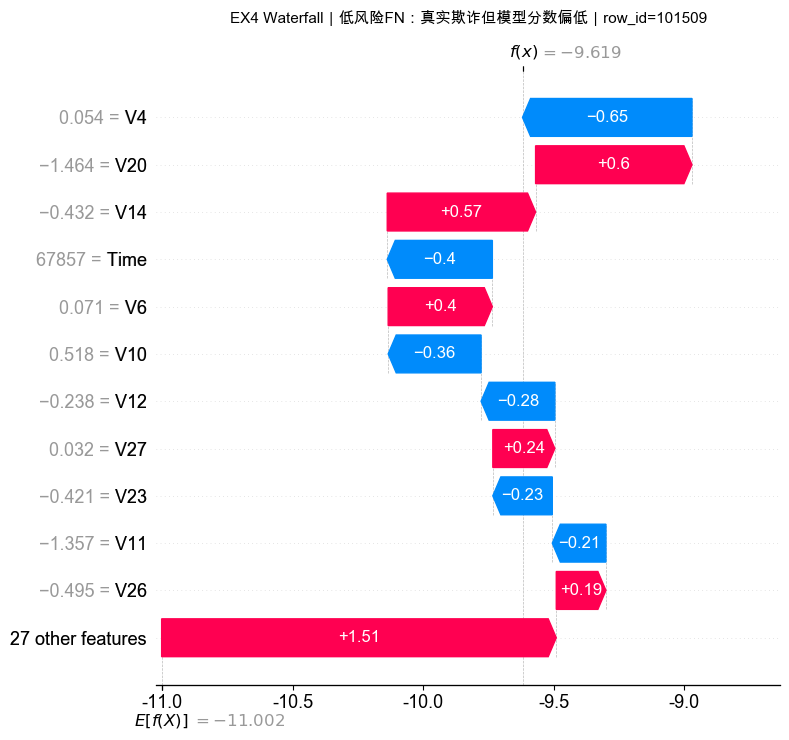

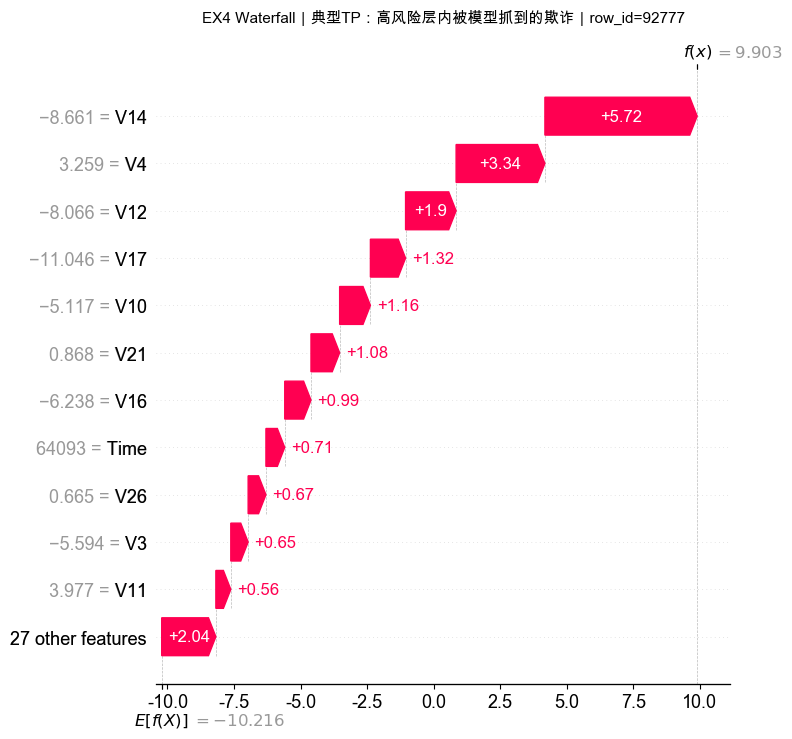

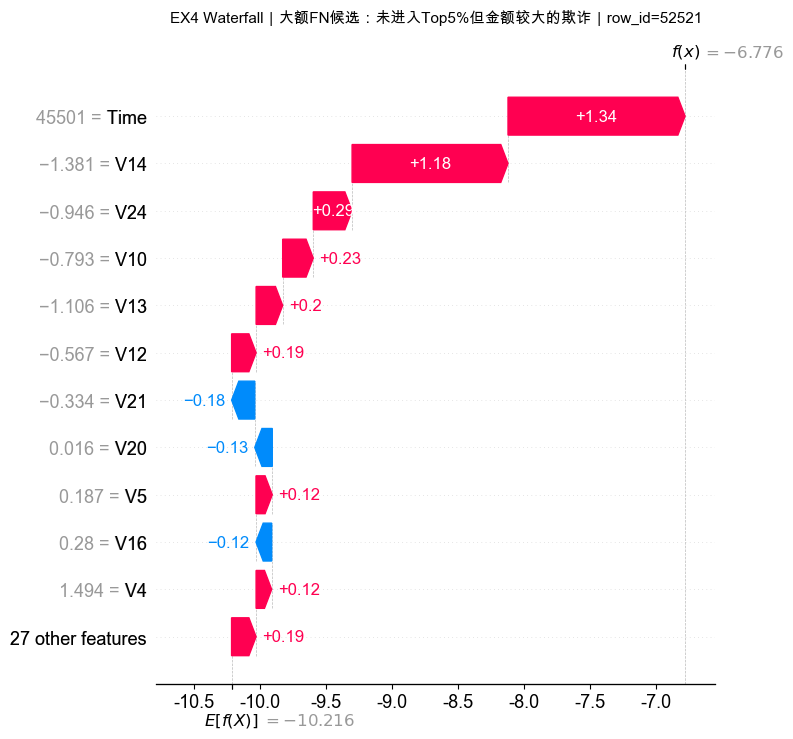

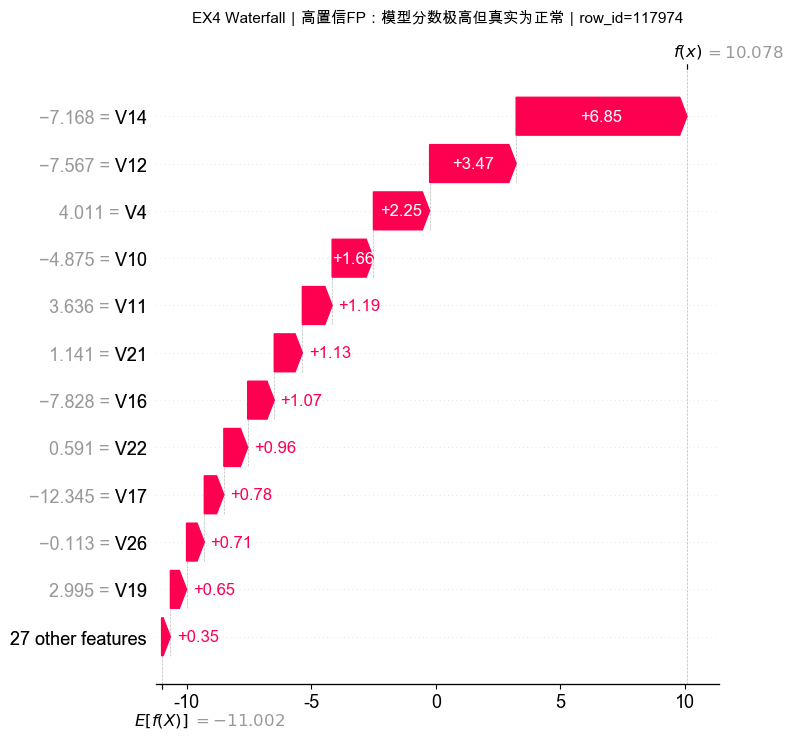

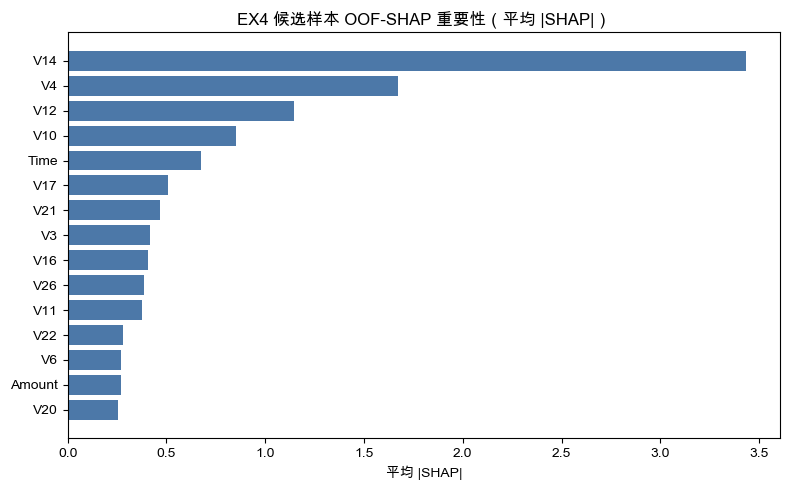


=== EX4 单样本 OOF-SHAP 解释摘要 ===


,样本类型,row_id,Amount,Class,风险分@EX3融合,LightGBM概率@EX3融合输入,欺诈概率@LightGBM折内OOF模型,Top正向特征,Top负向特征
0,低风险FN：真实欺诈但模型分数偏低,101509,320.00,1,0.481329,0.000027,0.000066,V20=-1.464(+0.599)；V14=-0.4317(+0.568)；V6=0.07...,V4=0.05374(-0.649)；Time=6.786e+04(-0.403)；V10=...
1,低风险FN：真实欺诈但模型分数偏低,112840,45.03,1,0.475424,0.000008,0.000014,V4=1.153(+0.898)；V21=0.8629(+0.479)；V22=0.9278...,V6=1.254(-0.633)；V12=0.1969(-0.548)；Time=7.282...
2,低风险FN：真实欺诈但模型分数偏低,91671,290.18,1,0.435085,0.000013,0.000222,Time=6.358e+04(+1.154)；V21=0.3403(+0.533)；V15=...,V10=-0.09135(-0.250)；V6=1.01(-0.249)；V20=0.861...
3,低风险FN：真实欺诈但模型分数偏低,100623,549.06,1,0.427944,0.000009,0.000023,V10=-1.769(+0.533)；V6=0.7394(+0.335)；V26=-0.54...,V14=0.2175(-0.533)；V12=-0.005423(-0.452)；V4=-1...
4,低风险FN：真实欺诈但模型分数偏低,79874,5.09,1,0.372909,0.000006,0.000224,Time=5.822e+04(+1.534)；V14=-1.635(+1.529)；V13=...,V26=-0.3351(-0.643)；V4=0.7904(-0.527)；V20=-0.0...
5,低风险FN：真实欺诈但模型分数偏低,72757,1.79,1,0.276700,0.000004,0.000363,Time=5.485e+04(+1.665)；V14=-0.9316(+0.678)；V20...,V4=0.3383(-0.324)；V24=0.3551(-0.244)；V10=1.01(...
6,低风险FN：真实欺诈但模型分数偏低,95534,31.91,1,0.252858,0.000002,0.000004,V14=-0.8193(+0.539)；V6=0.8322(+0.215)；V10=-0.3...,V4=-0.01459(-0.520)；Time=6.536e+04(-0.459)；V20...
7,低风险FN：真实欺诈但模型分数偏低,96341,98.01,1,0.174180,0.000001,0.000002,V14=-1.113(+0.793)；if_oof_score=0.3312(+0.388)...,V4=-0.5894(-0.652)；V26=-0.2837(-0.598)；V10=0.2...
8,典型TP：高风险层内被模型抓到的欺诈,92777,294.90,1,0.999993,1.000000,0.999950,V14=-8.661(+5.721)；V4=3.259(+3.336)；V12=-8.066...,—
9,典型TP：高风险层内被模型抓到的欺诈,79525,1.00,1,0.999975,0.999999,0.999942,V14=-11.09(+6.056)；V4=5.527(+4.030)；V10=-6.778...,—



=== EX4 各样本类型平均 |SHAP| Top 特征 ===


,样本类型,特征,平均|SHAP|@LightGBM折内OOF模型,平均SHAP值@LightGBM折内OOF模型
1,低风险FN：真实欺诈但模型分数偏低,Time,0.814964,0.273367
7,低风险FN：真实欺诈但模型分数偏低,V14,0.613592,0.480301
24,低风险FN：真实欺诈但模型分数偏低,V4,0.527831,-0.246832
14,低风险FN：真实欺诈但模型分数偏低,V20,0.340562,0.041145
3,低风险FN：真实欺诈但模型分数偏低,V10,0.331556,-0.100397
26,低风险FN：真实欺诈但模型分数偏低,V6,0.313276,0.092802
20,低风险FN：真实欺诈但模型分数偏低,V26,0.285248,-0.024955
0,低风险FN：真实欺诈但模型分数偏低,Amount,0.271211,-0.067312
45,典型TP：高风险层内被模型抓到的欺诈,V14,6.711790,6.711790
62,典型TP：高风险层内被模型抓到的欺诈,V4,3.267094,3.267094



=== EX4 Waterfall 图索引 ===


,样本类型,row_id,waterfall_path
0,低风险FN：真实欺诈但模型分数偏低,101509,/Users/jingyuhe/Desktop/credit-fraud-dealing-w...
1,典型TP：高风险层内被模型抓到的欺诈,92777,/Users/jingyuhe/Desktop/credit-fraud-dealing-w...
2,大额FN候选：未进入Top5%但金额较大的欺诈,52521,/Users/jingyuhe/Desktop/credit-fraud-dealing-w...
3,高置信FP：模型分数极高但真实为正常,117974,/Users/jingyuhe/Desktop/credit-fraud-dealing-w...



已保存 EX4 输出 → /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/EX4_shap_single_sample


In [34]:
# EX4 exec：训练折内解释模型并生成单样本 SHAP 输出
OUT_EX4 = _ex4_setup_output_dir()
OUT_EX3_FOR_EX4 = Path(OUTPUT_DIR) / 'EX3_risk_stratification'
candidate_path_ex4 = OUT_EX3_FOR_EX4 / 'ex3_shap_sample_candidates.csv'
if not candidate_path_ex4.exists():
    raise FileNotFoundError(f'未找到 EX3 候选样本表：{candidate_path_ex4}。请先运行 EX3。')

df_fe_ex4 = pd.read_pickle(Path(OUTPUT_DIR) / 'df_features.pkl')
candidates_ex4 = pd.read_csv(candidate_path_ex4).drop_duplicates(subset=['样本类型', 'row_id']).copy()
candidates_ex4['_ex4_pos'] = np.arange(len(candidates_ex4))
feature_cols_ex4, feature_group_ex4, tune_ex4 = ex4_resolve_tune_features(OUTPUT_DIR)
X_explain_ex4 = df_fe_ex4.iloc[candidates_ex4['row_id'].astype(int)][feature_cols_ex4].reset_index(drop=True)

print(f'EX4 解释特征组: {feature_group_ex4}（{len(feature_cols_ex4)} 列）')
print(f'EX4 候选样本数: {len(candidates_ex4)}')
print('EX4 解释口径: OOF fold-specific LightGBM TreeSHAP（每个样本由未见过它的折内模型解释）')

shap_values_ex4, base_values_ex4, proba_ex4, fold_meta_ex4 = ex4_compute_oof_local_shap(
    df_fe_ex4, candidates_ex4, feature_cols_ex4, tune_ex4, n_splits=5, random_state=42
)
sample_summary_ex4, local_top_features_ex4, group_feature_summary_ex4 = ex4_build_shap_tables(
    candidates_ex4, X_explain_ex4, shap_values_ex4, base_values_ex4, proba_ex4, feature_cols_ex4, top_k=10
)
waterfall_index_ex4 = ex4_plot_waterfalls(
    candidates_ex4, X_explain_ex4, shap_values_ex4, base_values_ex4, feature_cols_ex4,
    OUT_EX4 / 'waterfall', per_type=EX4_WATERFALL_PER_TYPE,
)
ex4_plot_global_bar(group_feature_summary_ex4, OUT_EX4 / 'ex4_shap_global_candidates.png')

sample_summary_export_ex4 = ex4_export_labels(sample_summary_ex4)
local_top_features_export_ex4 = ex4_export_labels(local_top_features_ex4)
group_feature_summary_export_ex4 = ex4_export_labels(group_feature_summary_ex4)
sample_summary_export_ex4.to_csv(OUT_EX4 / 'ex4_shap_sample_summary.csv', index=False, encoding='utf-8-sig')
local_top_features_export_ex4.to_csv(OUT_EX4 / 'ex4_shap_local_top_features.csv', index=False, encoding='utf-8-sig')
group_feature_summary_export_ex4.to_csv(OUT_EX4 / 'ex4_shap_group_feature_summary.csv', index=False, encoding='utf-8-sig')
waterfall_index_ex4.to_csv(OUT_EX4 / 'ex4_waterfall_index.csv', index=False, encoding='utf-8-sig')
fold_meta_ex4.to_csv(OUT_EX4 / 'ex4_fold_meta.csv', index=False, encoding='utf-8-sig')
(OUT_EX4 / 'ex4_model_meta.json').write_text(json.dumps({
    'model': 'LightGBM',
    'explanation_protocol': 'OOF fold-specific TreeSHAP',
    'feature_group': feature_group_ex4,
    'feature_cols': feature_cols_ex4,
    'n_candidates': int(len(candidates_ex4)),
    'n_features': int(len(feature_cols_ex4)),
    'note': 'Each candidate is explained by the fold model whose validation split contains that candidate; positive SHAP pushes toward fraud.',
}, ensure_ascii=False, indent=2), encoding='utf-8')

print('\n=== EX4 单样本 OOF-SHAP 解释摘要 ===')
_ex4_display(sample_summary_export_ex4[['样本类型', 'row_id', 'Amount', 'Class', '风险分@EX3融合', 'LightGBM概率@EX3融合输入', '欺诈概率@LightGBM折内OOF模型', 'Top正向特征', 'Top负向特征']].round(6), n=20)

print('\n=== EX4 各样本类型平均 |SHAP| Top 特征 ===')
top_group_show_ex4 = group_feature_summary_ex4.groupby('样本类型', group_keys=False).head(8)
_ex4_display(ex4_export_labels(top_group_show_ex4).round(6), n=40)

print('\n=== EX4 Waterfall 图索引 ===')
_ex4_display(waterfall_index_ex4, n=20)

print('\n已保存 EX4 输出 →', OUT_EX4)


#### 实验证明虽然 V4、V10、V12 经常导致漏报，但去掉 V4、V10、V12 得不偿失

参考：[`drop_ex4_fn_features.ipynb`](shap/drop_ex4_fn_features.ipynb)。  

## EX5. 基于金额结构诊断的分段 F1 阈值实验

**不同金额的交易，是否应该使用不同的欺诈判定阈值？**

EX5 **不重新训练模型**，只复用 EX3 保存的 OOF `risk_score`。本节检验的是金额分段后的阈值策略，不是模型结构或特征工程。

### 1. 第一阶段：先分析金额区间中的欺诈结构

第一阶段同时输出：

- **固定业务金额箱**：逐箱统计交易数、欺诈数、欺诈率、Lift、欺诈金额及金额贡献；
- **金额累计 KS**：沿 Amount 从低到高计算欺诈与正常的累计占比差，并在每个固定业务金额箱内提取一个 KS 代表点；
- **欺诈金额分位点**：只在 cal 欺诈样本内部计算，用作候选边界证据，不直接按分位数形成策略；
- **业务金额锚点**：覆盖微额试卡、小额交易、中额交易及大额/套现观察区间。

### 2. 第二阶段：提出三段策略并实验

候选统一采用便于业务解释的三段形式：

`Amount ≤ y` / `y < Amount ≤ x` / `Amount > x`

其中 `y`、`x` 不固定为某一个数，而是来自第一阶段的业务锚点、欺诈金额分位点和 KS 分箱代表点。程序枚举所有边界组合，并记录：

- 三段各自的 cal 交易数、欺诈数和 Lift；
- 是否出现“小额端高 Lift—中间低 Lift—高额端重新回升”的结构；
- 每个边界的数据来源与业务含义；
- 未进入实验的具体原因。

只有三段都满足以下最低要求，才允许各段独立搜索 F1 阈值：

- cal 每段总交易数不少于 100；
- cal 每段欺诈数不少于 20；
- cal 每段同时存在正常交易。

当前 cal 欺诈总量有限，20 笔是兼顾三段可行性与阈值稳定性的**最低门槛**，不是充分样本保证。低于该值时，3～5 个样本就可能决定阈值，结果没有业务稳定性。类似 `>500` 的“大额/套现”设想如果欺诈数不足，仍会保留在拒绝候选表中并说明原因，但不会强行调一个独立阈值。

### 3. 指标口径

`GLOBAL_BASE` 在 cal 上搜索一个全局 F1 阈值；每个入选三段策略在各自金额段的 cal 样本上搜索 `segment_t*`。这里采用的是 **segment-local F1 启发式**：三个局部 F1 最优阈值不等于三阈值联合优化得到的整体最优值。程序随后在 cal 上计算整套 policy F1 并预选唯一策略，再固定到 eval 验收；eval 不参与重新选择策略。

策略总表重点看：

- `F1@policy_t*`、`Precision@policy_t*`、`Recall@policy_t*`：eval 分类效果；
- `FP@policy_t*`、`FN@policy_t*`、`告警交易数@policy_t*`：审核成本与漏报；
- `AmountRecall@policy_t*`、`MissedAmount@policy_t*`：追回欺诈金额比例与漏损金额；
- `MicroRecall@policy_t*`：`Amount ≤ 30` 的小额欺诈召回；
- 各项 `Δ..._vs_GLOBAL_BASE_t*`：相对全局单阈值的变化。

`ex5_segment_detail.csv` 每行对应一个策略的一个金额段，给出阈值来源、cal 样本支撑和 eval 段表现。

### 4. EX5 结论

若某策略提高 F1 与欺诈金额召回，同时没有明显牺牲小额欺诈召回，金额分段阈值才具有业务价值。
- 现在提升 F1，却降低 Recall 或 AmountRecall，只能说明策略更保守。
- 所有候选都没有稳定超过 `GLOBAL_BASE`，说明当前风险分已经吸收主要区分信息，单独按金额后处理阈值没有继续抬高上限。


In [35]:
# EX5 prep：金额结构诊断、候选分段与阈值实验配置
EX5_MICRO_AMOUNT_MAX = 30.0
EX5_MIN_SEGMENT_SAMPLES = 100
EX5_MIN_SEGMENT_FRAUD = 20
EX5_KS_TOP_CUTS = 12
EX5_FIXED_AMOUNT_EDGES = [
    -np.inf, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 75.0,
    100.0, 150.0, 200.0, 300.0, 500.0, 750.0, 1000.0, 2000.0, np.inf,
]
EX5_BUSINESS_BOUNDARIES = [
    0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0, 75.0,
    100.0, 150.0, 200.0, 300.0, 500.0, 750.0, 1000.0, 2000.0,
]
EX5_FRAUD_AMOUNT_QUANTILES = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]


EX5_POLICY_METRIC_RENAME = {
    '告警交易数': '告警交易数@policy_t*', '告警率': '告警率@policy_t*',
    'TP': 'TP@policy_t*', 'FP': 'FP@policy_t*', 'FN': 'FN@policy_t*', 'TN': 'TN@policy_t*',
    'Precision': 'Precision@policy_t*', 'Recall': 'Recall@policy_t*', 'F1': 'F1@policy_t*',
    'FPR': 'FPR@policy_t*', 'CaughtAmount': 'CaughtAmount@policy_t*',
    'MissedAmount': 'MissedAmount@policy_t*', 'AmountRecall': 'AmountRecall@policy_t*',
    'MicroFN': 'MicroFN@policy_t*', 'MicroRecall': 'MicroRecall@policy_t*',
    'global_cal_threshold': 'GLOBAL_BASE_t*', 'global_cal_F1': 'F1@GLOBAL_BASE_t*（cal）',
    'cal_policy_F1': 'F1@policy_t*（cal内预选）',
    'cal_policy_Recall': 'Recall@policy_t*（cal内预选）',
    'cal_policy_AmountRecall': 'AmountRecall@policy_t*（cal内预选）',
    'ΔF1_vs_base': 'ΔF1@policy_t*_vs_GLOBAL_BASE_t*',
    'ΔRecall_vs_base': 'ΔRecall@policy_t*_vs_GLOBAL_BASE_t*',
    'ΔAmountRecall_vs_base': 'ΔAmountRecall@policy_t*_vs_GLOBAL_BASE_t*',
    'ΔMissedAmount_vs_base': 'ΔMissedAmount@policy_t*_vs_GLOBAL_BASE_t*',
    '阈值': '阈值@segment_t*', 'cal_F1': 'F1@segment_t*（cal）',
    'eval_告警数': 'eval_告警数@policy_t*', 'eval_TP': 'eval_TP@policy_t*',
    'eval_FP': 'eval_FP@policy_t*', 'eval_FN': 'eval_FN@policy_t*',
    'eval_Precision': 'eval_Precision@policy_t*', 'eval_Recall': 'eval_Recall@policy_t*',
    'eval_F1': 'eval_F1@policy_t*', 'eval_AmountRecall': 'eval_AmountRecall@policy_t*',
    'eval_MissedAmount': 'eval_MissedAmount@policy_t*', '使用阈值': '使用阈值@policy_t*',
}


def ex5_export_labels(df):
    return df.rename(columns=EX5_POLICY_METRIC_RENAME).copy()


def _ex5_display(df, n=20):
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n).to_string(index=False))


def _ex5_setup_output_dir():
    global OUTPUT_DIR
    try:
        base = Path(OUTPUT_DIR)
    except NameError:
        base = Path('/Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report')
        OUTPUT_DIR = base
    out = base / 'EX5_amount_segment_threshold'
    out.mkdir(parents=True, exist_ok=True)
    return out


def ex5_load_scores(output_dir):
    path = Path(output_dir) / 'EX3_risk_stratification' / 'ex3_oof_scores.csv'
    if not path.exists():
        raise FileNotFoundError(f'未找到 EX3 OOF 风险分数：{path}。请先运行 EX3。')
    df = pd.read_csv(path)
    required = {'Class', 'Amount', 'Time', 'row_id', 'risk_score'}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f'EX3 OOF 分数表缺少列：{sorted(missing)}')
    df = df.loc[df['risk_score'].notna()].copy()
    df = df.sort_values(['Time', 'row_id'], kind='mergesort').reset_index(drop=True)
    df['Class'] = df['Class'].astype(int)
    df['Amount'] = df['Amount'].astype(float)
    df['risk_score'] = df['risk_score'].astype(float)
    return df


def ex5_split_cal_eval(df, cal_frac=OOF_CAL_FRAC, min_fraud_cal=OOF_CAL_MIN_FRAUD):
    y = df['Class'].to_numpy(dtype=int)
    cal_mask, n_cal = _oof_cal_mask(y, cal_frac=cal_frac, min_fraud_cal=min_fraud_cal)
    cal = df.loc[cal_mask].copy()
    ev = df.loc[~cal_mask].copy()
    return cal, ev, int(n_cal)


def ex5_best_f1_threshold(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score, dtype=float)
    mask = np.isfinite(score)
    y_eval = y_true[mask]
    s_eval = score[mask]
    if len(y_eval) == 0 or len(np.unique(y_eval)) < 2:
        return DEFAULT_CLASSIFICATION_THRESHOLD, 0.0
    prec, rec, thr = precision_recall_curve(y_eval, s_eval)
    if len(thr) == 0:
        return DEFAULT_CLASSIFICATION_THRESHOLD, 0.0
    f1 = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
    i = int(np.nanargmax(f1))
    return float(thr[i]), float(f1[i])


def ex5_segment_range_text(left, right):
    if np.isneginf(left) and np.isposinf(right):
        return '全部金额'
    if np.isneginf(left):
        return f'Amount ≤ {right:.2f}'
    if np.isposinf(right):
        return f'Amount > {left:.2f}'
    return f'{left:.2f} < Amount ≤ {right:.2f}'


def ex5_assign_segments(df, edges):
    labels = [f'S{i+1:02d}' for i in range(len(edges) - 1)]
    return pd.cut(df['Amount'], bins=edges, labels=labels, include_lowest=True, right=True).astype(str)


def ex5_amount_bin_profile(cal_df, edges=EX5_FIXED_AMOUNT_EDGES):
    baseline = float(cal_df['Class'].mean())
    fraud_amount_total = float(cal_df.loc[cal_df['Class'] == 1, 'Amount'].sum())
    fraud_total = int(cal_df['Class'].sum())
    rows = []
    for i in range(len(edges) - 1):
        left, right = edges[i], edges[i + 1]
        if np.isneginf(left):
            mask = cal_df['Amount'] <= right
        elif np.isposinf(right):
            mask = cal_df['Amount'] > left
        else:
            mask = (cal_df['Amount'] > left) & (cal_df['Amount'] <= right)
        part = cal_df.loc[mask]
        n = int(len(part))
        fraud_n = int(part['Class'].sum())
        fraud_rate = float(fraud_n / n) if n else np.nan
        fraud_amount = float(part.loc[part['Class'] == 1, 'Amount'].sum())
        rows.append({
            '金额区间': ex5_segment_range_text(left, right),
            '金额下界': left,
            '金额上界': right,
            'cal_交易数': n,
            'cal_欺诈数': fraud_n,
            'cal_正常数': n - fraud_n,
            '欺诈率': fraud_rate,
            'Lift': float(fraud_rate / baseline) if n and baseline > 0 else np.nan,
            'cal_欺诈金额': fraud_amount,
            '欺诈数占比': float(fraud_n / fraud_total) if fraud_total else np.nan,
            '欺诈金额占比': float(fraud_amount / fraud_amount_total) if fraud_amount_total > 0 else np.nan,
        })
    out = pd.DataFrame(rows)
    out['相邻Lift变化'] = out['Lift'].diff()
    return out


def ex5_amount_ks_curve(cal_df):
    grouped = (
        cal_df.groupby('Amount', as_index=False, sort=True)['Class']
        .agg(cal_交易数='count', cal_欺诈数='sum')
    )
    grouped['cal_正常数'] = grouped['cal_交易数'] - grouped['cal_欺诈数']
    fraud_total = int(grouped['cal_欺诈数'].sum())
    normal_total = int(grouped['cal_正常数'].sum())
    grouped['左侧累计交易数'] = grouped['cal_交易数'].cumsum()
    grouped['左侧累计欺诈数'] = grouped['cal_欺诈数'].cumsum()
    grouped['左侧累计正常数'] = grouped['cal_正常数'].cumsum()
    grouped['右侧欺诈数'] = fraud_total - grouped['左侧累计欺诈数']
    grouped['右侧正常数'] = normal_total - grouped['左侧累计正常数']
    grouped['欺诈累计占比'] = grouped['左侧累计欺诈数'] / max(fraud_total, 1)
    grouped['正常累计占比'] = grouped['左侧累计正常数'] / max(normal_total, 1)
    grouped['KS方向差'] = grouped['欺诈累计占比'] - grouped['正常累计占比']
    grouped['KS'] = grouped['KS方向差'].abs()
    grouped['可作候选边界'] = (
        (grouped['左侧累计交易数'] >= EX5_MIN_SEGMENT_SAMPLES)
        & ((len(cal_df) - grouped['左侧累计交易数']) >= EX5_MIN_SEGMENT_SAMPLES)
        & (grouped['左侧累计欺诈数'] >= EX5_MIN_SEGMENT_FRAUD)
        & (grouped['右侧欺诈数'] >= EX5_MIN_SEGMENT_FRAUD)
    )
    return grouped


def ex5_ks_landmarks(ks_curve, fixed_edges=EX5_FIXED_AMOUNT_EDGES, top_n=EX5_KS_TOP_CUTS):
    usable = ks_curve.loc[ks_curve['可作候选边界']].copy()
    if usable.empty:
        usable['KS排名'] = pd.Series(dtype=int)
        return usable
    usable['_金额观察区间'] = pd.cut(
        usable['Amount'], bins=fixed_edges, include_lowest=True, right=True
    )
    idx = usable.groupby('_金额观察区间', observed=True)['KS'].idxmax()
    landmarks = usable.loc[idx].sort_values('KS', ascending=False).head(top_n).copy()
    landmarks['KS排名'] = np.arange(1, len(landmarks) + 1)
    return landmarks.drop(columns=['_金额观察区间'])


def ex5_business_meaning(value):
    value = float(value)
    if value <= 1:
        return '微额验证/试卡锚点'
    if value <= 5:
        return '小额试卡敏感区上界'
    if value <= 30:
        return '小额交易观察上界'
    if value <= 100:
        return '普通交易与中额交易边界'
    if value <= 500:
        return '中高额交易边界'
    return '大额交易/套现观察边界'


def ex5_boundary_pool(cal_df, ks_landmarks):
    amount_min = float(cal_df['Amount'].min())
    amount_max = float(cal_df['Amount'].max())
    sources = {}

    def add(values, source):
        for value in values:
            if pd.isna(value):
                continue
            value = round(float(value), 2)
            if amount_min < value < amount_max:
                sources.setdefault(value, set()).add(source)

    add(EX5_BUSINESS_BOUNDARIES, '业务金额锚点')
    fraud_amount = cal_df.loc[cal_df['Class'] == 1, 'Amount']
    for q in EX5_FRAUD_AMOUNT_QUANTILES:
        add([fraud_amount.quantile(q)], f'欺诈金额P{int(q * 100)}')
    add(ks_landmarks['Amount'].tolist(), '金额KS分箱代表点')

    rows = []
    for value in sorted(sources):
        rows.append({
            '候选边界': value,
            '边界来源': '；'.join(sorted(sources[value])),
            '业务含义': ex5_business_meaning(value),
        })
    return pd.DataFrame(rows)


def ex5_three_segment_cal_stats(cal_df, y, x):
    baseline = float(cal_df['Class'].mean())
    masks = [
        cal_df['Amount'] <= y,
        (cal_df['Amount'] > y) & (cal_df['Amount'] <= x),
        cal_df['Amount'] > x,
    ]
    rows = []
    for mask in masks:
        part = cal_df.loc[mask]
        n = int(len(part))
        fraud_n = int(part['Class'].sum())
        fraud_rate = float(fraud_n / n) if n else np.nan
        rows.append({
            'n': n,
            'fraud': fraud_n,
            'normal': n - fraud_n,
            'rate': fraud_rate,
            'lift': float(fraud_rate / baseline) if n and baseline > 0 else np.nan,
        })
    return rows


def ex5_boundary_name(value):
    text = f'{float(value):.2f}'.rstrip('0').rstrip('.')
    return text.replace('.', 'p')


def ex5_candidate_segments_from_cal(cal_df, boundary_pool):
    source_map = boundary_pool.set_index('候选边界').to_dict(orient='index')
    values = boundary_pool['候选边界'].sort_values().to_list()
    accepted_rows, rejected_rows = [], []
    for y, x in combinations(values, 2):
        stats_rows = ex5_three_segment_cal_stats(cal_df, y, x)
        sample_counts = [s['n'] for s in stats_rows]
        fraud_counts = [s['fraud'] for s in stats_rows]
        normal_counts = [s['normal'] for s in stats_rows]
        lifts = [s['lift'] for s in stats_rows]
        reasons = []
        for i, (sample_n, fraud_n, normal_n) in enumerate(
            zip(sample_counts, fraud_counts, normal_counts), start=1
        ):
            if sample_n < EX5_MIN_SEGMENT_SAMPLES:
                reasons.append(f'S{i:02d}交易数<{EX5_MIN_SEGMENT_SAMPLES}')
            if fraud_n < EX5_MIN_SEGMENT_FRAUD:
                reasons.append(f'S{i:02d}欺诈数<{EX5_MIN_SEGMENT_FRAUD}')
            if normal_n == 0:
                reasons.append(f'S{i:02d}无正常交易')
        valley_strength = float((lifts[0] + lifts[2]) / 2 - lifts[1])
        small_uplift = float(lifts[0] - lifts[1])
        high_rebound = float(lifts[2] - lifts[1])
        if lifts[1] < min(lifts[0], lifts[2]):
            structure = '两头高、中间低（Lift谷底）'
            structure_order = 0
        elif lifts[2] > lifts[1]:
            structure = '高额端Lift回升'
            structure_order = 1
        elif lifts[0] > lifts[1]:
            structure = '小额端Lift抬升'
            structure_order = 2
        else:
            structure = '样本量可行，Lift无谷底'
            structure_order = 3
        y_meta, x_meta = source_map[y], source_map[x]
        row = {
            '策略': f'Y{ex5_boundary_name(y)}_X{ex5_boundary_name(x)}',
            'y': float(y),
            'x': float(x),
            '分段口径': f'≤{y:.2f} / ({y:.2f}, {x:.2f}] / >{x:.2f}',
            '结构类型': structure,
            '_结构排序': structure_order,
            'y来源': y_meta['边界来源'],
            'x来源': x_meta['边界来源'],
            'y业务含义': y_meta['业务含义'],
            'x业务含义': x_meta['业务含义'],
            'S01_cal交易数': sample_counts[0],
            'S02_cal交易数': sample_counts[1],
            'S03_cal交易数': sample_counts[2],
            'S01_cal欺诈数': fraud_counts[0],
            'S02_cal欺诈数': fraud_counts[1],
            'S03_cal欺诈数': fraud_counts[2],
            'S01_Lift': lifts[0],
            'S02_Lift': lifts[1],
            'S03_Lift': lifts[2],
            '小额抬升': small_uplift,
            '高额回升': high_rebound,
            '谷底强度': valley_strength,
            '三段cal欺诈数': ' / '.join(str(v) for v in fraud_counts),
            '三段Lift': ' / '.join(f'{v:.2f}' for v in lifts),
            '进入实验': '是' if not reasons else '否',
            '拒绝原因': '；'.join(reasons),
        }
        row['候选依据'] = (
            f"{structure}；y={y:.2f}（{y_meta['边界来源']}，{y_meta['业务含义']}）；"
            f"x={x:.2f}（{x_meta['边界来源']}，{x_meta['业务含义']}）；"
            f"三段cal欺诈数={row['三段cal欺诈数']}，Lift={row['三段Lift']}"
        )
        (accepted_rows if not reasons else rejected_rows).append(row)

    sort_cols = ['_结构排序', '谷底强度', '高额回升', '小额抬升']
    accepted = pd.DataFrame(accepted_rows)
    rejected = pd.DataFrame(rejected_rows)
    if not accepted.empty:
        accepted = accepted.sort_values(sort_cols, ascending=[True, False, False, False]).reset_index(drop=True)
        accepted.insert(0, 'cal候选序号', np.arange(1, len(accepted) + 1))
    else:
        accepted = pd.DataFrame(columns=[
            'cal候选序号', '策略', 'y', 'x', '分段口径', '结构类型',
            '三段cal欺诈数', '三段Lift', '谷底强度', 'y来源', 'x来源', '候选依据',
        ])
    if not rejected.empty:
        rejected = rejected.sort_values(
            ['S02_cal欺诈数', 'S03_cal欺诈数', '谷底强度'], ascending=[False, False, False]
        ).reset_index(drop=True)
    return accepted.drop(columns=['_结构排序'], errors='ignore'), rejected.drop(columns=['_结构排序'], errors='ignore')


def ex5_candidate_specs(candidate_df):
    specs = [('GLOBAL_BASE', [-np.inf, np.inf], '不分金额段；cal 全局 F1 阈值')]
    for _, row in candidate_df.iterrows():
        specs.append((
            str(row['策略']),
            [-np.inf, float(row['y']), float(row['x']), np.inf],
            str(row['候选依据']),
        ))
    return specs


def ex5_fit_segment_thresholds(cal_df, strategy_name, edges, global_threshold):
    cal = cal_df.copy()
    cal['_segment'] = ex5_assign_segments(cal, edges)
    thresholds, rows = {}, []
    for i in range(len(edges) - 1):
        seg = f'S{i+1:02d}'
        part = cal.loc[cal['_segment'] == seg]
        n = int(len(part))
        fraud_n = int(part['Class'].sum())
        normal_n = n - fraud_n
        enough = (
            n >= EX5_MIN_SEGMENT_SAMPLES
            and fraud_n >= EX5_MIN_SEGMENT_FRAUD
            and normal_n > 0
        )
        if enough:
            threshold, cal_f1 = ex5_best_f1_threshold(part['Class'], part['risk_score'])
            source = 'segment_f1'
        else:
            threshold, cal_f1 = global_threshold, np.nan
            source = 'global_fallback'
        thresholds[seg] = float(threshold)
        rows.append({
            '策略': strategy_name,
            '金额段': seg,
            '金额下界': edges[i],
            '金额上界': edges[i + 1],
            '金额范围': ex5_segment_range_text(edges[i], edges[i + 1]),
            '阈值': float(threshold),
            '阈值来源': source,
            'cal_样本数': n,
            'cal_欺诈数': fraud_n,
            'cal_正常数': normal_n,
            'cal_F1': cal_f1,
        })
    return thresholds, pd.DataFrame(rows)


def ex5_score_with_thresholds(df, edges, thresholds):
    out = df.copy()
    out['金额段'] = ex5_assign_segments(out, edges)
    out['使用阈值'] = out['金额段'].map(thresholds).astype(float)
    out['pred'] = out['risk_score'] >= out['使用阈值']
    return out


def ex5_policy_metrics(scored_df):
    y = scored_df['Class'].to_numpy(dtype=int)
    pred = scored_df['pred'].to_numpy(dtype=bool)
    m = _compute_confusion_metrics(y, pred)
    fraud_amount = float(scored_df.loc[scored_df['Class'] == 1, 'Amount'].sum())
    caught_amount = float(scored_df.loc[(scored_df['Class'] == 1) & scored_df['pred'], 'Amount'].sum())
    missed_amount = float(scored_df.loc[(scored_df['Class'] == 1) & (~scored_df['pred']), 'Amount'].sum())
    micro = scored_df['Amount'] <= EX5_MICRO_AMOUNT_MAX
    micro_fraud = scored_df.loc[micro & (scored_df['Class'] == 1)]
    micro_fn = int((~micro_fraud['pred']).sum()) if len(micro_fraud) else 0
    micro_recall = float(micro_fraud['pred'].mean()) if len(micro_fraud) else np.nan
    n_eval = int(len(scored_df))
    return {
        'n_eval': n_eval,
        '告警交易数': int(pred.sum()),
        '告警率': float(pred.mean()) if n_eval else 0.0,
        'TP': m['tp'],
        'FP': m['fp'],
        'FN': m['fn'],
        'TN': m['tn'],
        'Precision': m['precision'],
        'Recall': m['recall'],
        'F1': m['f1'],
        'FPR': float(m['fp'] / max(m['fp'] + m['tn'], 1)),
        'FraudAmount': fraud_amount,
        'CaughtAmount': caught_amount,
        'MissedAmount': missed_amount,
        'AmountRecall': float(caught_amount / fraud_amount) if fraud_amount > 0 else np.nan,
        'MicroFraud': int(len(micro_fraud)),
        'MicroFN': micro_fn,
        'MicroRecall': micro_recall,
    }


def ex5_evaluate_strategy(cal_df, eval_df, strategy_name, edges, note, global_threshold, n_cal):
    thresholds, detail = ex5_fit_segment_thresholds(cal_df, strategy_name, edges, global_threshold)
    cal_scored = ex5_score_with_thresholds(cal_df, edges, thresholds)
    scored = ex5_score_with_thresholds(eval_df, edges, thresholds)
    cal_metrics = ex5_policy_metrics(cal_scored)
    metrics = ex5_policy_metrics(scored)
    metrics.update({
        '策略': strategy_name,
        '策略说明': note,
        '分段数': int(len(edges) - 1),
        'n_cal': int(n_cal),
        '金额切点': ' | '.join(
            '−∞' if np.isneginf(v) else '∞' if np.isposinf(v) else f'{v:.2f}' for v in edges
        ),
        'cal_policy_F1': cal_metrics['F1'],
        'cal_policy_Recall': cal_metrics['Recall'],
        'cal_policy_AmountRecall': cal_metrics['AmountRecall'],
    })
    seg_eval_rows = []
    for seg, part in scored.groupby('金额段', sort=True):
        sm = ex5_policy_metrics(part)
        seg_eval_rows.append({
            '策略': strategy_name,
            '金额段': seg,
            'eval_样本数': int(len(part)),
            'eval_欺诈数': int(part['Class'].sum()),
            'eval_告警数': int(part['pred'].sum()),
            'eval_TP': sm['TP'],
            'eval_FP': sm['FP'],
            'eval_FN': sm['FN'],
            'eval_Precision': sm['Precision'],
            'eval_Recall': sm['Recall'],
            'eval_F1': sm['F1'],
            'eval_AmountRecall': sm['AmountRecall'],
            'eval_MissedAmount': sm['MissedAmount'],
        })
    detail = detail.merge(pd.DataFrame(seg_eval_rows), on=['策略', '金额段'], how='left')
    return metrics, detail, scored


def ex5_run_segment_threshold_experiment(scores_df):
    cal_df, eval_df, n_cal = ex5_split_cal_eval(scores_df)
    bin_profile = ex5_amount_bin_profile(cal_df)
    ks_curve = ex5_amount_ks_curve(cal_df)
    ks_landmarks = ex5_ks_landmarks(ks_curve)
    boundary_pool = ex5_boundary_pool(cal_df, ks_landmarks)
    candidates, rejections = ex5_candidate_segments_from_cal(cal_df, boundary_pool)

    global_threshold, global_cal_f1 = ex5_best_f1_threshold(cal_df['Class'], cal_df['risk_score'])
    rows, details, predictions = [], [], {}
    for strategy_name, edges, note in ex5_candidate_specs(candidates):
        metrics, detail, scored = ex5_evaluate_strategy(
            cal_df, eval_df, strategy_name, edges, note, global_threshold, n_cal
        )
        metrics['global_cal_threshold'] = global_threshold
        metrics['global_cal_F1'] = global_cal_f1
        rows.append(metrics)
        details.append(detail)
        predictions[strategy_name] = scored

    summary = pd.DataFrame(rows)
    base = summary.loc[summary['策略'] == 'GLOBAL_BASE'].iloc[0]
    summary['ΔF1_vs_base'] = summary['F1'] - float(base['F1'])
    summary['ΔRecall_vs_base'] = summary['Recall'] - float(base['Recall'])
    summary['ΔAmountRecall_vs_base'] = summary['AmountRecall'] - float(base['AmountRecall'])
    summary['ΔMissedAmount_vs_base'] = summary['MissedAmount'] - float(base['MissedAmount'])
    summary['是否优于Base'] = np.where(
        (summary['ΔF1_vs_base'] >= -1e-12) & (summary['ΔMissedAmount_vs_base'] <= 1e-12),
        '是', '否',
    )
    summary = summary.sort_values(
        ['cal_policy_F1', 'cal_policy_AmountRecall', 'cal_policy_Recall', '策略'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    summary.insert(0, 'cal预选排名', np.arange(1, len(summary) + 1))
    detail_df = pd.concat(details, ignore_index=True)
    selected_name = str(summary.iloc[0]['策略'])
    selected_pred = predictions[selected_name].copy()
    selected_pred['error_type'] = np.select(
        [
            (selected_pred['Class'] == 1) & selected_pred['pred'],
            (selected_pred['Class'] == 0) & selected_pred['pred'],
            (selected_pred['Class'] == 1) & (~selected_pred['pred']),
            (selected_pred['Class'] == 0) & (~selected_pred['pred']),
        ],
        ['TP', 'FP', 'FN', 'TN'],
        default='NA',
    )
    analysis = {
        'cal': cal_df,
        'eval': eval_df,
        'bin_profile': bin_profile,
        'ks_curve': ks_curve,
        'ks_landmarks': ks_landmarks,
        'boundary_pool': boundary_pool,
        'candidates': candidates,
        'rejections': rejections,
    }
    return summary, detail_df, selected_pred, analysis


def ex5_plot_amount_diagnostics(bin_profile, ks_curve, ks_landmarks, out_path):
    setup_chinese_font()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = np.arange(len(bin_profile))
    axes[0].bar(x, bin_profile['cal_欺诈数'], color='#4C78A8', alpha=0.85, label='cal 欺诈数')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(bin_profile['金额区间'], rotation=55, ha='right', fontsize=8)
    axes[0].set_ylabel('cal 欺诈数')
    axes[0].set_title('第一阶段：固定业务金额箱的欺诈数与 Lift（cal）')
    ax_lift = axes[0].twinx()
    ax_lift.plot(x, bin_profile['Lift'], color='#E45756', marker='o', linewidth=1.8, label='Lift')
    ax_lift.axhline(1.0, color='#777777', linestyle='--', linewidth=1)
    ax_lift.set_ylabel('Lift')

    axes[1].plot(ks_curve['Amount'], ks_curve['KS'], color='#59A14F', linewidth=1.4)
    if not ks_landmarks.empty:
        axes[1].scatter(ks_landmarks['Amount'], ks_landmarks['KS'], color='#E45756', s=28, zorder=3)
    axes[1].set_xscale('symlog', linthresh=1)
    axes[1].set_xlabel('Amount（symlog）')
    axes[1].set_ylabel('|欺诈累计占比 − 正常累计占比|')
    axes[1].set_title('第一阶段：金额累计 KS 与各业务金额箱代表点（cal）')
    axes[1].grid(alpha=0.2)

    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    return fig


def ex5_plot_strategy_compare(summary, out_path):
    setup_chinese_font()
    plot_df = summary.head(12).copy()
    x = np.arange(len(plot_df))
    width = 0.25
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.bar(x - width, plot_df['F1'], width, label='F1')
    ax.bar(x, plot_df['Recall'], width, label='Recall')
    ax.bar(x + width, plot_df['AmountRecall'], width, label='AmountRecall')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['策略'], rotation=35, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('指标值')
    ax.set_title('EX5 按 cal 预选顺序展示金额分段策略（柱为 eval 指标）')
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    return fig


def ex5_plot_best_thresholds(best_detail, out_path):
    setup_chinese_font()
    plot_df = best_detail.copy()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(plot_df['金额段'], plot_df['阈值'], color='#4C78A8')
    ax.set_xlabel('金额段')
    ax.set_ylabel('风险分数阈值')
    ax.set_title(f"EX5 cal 预选策略各金额段阈值：{plot_df['策略'].iloc[0]}")
    for i, text in enumerate(plot_df['金额范围']):
        ax.text(i, plot_df['阈值'].iloc[i], text, rotation=65, ha='center', va='bottom', fontsize=8)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    return fig


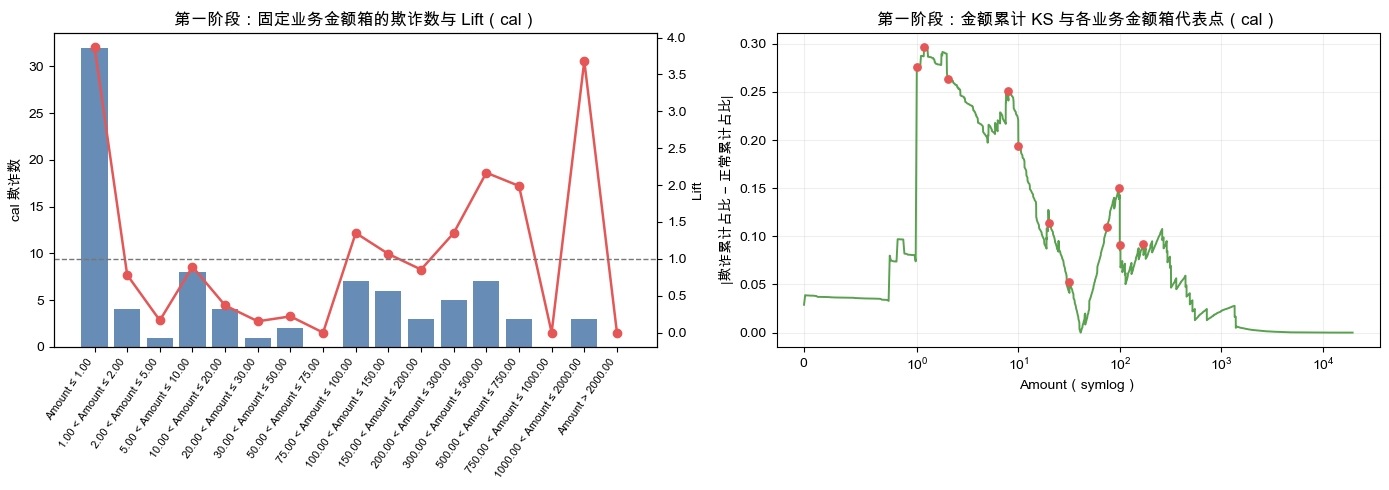

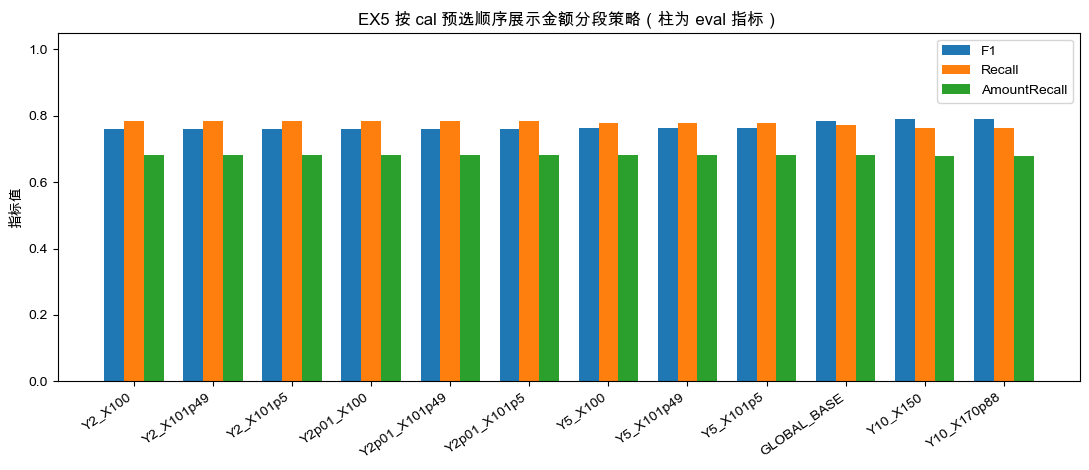

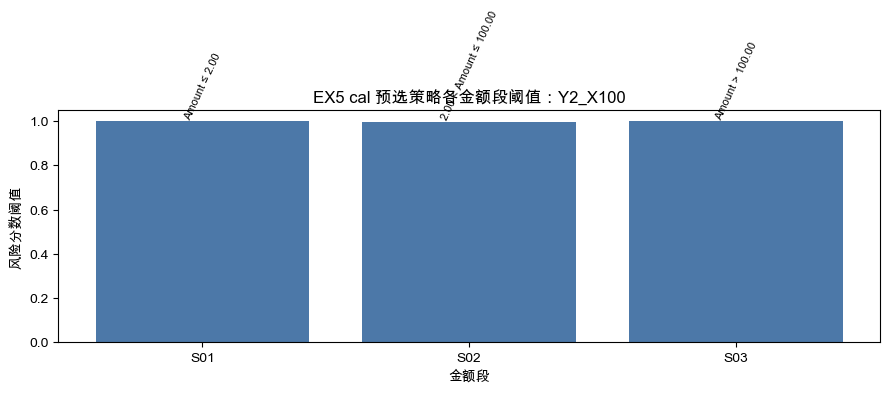

=== EX5 第一阶段：cal 金额区间欺诈结构 ===
cal 交易数=59,333，cal 欺诈数=86；独立调阈值最低要求：每段交易数≥100、欺诈数≥20。
20 笔是当前有限 cal 欺诈样本下兼顾三段可行性与阈值稳定性的最低门槛，不是充分样本保证；最终仍以 eval 表现验收。


,金额区间,cal_交易数,cal_欺诈数,欺诈率,Lift,cal_欺诈金额,欺诈数占比,欺诈金额占比
0,Amount ≤ 1.00,5699,32,0.005615,3.873907,26.47,0.372093,0.002190
1,1.00 < Amount ≤ 2.00,3529,4,0.001133,0.781999,5.82,0.046512,0.000481
2,2.00 < Amount ≤ 5.00,4170,1,0.000240,0.165448,5.00,0.011628,0.000414
3,5.00 < Amount ≤ 10.00,6176,8,0.001295,0.893677,54.52,0.093023,0.004510
4,10.00 < Amount ≤ 20.00,7495,4,0.000534,0.368202,77.34,0.046512,0.006398
5,20.00 < Amount ≤ 30.00,4501,1,0.000222,0.153281,24.90,0.011628,0.002060
6,30.00 < Amount ≤ 50.00,6268,2,0.000319,0.220140,77.55,0.023256,0.006415
7,50.00 < Amount ≤ 75.00,4568,0,0.000000,0.000000,0.00,0.000000,0.000000
8,75.00 < Amount ≤ 100.00,3576,7,0.001957,1.350512,685.96,0.081395,0.056745
9,100.00 < Amount ≤ 150.00,3883,6,0.001545,1.066060,665.80,0.069767,0.055078



=== EX5 第一阶段：各固定业务金额箱内的 KS 代表点（cal）===


,KS排名,Amount,KS,左侧累计欺诈数,右侧欺诈数,欺诈累计占比,正常累计占比
93,1,1.18,0.296897,34,52,0.395349,0.098452
78,2,1.00,0.276443,32,54,0.372093,0.095650
165,3,2.01,0.263441,36,50,0.418605,0.155164
733,4,8.00,0.251310,45,41,0.523256,0.271946
920,5,10.01,0.193602,45,41,0.523256,0.329654
6732,6,98.00,0.150224,53,33,0.616279,0.766503
1824,7,20.01,0.113660,49,37,0.569767,0.456107
5597,8,75.00,0.110220,52,34,0.604651,0.714872
9151,9,170.88,0.092180,66,20,0.767442,0.859622
6890,10,101.49,0.090854,59,27,0.686047,0.776900



=== EX5 第二阶段：由 cal 证据生成并进入实验的三段候选 ===
边界池=33 个，枚举组合=528 个，满足最低样本约束并进入实验=42 个；其余拒绝原因已保存 CSV。


...


=== EX5 金额分段阈值策略对比（按 cal policy F1 预选排序；其余为 eval 验收指标）===


,cal预选排名,策略,F1@policy_t*（cal内预选）,告警交易数@policy_t*,FP@policy_t*,FN@policy_t*,Recall@policy_t*,F1@policy_t*,AmountRecall@policy_t*,MissedAmount@policy_t*,MicroRecall@policy_t*,ΔF1@policy_t*_vs_GLOBAL_BASE_t*,ΔMissedAmount@policy_t*_vs_GLOBAL_BASE_t*,是否优于Base
0,1,Y2_X100,0.851613,277,73,56,0.784615,0.759777,0.681757,10606.15,0.770833,-0.025380,-56.39,否
1,2,Y2_X101p49,0.851613,277,73,56,0.784615,0.759777,0.681757,10606.15,0.770833,-0.025380,-56.39,否
2,3,Y2_X101p5,0.851613,277,73,56,0.784615,0.759777,0.681757,10606.15,0.770833,-0.025380,-56.39,否
3,4,Y2p01_X100,0.851613,277,73,56,0.784615,0.759777,0.681757,10606.15,0.770833,-0.025380,-56.39,否
4,5,Y2p01_X101p49,0.851613,277,73,56,0.784615,0.759777,0.681757,10606.15,0.770833,-0.025380,-56.39,否
5,6,Y2p01_X101p5,0.851613,277,73,56,0.784615,0.759777,0.681757,10606.15,0.770833,-0.025380,-56.39,否
6,7,Y5_X100,0.851613,270,68,58,0.776923,0.762264,0.681513,10614.27,0.756944,-0.022892,-48.27,否
7,8,Y5_X101p49,0.851613,270,68,58,0.776923,0.762264,0.681513,10614.27,0.756944,-0.022892,-48.27,否
8,9,Y5_X101p5,0.851613,270,68,58,0.776923,0.762264,0.681513,10614.27,0.756944,-0.022892,-48.27,否
9,10,GLOBAL_BASE,0.849673,252,51,59,0.773077,0.785156,0.680065,10662.54,0.756944,0.000000,0.00,是



EX5 cal 预选策略：Y2_X100
=== cal 预选策略各金额段阈值与 eval 验收表现 ===


,金额范围,阈值@segment_t*,阈值来源,cal_欺诈数,eval_欺诈数,eval_告警数@policy_t*,eval_TP@policy_t*,eval_FP@policy_t*,eval_FN@policy_t*,eval_Recall@policy_t*,eval_F1@policy_t*,eval_AmountRecall@policy_t*,eval_MissedAmount@policy_t*
76,Amount ≤ 2.00,0.998646,segment_f1,36,99,106,80,26,19,0.808081,0.780488,0.824266,13.34
77,2.00 < Amount ≤ 100.00,0.998191,segment_f1,23,85,105,66,39,19,0.776471,0.694737,0.875055,349.56
78,Amount > 100.00,0.998587,segment_f1,27,76,66,58,8,18,0.763158,0.816901,0.663644,10243.25



验收提示：cal 预选策略在 eval 上相对 GLOBAL_BASE：F1 变化 -0.025380，AmountRecall 变化 0.001692，MissedAmount 变化 -56.39。eval 不参与重新选择策略。
已保存 EX5 输出 → /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/output/final_report/EX5_amount_segment_threshold


In [36]:
# EX5 exec：先做 cal 金额结构诊断，再运行固定候选的阈值实验
OUT_EX5 = _ex5_setup_output_dir()
scores_ex5 = ex5_load_scores(OUTPUT_DIR)
summary_ex5, detail_ex5, selected_pred_ex5, analysis_ex5 = ex5_run_segment_threshold_experiment(scores_ex5)

bin_profile_ex5 = analysis_ex5['bin_profile']
ks_curve_ex5 = analysis_ex5['ks_curve']
ks_landmarks_ex5 = analysis_ex5['ks_landmarks']
boundary_pool_ex5 = analysis_ex5['boundary_pool']
candidates_ex5 = analysis_ex5['candidates']
rejections_ex5 = analysis_ex5['rejections']
selected_strategy_ex5 = str(summary_ex5.iloc[0]['策略'])
selected_detail_ex5 = detail_ex5.loc[detail_ex5['策略'] == selected_strategy_ex5].copy()

summary_export_ex5 = ex5_export_labels(summary_ex5)
detail_export_ex5 = ex5_export_labels(detail_ex5)
selected_detail_export_ex5 = ex5_export_labels(selected_detail_ex5)
selected_pred_export_ex5 = ex5_export_labels(selected_pred_ex5)

bin_profile_ex5.to_csv(OUT_EX5 / 'ex5_amount_bin_profile_cal.csv', index=False, encoding='utf-8-sig')
ks_curve_ex5.to_csv(OUT_EX5 / 'ex5_amount_ks_curve_cal.csv', index=False, encoding='utf-8-sig')
ks_landmarks_ex5.to_csv(OUT_EX5 / 'ex5_amount_ks_landmarks_cal.csv', index=False, encoding='utf-8-sig')
boundary_pool_ex5.to_csv(OUT_EX5 / 'ex5_amount_boundary_pool_cal.csv', index=False, encoding='utf-8-sig')
candidates_ex5.to_csv(OUT_EX5 / 'ex5_segment_candidates_cal.csv', index=False, encoding='utf-8-sig')
rejections_ex5.to_csv(OUT_EX5 / 'ex5_segment_candidate_rejections_cal.csv', index=False, encoding='utf-8-sig')
summary_export_ex5.to_csv(OUT_EX5 / 'ex5_strategy_summary.csv', index=False, encoding='utf-8-sig')
detail_export_ex5.to_csv(OUT_EX5 / 'ex5_segment_detail.csv', index=False, encoding='utf-8-sig')
selected_detail_export_ex5.to_csv(OUT_EX5 / 'ex5_best_segment_detail.csv', index=False, encoding='utf-8-sig')
selected_pred_export_ex5[
    ['row_id', 'Time', 'Amount', 'Class', 'risk_score', '金额段', '使用阈值@policy_t*', 'pred', 'error_type']
].to_csv(OUT_EX5 / 'ex5_best_policy_predictions.csv', index=False, encoding='utf-8-sig')

fig = ex5_plot_amount_diagnostics(
    bin_profile_ex5, ks_curve_ex5, ks_landmarks_ex5, OUT_EX5 / 'ex5_amount_structure_cal.png'
)
plt.show()
fig = ex5_plot_strategy_compare(summary_ex5, OUT_EX5 / 'ex5_strategy_compare.png')
plt.show()
fig = ex5_plot_best_thresholds(selected_detail_ex5, OUT_EX5 / 'ex5_best_segment_thresholds.png')
plt.show()

print('=== EX5 第一阶段：cal 金额区间欺诈结构 ===')
print(
    f"cal 交易数={len(analysis_ex5['cal']):,}，cal 欺诈数={int(analysis_ex5['cal']['Class'].sum())}；"
    f"独立调阈值最低要求：每段交易数≥{EX5_MIN_SEGMENT_SAMPLES}、欺诈数≥{EX5_MIN_SEGMENT_FRAUD}。"
)
print(
    '20 笔是当前有限 cal 欺诈样本下兼顾三段可行性与阈值稳定性的最低门槛，'
    '不是充分样本保证；最终仍以 eval 表现验收。'
)
bin_show_cols_ex5 = [
    '金额区间', 'cal_交易数', 'cal_欺诈数', '欺诈率', 'Lift',
    'cal_欺诈金额', '欺诈数占比', '欺诈金额占比',
]
_ex5_display(bin_profile_ex5[bin_show_cols_ex5].round(6), n=len(bin_profile_ex5))

print('\n=== EX5 第一阶段：各固定业务金额箱内的 KS 代表点（cal）===')
ks_show_cols_ex5 = [
    'KS排名', 'Amount', 'KS', '左侧累计欺诈数', '右侧欺诈数',
    '欺诈累计占比', '正常累计占比',
]
_ex5_display(ks_landmarks_ex5[ks_show_cols_ex5].round(6), n=EX5_KS_TOP_CUTS)

print('\n=== EX5 第二阶段：由 cal 证据生成并进入实验的三段候选 ===')
print(
    f'边界池={len(boundary_pool_ex5)} 个，枚举组合={len(candidates_ex5) + len(rejections_ex5)} 个，'
    f'满足最低样本约束并进入实验={len(candidates_ex5)} 个；其余拒绝原因已保存 CSV。'
)
candidate_show_cols_ex5 = [
    'cal候选序号', '策略', '分段口径', '结构类型', '三段cal欺诈数', '三段Lift',
    '谷底强度', 'y来源', 'x来源',
]
candidate_display_ex5 = candidates_ex5.drop_duplicates(
    subset=['三段cal欺诈数', '三段Lift'], keep='first'
)
_ex5_display(candidate_display_ex5[candidate_show_cols_ex5].round(6), n=30)

summary_show_cols_ex5 = [
    'cal预选排名', '策略', 'F1@policy_t*（cal内预选）',
    '告警交易数@policy_t*', 'FP@policy_t*', 'FN@policy_t*',
    'Recall@policy_t*', 'F1@policy_t*',
    'AmountRecall@policy_t*', 'MissedAmount@policy_t*', 'MicroRecall@policy_t*',
    'ΔF1@policy_t*_vs_GLOBAL_BASE_t*', 'ΔMissedAmount@policy_t*_vs_GLOBAL_BASE_t*',
    '是否优于Base',
]
print('\n=== EX5 金额分段阈值策略对比（按 cal policy F1 预选排序；其余为 eval 验收指标）===')
_ex5_display(summary_export_ex5[summary_show_cols_ex5].round(6), n=30)

print(f"\nEX5 cal 预选策略：{selected_strategy_ex5}")
print('=== cal 预选策略各金额段阈值与 eval 验收表现 ===')
detail_show_cols_ex5 = [
    '金额范围', '阈值@segment_t*', '阈值来源', 'cal_欺诈数', 'eval_欺诈数',
    'eval_告警数@policy_t*', 'eval_TP@policy_t*', 'eval_FP@policy_t*', 'eval_FN@policy_t*',
    'eval_Recall@policy_t*', 'eval_F1@policy_t*',
    'eval_AmountRecall@policy_t*', 'eval_MissedAmount@policy_t*',
]
_ex5_display(selected_detail_export_ex5[detail_show_cols_ex5].round(6), n=10)

selected_row_ex5 = summary_ex5.iloc[0]
if selected_strategy_ex5 == 'GLOBAL_BASE':
    print('\n验收提示：cal 预选的是全局单阈值；上表 eval 指标只用于验收，不反向改选策略。')
else:
    print(
        '\n验收提示：cal 预选策略在 eval 上相对 GLOBAL_BASE：'
        f"F1 变化 {selected_row_ex5['ΔF1_vs_base']:.6f}，"
        f"AmountRecall 变化 {selected_row_ex5['ΔAmountRecall_vs_base']:.6f}，"
        f"MissedAmount 变化 {selected_row_ex5['ΔMissedAmount_vs_base']:.2f}。"
        'eval 不参与重新选择策略。'
    )
print('已保存 EX5 输出 →', OUT_EX5)


## 为什么 EX 系列数据表现不好？

一个可能的原因是，当我们需要验证某些调整的有效性时，例如损失函数，应当确保评估段中包含调整对应的数据，而目前我只保证了校准段中样本的数量要达标（防止抖动）。  

加之数据集本身特征匿名、欺诈样本数量很少，发挥空间不大，虽然本notebook中很多策略的效果似乎一般，但不能断言它们在更大、更好的数据集上也没有明显改善。